# Submission Notebook Index

This notebook has been reorganized for final submission. Existing experiment cells, outputs, metadata, and execution counts were preserved; only this index cell was added.

## Final accepted evidence first
1. Dataset 1 ConvNeXt-Small baseline and hard-negative image-backbone correction.
2. ConvNeXt-Tiny vs ConvNeXt-Small Dataset 1 comparison.
3. Dataset 2 binary ROI temporal model for Safe vs Unsafe moderation.
4. Dense evaluation tables, smoke test, and censorship module validation.

## Exploratory / rejected appendix
Ordinal regression, Dataset 3 transfer, audio fusion, hierarchy, multitask, and older domain-adaptation sections are kept for audit history only. They should not be presented as final accepted claims unless the thesis text explicitly frames them as exploratory or rejected.

## Final system claim
The submitted deployable system is the Streamlit app plus the censorship module using temporal-only full-frame censorship driven by the binary ROI temporal model. It does not claim profanity detection, violence detection, accepted audio fusion, audio muting, or precise nude-region segmentation.


# Porn module

In [ ]:
# Phase 1: Setup + Dataset + Sanity (3-class: normal/sexy/nude)

import os
import random
import gc
import importlib
from collections import Counter
from statistics import median
from time import perf_counter

import numpy as np
import torch
from functools import partial
import torch.nn as nn
import timm
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
import pickle
import shutil
import pandas as pd

try:
    import lmdb
except ImportError:
    lmdb = None
try:
    import cv2
except ImportError:
    cv2 = None

import porn_data
importlib.reload(porn_data)
from porn_data import LMDBDataset, SafeImageFolder, collate_skip_none, fast_transform_rgb224

print("[Phase 1] Starting 3-class setup...")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

SEED = int(os.environ.get("NUDENET_SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"[Phase 1] Seed set to {SEED}")

if "BATCH_SIZE" not in globals():
    BATCH_SIZE = 56
if "EPOCHS" not in globals():
    EPOCHS = 3
if "USE_WEIGHTED_SAMPLER" not in globals():
    USE_WEIGHTED_SAMPLER = False

if "USE_MIXED_PRECISION" not in globals():
    USE_MIXED_PRECISION = True
if "USE_CHANNELS_LAST" not in globals():
    USE_CHANNELS_LAST = True
if "USE_TORCH_COMPILE" not in globals():
    USE_TORCH_COMPILE = False

if "EMPTY_BATCH_WARN_RATIO" not in globals():
    EMPTY_BATCH_WARN_RATIO = 0.05
if "PROGRESS_UPDATE_EVERY" not in globals():
    PROGRESS_UPDATE_EVERY = 10
if "PROGRESS_MIN_INTERVAL" not in globals():
    PROGRESS_MIN_INTERVAL = 0.5
if "DISABLE_TQDM" not in globals():
    DISABLE_TQDM = False

cpu_count = os.cpu_count() or 8
if os.name == "nt":
    NUM_WORKERS = min(6, max(2, cpu_count // 2))
    PERSISTENT_WORKERS = False
    PREFETCH_FACTOR = 2
    DATALOADER_TIMEOUT = 180
else:
    NUM_WORKERS = 20
    PERSISTENT_WORKERS = NUM_WORKERS > 0
    PREFETCH_FACTOR = 2 if NUM_WORKERS > 0 else None
    DATALOADER_TIMEOUT = 0

PIN_MEMORY = DEVICE.startswith("cuda")

CLASS_MAP = {
    "normal": 0,
    "sexy": 1,
    "nude": 2,
}
NUM_CLASSES = len(CLASS_MAP)

DEFAULT_FOLDER_ROOT = "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/nude_sexy_safe_v1_x320"
DEFAULT_TRAIN_DIR_3CLASS = os.path.join(DEFAULT_FOLDER_ROOT, "training")
DEFAULT_VAL_DIR_3CLASS = os.path.join(DEFAULT_FOLDER_ROOT, "validation")
DEFAULT_TEST_DIR_3CLASS = os.path.join(DEFAULT_FOLDER_ROOT, "testing")

USER_TRAIN_PATH = os.environ.get(
    "NUDENET_TRAIN_PATH",
    "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_train.lmdb",
)
USER_VAL_PATH = os.environ.get(
    "NUDENET_VAL_PATH",
    "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_val.lmdb",
)
USER_TEST_PATH = os.environ.get("NUDENET_TEST_PATH", "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_test.lmdb").strip()

def canonicalize_class_name(name):
    n = str(name).strip().lower()
    if n == "safe":
        return "normal"
    return n

def class_map_from_dataset(ds):
    if not hasattr(ds, "class_to_idx") or not ds.class_to_idx:
        return {}
    return {canonicalize_class_name(k): int(v) for k, v in ds.class_to_idx.items()}

for _dataset_name in ("train_dataset", "val_dataset", "test_dataset"):
    _dataset_obj = globals().get(_dataset_name)
    if hasattr(_dataset_obj, "close"):
        try:
            _dataset_obj.close()
        except Exception:
            pass

train_is_lmdb = USER_TRAIN_PATH.lower().endswith(".lmdb")
val_is_lmdb = USER_VAL_PATH.lower().endswith(".lmdb")

USE_LMDB = bool(train_is_lmdb and val_is_lmdb)
TRAIN_LMDB_PATH = USER_TRAIN_PATH if train_is_lmdb else ""
VAL_LMDB_PATH = USER_VAL_PATH if val_is_lmdb else ""
TRAIN_DIR = USER_TRAIN_PATH if not train_is_lmdb else ""
VAL_DIR = USER_VAL_PATH if not val_is_lmdb else ""

lmdb_ready = bool(
    TRAIN_LMDB_PATH and VAL_LMDB_PATH and
    os.path.exists(TRAIN_LMDB_PATH) and os.path.exists(VAL_LMDB_PATH)
)

if USE_LMDB and lmdb_ready:
    print("Loading from LMDB (fast I/O mode)")
    train_dataset_raw = LMDBDataset(TRAIN_LMDB_PATH, transform=fast_transform_rgb224)
    val_dataset_raw = LMDBDataset(VAL_LMDB_PATH, transform=fast_transform_rgb224)
else:
    USE_LMDB = False
    if not TRAIN_DIR:
        TRAIN_DIR = os.environ.get("NUDENET_TRAIN_DIR", DEFAULT_TRAIN_DIR_3CLASS)
    if not VAL_DIR:
        VAL_DIR = os.environ.get("NUDENET_VAL_DIR", DEFAULT_VAL_DIR_3CLASS)
    print("Loading from ImageFolder")
    train_dataset_raw = SafeImageFolder(TRAIN_DIR, transform=fast_transform_rgb224)
    val_dataset_raw = SafeImageFolder(VAL_DIR, transform=fast_transform_rgb224)

train_class_to_idx_raw = class_map_from_dataset(train_dataset_raw)
val_class_to_idx_raw = class_map_from_dataset(val_dataset_raw)

print(f"train class_to_idx(raw): {getattr(train_dataset_raw, 'class_to_idx', {})}")
print(f"val   class_to_idx(raw): {getattr(val_dataset_raw, 'class_to_idx', {})}")

# If LMDB is binary (normal+nude) fall back to 3-class folders automatically.
if USE_LMDB and (set(train_class_to_idx_raw.keys()) != set(CLASS_MAP.keys()) or set(val_class_to_idx_raw.keys()) != set(CLASS_MAP.keys())):
    print("[Phase 1] Existing LMDB does not include all 3 classes. Falling back to 3-class ImageFolder source.")
    TRAIN_DIR = os.environ.get("NUDENET_TRAIN_DIR", DEFAULT_TRAIN_DIR_3CLASS)
    VAL_DIR = os.environ.get("NUDENET_VAL_DIR", DEFAULT_VAL_DIR_3CLASS)
    if not os.path.isdir(TRAIN_DIR) or not os.path.isdir(VAL_DIR):
        raise ValueError(
            "3-class folders not found. Set NUDENET_TRAIN_DIR/NUDENET_VAL_DIR to folders containing normal, sexy, nude."
        )
    train_dataset_raw = SafeImageFolder(TRAIN_DIR, transform=fast_transform_rgb224)
    val_dataset_raw = SafeImageFolder(VAL_DIR, transform=fast_transform_rgb224)
    train_class_to_idx_raw = class_map_from_dataset(train_dataset_raw)
    val_class_to_idx_raw = class_map_from_dataset(val_dataset_raw)
    USE_LMDB = False

if set(train_class_to_idx_raw.keys()) != set(CLASS_MAP.keys()):
    raise ValueError(f"Train classes mismatch. Expected {sorted(CLASS_MAP.keys())}, got {sorted(train_class_to_idx_raw.keys())}")
if set(val_class_to_idx_raw.keys()) != set(CLASS_MAP.keys()):
    raise ValueError(f"Val classes mismatch. Expected {sorted(CLASS_MAP.keys())}, got {sorted(val_class_to_idx_raw.keys())}")

train_label_remap = {int(train_class_to_idx_raw[k]): int(CLASS_MAP[k]) for k in CLASS_MAP}
val_label_remap = {int(val_class_to_idx_raw[k]): int(CLASS_MAP[k]) for k in CLASS_MAP}
print(f"CLASS_MAP(canonical): {CLASS_MAP}")
print(f"train label remap: {train_label_remap}")
print(f"val   label remap: {val_label_remap}")

class LabelRemapDataset(Dataset):
    def __init__(self, base_dataset, remap):
        self.base = base_dataset
        self.remap = {int(k): int(v) for k, v in remap.items()}
        self.class_to_idx = dict(CLASS_MAP)
        self.targets = []

    def __len__(self):
        return len(self.base)

    def __getitem__(self, index):
        item = self.base[index]
        if item is None:
            return None
        image_tensor, label = item
        label = int(label)
        label = int(self.remap.get(label, label))
        return image_tensor, label

    def close(self):
        if hasattr(self.base, "close"):
            self.base.close()

train_dataset = LabelRemapDataset(train_dataset_raw, train_label_remap)
val_dataset = LabelRemapDataset(val_dataset_raw, val_label_remap)

if hasattr(train_dataset_raw, "get_label_counts"):
    train_counts_raw = Counter({int(k): int(v) for k, v in train_dataset_raw.get_label_counts().items()})
    class_counts = Counter()
    for old_id, count in train_counts_raw.items():
        class_counts[int(train_label_remap.get(int(old_id), int(old_id)))] += int(count)
elif hasattr(train_dataset_raw, "targets") and len(train_dataset_raw.targets) > 0:
    class_counts = Counter(int(train_label_remap.get(int(t), int(t))) for t in train_dataset_raw.targets)
else:
    class_counts = Counter()
    for i in range(len(train_dataset)):
        item = train_dataset[i]
        if item is None:
            continue
        _, label = item
        class_counts[int(label)] += 1

normal_count = int(class_counts.get(CLASS_MAP["normal"], 0))
sexy_count = int(class_counts.get(CLASS_MAP["sexy"], 0))
nude_count = int(class_counts.get(CLASS_MAP["nude"], 0))
if min(normal_count, sexy_count, nude_count) <= 0:
    raise ValueError(f"All classes must be present. Counts -> normal={normal_count}, sexy={sexy_count}, nude={nude_count}")

loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "collate_fn": collate_skip_none,
}
if PIN_MEMORY and DEVICE.startswith("cuda"):
    loader_kwargs["pin_memory_device"] = "cuda"
if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = PERSISTENT_WORKERS
    loader_kwargs["timeout"] = DATALOADER_TIMEOUT
    if PREFETCH_FACTOR is not None:
        loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

if USE_WEIGHTED_SAMPLER and hasattr(train_dataset_raw, "targets") and len(train_dataset_raw.targets) > 0:
    labels_for_sampling = [int(train_label_remap.get(int(t), int(t))) for t in train_dataset_raw.targets]
    sample_weights = [1.0 / max(1, class_counts[int(label)]) for label in labels_for_sampling]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, **loader_kwargs)
else:
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **loader_kwargs)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

idx_normal_train = CLASS_MAP["normal"]
idx_sexy_train = CLASS_MAP["sexy"]
idx_nude_train = CLASS_MAP["nude"]

if USER_TEST_PATH and os.path.exists(USER_TEST_PATH):
    test_is_lmdb = USER_TEST_PATH.lower().endswith(".lmdb")
    if test_is_lmdb:
        test_dataset_raw = LMDBDataset(USER_TEST_PATH, transform=fast_transform_rgb224)
        print("Loading TEST from LMDB")
    else:
        test_dataset_raw = SafeImageFolder(USER_TEST_PATH, transform=fast_transform_rgb224)
        print("Loading TEST from ImageFolder")

    test_class_to_idx_raw = class_map_from_dataset(test_dataset_raw)
    if set(test_class_to_idx_raw.keys()) == set(CLASS_MAP.keys()):
        test_label_remap = {int(test_class_to_idx_raw[k]): int(CLASS_MAP[k]) for k in CLASS_MAP}
        test_dataset = LabelRemapDataset(test_dataset_raw, test_label_remap)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
        print(f"Indexed test images: {len(test_dataset)}")
    else:
        test_dataset = None
        test_loader = None
        print("[Phase 1] Test dataset ignored: expected 3 classes normal/sexy/nude.")
else:
    test_dataset = None
    test_loader = None
    print("[Phase 1] Test dataset not loaded. Set USER_TEST_PATH to enable test checks.")

print("\n" + "=" * 80)
print("PHASE 1: 3-CLASS DATASET INITIALIZATION COMPLETE")
print("=" * 80)
print(f"Device: {DEVICE} | Batch Size: {BATCH_SIZE} | Workers: {NUM_WORKERS}")
print(f"Source mode: {'LMDB' if USE_LMDB else 'ImageFolder'}")
print(f"Train counts -> normal={normal_count}, sexy={sexy_count}, nude={nude_count}")
print(f"Val size      -> {len(val_dataset)}")
if test_dataset is not None:
    print(f"Test size     -> {len(test_dataset)}")
else:
    print("Test split    -> not loaded")
print("=" * 80 + "\n")

## Porn Module - 3-Class baseline run

Run these cells in order only: Phase 1 -> Phase 6.
This baseline trains ConvNeXt-Small on all classes: normal, sexy, nude.
It saves per-epoch metrics (JSON/CSV), confusion matrix CSVs, and best model checkpoint.

In [ ]:
# Phase 0: Create/refresh NudeNet_classifier LMDB dataset (3-class required)
# Converts image folders to LMDB for faster loading. Run this again after adding sexy so the cached LMDB is rebuilt.

if lmdb is None:
    raise ImportError("lmdb package is required for LMDB creation. Install with: pip install lmdb")
if cv2 is None:
    raise ImportError("opencv-python is required for LMDB creation. Install with: pip install opencv-python")

EXPECTED_CLASS_NAMES = {"normal", "sexy", "nude"}

def _collect_image_paths(image_folder):
    image_paths = []
    labels = []
    class_to_idx = {}

    for class_id, class_name in enumerate(sorted(os.listdir(image_folder))):
        class_path = os.path.join(image_folder, class_name)
        if not os.path.isdir(class_path):
            continue

        class_to_idx[class_name] = class_id
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            if os.path.isfile(img_path):
                image_paths.append(img_path)
                labels.append(class_id)

    return image_paths, labels, class_to_idx

def _estimate_dataset_size_bytes(paths):
    total = 0
    for p in paths:
        try:
            total += os.path.getsize(p)
        except OSError:
            pass
    return total

def _human_gb(num_bytes):
    return f"{num_bytes / (1024 ** 3):.2f} GB"

def _choose_initial_map_size(estimated_bytes, free_bytes, max_size):
    if max_size is not None:
        return int(max_size)
    # Add a bit more headroom than before to reduce late map-full failures.
    auto_map_size = int(max(32 * (1024 ** 3), estimated_bytes * 14.0))
    return min(auto_map_size, int(free_bytes * 0.995))

def _safe_rmtree(path):
    if not os.path.exists(path):
        return
    try:
        shutil.rmtree(path, ignore_errors=True)
        if not os.path.exists(path):
            return
    except Exception:
        pass

    # Fallback manual removal if OS reports "Directory not empty" on first pass.
    for root, dirs, files in os.walk(path, topdown=False):
        for name in files:
            fp = os.path.join(root, name)
            try:
                os.remove(fp)
            except OSError:
                pass
        for name in dirs:
            dp = os.path.join(root, name)
            try:
                os.rmdir(dp)
            except OSError:
                pass
    try:
        os.rmdir(path)
    except OSError:
        pass

def _remove_existing_lmdb(lmdb_path):
    if os.path.isdir(lmdb_path):
        _safe_rmtree(lmdb_path)
    elif os.path.exists(lmdb_path):
        os.remove(lmdb_path)
    pkl_path = os.path.join(os.path.dirname(lmdb_path), "class_to_idx.pkl")
    if os.path.exists(pkl_path):
        os.remove(pkl_path)

def _lmdb_has_expected_classes(lmdb_path, expected_class_names):
    if not os.path.exists(lmdb_path):
        return False

    if lmdb is None:
        return False

    try:
        env = lmdb.open(
            lmdb_path,
            readonly=True,
            lock=False,
            readahead=False,
            meminit=False,
            max_readers=8,
        )
        with env.begin(write=False) as txn:
            class_to_idx_bytes = txn.get(b"__class_to_idx__")
            if class_to_idx_bytes is None:
                env.close()
                return False
            mapping = pickle.loads(class_to_idx_bytes)
        env.close()
        if not isinstance(mapping, dict):
            return False
        existing = {str(k).strip().lower() for k in mapping.keys()}
        return existing == set(expected_class_names)
    except Exception:
        return False

def create_lmdb_from_folder(image_folder, lmdb_path, max_size=None, force_rebuild=True):
    if force_rebuild and os.path.exists(lmdb_path):
        _remove_existing_lmdb(lmdb_path)

    if os.path.exists(lmdb_path):
        print(f"LMDB already exists at {lmdb_path} with matching 3-class metadata. Skipping creation.")
        return

    print(f"Preparing LMDB at {lmdb_path}...")
    os.makedirs(os.path.dirname(lmdb_path), exist_ok=True)

    image_paths, labels, class_to_idx = _collect_image_paths(image_folder)
    if len(image_paths) == 0:
        print(f"No images found in {image_folder}. Nothing to write.")
        return

    estimated_bytes = _estimate_dataset_size_bytes(image_paths)
    free_bytes = shutil.disk_usage(os.path.dirname(lmdb_path)).free
    map_size = _choose_initial_map_size(estimated_bytes, free_bytes, max_size)

    if map_size <= 0 or map_size > free_bytes:
        print("Not enough free space for LMDB creation.")
        print(f"Estimated dataset size: {_human_gb(estimated_bytes)}")
        print(f"Free disk space:       {_human_gb(free_bytes)}")
        return

    print(f"Images found: {len(image_paths)}")
    print(f"Estimated input size: {_human_gb(estimated_bytes)}")
    print(f"Free disk space:      {_human_gb(free_bytes)}")
    print(f"Initial map size:     {_human_gb(map_size)}")

    env = lmdb.open(lmdb_path, map_size=map_size)
    txn = env.begin(write=True)
    written = 0
    skipped = 0
    label_counts = Counter()

    for img_path, label in tqdm(zip(image_paths, labels), total=len(image_paths), desc="Writing LMDB"):
        img = cv2.imread(img_path)
        if img is None:
            skipped += 1
            continue

        key = f"{written:08d}".encode()
        value = pickle.dumps((img, int(label), os.path.basename(img_path)))

        while True:
            try:
                txn.put(key, value)
                break
            except lmdb.MapFullError:
                txn.abort()
                free_now = shutil.disk_usage(os.path.dirname(lmdb_path)).free
                proposed = int(map_size * 2.0)
                cap = int(free_now * 0.995)
                new_map_size = min(proposed, cap)
                if new_map_size <= map_size:
                    env.close()
                    print("LMDB map is full and cannot grow further on this drive.")
                    return
                map_size = new_map_size
                env.set_mapsize(map_size)
                txn = env.begin(write=True)

        label_counts[int(label)] += 1
        written += 1

        if written % 1000 == 0:
            txn.commit()
            txn = env.begin(write=True)

    txn.commit()

    with env.begin(write=True) as meta_txn:
        meta_txn.put(b"__len__", pickle.dumps(int(written)))
        meta_txn.put(b"__class_to_idx__", pickle.dumps(dict(class_to_idx)))
        meta_txn.put(b"__label_counts__", pickle.dumps(dict(label_counts)))

    env.sync()
    env.close()

    with open(os.path.join(os.path.dirname(lmdb_path), "class_to_idx.pkl"), "wb") as f:
        pickle.dump(class_to_idx, f)

    print(f"LMDB created: {lmdb_path}")
    print(f"Written: {written} images | Skipped unreadable: {skipped}")

train_source_dir = os.environ.get("NUDENET_TRAIN_DIR", DEFAULT_TRAIN_DIR_3CLASS)
val_source_dir = os.environ.get("NUDENET_VAL_DIR", DEFAULT_VAL_DIR_3CLASS)
test_source_dir = os.environ.get("NUDENET_TEST_DIR", DEFAULT_TEST_DIR_3CLASS)
train_lmdb_path = globals().get("TRAIN_LMDB_PATH", os.path.join(os.path.dirname(train_source_dir), "NudeNet_classifier_dataset_v1_train.lmdb"))
val_lmdb_path = globals().get("VAL_LMDB_PATH", os.path.join(os.path.dirname(val_source_dir), "NudeNet_classifier_dataset_v1_val.lmdb"))
test_lmdb_path = globals().get("TEST_LMDB_PATH", os.path.join(os.path.dirname(test_source_dir), "NudeNet_classifier_dataset_v1_test.lmdb"))

train_map_size_gb = float(os.environ.get("NUDENET_TRAIN_LMDB_MAP_SIZE_GB", "0"))
val_map_size_gb = float(os.environ.get("NUDENET_VAL_LMDB_MAP_SIZE_GB", "0"))
test_map_size_gb = float(os.environ.get("NUDENET_TEST_LMDB_MAP_SIZE_GB", "0"))
train_map_size = int(train_map_size_gb * (1024 ** 3)) if train_map_size_gb > 0 else None
val_map_size = int(val_map_size_gb * (1024 ** 3)) if val_map_size_gb > 0 else None
test_map_size = int(test_map_size_gb * (1024 ** 3)) if test_map_size_gb > 0 else None

if os.path.isdir(train_source_dir) and os.path.isdir(val_source_dir):
    print("[Phase 0] Rebuilding NudeNet_classifier train/val LMDB from 3-class folders.")
    create_lmdb_from_folder(train_source_dir, train_lmdb_path, max_size=train_map_size, force_rebuild=True)
    create_lmdb_from_folder(val_source_dir, val_lmdb_path, max_size=val_map_size, force_rebuild=True)
else:
    print("Skipping TRAIN/VAL LMDB creation: train/val source folders are not available.")

if os.path.isdir(test_source_dir):
    print("[Phase 0] Rebuilding NudeNet_classifier test LMDB from 3-class folder.")
    create_lmdb_from_folder(test_source_dir, test_lmdb_path, max_size=test_map_size, force_rebuild=True)
else:
    print("Skipping TEST LMDB creation: set NUDENET_TEST_DIR to a valid folder.")

print("[Phase 0] Done.")

[Phase 0] Rebuilding NudeNet_classifier train/val LMDB from 3-class folders.
Preparing LMDB at /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_train.lmdb...
Images found: 690970
Estimated input size: 18.32 GB
Free disk space:      375.59 GB
Initial map size:     256.48 GB


Writing LMDB:   0%|          | 0/690970 [00:00<?, ?it/s]

libpng error: Read Error
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng error: Read Error


LMDB created: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_train.lmdb
Written: 664792 images | Skipped unreadable: 26178
LMDB already exists at /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_val.lmdb with matching 3-class metadata. Skipping creation.
[Phase 0] Rebuilding NudeNet_classifier test LMDB from 3-class folder.
Preparing LMDB at /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/nude_sexy_safe_v1_x320/NudeNet_classifier_dataset_v1_test.lmdb...
Images found: 10049
Estimated input size: 0.31 GB
Free disk space:      141.57 GB
Initial map size:     32.00 GB


Writing LMDB:   0%|          | 0/10049 [00:00<?, ?it/s]

LMDB created: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/nude_sexy_safe_v1_x320/NudeNet_classifier_dataset_v1_test.lmdb
Written: 10049 images | Skipped unreadable: 0
[Phase 0] Done.


In [ ]:
# Cleanup helper: close lingering LMDB dataset handles before Phase 1 reruns
for _name in (
    "train_dataset", "val_dataset", "test_dataset",
    "train_dataset_raw", "val_dataset_raw", "test_dataset_raw",
):
    _obj = globals().get(_name)
    if hasattr(_obj, "close"):
        try:
            _obj.close()
            print(f"Closed {_name}")
        except Exception as _e:
            print(f"Could not close {_name}: {_e}")

Closed train_dataset
Closed val_dataset
Closed train_dataset_raw
Closed val_dataset_raw


In [ ]:
# Repair helper: build VAL LMDB only if missing
_val_src = os.environ.get("NUDENET_VAL_DIR", DEFAULT_VAL_DIR_3CLASS)
_val_lmdb = globals().get("VAL_LMDB_PATH", os.path.join(os.path.dirname(_val_src), "NudeNet_classifier_dataset_v1_val.lmdb"))
_val_map_gb = float(os.environ.get("NUDENET_VAL_LMDB_MAP_SIZE_GB", "0"))
_val_map = int(_val_map_gb * (1024 ** 3)) if _val_map_gb > 0 else None

print(f"VAL source: {_val_src}")
print(f"VAL LMDB : {_val_lmdb}")
if not os.path.isdir(_val_src):
    raise FileNotFoundError(f"VAL source folder not found: {_val_src}")

if not os.path.exists(_val_lmdb):
    print("VAL LMDB is missing. Creating now...")
    create_lmdb_from_folder(_val_src, _val_lmdb, max_size=_val_map, force_rebuild=False)
else:
    print("VAL LMDB already exists.")

VAL source: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/nude_sexy_safe_v1_x320/validation
VAL LMDB : /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_val.lmdb
VAL LMDB already exists.


In [ ]:
# Repair helper: recreate VAL LMDB if folder exists but is empty/corrupt
_val_src2 = os.environ.get("NUDENET_VAL_DIR", DEFAULT_VAL_DIR_3CLASS)
_val_lmdb2 = globals().get("VAL_LMDB_PATH", os.path.join(os.path.dirname(_val_src2), "NudeNet_classifier_dataset_v1_val.lmdb"))
_val_data_mdb = os.path.join(_val_lmdb2, "data.mdb")

needs_rebuild = (not os.path.exists(_val_lmdb2)) or (not os.path.exists(_val_data_mdb))
print(f"VAL LMDB path: {_val_lmdb2}")
print(f"data.mdb exists: {os.path.exists(_val_data_mdb)}")

if needs_rebuild:
    print("VAL LMDB missing/incomplete. Rebuilding...")
    create_lmdb_from_folder(_val_src2, _val_lmdb2, max_size=None, force_rebuild=True)
else:
    print("VAL LMDB looks complete.")

VAL LMDB path: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_val.lmdb
data.mdb exists: False
VAL LMDB missing/incomplete. Rebuilding...
Preparing LMDB at /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_val.lmdb...
Images found: 10306
Estimated input size: 0.31 GB
Free disk space:      139.47 GB
Initial map size:     32.00 GB


Writing LMDB:   0%|          | 0/10306 [00:00<?, ?it/s]

LMDB created: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_val.lmdb
Written: 10306 images | Skipped unreadable: 0


In [ ]:
# Path fix: point USER_TEST_PATH to the rebuilt test LMDB if default path is missing
_default_test_lmdb = "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_test.lmdb"
_rebuilt_test_lmdb = os.path.join(DEFAULT_FOLDER_ROOT, "NudeNet_classifier_dataset_v1_test.lmdb")

if (not os.path.exists(_default_test_lmdb)) and os.path.exists(_rebuilt_test_lmdb):
    USER_TEST_PATH = _rebuilt_test_lmdb
    os.environ["NUDENET_TEST_PATH"] = _rebuilt_test_lmdb
    print(f"USER_TEST_PATH redirected to rebuilt LMDB: {USER_TEST_PATH}")
else:
    print(f"USER_TEST_PATH kept as: {globals().get('USER_TEST_PATH', _default_test_lmdb)}")

USER_TEST_PATH kept as: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_test.lmdb


In [ ]:
# Force test path to the LMDB that Phase 0 rebuilt
USER_TEST_PATH = os.path.join(DEFAULT_FOLDER_ROOT, "NudeNet_classifier_dataset_v1_test.lmdb")
os.environ["NUDENET_TEST_PATH"] = USER_TEST_PATH
print(f"USER_TEST_PATH forced to: {USER_TEST_PATH}")

USER_TEST_PATH forced to: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/nude_sexy_safe_v1_x320/NudeNet_classifier_dataset_v1_test.lmdb


In [ ]:
# Phase 2: Baseline Throughput
if "benchmark_dataloader" not in globals():
    def benchmark_dataloader(loader, n_batches=200):
        n_batches = min(n_batches, len(loader)) if hasattr(loader, "__len__") else n_batches
        t0 = perf_counter()
        wait_times = []
        sample_count = 0

        iterator = iter(loader)
        for _ in range(n_batches):
            t_wait_start = perf_counter()
            maybe_batch = next(iterator, None)
            wait_times.append(perf_counter() - t_wait_start)
            if maybe_batch is None:
                continue
            images, _ = maybe_batch
            sample_count += int(images.size(0))

        total = perf_counter() - t0
        valid_wait_times = [w for w in wait_times if w >= 0]
        mean_wait = sum(valid_wait_times) / max(1, len(valid_wait_times))
        imgs_per_sec = sample_count / max(total, 1e-6)

        print(f"Benchmark batches: {n_batches}")
        print(f"Samples loaded:   {sample_count}")
        print(f"Total time:       {total:.2f}s")
        print(f"Mean wait/batch:  {mean_wait * 1000:.2f} ms")
        print(f"Images/sec:       {imgs_per_sec:.2f}")

print("[Phase 2] Baseline benchmark starting...")
benchmark_dataloader(train_loader, n_batches=200)
print("[Phase 2] Done.")

[Phase 2] Baseline benchmark starting...
Benchmark batches: 200
Samples loaded:   11155
Total time:       10.03s
Mean wait/batch:  48.74 ms
Images/sec:       1112.01
[Phase 2] Done.


In [ ]:
# Phase 3: DataLoader Auto-Tune

if "benchmark_dataloader_metrics" not in globals():
    def benchmark_dataloader_metrics(loader, n_batches=120):
        n_batches = min(n_batches, len(loader)) if hasattr(loader, "__len__") else n_batches
        t0 = perf_counter()
        wait_times = []
        sample_count = 0

        iterator = iter(loader)
        for _ in range(n_batches):
            t_wait_start = perf_counter()
            maybe_batch = next(iterator, None)
            wait_times.append(perf_counter() - t_wait_start)
            if maybe_batch is None:
                continue
            images, _ = maybe_batch
            sample_count += int(images.size(0))

        total = perf_counter() - t0
        mean_wait = sum(wait_times) / max(1, len(wait_times))
        imgs_per_sec = sample_count / max(total, 1e-6)
        return {
            "batches": n_batches,
            "samples": sample_count,
            "total_s": total,
            "mean_wait_ms": mean_wait * 1000.0,
            "img_s": imgs_per_sec,
        }

if "build_loader_for_tune" not in globals():
    def build_loader_for_tune(dataset, shuffle, workers, prefetch):
        workers = int(workers)
        kwargs = {
            "batch_size": BATCH_SIZE,
            "shuffle": shuffle,
            "num_workers": workers,
            "pin_memory": PIN_MEMORY,
            "collate_fn": collate_skip_none,
        }
        if PIN_MEMORY and DEVICE.startswith("cuda"):
            kwargs["pin_memory_device"] = "cuda"
        if workers > 0:
            kwargs["persistent_workers"] = bool(os.name != "nt")
            kwargs["timeout"] = DATALOADER_TIMEOUT if os.name == "nt" else 0
            if prefetch is not None:
                kwargs["prefetch_factor"] = int(prefetch)
        return DataLoader(dataset, **kwargs)

print("[Phase 3] Auto-tune starting...")
cpu_count = os.cpu_count() or 8
if os.name == "nt":
    max_workers_tune = min(8, max(2, cpu_count // 2))
    prefetch_candidates = [2]
else:
    max_workers_tune = min(20, max(4, cpu_count - 2))
    prefetch_candidates = [2, 4]

seed_workers = [max(2, NUM_WORKERS - 2), NUM_WORKERS, min(max_workers_tune, NUM_WORKERS + 2), max_workers_tune]
worker_candidates = sorted({int(w) for w in seed_workers if int(w) > 0})
results = []

print(f"Worker candidates: {worker_candidates}")
print(f"Prefetch candidates: {prefetch_candidates}")
for workers in worker_candidates:
    for prefetch in prefetch_candidates:
        try:
            train_loader_tuned = build_loader_for_tune(
                train_dataset,
                shuffle=True,
                workers=workers,
                prefetch=prefetch,
            )
            metrics = benchmark_dataloader_metrics(train_loader_tuned, n_batches=120)
            metrics["workers"] = workers
            metrics["prefetch"] = prefetch
            results.append(metrics)
            print(
                f"workers={workers}, prefetch={prefetch} -> "
                f"img/s={metrics['img_s']:.2f}, wait={metrics['mean_wait_ms']:.2f}ms"
            )
        except Exception as e:
            print(f"workers={workers}, prefetch={prefetch} -> failed: {e}")

if not results:
    raise RuntimeError("Phase 3 failed: all loader tune candidates errored.")

best = sorted(results, key=lambda x: x["img_s"], reverse=True)[0]
NUM_WORKERS = int(best["workers"])
PREFETCH_FACTOR = int(best["prefetch"])
PERSISTENT_WORKERS = bool(NUM_WORKERS > 0 and os.name != "nt")
DATALOADER_TIMEOUT = DATALOADER_TIMEOUT if os.name == "nt" else 0

loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "collate_fn": collate_skip_none,
}
if PIN_MEMORY and DEVICE.startswith("cuda"):
    loader_kwargs["pin_memory_device"] = "cuda"
if NUM_WORKERS > 0:
    loader_kwargs.update({
        "persistent_workers": PERSISTENT_WORKERS,
        "timeout": DATALOADER_TIMEOUT,
    })
    if PREFETCH_FACTOR is not None:
        loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
print(
    f"[Phase 3] Done. Best workers={NUM_WORKERS}, prefetch={PREFETCH_FACTOR}, "
    f"img/s={best['img_s']:.2f}"
)

[Phase 3] Auto-tune starting...
Worker candidates: [18, 20]
Prefetch candidates: [2, 4]
workers=18, prefetch=2 -> img/s=891.17, wait=60.31ms
workers=18, prefetch=4 -> img/s=1117.03, wait=48.67ms
workers=20, prefetch=2 -> img/s=1183.30, wait=45.17ms
workers=20, prefetch=4 -> img/s=598.01, wait=91.38ms
[Phase 3] Done. Best workers=20, prefetch=2, img/s=1183.30


In [ ]:
# Phase 4: Batch-Size Sweep (3-class train step benchmark)
if "_build_loader_with_batch_size" not in globals():
    def _build_loader_with_batch_size(dataset, batch_size, shuffle, workers=None, persistent=None):
        w = NUM_WORKERS if workers is None else int(workers)
        p = PERSISTENT_WORKERS if persistent is None else bool(persistent)

        kwargs = {
            "batch_size": batch_size,
            "shuffle": shuffle,
            "num_workers": w,
            "pin_memory": PIN_MEMORY,
            "collate_fn": collate_skip_none,
        }
        if PIN_MEMORY and DEVICE.startswith("cuda"):
            kwargs["pin_memory_device"] = "cuda"
        if w > 0:
            kwargs["persistent_workers"] = p
            kwargs["timeout"] = DATALOADER_TIMEOUT
            if PREFETCH_FACTOR is not None:
                kwargs["prefetch_factor"] = PREFETCH_FACTOR
        return DataLoader(dataset, **kwargs)

if "benchmark_train_step_batchsize" not in globals():
    def benchmark_train_step_batchsize(batch_size, warmup_steps=3, measure_steps=8):
        sweep_workers = min(4, NUM_WORKERS)
        loader = _build_loader_with_batch_size(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            workers=sweep_workers,
            persistent=False,
        )

        model_local = timm.create_model("convnext_small", pretrained=False, num_classes=3).to(DEVICE)
        if USE_CHANNELS_LAST:
            model_local = model_local.to(memory_format=torch.channels_last)

        criterion_local = nn.CrossEntropyLoss()
        optimizer_local = torch.optim.AdamW(model_local.parameters(), lr=1e-4, weight_decay=1e-4)

        use_amp_local = USE_MIXED_PRECISION and DEVICE.startswith("cuda") and hasattr(torch, "amp")
        scaler_local = torch.amp.GradScaler("cuda", enabled=use_amp_local)

        iterator = iter(loader)
        timings = []
        samples = 0

        for step in range(warmup_steps + measure_steps):
            batch = next(iterator, None)
            if batch is None:
                continue
            images, labels = batch
            t0 = perf_counter()

            images = images.to(DEVICE, non_blocking=True)
            if USE_CHANNELS_LAST:
                images = images.to(memory_format=torch.channels_last)
            labels = labels.long().to(DEVICE, non_blocking=True)

            optimizer_local.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp_local):
                outputs = model_local(images)
                loss = criterion_local(outputs, labels)

            if use_amp_local:
                scaler_local.scale(loss).backward()
                scaler_local.step(optimizer_local)
                scaler_local.update()
            else:
                loss.backward()
                optimizer_local.step()

            if DEVICE.startswith("cuda"):
                torch.cuda.synchronize()

            dt = perf_counter() - t0
            if step >= warmup_steps:
                timings.append(dt)
                samples += int(images.size(0))

        step_med = median(timings) if timings else float("inf")
        imgs_per_sec = samples / max(sum(timings), 1e-6)

        del iterator, loader, model_local, criterion_local, optimizer_local, scaler_local
        gc.collect()
        if DEVICE.startswith("cuda"):
            torch.cuda.empty_cache()

        return {
            "batch_size": batch_size,
            "step_ms": step_med * 1000.0,
            "img_s": imgs_per_sec,
            "samples": samples,
        }

print("[Phase 4] Batch sweep starting...")
base_bs = int(BATCH_SIZE) if "BATCH_SIZE" in globals() else 40
batch_candidates = []
for delta in [0, 8, 16, 24, 32]:
    cand = base_bs + delta
    if cand > 0 and cand not in batch_candidates:
        batch_candidates.append(cand)

batch_results = []
oom_candidates = []
plateau_streak = 0
best_img_s = 0.0

print(f"Candidates: {batch_candidates}")
for bs in batch_candidates:
    try:
        if DEVICE.startswith("cuda"):
            torch.cuda.empty_cache()
        res = benchmark_train_step_batchsize(batch_size=bs, warmup_steps=3, measure_steps=8)
        batch_results.append(res)
        gain = ((res["img_s"] - best_img_s) / max(best_img_s, 1e-6)) if best_img_s > 0 else 1.0
        if res["img_s"] > best_img_s:
            best_img_s = res["img_s"]
        if gain < 0.03:
            plateau_streak += 1
        else:
            plateau_streak = 0
        print(f"batch={bs} -> img/s={res['img_s']:.2f}, median_step={res['step_ms']:.2f}ms")
        if plateau_streak >= 2:
            print("Stopping early: throughput gains plateaued.")
            break
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            oom_candidates.append(bs)
            print(f"batch={bs} -> OOM, stopping at last stable batch")
            if DEVICE.startswith("cuda"):
                torch.cuda.empty_cache()
            break
        raise

if not batch_results:
    raise RuntimeError("Batch-size sweep failed: all candidates OOM or errored.")

best_batch = sorted(batch_results, key=lambda x: x["img_s"], reverse=True)[0]
BATCH_SIZE = int(best_batch["batch_size"])
train_loader = _build_loader_with_batch_size(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = _build_loader_with_batch_size(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(
    f"[Phase 4] Done. best_batch={BATCH_SIZE}, best_img_s={best_batch['img_s']:.2f}, "
    f"oom_boundary={oom_candidates if oom_candidates else 'none'}"
)

[Phase 4] Batch sweep starting...
Candidates: [56, 64, 72, 80, 88]
batch=56 -> img/s=160.51, median_step=348.83ms
batch=64 -> img/s=167.59, median_step=381.32ms
batch=72 -> OOM, stopping at last stable batch
[Phase 4] Done. best_batch=64, best_img_s=167.59, oom_boundary=[72]


In [ ]:
# Phase 5: Model + Train/Eval Helper Bootstrap (3-class ConvNeXt-Small)
print("[Phase 5] Bootstrap starting (3-class)...")

# Step 3: model
model = timm.create_model(
    "convnext_small",
    pretrained=True,
    num_classes=3,
).to(DEVICE)

if USE_CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

# Step 4: loss + optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

if torch.cuda.is_available() and hasattr(torch, "amp"):
    _scaler_factory = lambda enabled: torch.amp.GradScaler("cuda", enabled=enabled)
else:
    _scaler_factory = None

PROGRESS_UPDATE_EVERY = max(1, int(globals().get("PROGRESS_UPDATE_EVERY", 10)))
PROGRESS_MIN_INTERVAL = float(globals().get("PROGRESS_MIN_INTERVAL", 0.5))
DISABLE_TQDM = bool(globals().get("DISABLE_TQDM", False))

IDX_TO_CLASS = {v: k for k, v in CLASS_MAP.items()}

def _format_seconds(seconds: float) -> str:
    seconds = max(0, int(seconds))
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

def _macro_f2_from_report(report, labels_sorted):
    per_class_f2 = {}
    for class_idx in labels_sorted:
        class_name = IDX_TO_CLASS[class_idx]
        class_report = report.get(class_name, {})
        precision = float(class_report.get("precision", 0.0))
        recall = float(class_report.get("recall", 0.0))
        denom = (4.0 * precision) + recall
        per_class_f2[str(class_idx)] = float((5.0 * precision * recall / denom) if denom > 0.0 else 0.0)
    macro_f2 = float(sum(per_class_f2.values()) / max(1, len(per_class_f2)))
    return macro_f2, per_class_f2

def train_one_epoch_multiclass(model, loader, optimizer, criterion, device, scaler=None, use_amp=False):
    model.train()
    running_loss = 0.0
    samples_seen = 0
    skipped_batches = 0
    y_true = []
    y_pred = []
    epoch_start = perf_counter()

    pbar = tqdm(
        loader,
        desc="Train",
        leave=True,
        dynamic_ncols=False,
        miniters=1,
        mininterval=PROGRESS_MIN_INTERVAL,
        disable=DISABLE_TQDM,
    )

    for step, batch in enumerate(pbar, start=1):
        if batch is None:
            skipped_batches += 1
            continue

        images, labels = batch
        images = images.to(device, non_blocking=True)
        if USE_CHANNELS_LAST:
            images = images.to(memory_format=torch.channels_last)
        labels = labels.long().to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        if use_amp and scaler is not None:
            with torch.amp.autocast("cuda", enabled=True):
                logits = model(images)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        preds = torch.argmax(logits, dim=1)
        y_true.extend(labels.detach().cpu().tolist())
        y_pred.extend(preds.detach().cpu().tolist())

        bs = int(images.size(0))
        running_loss += float(loss.item()) * bs
        samples_seen += bs

        if step % PROGRESS_UPDATE_EVERY == 0:
            avg_loss = running_loss / max(1, samples_seen)
            pbar.set_postfix({"loss": f"{avg_loss:.4f}", "seen": samples_seen, "skip": skipped_batches})

    epoch_time = perf_counter() - epoch_start
    avg_loss = running_loss / max(1, samples_seen)
    return {
        "loss": float(avg_loss),
        "time_s": float(epoch_time),
        "samples": int(samples_seen),
        "skipped_batches": int(skipped_batches),
        "y_true": y_true,
        "y_pred": y_pred,
    }

def evaluate_multiclass(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    samples_seen = 0
    skipped_batches = 0
    y_true = []
    y_pred = []
    eval_start = perf_counter()

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                skipped_batches += 1
                continue

            images, labels = batch
            images = images.to(device, non_blocking=True)
            if USE_CHANNELS_LAST:
                images = images.to(memory_format=torch.channels_last)
            labels = labels.long().to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)
            preds = torch.argmax(logits, dim=1)

            bs = int(images.size(0))
            running_loss += float(loss.item()) * bs
            samples_seen += bs

            y_true.extend(labels.detach().cpu().tolist())
            y_pred.extend(preds.detach().cpu().tolist())

    eval_time = perf_counter() - eval_start
    avg_loss = running_loss / max(1, samples_seen)

    labels_sorted = [CLASS_MAP["normal"], CLASS_MAP["sexy"], CLASS_MAP["nude"]]
    target_names = [IDX_TO_CLASS[i] for i in labels_sorted]

    if len(y_true) == 0:
        report = {}
        cm = np.zeros((3, 3), dtype=np.int64)
        accuracy = 0.0
        macro_f1 = 0.0
        macro_f2 = 0.0
        per_class_f1 = {str(i): 0.0 for i in labels_sorted}
        per_class_f2 = {str(i): 0.0 for i in labels_sorted}
    else:
        report = classification_report(
            y_true,
            y_pred,
            labels=labels_sorted,
            target_names=target_names,
            output_dict=True,
            zero_division=0,
        )
        cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)
        accuracy = float(accuracy_score(y_true, y_pred))
        macro_f1 = float(report.get("macro avg", {}).get("f1-score", 0.0))
        per_class_f1 = {
            str(CLASS_MAP[name]): float(report.get(name, {}).get("f1-score", 0.0))
            for name in ["normal", "sexy", "nude"]
        }
        macro_f2, per_class_f2 = _macro_f2_from_report(report, labels_sorted)

    return {
        "loss": float(avg_loss),
        "time_s": float(eval_time),
        "samples": int(samples_seen),
        "skipped_batches": int(skipped_batches),
        "accuracy": float(accuracy),
        "macro_f1": float(macro_f1),
        "macro_f2": float(macro_f2),
        "per_class_f1": per_class_f1,
        "per_class_f2": per_class_f2,
        "report": report,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
    }

print("[Phase 5] Done. 3-class model and helper functions are ready.")

[Phase 5] Bootstrap starting (3-class)...


[Phase 5] Done. 3-class model and helper functions are ready.


In [ ]:
# Quick loader health check before Phase 6 full run
print("[Pre-Phase6] Checking one train batch...")
try:
    _it = iter(train_loader)
    _batch = next(_it, None)
    if _batch is None:
        raise RuntimeError("Received an empty batch from train_loader.")
    _x, _y = _batch
    print(f"[Pre-Phase6] OK -> batch_shape={tuple(_x.shape)}, labels_shape={tuple(_y.shape)}")
except RuntimeError as e:
    if "pin memory thread exited unexpectedly" in str(e).lower():
        print("[Pre-Phase6] Pin-memory crash detected. Applying stable loader settings now...")
        PIN_MEMORY = False
        NUM_WORKERS = max(2, min(int(NUM_WORKERS), 8))
        PERSISTENT_WORKERS = False
        _loader_kwargs = {
            "num_workers": NUM_WORKERS,
            "pin_memory": PIN_MEMORY,
            "collate_fn": collate_skip_none,
        }
        if NUM_WORKERS > 0:
            _loader_kwargs["persistent_workers"] = False
            _loader_kwargs["timeout"] = int(globals().get("DATALOADER_TIMEOUT", 0))
            if PREFETCH_FACTOR is not None:
                _loader_kwargs["prefetch_factor"] = int(PREFETCH_FACTOR)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **_loader_kwargs)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)
        _it = iter(train_loader)
        _batch = next(_it, None)
        if _batch is None:
            raise RuntimeError("Stable loader still returned empty batch.")
        _x, _y = _batch
        print(f"[Pre-Phase6] Stable loaders ready -> batch_shape={tuple(_x.shape)}, labels_shape={tuple(_y.shape)}")
    else:
        raise

[Pre-Phase6] Checking one train batch...
[Pre-Phase6] Pin-memory crash detected. Applying stable loader settings now...
[Pre-Phase6] Stable loaders ready -> batch_shape=(64, 3, 224, 224), labels_shape=(64,)


In [ ]:
# Phase 6: 3-class training run + per-epoch JSON/CSV + confusion matrix + best model
print("[Phase 6] 3-class training starting...")
import json
from datetime import datetime

required_symbols = [
    "model",
    "train_loader",
    "val_loader",
    "optimizer",
    "criterion",
    "train_one_epoch_multiclass",
    "evaluate_multiclass",
    "CLASS_MAP",
    "DEVICE",
]
missing = [name for name in required_symbols if name not in globals()]
if missing:
    raise RuntimeError("Phase 6 preflight failed: missing required symbols -> " + ", ".join(missing))

EPOCHS = int(globals().get("EPOCHS", 3))
if EPOCHS < 15:
    EPOCHS = 3
if EPOCHS > 25:
    EPOCHS = 25

use_amp_train = bool(USE_MIXED_PRECISION and DEVICE.startswith("cuda") and _scaler_factory is not None)
scaler = _scaler_factory(enabled=use_amp_train) if use_amp_train else None

if torch.cuda.is_available() and DEVICE.startswith("cuda"):
    gpu_name = torch.cuda.get_device_name(torch.cuda.current_device())
    print(f"GPU: {gpu_name}")
else:
    print("GPU: not in use (running on CPU)")

run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_dir = os.path.join(os.getcwd(), "eval_logs", f"convnext_sexynude_{run_timestamp}")
os.makedirs(results_dir, exist_ok=True)

checkpoint_dir = os.path.join(os.getcwd(), "checkpoints")
os.makedirs(checkpoint_dir, exist_ok=True)
best_model_path = os.path.join(checkpoint_dir, "convnext_sexynude_best.pt")
latest_model_path = os.path.join(checkpoint_dir, "convnext_sexynude_latest.pt")

history = []
best_macro_f1 = float("-inf")
best_epoch = 0
best_state = None
training_start = perf_counter()

def _rebuild_loaders_stable_after_pin_memory_crash():
    # Conservative fallback for Linux/Jupyter stability after pin-memory thread failures.
    global PIN_MEMORY, NUM_WORKERS, PERSISTENT_WORKERS, PREFETCH_FACTOR, train_loader, val_loader
    PIN_MEMORY = False
    NUM_WORKERS = max(2, min(int(NUM_WORKERS), 20))
    PERSISTENT_WORKERS = False

    stable_loader_kwargs = {
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "collate_fn": collate_skip_none,
    }
    if NUM_WORKERS > 0:
        stable_loader_kwargs["persistent_workers"] = False
        stable_loader_kwargs["timeout"] = int(globals().get("DATALOADER_TIMEOUT", 0))
        if PREFETCH_FACTOR is not None:
            stable_loader_kwargs["prefetch_factor"] = int(PREFETCH_FACTOR)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **stable_loader_kwargs)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **stable_loader_kwargs)
    print(
        f"[Phase 6] Fallback loaders active -> pin_memory={PIN_MEMORY}, "
        f"workers={NUM_WORKERS}, persistent_workers={PERSISTENT_WORKERS}"
    )

for epoch in range(1, EPOCHS + 1):
    for attempt in range(2):
        try:
            train_stats = train_one_epoch_multiclass(
                model=model,
                loader=train_loader,
                optimizer=optimizer,
                criterion=criterion,
                device=DEVICE,
                scaler=scaler,
                use_amp=use_amp_train,
            )
            break
        except RuntimeError as e:
            msg = str(e).lower()
            if "pin memory thread exited unexpectedly" in msg and attempt == 0:
                print("[Phase 6] Pin-memory thread crash detected. Retrying with stable loader settings...")
                _rebuild_loaders_stable_after_pin_memory_crash()
                continue
            raise

    val_stats = evaluate_multiclass(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE,
    )

    accuracy = float(val_stats["accuracy"])
    macro_f1 = float(val_stats["macro_f1"])
    macro_f2 = float(val_stats["macro_f2"])
    cm = val_stats["confusion_matrix"]
    report = val_stats["report"]

    results = {
        "epoch": int(epoch),
        "train_loss": float(train_stats["loss"]),
        "val_loss": float(val_stats["loss"]),
        "accuracy": float(accuracy),
        "primary_metric": "macro_f2",
        "macro_f1": float(macro_f1),
        "macro_f2": float(macro_f2),
        "per_class_f1": {
            "0": float(val_stats["per_class_f1"].get("0", 0.0)),
            "1": float(val_stats["per_class_f1"].get("1", 0.0)),
            "2": float(val_stats["per_class_f1"].get("2", 0.0)),
        },
        "per_class_f2": {
            "0": float(val_stats["per_class_f2"].get("0", 0.0)),
            "1": float(val_stats["per_class_f2"].get("1", 0.0)),
            "2": float(val_stats["per_class_f2"].get("2", 0.0)),
        },
        "confusion_matrix": cm.tolist(),
        "samples": int(val_stats["samples"]),
        "skipped_train_batches": int(train_stats["skipped_batches"]),
        "skipped_val_batches": int(val_stats["skipped_batches"]),
    }

    epoch_json_path = os.path.join(results_dir, f"results_epoch_{epoch}.json")
    with open(epoch_json_path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=4)

    report_df = pd.DataFrame(report).transpose()
    epoch_csv_path = os.path.join(results_dir, f"results_epoch_{epoch}.csv")
    report_df.to_csv(epoch_csv_path)

    cm_df = pd.DataFrame(
        cm,
        index=["true_normal", "true_sexy", "true_nude"],
        columns=["pred_normal", "pred_sexy", "pred_nude"],
    )
    cm_csv_path = os.path.join(results_dir, f"confusion_matrix_epoch_{epoch}.csv")
    cm_df.to_csv(cm_csv_path)

    torch.save(
        {
            "epoch": int(epoch),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "macro_f1": float(macro_f1),
            "macro_f2": float(macro_f2),
            "primary_metric": "macro_f2",
            "class_map": dict(CLASS_MAP),
            "use_amp": bool(use_amp_train),
        },
        latest_model_path,
    )

    if macro_f2 > best_macro_f1:
        best_macro_f1 = float(macro_f2)
        best_epoch = int(epoch)
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, best_model_path)

    history.append(results)

    elapsed = perf_counter() - training_start
    avg_epoch = elapsed / epoch
    eta = avg_epoch * (EPOCHS - epoch)
    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"train_loss={train_stats['loss']:.4f} | "
        f"val_loss={val_stats['loss']:.4f} | "
        f"acc={accuracy:.4f} | "
        f"macro_f1={macro_f1:.4f} | "
        f"macro_f2={macro_f2:.4f} | "
        f"best_macro_f2={best_macro_f1:.4f} (epoch {best_epoch})"
    )
    print(f"  saved: {epoch_json_path}")
    print(f"  saved: {epoch_csv_path}")
    print(f"  saved: {cm_csv_path}")
    print(f"  elapsed={_format_seconds(elapsed)} | eta={_format_seconds(eta)}")
    print("-" * 80)

if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(DEVICE)

final_summary = {
    "run_timestamp": run_timestamp,
    "epochs": int(EPOCHS),
    "best_epoch": int(best_epoch),
    "primary_metric": "macro_f2",
    "best_macro_f2": float(best_macro_f1),
    "best_model_path": best_model_path,
    "latest_model_path": latest_model_path,
    "results_dir": results_dir,
}
summary_path = os.path.join(results_dir, "run_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(final_summary, f, indent=2)

print("\n[Phase 6] Training complete.")
print(f"Best Macro F2: {best_macro_f1:.4f} (epoch {best_epoch})")
print(f"Best model path: {best_model_path}")
print(f"Latest model path: {latest_model_path}")
print(f"Results directory: {results_dir}")
if history:
    print("Sample confusion matrix (best epoch):")
    print(np.array(history[best_epoch - 1]["confusion_matrix"]))
print(f"Run summary: {summary_path}")

[Phase 6] 3-class training starting...
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


Train:   0%|          | 0/10388 [00:00<?, ?it/s]

Exception ignored in: <function tqdm.__del__ at 0x7064c37cad40>
Traceback (most recent call last):
  File "/home/hazem/cuda-env/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/hazem/cuda-env/lib/python3.10/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm' object has no attribute 'disp'


Epoch 1/15 | train_loss=0.4001 | val_loss=0.6634 | acc=0.7434 | macro_f1=0.6435 | macro_f2=0.6465 | best_macro_f2=0.6465 (epoch 1)
  saved: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_sexynude_20260426_012841/results_epoch_1.json
  saved: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_sexynude_20260426_012841/results_epoch_1.csv
  saved: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_sexynude_20260426_012841/confusion_matrix_epoch_1.csv
  elapsed=01:14:02 | eta=17:16:34
--------------------------------------------------------------------------------


Train:   0%|          | 0/10388 [00:00<?, ?it/s]

...

Epoch 13/15 | train_loss=0.0284 | val_loss=0.6429 | acc=0.8609 | macro_f1=0.8477 | macro_f2=0.8351 | best_macro_f2=0.8700 (epoch 9)
  saved: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_sexynude_20260426_012841/results_epoch_13.json
  saved: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_sexynude_20260426_012841/results_epoch_13.csv
  saved: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_sexynude_20260426_012841/confusion_matrix_epoch_13.csv
  elapsed=14:48:06 | eta=02:16:37
--------------------------------------------------------------------------------


Train:   0%|          | 0/10388 [00:00<?, ?it/s]

Epoch 14/15 | train_loss=0.0260 | val_loss=0.6100 | acc=0.8751 | macro_f1=0.8669 | macro_f2=0.8564 | best_macro_f2=0.8700 (epoch 9)
  saved: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_sexynude_20260426_012841/results_epoch_14.json
  saved: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_sexynude_20260426_012841/results_epoch_14.csv
  saved: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_sexynude_20260426_012841/confusion_matrix_epoch_14.csv
  elapsed=15:56:41 | eta=01:08:20
--------------------------------------------------------------------------------


Train:   0%|          | 0/10388 [00:00<?, ?it/s]

Epoch 15/15 | train_loss=0.0240 | val_loss=0.8190 | acc=0.8586 | macro_f1=0.8460 | macro_f2=0.8330 | best_macro_f2=0.8700 (epoch 9)
  saved: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_sexynude_20260426_012841/results_epoch_15.json
  saved: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_sexynude_20260426_012841/results_epoch_15.csv
  saved: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_sexynude_20260426_012841/confusion_matrix_epoch_15.csv
  elapsed=17:10:06 | eta=00:00:00
--------------------------------------------------------------------------------

[Phase 6] Training complete.
Best Macro F2: 0.8700 (epoch 9)
Best model path: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_best.pt
Latest model path: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_latest.pt
Results directory: /media/haze

In [ ]:
# Phase 7: Reload Saved Model + Evaluate (VAL + TEST)
from porn_data import RemapLabelDataset

required_symbols = [
    "train_dataset",
    "val_dataset",
    "model",
    "BATCH_SIZE",
    "NUM_WORKERS",
    "PREFETCH_FACTOR",
    "PIN_MEMORY",
    "DEVICE",
    "collate_skip_none",
]
missing = [name for name in required_symbols if name not in globals()]
if missing:
    raise RuntimeError("Phase 7 preflight failed: missing required symbols -> " + ", ".join(missing))

train_map = getattr(train_dataset, "class_to_idx", {}) or {}
val_map = getattr(val_dataset, "class_to_idx", {}) or {}

if "nude" not in train_map or "safe" not in train_map:
    raise ValueError(f"train class_to_idx invalid: {train_map}")

idx_nude_train = int(train_map["nude"])
idx_safe_train = int(train_map["safe"])

print("train_map:", train_map)
print("val_map  :", val_map)

def build_binary_remap_from_map(source_map, target_nude_idx, target_safe_idx):
    if "nude" in source_map and "safe" in source_map:
        return {
            int(source_map["nude"]): int(target_nude_idx),
            int(source_map["safe"]): int(target_safe_idx),
        }
    return None

def _build_eval_loader(dataset):
    kwargs = {
        "batch_size": BATCH_SIZE,
        "shuffle": False,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "collate_fn": collate_skip_none,
    }
    if PIN_MEMORY and DEVICE.startswith("cuda"):
        kwargs["pin_memory_device"] = "cuda"
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = bool(globals().get("PERSISTENT_WORKERS", True))
        timeout = int(globals().get("DATALOADER_TIMEOUT", 0))
        kwargs["timeout"] = timeout
        if PREFETCH_FACTOR is not None:
            kwargs["prefetch_factor"] = int(PREFETCH_FACTOR)
    return DataLoader(dataset, **kwargs)

print("[Phase 7] Resolving checkpoint path...")
checkpoint_dir = os.path.join(os.getcwd(), "checkpoints")
best_checkpoint_path = os.path.join(checkpoint_dir, "porn_convnext_small_amp_best.pt")
latest_checkpoint_path = os.path.join(checkpoint_dir, "porn_convnext_small_amp_latest.pt")
legacy_checkpoint_path = os.path.join(checkpoint_dir, "porn_convnext_small_amp_10epochs.pt")

checkpoint_path = None
if os.path.exists(best_checkpoint_path):
    checkpoint_path = best_checkpoint_path
elif os.path.exists(latest_checkpoint_path):
    checkpoint_path = latest_checkpoint_path
elif os.path.exists(legacy_checkpoint_path):
    checkpoint_path = legacy_checkpoint_path
else:
    raise FileNotFoundError(
        "No checkpoint found. Expected one of: "
        f"{best_checkpoint_path}, {latest_checkpoint_path}, {legacy_checkpoint_path}"
    )

print(f"[Phase 7] Loading checkpoint: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

selected_state = None
selected_state_name = None
if isinstance(checkpoint, dict) and checkpoint.get("best_model_state_dict") is not None:
    selected_state = checkpoint["best_model_state_dict"]
    selected_state_name = "best_model_state_dict"
elif isinstance(checkpoint, dict) and checkpoint.get("model_state_dict") is not None:
    selected_state = checkpoint["model_state_dict"]
    selected_state_name = "model_state_dict"
else:
    raise KeyError("Checkpoint does not contain usable model weights.")

print(f"[Phase 7] Using weights from: {selected_state_name}")
if isinstance(checkpoint, dict):
    if checkpoint.get("best_epoch") is not None:
        print(f"[Phase 7] Checkpoint best_epoch: {checkpoint['best_epoch']}")
    if checkpoint.get("best_val_acc") is not None:
        print(f"[Phase 7] Checkpoint best_val_acc: {checkpoint['best_val_acc']:.4f}")

model_loaded = timm.create_model("convnext_small", pretrained=False, num_classes=1).to(DEVICE)
model_loaded.load_state_dict(selected_state)
if USE_CHANNELS_LAST:
    model_loaded = model_loaded.to(memory_format=torch.channels_last)
model_loaded.eval()

# Build val->train label remap (safe if ids already match).
val_remap = build_binary_remap_from_map(val_map, idx_nude_train, idx_safe_train)
if val_remap is not None:
    print("val->train remap:", val_remap)
    val_dataset_eval = RemapLabelDataset(val_dataset, remap_dict=val_remap)
else:
    print("val_map missing class names; skipping val remap")
    val_dataset_eval = val_dataset

val_loader_eval = _build_eval_loader(val_dataset_eval)
print(f"[Phase 7] val_loader_eval ready with {len(val_dataset_eval)} samples")

def evaluate_loader(model, loader, pos_idx, threshold=0.5):
    model.eval()
    y_true = []
    y_pred = []
    skipped_batches = 0
    th = float(threshold)

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                skipped_batches += 1
                continue

            images, labels = batch
            images = images.to(DEVICE, non_blocking=True)
            if USE_CHANNELS_LAST:
                images = images.to(memory_format=torch.channels_last)

            outputs = model(images)
            probs = torch.sigmoid(outputs).squeeze(1)
            preds = (probs > th).int().cpu().numpy()
            true = (labels == pos_idx).int().cpu().numpy()

            y_pred.extend(preds.tolist())
            y_true.extend(true.tolist())

    if len(y_true) == 0:
        return {
            "accuracy": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
            "f2": 0.0,
            "cm": confusion_matrix([0], [0], labels=[0, 1]),
            "samples": 0,
            "skipped_batches": skipped_batches,
        }

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f2_denom = (4.0 * precision) + recall
    f2 = (5.0 * precision * recall / f2_denom) if f2_denom > 0.0 else 0.0

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": f2,
        "cm": confusion_matrix(y_true, y_pred, labels=[0, 1]),
        "samples": len(y_true),
        "skipped_batches": skipped_batches,
    }

# Optional TEST loader with remap, only created if test_loader/test_dataset are available.
if "test_loader" in globals() and test_loader is not None and "test_dataset" in globals() and test_dataset is not None:
    test_map = getattr(test_dataset, "class_to_idx", {}) or {}
    print("test_map :", test_map)

    test_remap = build_binary_remap_from_map(test_map, idx_nude_train, idx_safe_train)
    if test_remap is not None:
        print("test->train remap:", test_remap)
        test_dataset_eval = RemapLabelDataset(test_dataset, remap_dict=test_remap)
    else:
        print("test_map missing class names; skipping test remap")
        test_dataset_eval = test_dataset

    test_loader_eval = _build_eval_loader(test_dataset_eval)
    print(f"[Phase 7] test_loader_eval ready with {len(test_dataset_eval)} samples")

    default_threshold = float(globals().get("EVAL_THRESHOLD", 0.5))
    val_metrics = evaluate_loader(model_loaded, val_loader_eval, pos_idx=idx_nude_train, threshold=default_threshold)
    test_metrics = evaluate_loader(model_loaded, test_loader_eval, pos_idx=idx_nude_train, threshold=default_threshold)

    print("\n[Phase 7] Metrics @ default threshold")
    print(f"threshold={default_threshold:.2f}")
    print(f"VAL  | acc={val_metrics['accuracy']:.4f} | precision={val_metrics['precision']:.4f} | recall={val_metrics['recall']:.4f} | f1={val_metrics['f1']:.4f} | f2={val_metrics['f2']:.4f}")
    print(f"TEST | acc={test_metrics['accuracy']:.4f} | precision={test_metrics['precision']:.4f} | recall={test_metrics['recall']:.4f} | f1={test_metrics['f1']:.4f} | f2={test_metrics['f2']:.4f}")
    print("TEST Confusion Matrix [[TN, FP], [FN, TP]]:")
    print(test_metrics["cm"])
else:
    if "test_loader_eval" in globals():
        del test_loader_eval
    print("[Phase 7] Test dataset/loader unavailable; test evaluation skipped.")

print("[Phase 7] Done.")

train_map: {'nude': 0, 'safe': 1}
val_map  : {'nude': 0, 'safe': 1}
[Phase 7] Resolving checkpoint path...
[Phase 7] Loading checkpoint: /media/hazem/Windows-SSD/Desktop/BUE/Year 3/GP/Implimentation/checkpoints/porn_convnext_small_amp_best.pt


/tmp/ipykernel_19906/1675794629.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=DEVICE)


[Phase 7] Using weights from: best_model_state_dict
[Phase 7] Checkpoint best_epoch: 3
[Phase 7] Checkpoint best_val_acc: 0.9512
val->train remap: {0: 0, 1: 1}
[Phase 7] val_loader_eval ready with 8058 samples
test_map : {'nude': 0, 'safe': 1}
test->train remap: {0: 0, 1: 1}
[Phase 7] test_loader_eval ready with 7928 samples

[Phase 7] Metrics @ default threshold
threshold=0.50
VAL  | acc=0.9512 | precision=0.9472 | recall=0.9550 | f1=0.9511 | f2=0.9534
TEST | acc=0.9535 | precision=0.9500 | recall=0.9551 | f1=0.9526 | f2=0.9541
TEST Confusion Matrix [[TN, FP], [FN, TP]]:
[[3855  195]
 [ 174 3704]]
[Phase 7] Done.


In [ ]:
# Phase 8: Threshold Sweep + Best Operating Point
if "model_loaded" not in globals() or "val_loader_eval" not in globals() or "evaluate_loader" not in globals():
    raise RuntimeError("Run Phase 7 first (model_loaded, val_loader_eval, evaluate_loader are required).")

thresholds = [round(x, 2) for x in np.arange(0.10, 0.91, 0.05)]
results_val = []

for th in thresholds:
    m = evaluate_loader(model_loaded, val_loader_eval, pos_idx=idx_nude_train, threshold=float(th))
    results_val.append({
        "threshold": float(th),
        "accuracy": float(m["accuracy"]),
        "precision": float(m["precision"]),
        "recall": float(m["recall"]),
        "f1": float(m["f1"]),
        "f2": float(m["f2"]),
        "samples": int(m["samples"]),
        "cm": m["cm"].tolist(),
    })

# Primary objective: best F2. Tie-breakers: higher F1, then higher recall.
best_val = sorted(
    results_val,
    key=lambda r: (r["f2"], r["f1"], r["recall"]),
    reverse=True,
)[0]

print("VAL Threshold Sweep")
print("th   | accuracy | precision | recall | f1 | f2")
for r in results_val:
    print(f"{r['threshold']:.2f} |  {r['accuracy']:.4f}  |   {r['precision']:.4f}   | {r['recall']:.4f} | {r['f1']:.4f} | {r['f2']:.4f}")

print("")
print("Best VAL Operating Point")
print(f"threshold={best_val['threshold']:.2f}")
print(f"accuracy={best_val['accuracy']:.4f}")
print(f"precision={best_val['precision']:.4f}")
print(f"recall={best_val['recall']:.4f}")
print(f"f1={best_val['f1']:.4f}")
print(f"f2={best_val['f2']:.4f}")
print("Confusion Matrix [[TN, FP], [FN, TP]]:")
print(best_val["cm"])

# Keep best threshold in globals for next cells/deployment.
BEST_THRESHOLD = float(best_val["threshold"])
print("")
print(f"BEST_THRESHOLD set to {BEST_THRESHOLD:.2f}")

# Optional: evaluate TEST at the same best threshold if test loader exists.
if "test_loader_eval" in globals() and test_loader_eval is not None:
    test_best = evaluate_loader(model_loaded, test_loader_eval, pos_idx=idx_nude_train, threshold=BEST_THRESHOLD)
    print("")
    print("TEST Metrics @ BEST_THRESHOLD")
    print(f"threshold={BEST_THRESHOLD:.2f}")
    print(f"accuracy={test_best['accuracy']:.4f}")
    print(f"precision={test_best['precision']:.4f}")
    print(f"recall={test_best['recall']:.4f}")
    print(f"f1={test_best['f1']:.4f}")
    print(f"f2={test_best['f2']:.4f}")
    print("Confusion Matrix [[TN, FP], [FN, TP]]:")
    print(test_best["cm"])
else:
    test_best = None
    print("")
    print("TEST sweep skipped (test_loader_eval not found).")

# ================================================================================
# COMPREHENSIVE TRAIN/VAL/TEST COMPARISON
# ================================================================================
print("")
print("=" * 80)
print("CROSS-DATASET PERFORMANCE COMPARISON @ BEST THRESHOLD")
print("=" * 80)

# Evaluate train, val, test at best threshold
train_eval = evaluate_loader(model_loaded, train_loader, pos_idx=idx_nude_train, threshold=BEST_THRESHOLD)
val_eval = evaluate_loader(model_loaded, val_loader_eval, pos_idx=idx_nude_train, threshold=BEST_THRESHOLD)

print("")
print(f"Threshold: {BEST_THRESHOLD:.2f}")
print("")
print("Dataset  | Samples | Accuracy | Precision | Recall   | F1-Score | F2-Score")
print("-" * 82)
print(f"Train    | {train_eval['samples']:7d} | {train_eval['accuracy']:.4f}    | {train_eval['precision']:.4f}     | {train_eval['recall']:.4f}    | {train_eval['f1']:.4f}   | {train_eval['f2']:.4f}")
print(f"Val      | {val_eval['samples']:7d} | {val_eval['accuracy']:.4f}    | {val_eval['precision']:.4f}     | {val_eval['recall']:.4f}    | {val_eval['f1']:.4f}   | {val_eval['f2']:.4f}")

# Calculate generalization gaps (overfitting indicators)
train_val_acc_gap = train_eval['accuracy'] - val_eval['accuracy']
train_val_f1_gap = train_eval['f1'] - val_eval['f1']
train_val_f2_gap = train_eval['f2'] - val_eval['f2']

print("")
print("Generalization Gaps (Train - Val):")
print(f"  Accuracy: {train_val_acc_gap:+.4f} {'OVERFITTING' if train_val_acc_gap > 0.05 else 'Good'}")
print(f"  F1-Score: {train_val_f1_gap:+.4f} {'OVERFITTING' if train_val_f1_gap > 0.05 else 'Good'}")
print(f"  F2-Score: {train_val_f2_gap:+.4f} {'OVERFITTING' if train_val_f2_gap > 0.05 else 'Good'}")

if test_best is not None:
    test_eval = test_best
    print(f"Test     | {test_eval['samples']:7d} | {test_eval['accuracy']:.4f}    | {test_eval['precision']:.4f}     | {test_eval['recall']:.4f}    | {test_eval['f1']:.4f}   | {test_eval['f2']:.4f}")
    
    # Distribution shift detection
    val_test_acc_gap = val_eval['accuracy'] - test_eval['accuracy']
    val_test_f1_gap = val_eval['f1'] - test_eval['f1']
    val_test_f2_gap = val_eval['f2'] - test_eval['f2']
    
    print("")
    print("Distribution Shift Detection (Val - Test):")
    print(f"  Accuracy: {val_test_acc_gap:+.4f} {'DISTRIBUTION SHIFT' if abs(val_test_acc_gap) > 0.05 else 'Similar'}")
    print(f"  F1-Score: {val_test_f1_gap:+.4f}")
    print(f"  F2-Score: {val_test_f2_gap:+.4f}")
    
    # Signal if test performance is concerning
    if test_eval['accuracy'] < val_eval['accuracy'] - 0.1:
        print("")
        print("⚠️  WARNING: Test accuracy significantly lower than validation.")
        print("         This may indicate distribution shift or different data quality.")

print("=" * 80)

# ================================================================================
# OPTIONAL: LOG EVALUATION RESULTS
# ================================================================================
# Save results to JSON for tracking improvements across iterations
import json
from datetime import datetime

run_dir = os.path.join(os.getcwd(), "eval_logs")
os.makedirs(run_dir, exist_ok=True)
run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

sweep_plot_path = os.path.join(run_dir, f"phase8_threshold_sweep_{run_timestamp}.png")
sweep_json_path = os.path.join(run_dir, f"phase8_threshold_sweep_{run_timestamp}.json")
comparison_json_path = os.path.join(run_dir, f"phase8_comparison_{run_timestamp}.json")

eval_log = {
    "timestamp": datetime.now().isoformat(),
    "phase": 8,
    "best_threshold": float(BEST_THRESHOLD),
    "val_metrics": {
        "accuracy": float(best_val.get("accuracy", 0)),
        "precision": float(best_val.get("precision", 0)),
        "recall": float(best_val.get("recall", 0)),
        "f1": float(best_val.get("f1", 0)),
        "f2": float(best_val.get("f2", 0)),
    },
    "threshold_sweep": results_val,
}

comparison_log = {
    "timestamp": datetime.now().isoformat(),
    "phase": 8,
    "best_threshold": float(BEST_THRESHOLD),
    "train_metrics": {
        "accuracy": float(train_eval.get("accuracy", 0)),
        "precision": float(train_eval.get("precision", 0)),
        "recall": float(train_eval.get("recall", 0)),
        "f1": float(train_eval.get("f1", 0)),
        "f2": float(train_eval.get("f2", 0)),
    },
    "val_metrics": {
        "accuracy": float(val_eval.get("accuracy", 0)),
        "precision": float(val_eval.get("precision", 0)),
        "recall": float(val_eval.get("recall", 0)),
        "f1": float(val_eval.get("f1", 0)),
        "f2": float(val_eval.get("f2", 0)),
    },
    "gaps": {
        "train_val_accuracy": float(train_val_acc_gap),
        "train_val_f1": float(train_val_f1_gap),
        "train_val_f2": float(train_val_f2_gap),
    },
}

if test_best is not None:
    eval_log["test_metrics"] = {
        "accuracy": float(test_best.get("accuracy", 0)),
        "precision": float(test_best.get("precision", 0)),
        "recall": float(test_best.get("recall", 0)),
        "f1": float(test_best.get("f1", 0)),
        "f2": float(test_best.get("f2", 0)),
    }
    comparison_log["test_metrics"] = {
        "accuracy": float(test_eval.get("accuracy", 0)),
        "precision": float(test_eval.get("precision", 0)),
        "recall": float(test_eval.get("recall", 0)),
        "f1": float(test_eval.get("f1", 0)),
        "f2": float(test_eval.get("f2", 0)),
    }
    comparison_log["gaps"]["val_test_accuracy"] = float(val_test_acc_gap)
    comparison_log["gaps"]["val_test_f1"] = float(val_test_f1_gap)
    comparison_log["gaps"]["val_test_f2"] = float(val_test_f2_gap)

with open(sweep_json_path, 'w') as f:
    json.dump(eval_log, f, indent=2)
with open(comparison_json_path, 'w') as f:
    json.dump(comparison_log, f, indent=2)
print(f"Threshold sweep logged to: {sweep_json_path}")
print(f"Comparison logged to: {comparison_json_path}")

try:
    import matplotlib.pyplot as plt

    sweep_epochs = [row["threshold"] for row in results_val]
    sweep_acc = [row["accuracy"] for row in results_val]
    sweep_prec = [row["precision"] for row in results_val]
    sweep_rec = [row["recall"] for row in results_val]
    sweep_f1 = [row["f1"] for row in results_val]
    sweep_f2 = [row["f2"] for row in results_val]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
    axes[0].plot(sweep_epochs, sweep_acc, marker="o", linewidth=2, label="Accuracy")
    axes[0].plot(sweep_epochs, sweep_prec, marker="o", linewidth=2, label="Precision")
    axes[0].plot(sweep_epochs, sweep_rec, marker="o", linewidth=2, label="Recall")
    axes[0].plot(sweep_epochs, sweep_f1, marker="o", linewidth=2, label="F1")
    axes[0].plot(sweep_epochs, sweep_f2, marker="o", linewidth=2, label="F2")
    axes[0].axvline(BEST_THRESHOLD, linestyle="--", color="gray", linewidth=1, label="Best Threshold")
    axes[0].set_title("Phase 8 Threshold Sweep")
    axes[0].set_xlabel("Threshold")
    axes[0].set_ylabel("Score")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(True, alpha=0.25)
    axes[0].legend()

    if 'phase6_history' in globals() and phase6_history:
        epochs_axis = [row["epoch"] for row in phase6_history]
        axes[1].plot(epochs_axis, [row["train_loss"] for row in phase6_history], marker="o", linewidth=2, label="Train Loss")
        axes[1].plot(epochs_axis, [row["val_accuracy"] for row in phase6_history], marker="o", linewidth=2, label="Val Accuracy")
        axes[1].plot(epochs_axis, [row["val_f1"] for row in phase6_history], marker="o", linewidth=2, label="Val F1")
        axes[1].plot(epochs_axis, [row["val_f2"] for row in phase6_history], marker="o", linewidth=2, label="Val F2")
        axes[1].set_title("Phase 6 Learning Curves")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Value")
        axes[1].grid(True, alpha=0.25)
        axes[1].legend()
    else:
        axes[1].axis("off")
        axes[1].text(0.5, 0.5, "Phase 6 history unavailable", ha="center", va="center")

    fig.tight_layout()
    fig.savefig(sweep_plot_path, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved Phase 8 curves: {sweep_plot_path}")
except Exception as e:
    print(f"[Phase 8] Curve plotting skipped: {e}")

log_path = os.path.join(run_dir, f"eval_{run_timestamp}.json")
with open(log_path, 'w') as f:
    json.dump(eval_log, f, indent=2)
print(f"Evaluation logged to: {log_path}")

print("[Phase 8] Done.")

VAL Threshold Sweep
th   | accuracy | precision | recall | f1 | f2
0.10 |  0.9155  |   0.8632   | 0.9860 | 0.9205 | 0.9587
0.15 |  0.9312  |   0.8902   | 0.9828 | 0.9342 | 0.9627
0.20 |  0.9378  |   0.9045   | 0.9780 | 0.9398 | 0.9624
0.25 |  0.9406  |   0.9132   | 0.9728 | 0.9420 | 0.9602
0.30 |  0.9435  |   0.9207   | 0.9698 | 0.9446 | 0.9595
0.35 |  0.9465  |   0.9297   | 0.9653 | 0.9471 | 0.9579
0.40 |  0.9483  |   0.9354   | 0.9623 | 0.9486 | 0.9567
0.45 |  0.9507  |   0.9432   | 0.9585 | 0.9508 | 0.9554
0.50 |  0.9512  |   0.9472   | 0.9550 | 0.9511 | 0.9534
0.55 |  0.9516  |   0.9522   | 0.9503 | 0.9512 | 0.9506
0.60 |  0.9514  |   0.9553   | 0.9463 | 0.9508 | 0.9481
0.65 |  0.9501  |   0.9589   | 0.9397 | 0.9492 | 0.9435
0.70 |  0.9495  |   0.9634   | 0.9337 | 0.9483 | 0.9395
0.75 |  0.9478  |   0.9671   | 0.9263 | 0.9462 | 0.9341
0.80 |  0.9455  |   0.9714   | 0.9173 | 0.9436 | 0.9276
0.85 |  0.9423  |   0.9755   | 0.9065 | 0.9397 | 0.9195
0.90 |  0.9352  |   0.9793   | 0.8882

## Hard Negative Normal Augmentation — Backbone Bias Check and Retraining

Backbone-only experiment. Existing notebook cells and outputs are intentionally preserved.

In [ ]:
# Hard Negative Normal Augmentation — Lightweight Config
# Keep this cell light: no torch/timm imports here, so image discovery can run even if CUDA libs need a restart.
import json
import os
import random
from collections import Counter
from pathlib import Path
from time import perf_counter

HARD_NEGATIVE_NORMAL_DIR = "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/nude_sexy_safe_v1_x320/training/Normal hard negitives"
OLD_BACKBONE_CKPT = "checkpoints/convnext_sexynude_best.pt"
NEW_BACKBONE_BEST = "checkpoints/convnext_sexynude_hardneg_best.pt"
NEW_BACKBONE_LATEST = "checkpoints/convnext_sexynude_hardneg_latest.pt"

HARDNEG_DATASET_ROOT = Path("/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1")
HARDNEG_IMAGE_ROOT = HARDNEG_DATASET_ROOT / "nude_sexy_safe_v1_x320"
HARDNEG_AUGMENTED_TRAIN_LMDB = HARDNEG_DATASET_ROOT / "NudeNet_classifier_dataset_v1_train_hardneg.lmdb"
HARDNEG_VAL_LMDB = HARDNEG_DATASET_ROOT / "NudeNet_classifier_dataset_v1_val.lmdb"
HARDNEG_TEST_LMDB = HARDNEG_IMAGE_ROOT / "NudeNet_classifier_dataset_v1_test.lmdb"
HARDNEG_TRAIN_DIR = HARDNEG_IMAGE_ROOT / "training"
HARDNEG_VAL_DIR = HARDNEG_IMAGE_ROOT / "validation"
HARDNEG_TEST_DIR = HARDNEG_IMAGE_ROOT / "testing"
HARDNEG_FORCE_REBUILD_LMDB = bool(globals().get("HARDNEG_FORCE_REBUILD_LMDB", False))

HARDNEG_EPOCHS = int(globals().get("HARDNEG_EPOCHS", 15))
HARDNEG_PATIENCE = int(globals().get("HARDNEG_PATIENCE", 5))
HARDNEG_LR = float(globals().get("HARDNEG_LR", 3e-4))
HARDNEG_WEIGHT_DECAY = float(globals().get("HARDNEG_WEIGHT_DECAY", 1e-4))
HARDNEG_CLASS_WEIGHT_RATIO_THRESHOLD = float(globals().get("HARDNEG_CLASS_WEIGHT_RATIO_THRESHOLD", 2.0))

CLASS_MAP = globals().get("CLASS_MAP", {"normal": 0, "sexy": 1, "nude": 2})
IDX_TO_CLASS = {int(v): str(k) for k, v in CLASS_MAP.items()}
LABELS_SORTED = [CLASS_MAP["normal"], CLASS_MAP["sexy"], CLASS_MAP["nude"]]
TARGET_NAMES = [IDX_TO_CLASS[i] for i in LABELS_SORTED]
VALID_IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

CHECKPOINT_DIR = Path("checkpoints")
EVAL_LOGS_DIR = Path("eval_logs")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_LOGS_DIR.mkdir(parents=True, exist_ok=True)

print("Hard-negative backbone experiment config")
print(f"Hard-negative dir: {HARD_NEGATIVE_NORMAL_DIR}")
print(f"Old checkpoint: {OLD_BACKBONE_CKPT}")
print(f"New best checkpoint: {NEW_BACKBONE_BEST}")
print(f"New latest checkpoint: {NEW_BACKBONE_LATEST}")
print(f"Augmented train LMDB: {HARDNEG_AUGMENTED_TRAIN_LMDB}")
print(f"Validation LMDB: {HARDNEG_VAL_LMDB}")
print(f"Test LMDB: {HARDNEG_TEST_LMDB}")
print(f"Class map: {CLASS_MAP}")
print("ML libraries are imported in the next bias-check cell.")


Hard-negative backbone experiment config
Hard-negative dir: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/nude_sexy_safe_v1_x320/training/Normal hard negitives
Old checkpoint: checkpoints/convnext_sexynude_best.pt
New best checkpoint: checkpoints/convnext_sexynude_hardneg_best.pt
New latest checkpoint: checkpoints/convnext_sexynude_hardneg_latest.pt
Augmented train LMDB: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_train_hardneg.lmdb
Validation LMDB: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_val.lmdb
Test LMDB: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/nude_sexy_safe_v1_x320/NudeNet_classifier_dataset_v1_test.lmdb
Class map: {'normal': 0, 'sexy': 1, 'nude': 2}
ML libraries are imported in the next bias-check cell.


In [ ]:
# Load hard-negative normal images
hard_negative_dir = Path(HARD_NEGATIVE_NORMAL_DIR)
if not hard_negative_dir.exists():
    raise FileNotFoundError(f"Hard-negative directory not found: {hard_negative_dir}")

hard_negative_paths = sorted(
    str(path)
    for path in hard_negative_dir.rglob("*")
    if path.is_file() and path.suffix.lower() in VALID_IMAGE_EXTS
)

hard_negative_samples = [
    {"image_path": path, "label": 0, "source": "hard_negative_normal"}
    for path in hard_negative_paths
]

print(f"Total hard negatives found: {len(hard_negative_samples)}")
print("First 5 hard-negative paths:")
for path in hard_negative_paths[:5]:
    print(" -", path)

if len(hard_negative_samples) != 813:
    raise ValueError(f"Expected 813 hard negatives, found {len(hard_negative_samples)}")


Total hard negatives found: 813
First 5 hard-negative paths:
 - /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/nude_sexy_safe_v1_x320/training/Normal hard negitives/MMA training - Google Search/imgi_1037_mma-fighter-workout-training-plan_d8b3bbb8-3c3e-4aab-9478-e11d3933b388.jpg
 - /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/nude_sexy_safe_v1_x320/training/Normal hard negitives/MMA training - Google Search/imgi_1047_open-uri20150528-41247-pmbtrz.jpg
 - /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/nude_sexy_safe_v1_x320/training/Normal hard negitives/MMA training - Google Search/imgi_1064_mma-cardio-workout-trx-training_jpg_9e38b05d-89b4-4b89-98ef-b294e0e7e8ee.png
 - /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/nude_sexy_safe_v1_x320/training/Normal hard negitives/MMA training - Google Search/imgi_1071_MMA-combo-panorama-fa679d

In [ ]:
# Bias check BEFORE hard-negative fine-tuning
# This cell imports ML libraries and defines the shared training/evaluation helpers.
import csv
import subprocess
import sys

# Conservative import settings for notebook stability on CUDA laptops.
os.environ.setdefault("CUDA_MODULE_LOADING", "LAZY")
os.environ.setdefault("OMP_NUM_THREADS", "1")

_torch_preflight = subprocess.run(
    [
        sys.executable,
        "-c",
        "import torch; import torchvision; import timm; print('torch_import_ok')",
    ],
    capture_output=True,
    text=True,
    timeout=90,
)
if _torch_preflight.returncode != 0:
    raise RuntimeError(
        "PyTorch/timm import preflight failed before notebook import. "
        "This prevents a kernel-killing native crash. "
        f"returncode={_torch_preflight.returncode}\n"
        f"stdout={_torch_preflight.stdout}\n"
        f"stderr={_torch_preflight.stderr}"
    )

import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import ConcatDataset, DataLoader, Dataset
from torch.utils.data.dataloader import default_collate
from tqdm.auto import tqdm

try:
    from porn_data import collate_skip_none, fast_transform_rgb224
except ModuleNotFoundError:
    import sys

    impl_dir = Path.cwd()
    if impl_dir.name != "Implimentation" and (impl_dir / "Implimentation").exists():
        sys.path.insert(0, str(impl_dir / "Implimentation"))
    from porn_data import collate_skip_none, fast_transform_rgb224

DEVICE = globals().get("DEVICE", "cuda" if torch.cuda.is_available() else "cpu")

# Mirror the original backbone training loader defaults when this section runs after a fresh kernel.
cpu_count = os.cpu_count() or 8
BATCH_SIZE = int(globals().get("BATCH_SIZE", 56))
if "NUM_WORKERS" in globals():
    NUM_WORKERS = int(globals()["NUM_WORKERS"])
elif os.name == "nt":
    NUM_WORKERS = min(6, max(2, cpu_count // 2))
else:
    NUM_WORKERS = 20
if "PERSISTENT_WORKERS" in globals():
    PERSISTENT_WORKERS = bool(globals()["PERSISTENT_WORKERS"])
else:
    PERSISTENT_WORKERS = bool(NUM_WORKERS > 0 and os.name != "nt")
PREFETCH_FACTOR = globals().get("PREFETCH_FACTOR", 2 if NUM_WORKERS > 0 else None)
DATALOADER_TIMEOUT = int(globals().get("DATALOADER_TIMEOUT", 180 if os.name == "nt" else 0))
PIN_MEMORY = bool(globals().get("PIN_MEMORY", str(DEVICE).startswith("cuda")))
USE_CHANNELS_LAST = bool(globals().get("USE_CHANNELS_LAST", True))
USE_MIXED_PRECISION = bool(globals().get("USE_MIXED_PRECISION", True))
DISABLE_TQDM = bool(globals().get("DISABLE_TQDM", False))

print(
    f"ML libraries loaded. Device: {DEVICE} | Batch size: {BATCH_SIZE} | "
    f"Workers: {NUM_WORKERS} | Prefetch: {PREFETCH_FACTOR} | "
    f"Persistent workers: {PERSISTENT_WORKERS} | Pin memory: {PIN_MEMORY}"
)


def hardneg_collate_skip_none(batch):
    batch = [item for item in batch if item is not None]
    if not batch:
        return None
    return default_collate(batch)


class HardNegativeImageDataset(Dataset):
    def __init__(self, samples, transform=fast_transform_rgb224, return_path=False):
        self.samples = list(samples)
        self.transform = transform
        self.return_path = bool(return_path)
        self.targets = [0 for _ in self.samples]
        self.class_to_idx = dict(CLASS_MAP)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        record = self.samples[index]
        image_path = record["image_path"]
        try:
            with Image.open(image_path) as img:
                img = img.convert("RGB")
                if self.transform is not None:
                    img = self.transform(img)
        except (UnidentifiedImageError, OSError, ValueError):
            return None

        if self.return_path:
            return img, 0, image_path
        return img, 0


def resolve_checkpoint_path(path_like):
    path = Path(path_like)
    if path.exists():
        return path
    cwd_candidate = Path.cwd() / path
    if cwd_candidate.exists():
        return cwd_candidate
    raise FileNotFoundError(f"Checkpoint not found: {path_like}")


def extract_state_dict_or_raise(checkpoint_obj):
    if isinstance(checkpoint_obj, dict):
        for key in ("best_model_state_dict", "model_state_dict", "state_dict"):
            value = checkpoint_obj.get(key)
            if isinstance(value, dict):
                return value
        if checkpoint_obj and all(torch.is_tensor(v) for v in checkpoint_obj.values()):
            return checkpoint_obj
    raise TypeError("Unsupported checkpoint format. Expected raw state_dict or dict with model weights.")


def strip_module_prefix_if_needed(state_dict):
    if not state_dict:
        return state_dict
    keys = list(state_dict.keys())
    if all(str(k).startswith("module.") for k in keys):
        return {str(k)[7:]: v for k, v in state_dict.items()}
    return state_dict


def load_convnext3_from_checkpoint(checkpoint_path, device=DEVICE):
    resolved = resolve_checkpoint_path(checkpoint_path)
    model = timm.create_model("convnext_small", pretrained=False, num_classes=3)
    checkpoint = torch.load(resolved, map_location="cpu")
    state_dict = strip_module_prefix_if_needed(extract_state_dict_or_raise(checkpoint))
    try:
        model.load_state_dict(state_dict, strict=True)
    except Exception as exc:
        raise RuntimeError(f"Failed to load ConvNeXt-3 checkpoint from {resolved}: {exc}") from exc

    model = model.to(device)
    if USE_CHANNELS_LAST and str(device).startswith("cuda"):
        model = model.to(memory_format=torch.channels_last)
    model.eval()
    return model


def macro_f2_from_report(report, labels_sorted=LABELS_SORTED):
    per_class_f2 = {}
    for class_idx in labels_sorted:
        class_name = IDX_TO_CLASS[int(class_idx)]
        class_report = report.get(class_name, {})
        precision = float(class_report.get("precision", 0.0))
        recall = float(class_report.get("recall", 0.0))
        denom = (4.0 * precision) + recall
        per_class_f2[str(class_idx)] = float((5.0 * precision * recall / denom) if denom > 0.0 else 0.0)
    macro_f2 = float(sum(per_class_f2.values()) / max(1, len(per_class_f2)))
    return macro_f2, per_class_f2


def summarize_predictions(y_true, y_pred):
    if len(y_true) == 0:
        cm = np.zeros((3, 3), dtype=np.int64)
        report = {}
        macro_f1 = 0.0
        macro_f2 = 0.0
        per_class_f2 = {str(i): 0.0 for i in LABELS_SORTED}
        accuracy = 0.0
    else:
        cm = confusion_matrix(y_true, y_pred, labels=LABELS_SORTED)
        report = classification_report(
            y_true,
            y_pred,
            labels=LABELS_SORTED,
            target_names=TARGET_NAMES,
            output_dict=True,
            zero_division=0,
        )
        macro_f1 = float(report.get("macro avg", {}).get("f1-score", 0.0))
        macro_f2, per_class_f2 = macro_f2_from_report(report)
        accuracy = float(accuracy_score(y_true, y_pred))

    return {
        "accuracy": float(accuracy),
        "macro_f1": float(macro_f1),
        "macro_f2": float(macro_f2),
        "per_class_f2": per_class_f2,
        "classification_report": report,
        "confusion_matrix": cm.tolist(),
    }


def dataset_label_counts(dataset):
    if dataset is None:
        return {}

    if isinstance(dataset, ConcatDataset):
        total = Counter()
        for child in dataset.datasets:
            total.update(dataset_label_counts(child))
        return dict(sorted(total.items()))

    if hasattr(dataset, "base") and hasattr(dataset, "remap"):
        base = dataset.base
        remap = {int(k): int(v) for k, v in (dataset.remap or {}).items()}
        if hasattr(base, "get_label_counts"):
            counts = Counter()
            for label, count in base.get_label_counts().items():
                label = int(label)
                counts[int(remap.get(label, label))] += int(count)
            return dict(sorted(counts.items()))
        if hasattr(base, "targets") and len(getattr(base, "targets", [])) > 0:
            counts = Counter()
            for label in base.targets:
                label = int(label)
                counts[int(remap.get(label, label))] += 1
            return dict(sorted(counts.items()))

    if hasattr(dataset, "get_label_counts"):
        return dict(sorted({int(k): int(v) for k, v in dataset.get_label_counts().items()}.items()))

    if hasattr(dataset, "targets") and len(getattr(dataset, "targets", [])) > 0:
        return dict(sorted(Counter(int(x) for x in dataset.targets).items()))

    counts = Counter()
    for idx in tqdm(range(len(dataset)), desc="Counting dataset labels", disable=DISABLE_TQDM):
        item = dataset[idx]
        if item is None:
            continue
        counts[int(item[1])] += 1
    return dict(sorted(counts.items()))


def make_loader(dataset, shuffle=False, batch_size=BATCH_SIZE, num_workers=None, collate_fn=hardneg_collate_skip_none):
    workers = NUM_WORKERS if num_workers is None else int(num_workers)
    kwargs = {
        "batch_size": int(batch_size),
        "shuffle": bool(shuffle),
        "num_workers": workers,
        "pin_memory": PIN_MEMORY,
        "collate_fn": collate_fn,
    }
    if PIN_MEMORY and str(DEVICE).startswith("cuda"):
        kwargs["pin_memory_device"] = "cuda"
    if workers > 0:
        kwargs["persistent_workers"] = bool(PERSISTENT_WORKERS)
        kwargs["timeout"] = int(DATALOADER_TIMEOUT)
        if PREFETCH_FACTOR is not None:
            kwargs["prefetch_factor"] = int(PREFETCH_FACTOR)
    return DataLoader(dataset, **kwargs)


def run_hard_negative_bias_check(checkpoint_path, csv_path, summary_path):
    model = load_convnext3_from_checkpoint(checkpoint_path, device=DEVICE)
    infer_dataset = HardNegativeImageDataset(
        hard_negative_samples,
        transform=fast_transform_rgb224,
        return_path=True,
    )
    infer_loader = make_loader(infer_dataset, shuffle=False, collate_fn=hardneg_collate_skip_none)

    rows = []
    prob_sums = np.zeros(3, dtype=np.float64)
    pred_counts = Counter()
    skipped_batches = 0

    with torch.no_grad():
        for batch in tqdm(infer_loader, desc=f"Bias check: {Path(checkpoint_path).name}", disable=DISABLE_TQDM):
            if batch is None:
                skipped_batches += 1
                continue
            images, labels, paths = batch
            images = images.to(DEVICE, non_blocking=True)
            if USE_CHANNELS_LAST and str(DEVICE).startswith("cuda"):
                images = images.to(memory_format=torch.channels_last)

            logits = model(images)
            probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
            preds = probs.argmax(axis=1)
            confidences = probs.max(axis=1)

            for path, true_label, pred, conf, prob in zip(paths, labels.tolist(), preds.tolist(), confidences.tolist(), probs):
                pred = int(pred)
                prob_sums += prob.astype(np.float64)
                pred_counts[pred] += 1
                rows.append(
                    {
                        "image_path": str(path),
                        "true_label": int(true_label),
                        "predicted_label": pred,
                        "confidence": float(conf),
                        "prob_normal": float(prob[0]),
                        "prob_sexy": float(prob[1]),
                        "prob_nude": float(prob[2]),
                        "is_predicted_unsafe": bool(pred in (1, 2)),
                    }
                )

    if not rows:
        raise RuntimeError("No hard-negative images were evaluated.")

    csv_path = Path(csv_path)
    summary_path = Path(summary_path)
    pd.DataFrame(rows).to_csv(csv_path, index=False)

    total_images = int(len(rows))
    unsafe_count = int(pred_counts.get(1, 0) + pred_counts.get(2, 0))
    mean_probs = prob_sums / max(1, total_images)
    summary = {
        "checkpoint_path": str(resolve_checkpoint_path(checkpoint_path)),
        "total_images": total_images,
        "skipped_batches": int(skipped_batches),
        "predicted_normal_count": int(pred_counts.get(0, 0)),
        "predicted_sexy_count": int(pred_counts.get(1, 0)),
        "predicted_nude_count": int(pred_counts.get(2, 0)),
        "predicted_unsafe_count": unsafe_count,
        "predicted_unsafe_percent": float(100.0 * unsafe_count / max(1, total_images)),
        "mean_prob_normal": float(mean_probs[0]),
        "mean_prob_sexy": float(mean_probs[1]),
        "mean_prob_nude": float(mean_probs[2]),
    }
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    print(f"Saved bias CSV: {csv_path}")
    print(f"Saved bias summary: {summary_path}")
    print(json.dumps(summary, indent=2))
    return rows, summary


hard_negative_bias_rows, hard_negative_bias_summary = run_hard_negative_bias_check(
    OLD_BACKBONE_CKPT,
    EVAL_LOGS_DIR / "hard_negative_bias_check.csv",
    EVAL_LOGS_DIR / "hard_negative_bias_summary.json",
)


ML libraries loaded. Device: cuda | Batch size: 56 | Workers: 20 | Prefetch: 2 | Persistent workers: True | Pin memory: True


/tmp/ipykernel_8652/2612328781.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resolved, map_location="cpu")


Bias check: convnext_sexynude_best.pt:   0%|          | 0/15 [00:00<?, ?it/s]

Saved bias CSV: eval_logs/hard_negative_bias_check.csv
Saved bias summary: eval_logs/hard_negative_bias_summary.json
{
  "checkpoint_path": "checkpoints/convnext_sexynude_best.pt",
  "total_images": 813,
  "skipped_batches": 0,
  "predicted_normal_count": 269,
  "predicted_sexy_count": 61,
  "predicted_nude_count": 483,
  "predicted_unsafe_count": 544,
  "predicted_unsafe_percent": 66.91266912669127,
  "mean_prob_normal": 0.3393769452410142,
  "mean_prob_sexy": 0.07923507879701935,
  "mean_prob_nude": 0.5813879777513801
}


In [ ]:
# Build self-contained augmented train LMDB; validation/test remain unchanged
import math
import pickle
import shutil

try:
    import lmdb
except ImportError as exc:
    raise ImportError("lmdb package is required to build the augmented train LMDB.") from exc

try:
    import cv2
except ImportError as exc:
    raise ImportError("opencv-python is required to validate and write LMDB image samples.") from exc

from porn_data import LMDBDataset, SafeImageFolder


def hardneg_close_existing_runtime_objects():
    # Cell 48 may be rerun in the same kernel after a failed/partial previous attempt.
    # Close old LMDB-backed datasets before reopening the augmented LMDB for write.
    candidate_names = [
        "hardneg_base_train_dataset",
        "hardneg_base_val_dataset",
        "hardneg_base_test_dataset",
        "hardneg_augmented_train_dataset",
        "hardneg_train_dataset",
        "hardneg_train_loader",
        "hardneg_val_loader",
        "hardneg_test_loader",
    ]
    closed = []
    for name in candidate_names:
        if name not in globals():
            continue
        obj = globals().get(name)
        if hasattr(obj, "close"):
            try:
                obj.close()
                closed.append(name)
            except Exception as exc:
                print(f"Close warning for {name}: {type(exc).__name__}: {exc}")
        if name in globals():
            del globals()[name]
    if closed:
        print("Closed existing hard-negative runtime objects before LMDB rebuild:", sorted(closed))


hardneg_close_existing_runtime_objects()

if CLASS_MAP != {"normal": 0, "sexy": 1, "nude": 2}:
    raise ValueError(f"Unexpected CLASS_MAP. Expected normal=0, sexy=1, nude=2, got {CLASS_MAP}")


def hardneg_canonical_class_name(name):
    normalized = str(name).strip().lower()
    return "normal" if normalized == "safe" else normalized


def hardneg_class_map_from_dataset(dataset):
    raw_map = getattr(dataset, "class_to_idx", {}) or {}
    return {hardneg_canonical_class_name(k): int(v) for k, v in raw_map.items()}


class HardnegLabelRemapDataset(Dataset):
    def __init__(self, base_dataset, remap):
        self.base = base_dataset
        self.remap = {int(k): int(v) for k, v in remap.items()}
        self.class_to_idx = dict(CLASS_MAP)
        self.targets = []

        base_targets = getattr(base_dataset, "targets", None)
        if base_targets:
            self.targets = [int(self.remap.get(int(label), int(label))) for label in base_targets]

    def __len__(self):
        return len(self.base)

    def __getitem__(self, index):
        item = self.base[index]
        if item is None:
            return None
        image, label = item
        label = int(self.remap.get(int(label), int(label)))
        return image, label

    def close(self):
        if hasattr(self.base, "close"):
            self.base.close()


def hardneg_collect_base_train_samples(train_dir):
    train_dir = Path(train_dir)
    class_dirs = {
        "safe": CLASS_MAP["normal"],
        "normal": CLASS_MAP["normal"],
        "sexy": CLASS_MAP["sexy"],
        "nude": CLASS_MAP["nude"],
    }
    records = []
    counts = Counter()

    if not train_dir.is_dir():
        raise FileNotFoundError(f"Training image folder not found: {train_dir}")

    for folder_name, label in class_dirs.items():
        folder = train_dir / folder_name
        if not folder.is_dir():
            continue
        for path in sorted(folder.rglob("*")):
            if path.is_file() and path.suffix.lower() in VALID_IMAGE_EXTS:
                records.append({"image_path": str(path), "label": int(label), "source": f"base_train_{folder_name}"})
                counts[int(label)] += 1

    if not records:
        raise RuntimeError(f"No base training images found in {train_dir}")
    if counts.get(CLASS_MAP["normal"], 0) <= 0 or counts.get(CLASS_MAP["sexy"], 0) <= 0 or counts.get(CLASS_MAP["nude"], 0) <= 0:
        raise RuntimeError(f"Base train split must contain normal/safe, sexy, and nude. Found counts: {dict(counts)}")
    return records, dict(sorted(counts.items()))


def hardneg_estimate_bytes(records):
    total = 0
    for record in records:
        try:
            total += Path(record["image_path"]).stat().st_size
        except OSError:
            pass
    return int(total)


def hardneg_human_gb(num_bytes):
    return f"{num_bytes / (1024 ** 3):.2f} GB"


def hardneg_remove_lmdb(path):
    path = Path(path)
    if path.is_dir():
        shutil.rmtree(path, ignore_errors=True)
    elif path.exists():
        path.unlink()


def hardneg_read_lmdb_metadata(lmdb_path):
    lmdb_path = Path(lmdb_path)
    if not lmdb_path.exists():
        return None
    env = None
    try:
        env = lmdb.open(
            str(lmdb_path),
            readonly=True,
            lock=False,
            readahead=False,
            meminit=False,
            max_readers=8,
        )
        with env.begin(write=False) as txn:
            length_raw = txn.get(b"__len__")
            class_map_raw = txn.get(b"__class_to_idx__")
            counts_raw = txn.get(b"__label_counts__")
            source_raw = txn.get(b"__source_summary__")
            if length_raw is None or class_map_raw is None or counts_raw is None:
                return None
            metadata = {
                "length": int(pickle.loads(length_raw)),
                "class_to_idx": pickle.loads(class_map_raw),
                "label_counts": {int(k): int(v) for k, v in pickle.loads(counts_raw).items()},
                "source_summary": pickle.loads(source_raw) if source_raw is not None else {},
            }
            return metadata
    except Exception:
        return None
    finally:
        if env is not None:
            env.close()


def hardneg_augmented_lmdb_is_valid(lmdb_path, expected_counts, expected_hardneg_count):
    metadata = hardneg_read_lmdb_metadata(lmdb_path)
    if metadata is None:
        return False
    if metadata["class_to_idx"] != CLASS_MAP:
        return False

    source_summary = metadata.get("source_summary", {})
    base_written = Counter({int(k): int(v) for k, v in source_summary.get("base_train_written_counts", {}).items()})
    hardneg_written = int(source_summary.get("hard_negative_written_count", -1))
    label_counts = Counter({int(k): int(v) for k, v in metadata["label_counts"].items()})

    if hardneg_written != int(expected_hardneg_count):
        return False
    if not base_written:
        return False

    expected_written_counts = Counter(base_written)
    expected_written_counts[CLASS_MAP["normal"]] += hardneg_written
    if label_counts != expected_written_counts:
        return False
    if int(metadata["length"]) != int(sum(label_counts.values())):
        return False
    return True


def hardneg_write_augmented_train_lmdb(lmdb_path, base_records, hardneg_records, force_rebuild=False):
    lmdb_path = Path(lmdb_path)
    augmented_records = list(base_records) + list(hardneg_records)
    discovered_base_counts = Counter(int(record["label"]) for record in base_records)
    discovered_hardneg_count = len(hardneg_records)
    expected_counts_from_paths = Counter(discovered_base_counts)
    expected_counts_from_paths[CLASS_MAP["normal"]] += discovered_hardneg_count

    if force_rebuild and lmdb_path.exists():
        print(f"Removing existing augmented train LMDB: {lmdb_path}")
        hardneg_remove_lmdb(lmdb_path)

    if hardneg_augmented_lmdb_is_valid(lmdb_path, expected_counts_from_paths, discovered_hardneg_count):
        print(f"Using existing valid augmented train LMDB: {lmdb_path}")
        metadata = hardneg_read_lmdb_metadata(lmdb_path)
        return metadata["label_counts"], metadata.get("source_summary", {})

    if lmdb_path.exists():
        print(f"Existing augmented train LMDB is stale or invalid; rebuilding: {lmdb_path}")
        hardneg_remove_lmdb(lmdb_path)

    lmdb_path.parent.mkdir(parents=True, exist_ok=True)
    estimated_bytes = hardneg_estimate_bytes(augmented_records)
    free_bytes = shutil.disk_usage(lmdb_path.parent).free
    map_size = max(8 * (1024 ** 3), int(estimated_bytes * 2.5))
    map_size = min(map_size, int(free_bytes * 0.995))
    if map_size <= estimated_bytes:
        raise RuntimeError(
            "Not enough free disk space for augmented LMDB creation. "
            f"Estimated input size={hardneg_human_gb(estimated_bytes)}, free={hardneg_human_gb(free_bytes)}"
        )

    print(f"Creating augmented train LMDB: {lmdb_path}")
    print(f"Records to write: {len(augmented_records)}")
    print(f"Estimated input size: {hardneg_human_gb(estimated_bytes)}")
    print(f"Initial map size: {hardneg_human_gb(map_size)}")

    env = lmdb.open(str(lmdb_path), map_size=int(map_size))
    txn = env.begin(write=True)
    label_counts = Counter()
    base_written_counts = Counter()
    hardneg_written_count = 0
    skipped = 0
    written = 0

    for record in tqdm(augmented_records, total=len(augmented_records), desc="Writing hardneg train LMDB", disable=DISABLE_TQDM):
        image_path = Path(record["image_path"])
        label = int(record["label"])
        source = str(record.get("source", "unknown"))

        try:
            image_bytes = image_path.read_bytes()
            image_arr = np.frombuffer(image_bytes, dtype=np.uint8)
            decoded = cv2.imdecode(image_arr, cv2.IMREAD_COLOR)
            if decoded is None:
                skipped += 1
                continue
        except Exception:
            skipped += 1
            continue

        value = pickle.dumps(
            {
                "img": image_bytes,
                "label": label,
                "path": str(image_path),
                "source": source,
            },
            protocol=pickle.HIGHEST_PROTOCOL,
        )
        key = f"{written:08d}".encode()

        while True:
            try:
                txn.put(key, value)
                break
            except lmdb.MapFullError:
                txn.abort()
                free_now = shutil.disk_usage(lmdb_path.parent).free
                proposed = int(map_size * 1.7)
                cap = int(free_now * 0.995)
                new_map_size = min(proposed, cap)
                if new_map_size <= map_size:
                    env.close()
                    raise RuntimeError("Augmented LMDB map is full and cannot grow further on this drive.")
                map_size = new_map_size
                env.set_mapsize(int(map_size))
                txn = env.begin(write=True)

        label_counts[label] += 1
        if source == "hard_negative_normal":
            hardneg_written_count += 1
        else:
            base_written_counts[label] += 1
        written += 1

        if written % 2000 == 0:
            txn.commit()
            txn = env.begin(write=True)

    txn.commit()
    source_summary = {
        "base_train_discovered_counts": dict(sorted(discovered_base_counts.items())),
        "base_train_written_counts": dict(sorted(base_written_counts.items())),
        "hard_negative_discovered_count": int(discovered_hardneg_count),
        "hard_negative_written_count": int(hardneg_written_count),
        "skipped_unreadable": int(skipped),
        "class_map": dict(CLASS_MAP),
    }
    with env.begin(write=True) as meta_txn:
        meta_txn.put(b"__len__", pickle.dumps(int(written)))
        meta_txn.put(b"__class_to_idx__", pickle.dumps(dict(CLASS_MAP)))
        meta_txn.put(b"__label_counts__", pickle.dumps(dict(label_counts)))
        meta_txn.put(b"__source_summary__", pickle.dumps(source_summary))
    env.sync()
    env.close()

    if hardneg_written_count != len(hardneg_records):
        raise RuntimeError(
            f"Expected to write {len(hardneg_records)} hard negatives, wrote {hardneg_written_count}. "
            f"Skipped unreadable total: {skipped}"
        )

    return dict(sorted(label_counts.items())), source_summary


def hardneg_build_remapped_dataset_from_lmdb_or_folder(split_name, lmdb_path, folder_path):
    lmdb_path = Path(lmdb_path)
    folder_path = Path(folder_path)
    raw_dataset = None
    source = None

    if lmdb_path.exists():
        try:
            raw_dataset = LMDBDataset(str(lmdb_path), transform=fast_transform_rgb224)
            source = f"LMDB:{lmdb_path}"
        except Exception as exc:
            print(f"[{split_name}] LMDB unavailable ({exc}); falling back to ImageFolder.")

    if raw_dataset is None:
        if not folder_path.is_dir():
            raise FileNotFoundError(f"[{split_name}] Neither LMDB nor image folder is available: {lmdb_path} / {folder_path}")
        raw_dataset = SafeImageFolder(str(folder_path), transform=fast_transform_rgb224)
        source = f"ImageFolder:{folder_path}"

    raw_class_map = hardneg_class_map_from_dataset(raw_dataset)
    if set(raw_class_map.keys()) != set(CLASS_MAP.keys()):
        raise ValueError(f"[{split_name}] Expected classes {sorted(CLASS_MAP)}, got {sorted(raw_class_map)} from {source}")

    remap = {int(raw_class_map[name]): int(CLASS_MAP[name]) for name in CLASS_MAP}
    dataset = HardnegLabelRemapDataset(raw_dataset, remap)
    print(f"[{split_name}] source: {source}")
    print(f"[{split_name}] raw class map: {getattr(raw_dataset, 'class_to_idx', {})}")
    print(f"[{split_name}] label remap: {remap}")
    return dataset


hardneg_base_train_records, train_counts_before = hardneg_collect_base_train_samples(HARDNEG_TRAIN_DIR)
expected_train_counts_after = Counter(train_counts_before)
expected_train_counts_after[CLASS_MAP["normal"]] += len(hard_negative_samples)

print("Base train class counts BEFORE augmentation:", train_counts_before)
print("Expected train class counts AFTER augmentation:", dict(sorted(expected_train_counts_after.items())))

train_counts_after, hardneg_lmdb_source_summary = hardneg_write_augmented_train_lmdb(
    HARDNEG_AUGMENTED_TRAIN_LMDB,
    hardneg_base_train_records,
    hard_negative_samples,
    force_rebuild=HARDNEG_FORCE_REBUILD_LMDB,
)

train_counts_before_written = {
    int(k): int(v)
    for k, v in hardneg_lmdb_source_summary.get("base_train_written_counts", {}).items()
}
if not train_counts_before_written:
    raise AssertionError(
        "Augmented LMDB did not report readable base-train counts. "
        f"Source summary: {hardneg_lmdb_source_summary}"
    )

if int(hardneg_lmdb_source_summary.get("hard_negative_written_count", -1)) != len(hard_negative_samples):
    raise AssertionError(
        f"Expected exactly {len(hard_negative_samples)} hard negatives written, "
        f"got {hardneg_lmdb_source_summary.get('hard_negative_written_count')}"
    )
if int(train_counts_after.get(CLASS_MAP["normal"], 0)) != int(train_counts_before_written.get(CLASS_MAP["normal"], 0) + len(hard_negative_samples)):
    raise AssertionError(
        f"Class 0 did not increase by exactly {len(hard_negative_samples)} readable hard negatives. "
        f"Written base before={train_counts_before_written}, after={train_counts_after}"
    )
if int(train_counts_after.get(CLASS_MAP["sexy"], 0)) != int(train_counts_before_written.get(CLASS_MAP["sexy"], 0)):
    raise AssertionError("Class 1 changed during hard-negative augmentation.")
if int(train_counts_after.get(CLASS_MAP["nude"], 0)) != int(train_counts_before_written.get(CLASS_MAP["nude"], 0)):
    raise AssertionError("Class 2 changed during hard-negative augmentation.")

print("Readable base train counts BEFORE augmentation:", train_counts_before_written)
if int(sum(train_counts_before.values())) != int(sum(train_counts_before_written.values())):
    print(
        "Note: some discovered base-train files were unreadable and skipped by LMDB creation. "
        f"Discovered={train_counts_before}, readable_written={train_counts_before_written}"
    )

hardneg_base_train_dataset = hardneg_build_remapped_dataset_from_lmdb_or_folder(
    "augmented_train",
    HARDNEG_AUGMENTED_TRAIN_LMDB,
    HARDNEG_TRAIN_DIR,
)
hardneg_base_val_dataset = hardneg_build_remapped_dataset_from_lmdb_or_folder(
    "validation",
    HARDNEG_VAL_LMDB,
    HARDNEG_VAL_DIR,
)
hardneg_base_test_dataset = hardneg_build_remapped_dataset_from_lmdb_or_folder(
    "test",
    HARDNEG_TEST_LMDB,
    HARDNEG_TEST_DIR,
)

hardneg_only_train_dataset = HardNegativeImageDataset(
    hard_negative_samples,
    transform=fast_transform_rgb224,
    return_path=False,
)

# Keep the historical variable names available while training from the augmented LMDB.
hardneg_train_dataset = hardneg_only_train_dataset
hardneg_augmented_train_dataset = hardneg_base_train_dataset
val_counts_unchanged = dataset_label_counts(hardneg_base_val_dataset)
test_counts_unchanged = dataset_label_counts(hardneg_base_test_dataset)

print("Train class counts AFTER :", train_counts_after)
print("Val class counts unchanged:", val_counts_unchanged)
print("Test class counts unchanged:", test_counts_unchanged)
print("Augmented LMDB source summary:", hardneg_lmdb_source_summary)

hardneg_train_loader = make_loader(hardneg_augmented_train_dataset, shuffle=True, collate_fn=collate_skip_none)
hardneg_val_loader = make_loader(hardneg_base_val_dataset, shuffle=False, collate_fn=collate_skip_none)
hardneg_test_loader = make_loader(hardneg_base_test_dataset, shuffle=False, collate_fn=collate_skip_none)

print(f"Augmented train size: {len(hardneg_augmented_train_dataset)}")
print(f"Validation size: {len(hardneg_base_val_dataset)}")
print(f"Test size: {len(hardneg_base_test_dataset)}")


Base train class counts BEFORE augmentation: {0: 222448, 1: 38004, 2: 430510}
Expected train class counts AFTER augmentation: {0: 223261, 1: 38004, 2: 430510}
Existing augmented train LMDB is stale or invalid; rebuilding: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_train_hardneg.lmdb
Creating augmented train LMDB: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_train_hardneg.lmdb
Records to write: 691775
Estimated input size: 18.47 GB
Initial map size: 46.18 GB


Writing hardneg train LMDB:   0%|          | 0/691775 [00:00<?, ?it/s]

libpng warning: iCCP: extra compressed data
libpng error: PNG input buffer is incomplete
libpng error: PNG input buffer is incomplete
[ WARN:0@546.378] global grfmt_png.cpp:779 readFromStreamOrBuffer PNG input buffer is incomplete
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data


Readable base train counts BEFORE augmentation: {0: 196279, 1: 38003, 2: 430508}
Note: some discovered base-train files were unreadable and skipped by LMDB creation. Discovered={0: 222448, 1: 38004, 2: 430510}, readable_written={0: 196279, 1: 38003, 2: 430508}
[augmented_train] source: LMDB:/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_train_hardneg.lmdb
[augmented_train] raw class map: {'normal': 0, 'sexy': 1, 'nude': 2}
[augmented_train] label remap: {0: 0, 1: 1, 2: 2}
[validation] source: LMDB:/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/NudeNet_classifier_dataset_v1_val.lmdb
[validation] raw class map: {'nude': 2, 'safe': 4, 'sexy': 5}
[validation] label remap: {4: 0, 5: 1, 2: 2}
[test] source: LMDB:/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/nude_sexy_safe_v1_x320/NudeNet_classifier_dataset_v1_test.lmdb
[test] raw class map: {'nud

In [ ]:
# Fine-tune ConvNeXt Small from OLD_BACKBONE_CKPT on augmented train only
def evaluate_backbone_model(model, loader, criterion=None):
    model.eval()
    running_loss = 0.0
    samples_seen = 0
    skipped_batches = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                skipped_batches += 1
                continue
            images, labels = batch
            images = images.to(DEVICE, non_blocking=True)
            if USE_CHANNELS_LAST and str(DEVICE).startswith("cuda"):
                images = images.to(memory_format=torch.channels_last)
            labels = labels.long().to(DEVICE, non_blocking=True)

            logits = model(images)
            if criterion is not None:
                loss = criterion(logits, labels)
                running_loss += float(loss.item()) * int(images.size(0))
            preds = torch.argmax(logits, dim=1)

            samples_seen += int(images.size(0))
            y_true.extend(labels.detach().cpu().tolist())
            y_pred.extend(preds.detach().cpu().tolist())

    stats = summarize_predictions(y_true, y_pred)
    stats.update(
        {
            "loss": float(running_loss / max(1, samples_seen)) if criterion is not None else 0.0,
            "samples": int(samples_seen),
            "skipped_batches": int(skipped_batches),
            "y_true": y_true,
            "y_pred": y_pred,
        }
    )
    return stats


def train_one_epoch_backbone(model, loader, optimizer, criterion, scaler=None, use_amp=False):
    model.train()
    running_loss = 0.0
    samples_seen = 0
    skipped_batches = 0

    progress = tqdm(loader, desc="HardNeg train", leave=True, disable=DISABLE_TQDM)
    for batch in progress:
        if batch is None:
            skipped_batches += 1
            continue

        images, labels = batch
        images = images.to(DEVICE, non_blocking=True)
        if USE_CHANNELS_LAST and str(DEVICE).startswith("cuda"):
            images = images.to(memory_format=torch.channels_last)
        labels = labels.long().to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        if use_amp and scaler is not None:
            with torch.amp.autocast("cuda", enabled=True):
                logits = model(images)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        batch_size = int(images.size(0))
        running_loss += float(loss.item()) * batch_size
        samples_seen += batch_size
        progress.set_postfix(loss=f"{running_loss / max(1, samples_seen):.4f}", skipped=skipped_batches)

    return {
        "loss": float(running_loss / max(1, samples_seen)),
        "samples": int(samples_seen),
        "skipped_batches": int(skipped_batches),
    }


augmented_counts = Counter(train_counts_after)
count_values = [augmented_counts.get(i, 0) for i in LABELS_SORTED]
imbalance_ratio = max(count_values) / max(1, min(v for v in count_values if v > 0))
if imbalance_ratio >= HARDNEG_CLASS_WEIGHT_RATIO_THRESHOLD:
    class_counts_tensor = torch.tensor(count_values, dtype=torch.float32)
    class_weights = (class_counts_tensor.sum() / (len(LABELS_SORTED) * class_counts_tensor)).to(DEVICE)
    criterion_hardneg = nn.CrossEntropyLoss(weight=class_weights)
    print(f"Using class weights from augmented train counts: {class_weights.detach().cpu().tolist()}")
else:
    class_weights = None
    criterion_hardneg = nn.CrossEntropyLoss()
    print("Class imbalance below threshold; using unweighted CrossEntropyLoss.")

hardneg_model = load_convnext3_from_checkpoint(OLD_BACKBONE_CKPT, device=DEVICE)
hardneg_model.train()

optimizer_hardneg = torch.optim.AdamW(
    hardneg_model.parameters(),
    lr=HARDNEG_LR,
    weight_decay=HARDNEG_WEIGHT_DECAY,
)
scheduler_hardneg = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_hardneg,
    T_max=max(1, HARDNEG_EPOCHS),
)

use_amp_hardneg = bool(USE_MIXED_PRECISION and str(DEVICE).startswith("cuda") and hasattr(torch, "amp"))
scaler_hardneg = torch.amp.GradScaler("cuda", enabled=use_amp_hardneg) if use_amp_hardneg else None

hardneg_training_history = []
best_macro_f2 = float("-inf")
best_epoch = 0
best_summary_payload = None
patience_counter = 0
training_start = perf_counter()


def _rebuild_hardneg_loaders_stable_after_pin_memory_crash():
    # Same conservative fallback style used by the original backbone training cell.
    global PIN_MEMORY, NUM_WORKERS, PERSISTENT_WORKERS
    global hardneg_train_loader, hardneg_val_loader, hardneg_test_loader

    PIN_MEMORY = False
    NUM_WORKERS = max(2, min(int(NUM_WORKERS), 20))
    PERSISTENT_WORKERS = False

    hardneg_train_loader = make_loader(hardneg_augmented_train_dataset, shuffle=True, collate_fn=collate_skip_none)
    hardneg_val_loader = make_loader(hardneg_base_val_dataset, shuffle=False, collate_fn=collate_skip_none)
    hardneg_test_loader = make_loader(hardneg_base_test_dataset, shuffle=False, collate_fn=collate_skip_none)
    print(
        "[HardNeg] Fallback loaders active -> "
        f"pin_memory={PIN_MEMORY}, workers={NUM_WORKERS}, persistent_workers={PERSISTENT_WORKERS}"
    )

for epoch in range(1, HARDNEG_EPOCHS + 1):
    for attempt in range(2):
        try:
            train_stats = train_one_epoch_backbone(
                hardneg_model,
                hardneg_train_loader,
                optimizer_hardneg,
                criterion_hardneg,
                scaler=scaler_hardneg,
                use_amp=use_amp_hardneg,
            )
            break
        except RuntimeError as exc:
            msg = str(exc).lower()
            if "pin memory thread exited unexpectedly" in msg and attempt == 0:
                print("[HardNeg] Pin-memory thread crash detected. Retrying with stable loader settings...")
                _rebuild_hardneg_loaders_stable_after_pin_memory_crash()
                continue
            raise
    scheduler_hardneg.step()

    val_stats = evaluate_backbone_model(hardneg_model, hardneg_val_loader, criterion=criterion_hardneg)
    epoch_result = {
        "epoch": int(epoch),
        "train_loss": float(train_stats["loss"]),
        "val_loss": float(val_stats["loss"]),
        "val_accuracy": float(val_stats["accuracy"]),
        "val_macro_f1": float(val_stats["macro_f1"]),
        "val_macro_f2": float(val_stats["macro_f2"]),
        "val_confusion_matrix": val_stats["confusion_matrix"],
        "skipped_train_batches": int(train_stats["skipped_batches"]),
        "skipped_val_batches": int(val_stats["skipped_batches"]),
    }
    hardneg_training_history.append(epoch_result)

    torch.save(
        {
            "epoch": int(epoch),
            "model_state_dict": hardneg_model.state_dict(),
            "optimizer_state_dict": optimizer_hardneg.state_dict(),
            "macro_f1": float(val_stats["macro_f1"]),
            "macro_f2": float(val_stats["macro_f2"]),
            "primary_metric": "macro_f2",
            "class_map": dict(CLASS_MAP),
            "hard_negative_count_added": int(len(hard_negative_samples)),
            "train_counts_before": train_counts_before,
            "train_counts_after": train_counts_after,
        },
        NEW_BACKBONE_LATEST,
    )

    if val_stats["macro_f2"] > best_macro_f2:
        best_macro_f2 = float(val_stats["macro_f2"])
        best_epoch = int(epoch)
        patience_counter = 0
        torch.save(hardneg_model.state_dict(), NEW_BACKBONE_BEST)
        best_summary_payload = {
            "best_epoch": int(best_epoch),
            "best_macro_f1": float(val_stats["macro_f1"]),
            "best_macro_f2": float(val_stats["macro_f2"]),
            "confusion_matrix": val_stats["confusion_matrix"],
            "classification_report": val_stats["classification_report"],
            "checkpoint_path": str(resolve_checkpoint_path(NEW_BACKBONE_BEST)),
            "hard_negative_count_added": int(len(hard_negative_samples)),
        }
        print(f"Saved new best checkpoint: {NEW_BACKBONE_BEST}")
    else:
        patience_counter += 1

    elapsed = perf_counter() - training_start
    print(
        f"Epoch {epoch}/{HARDNEG_EPOCHS} | "
        f"train_loss={train_stats['loss']:.4f} | "
        f"val_loss={val_stats['loss']:.4f} | "
        f"val_acc={val_stats['accuracy']:.4f} | "
        f"val_macro_f1={val_stats['macro_f1']:.4f} | "
        f"val_macro_f2={val_stats['macro_f2']:.4f} | "
        f"best_macro_f2={best_macro_f2:.4f} (epoch {best_epoch}) | "
        f"elapsed_s={elapsed:.1f}"
    )

    if patience_counter >= HARDNEG_PATIENCE:
        print(f"Early stopping after {HARDNEG_PATIENCE} epochs without macro-F2 improvement.")
        break

hardneg_results_csv = EVAL_LOGS_DIR / "convnext_hardneg_results.csv"
pd.DataFrame(hardneg_training_history).to_csv(hardneg_results_csv, index=False)

if best_summary_payload is None:
    raise RuntimeError("Fine-tuning completed without producing a best checkpoint.")

hardneg_best_summary = best_summary_payload
hardneg_best_summary_path = EVAL_LOGS_DIR / "convnext_hardneg_best_summary15.json"
with open(hardneg_best_summary_path, "w", encoding="utf-8") as f:
    json.dump(hardneg_best_summary, f, indent=2)

print(f"Saved per-epoch results: {hardneg_results_csv}")
print(f"Saved best summary: {hardneg_best_summary_path}")
print(json.dumps(hardneg_best_summary, indent=2)[:3000])


Using class weights from augmented train counts: [1.1257060766220093, 5.838161945343018, 0.5153624415397644]


/tmp/ipykernel_208233/2612328781.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resolved, map_location="cpu")


HardNeg train:   0%|          | 0/11886 [00:00<?, ?it/s]

libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data


Saved new best checkpoint: checkpoints/convnext_sexynude_hardneg_best.pt
Epoch 1/15 | train_loss=0.0707 | val_loss=0.3858 | val_acc=0.8905 | val_macro_f1=0.8891 | val_macro_f2=0.8875 | best_macro_f2=0.8875 (epoch 1) | elapsed_s=4170.5


...

libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data


Epoch 3/15 | train_loss=0.0564 | val_loss=0.5034 | val_acc=0.8875 | val_macro_f1=0.8848 | val_macro_f2=0.8791 | best_macro_f2=0.8875 (epoch 1) | elapsed_s=12362.3


HardNeg train:   0%|          | 0/11886 [00:00<?, ?it/s]

libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data


Epoch 4/15 | train_loss=0.0469 | val_loss=0.5837 | val_acc=0.8731 | val_macro_f1=0.8653 | val_macro_f2=0.8551 | best_macro_f2=0.8875 (epoch 1) | elapsed_s=16449.6
Early stopping after 3 epochs without macro-F2 improvement.
Saved per-epoch results: eval_logs/convnext_hardneg_results.csv
Saved best summary: eval_logs/convnext_hardneg_best_summary.json
{
  "best_epoch": 1,
  "best_macro_f1": 0.8890769161962228,
  "best_macro_f2": 0.8875297349280534,
  "confusion_matrix": [
    [
      3792,
      58,
      208
    ],
    [
      35,
      1946,
      267
    ],
    [
      409,
      152,
      3439
    ]
  ],
  "classification_report": {
    "normal": {
      "precision": 0.8951841359773371,
      "recall": 0.9344504682109414,
      "f1-score": 0.9143959488787075,
      "support": 4058.0
    },
    "sexy": {
      "precision": 0.9025974025974026,
      "recall": 0.8656583629893239,
      "f1-score": 0.8837420526793823,
      "support": 2248.0
    },
    "nude": {
      "precision": 0.878

In [ ]:
# Fine-tune ConvNeXt Small from OLD_BACKBONE_CKPT on augmented train only
def evaluate_backbone_model(model, loader, criterion=None):
    model.eval()
    running_loss = 0.0
    samples_seen = 0
    skipped_batches = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                skipped_batches += 1
                continue
            images, labels = batch
            images = images.to(DEVICE, non_blocking=True)
            if USE_CHANNELS_LAST and str(DEVICE).startswith("cuda"):
                images = images.to(memory_format=torch.channels_last)
            labels = labels.long().to(DEVICE, non_blocking=True)

            logits = model(images)
            if criterion is not None:
                loss = criterion(logits, labels)
                running_loss += float(loss.item()) * int(images.size(0))
            preds = torch.argmax(logits, dim=1)

            samples_seen += int(images.size(0))
            y_true.extend(labels.detach().cpu().tolist())
            y_pred.extend(preds.detach().cpu().tolist())

    stats = summarize_predictions(y_true, y_pred)
    stats.update(
        {
            "loss": float(running_loss / max(1, samples_seen)) if criterion is not None else 0.0,
            "samples": int(samples_seen),
            "skipped_batches": int(skipped_batches),
            "y_true": y_true,
            "y_pred": y_pred,
        }
    )
    return stats


def train_one_epoch_backbone(model, loader, optimizer, criterion, scaler=None, use_amp=False):
    model.train()
    running_loss = 0.0
    samples_seen = 0
    skipped_batches = 0

    progress = tqdm(loader, desc="HardNeg train", leave=True, disable=DISABLE_TQDM)
    for batch in progress:
        if batch is None:
            skipped_batches += 1
            continue

        images, labels = batch
        images = images.to(DEVICE, non_blocking=True)
        if USE_CHANNELS_LAST and str(DEVICE).startswith("cuda"):
            images = images.to(memory_format=torch.channels_last)
        labels = labels.long().to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        if use_amp and scaler is not None:
            with torch.amp.autocast("cuda", enabled=True):
                logits = model(images)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        batch_size = int(images.size(0))
        running_loss += float(loss.item()) * batch_size
        samples_seen += batch_size
        progress.set_postfix(loss=f"{running_loss / max(1, samples_seen):.4f}", skipped=skipped_batches)

    return {
        "loss": float(running_loss / max(1, samples_seen)),
        "samples": int(samples_seen),
        "skipped_batches": int(skipped_batches),
    }


augmented_counts = Counter(train_counts_after)
count_values = [augmented_counts.get(i, 0) for i in LABELS_SORTED]
imbalance_ratio = max(count_values) / max(1, min(v for v in count_values if v > 0))
if imbalance_ratio >= HARDNEG_CLASS_WEIGHT_RATIO_THRESHOLD:
    class_counts_tensor = torch.tensor(count_values, dtype=torch.float32)
    class_weights = (class_counts_tensor.sum() / (len(LABELS_SORTED) * class_counts_tensor)).to(DEVICE)
    criterion_hardneg = nn.CrossEntropyLoss(weight=class_weights)
    print(f"Using class weights from augmented train counts: {class_weights.detach().cpu().tolist()}")
else:
    class_weights = None
    criterion_hardneg = nn.CrossEntropyLoss()
    print("Class imbalance below threshold; using unweighted CrossEntropyLoss.")

hardneg_model = load_convnext3_from_checkpoint(OLD_BACKBONE_CKPT, device=DEVICE)
hardneg_model.train()

optimizer_hardneg = torch.optim.AdamW(
    hardneg_model.parameters(),
    lr=HARDNEG_LR,
    weight_decay=HARDNEG_WEIGHT_DECAY,
)
scheduler_hardneg = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_hardneg,
    T_max=max(1, HARDNEG_EPOCHS),
)

use_amp_hardneg = bool(USE_MIXED_PRECISION and str(DEVICE).startswith("cuda") and hasattr(torch, "amp"))
scaler_hardneg = torch.amp.GradScaler("cuda", enabled=use_amp_hardneg) if use_amp_hardneg else None

hardneg_training_history = []
best_macro_f2 = float("-inf")
best_epoch = 0
best_summary_payload = None
patience_counter = 0
training_start = perf_counter()


def _rebuild_hardneg_loaders_stable_after_pin_memory_crash():
    # Same conservative fallback style used by the original backbone training cell.
    global PIN_MEMORY, NUM_WORKERS, PERSISTENT_WORKERS
    global hardneg_train_loader, hardneg_val_loader, hardneg_test_loader

    PIN_MEMORY = False
    NUM_WORKERS = max(2, min(int(NUM_WORKERS), 20))
    PERSISTENT_WORKERS = False

    hardneg_train_loader = make_loader(hardneg_augmented_train_dataset, shuffle=True, collate_fn=collate_skip_none)
    hardneg_val_loader = make_loader(hardneg_base_val_dataset, shuffle=False, collate_fn=collate_skip_none)
    hardneg_test_loader = make_loader(hardneg_base_test_dataset, shuffle=False, collate_fn=collate_skip_none)
    print(
        "[HardNeg] Fallback loaders active -> "
        f"pin_memory={PIN_MEMORY}, workers={NUM_WORKERS}, persistent_workers={PERSISTENT_WORKERS}"
    )

for epoch in range(1, HARDNEG_EPOCHS + 1):
    for attempt in range(2):
        try:
            train_stats = train_one_epoch_backbone(
                hardneg_model,
                hardneg_train_loader,
                optimizer_hardneg,
                criterion_hardneg,
                scaler=scaler_hardneg,
                use_amp=use_amp_hardneg,
            )
            break
        except RuntimeError as exc:
            msg = str(exc).lower()
            if "pin memory thread exited unexpectedly" in msg and attempt == 0:
                print("[HardNeg] Pin-memory thread crash detected. Retrying with stable loader settings...")
                _rebuild_hardneg_loaders_stable_after_pin_memory_crash()
                continue
            raise
    scheduler_hardneg.step()

    val_stats = evaluate_backbone_model(hardneg_model, hardneg_val_loader, criterion=criterion_hardneg)
    epoch_result = {
        "epoch": int(epoch),
        "train_loss": float(train_stats["loss"]),
        "val_loss": float(val_stats["loss"]),
        "val_accuracy": float(val_stats["accuracy"]),
        "val_macro_f1": float(val_stats["macro_f1"]),
        "val_macro_f2": float(val_stats["macro_f2"]),
        "val_confusion_matrix": val_stats["confusion_matrix"],
        "skipped_train_batches": int(train_stats["skipped_batches"]),
        "skipped_val_batches": int(val_stats["skipped_batches"]),
    }
    hardneg_training_history.append(epoch_result)

    torch.save(
        {
            "epoch": int(epoch),
            "model_state_dict": hardneg_model.state_dict(),
            "optimizer_state_dict": optimizer_hardneg.state_dict(),
            "macro_f1": float(val_stats["macro_f1"]),
            "macro_f2": float(val_stats["macro_f2"]),
            "primary_metric": "macro_f2",
            "class_map": dict(CLASS_MAP),
            "hard_negative_count_added": int(len(hard_negative_samples)),
            "train_counts_before": train_counts_before,
            "train_counts_after": train_counts_after,
        },
        NEW_BACKBONE_LATEST,
    )

    if val_stats["macro_f2"] > best_macro_f2:
        best_macro_f2 = float(val_stats["macro_f2"])
        best_epoch = int(epoch)
        patience_counter = 0
        torch.save(hardneg_model.state_dict(), NEW_BACKBONE_BEST)
        best_summary_payload = {
            "best_epoch": int(best_epoch),
            "best_macro_f1": float(val_stats["macro_f1"]),
            "best_macro_f2": float(val_stats["macro_f2"]),
            "confusion_matrix": val_stats["confusion_matrix"],
            "classification_report": val_stats["classification_report"],
            "checkpoint_path": str(resolve_checkpoint_path(NEW_BACKBONE_BEST)),
            "hard_negative_count_added": int(len(hard_negative_samples)),
        }
        print(f"Saved new best checkpoint: {NEW_BACKBONE_BEST}")
    else:
        patience_counter += 1

    elapsed = perf_counter() - training_start
    print(
        f"Epoch {epoch}/{HARDNEG_EPOCHS} | "
        f"train_loss={train_stats['loss']:.4f} | "
        f"val_loss={val_stats['loss']:.4f} | "
        f"val_acc={val_stats['accuracy']:.4f} | "
        f"val_macro_f1={val_stats['macro_f1']:.4f} | "
        f"val_macro_f2={val_stats['macro_f2']:.4f} | "
        f"best_macro_f2={best_macro_f2:.4f} (epoch {best_epoch}) | "
        f"elapsed_s={elapsed:.1f}"
    )

    if patience_counter >= HARDNEG_PATIENCE:
        print(f"Early stopping after {HARDNEG_PATIENCE} epochs without macro-F2 improvement.")
        break

hardneg_results_csv = EVAL_LOGS_DIR / "convnext_hardneg_results.csv"
pd.DataFrame(hardneg_training_history).to_csv(hardneg_results_csv, index=False)

if best_summary_payload is None:
    raise RuntimeError("Fine-tuning completed without producing a best checkpoint.")

hardneg_best_summary = best_summary_payload
hardneg_best_summary_path = EVAL_LOGS_DIR / "convnext_hardneg_best_summary15.json"
with open(hardneg_best_summary_path, "w", encoding="utf-8") as f:
    json.dump(hardneg_best_summary, f, indent=2)

print(f"Saved per-epoch results: {hardneg_results_csv}")
print(f"Saved best summary: {hardneg_best_summary_path}")
print(json.dumps(hardneg_best_summary, indent=2)[:3000])


Using class weights from augmented train counts: [1.1257060766220093, 5.838161945343018, 0.5153624415397644]


/tmp/ipykernel_8652/2612328781.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resolved, map_location="cpu")


HardNeg train:   0%|          | 0/11886 [00:00<?, ?it/s]

libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data


Saved new best checkpoint: checkpoints/convnext_sexynude_hardneg_best.pt
Epoch 1/15 | train_loss=0.0704 | val_loss=0.4866 | val_acc=0.8849 | val_macro_f1=0.8825 | val_macro_f2=0.8776 | best_macro_f2=0.8776 (epoch 1) | elapsed_s=4117.2


...

libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data


Epoch 7/15 | train_loss=0.0242 | val_loss=0.6362 | val_acc=0.8787 | val_macro_f1=0.8720 | val_macro_f2=0.8626 | best_macro_f2=0.8778 (epoch 3) | elapsed_s=28403.8


HardNeg train:   0%|          | 0/11886 [00:00<?, ?it/s]

libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data
libpng warning: iCCP: extra compressed data


Epoch 8/15 | train_loss=0.0178 | val_loss=0.5814 | val_acc=0.8849 | val_macro_f1=0.8811 | val_macro_f2=0.8746 | best_macro_f2=0.8778 (epoch 3) | elapsed_s=32427.4
Early stopping after 5 epochs without macro-F2 improvement.
Saved per-epoch results: eval_logs/convnext_hardneg_results.csv
Saved best summary: eval_logs/convnext_hardneg_best_summary15.json
{
  "best_epoch": 3,
  "best_macro_f1": 0.8824166375141688,
  "best_macro_f2": 0.8777514252870692,
  "confusion_matrix": [
    [
      3765,
      51,
      242
    ],
    [
      56,
      1825,
      367
    ],
    [
      353,
      104,
      3543
    ]
  ],
  "classification_report": {
    "normal": {
      "precision": 0.9020124580737902,
      "recall": 0.9277969443075407,
      "f1-score": 0.9147230320699709,
      "support": 4058.0
    },
    "sexy": {
      "precision": 0.9217171717171717,
      "recall": 0.8118327402135231,
      "f1-score": 0.8632923368022706,
      "support": 2248.0
    },
    "nude": {
      "precision": 0.8

In [ ]:
# Bias check AFTER hard-negative fine-tuning + before/after delta
hard_negative_bias_rows_after, hard_negative_bias_summary_after = run_hard_negative_bias_check(
    NEW_BACKBONE_BEST,
    EVAL_LOGS_DIR / "hard_negative_bias_check_after.csv",
    EVAL_LOGS_DIR / "hard_negative_bias_summary_after.json",
)

hard_negative_bias_delta = {
    "unsafe_percent_before": float(hard_negative_bias_summary["predicted_unsafe_percent"]),
    "unsafe_percent_after": float(hard_negative_bias_summary_after["predicted_unsafe_percent"]),
    "predicted_sexy_before": int(hard_negative_bias_summary["predicted_sexy_count"]),
    "predicted_sexy_after": int(hard_negative_bias_summary_after["predicted_sexy_count"]),
    "predicted_nude_before": int(hard_negative_bias_summary["predicted_nude_count"]),
    "predicted_nude_after": int(hard_negative_bias_summary_after["predicted_nude_count"]),
    "delta_unsafe_percent": float(
        hard_negative_bias_summary_after["predicted_unsafe_percent"]
        - hard_negative_bias_summary["predicted_unsafe_percent"]
    ),
}

delta_path = EVAL_LOGS_DIR / "hard_negative_bias_before_after_delta.json"
with open(delta_path, "w", encoding="utf-8") as f:
    json.dump(hard_negative_bias_delta, f, indent=2)

print(f"Saved hard-negative before/after delta: {delta_path}")
print(json.dumps(hard_negative_bias_delta, indent=2))


/tmp/ipykernel_208233/2612328781.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resolved, map_location="cpu")


Bias check: convnext_sexynude_hardneg_best.pt:   0%|          | 0/15 [00:00<?, ?it/s]

Saved bias CSV: eval_logs/hard_negative_bias_check_after.csv
Saved bias summary: eval_logs/hard_negative_bias_summary_after.json
{
  "checkpoint_path": "checkpoints/convnext_sexynude_hardneg_best.pt",
  "total_images": 813,
  "skipped_batches": 0,
  "predicted_normal_count": 740,
  "predicted_sexy_count": 21,
  "predicted_nude_count": 52,
  "predicted_unsafe_count": 73,
  "predicted_unsafe_percent": 8.979089790897909,
  "mean_prob_normal": 0.8825779171354792,
  "mean_prob_sexy": 0.036125415879359274,
  "mean_prob_nude": 0.08129666461366626
}
Saved hard-negative before/after delta: eval_logs/hard_negative_bias_before_after_delta.json
{
  "unsafe_percent_before": 66.91266912669127,
  "unsafe_percent_after": 8.979089790897909,
  "predicted_sexy_before": 61,
  "predicted_sexy_after": 21,
  "predicted_nude_before": 483,
  "predicted_nude_after": 52,
  "delta_unsafe_percent": -57.93357933579336
}


In [ ]:
# Bias check AFTER hard-negative fine-tuning + before/after delta
hard_negative_bias_rows_after, hard_negative_bias_summary_after = run_hard_negative_bias_check(
    NEW_BACKBONE_BEST,
    EVAL_LOGS_DIR / "hard_negative_bias_check_after.csv",
    EVAL_LOGS_DIR / "hard_negative_bias_summary_after.json",
)

hard_negative_bias_delta = {
    "unsafe_percent_before": float(hard_negative_bias_summary["predicted_unsafe_percent"]),
    "unsafe_percent_after": float(hard_negative_bias_summary_after["predicted_unsafe_percent"]),
    "predicted_sexy_before": int(hard_negative_bias_summary["predicted_sexy_count"]),
    "predicted_sexy_after": int(hard_negative_bias_summary_after["predicted_sexy_count"]),
    "predicted_nude_before": int(hard_negative_bias_summary["predicted_nude_count"]),
    "predicted_nude_after": int(hard_negative_bias_summary_after["predicted_nude_count"]),
    "delta_unsafe_percent": float(
        hard_negative_bias_summary_after["predicted_unsafe_percent"]
        - hard_negative_bias_summary["predicted_unsafe_percent"]
    ),
}

delta_path = EVAL_LOGS_DIR / "hard_negative_bias_before_after_delta.json"
with open(delta_path, "w", encoding="utf-8") as f:
    json.dump(hard_negative_bias_delta, f, indent=2)

print(f"Saved hard-negative before/after delta: {delta_path}")
print(json.dumps(hard_negative_bias_delta, indent=2))


/tmp/ipykernel_8652/2612328781.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resolved, map_location="cpu")


Bias check: convnext_sexynude_hardneg_best.pt:   0%|          | 0/15 [00:00<?, ?it/s]

Saved bias CSV: eval_logs/hard_negative_bias_check_after.csv
Saved bias summary: eval_logs/hard_negative_bias_summary_after.json
{
  "checkpoint_path": "checkpoints/convnext_sexynude_hardneg_best.pt",
  "total_images": 813,
  "skipped_batches": 0,
  "predicted_normal_count": 782,
  "predicted_sexy_count": 13,
  "predicted_nude_count": 18,
  "predicted_unsafe_count": 31,
  "predicted_unsafe_percent": 3.8130381303813037,
  "mean_prob_normal": 0.9369783189746541,
  "mean_prob_sexy": 0.02296871220288651,
  "mean_prob_nude": 0.040052967716123704
}
Saved hard-negative before/after delta: eval_logs/hard_negative_bias_before_after_delta.json
{
  "unsafe_percent_before": 66.91266912669127,
  "unsafe_percent_after": 3.8130381303813037,
  "predicted_sexy_before": 61,
  "predicted_sexy_after": 13,
  "predicted_nude_before": 483,
  "predicted_nude_after": 18,
  "delta_unsafe_percent": -63.09963099630997
}


In [ ]:
# Compare old vs new backbone on unchanged validation and test splits
def evaluate_checkpoint_on_loader(checkpoint_path, loader, split_name):
    model = load_convnext3_from_checkpoint(checkpoint_path, device=DEVICE)
    stats = evaluate_backbone_model(model, loader, criterion=None)
    cm = np.array(stats["confusion_matrix"], dtype=np.int64)
    report = stats["classification_report"]
    return {
        "checkpoint_path": str(resolve_checkpoint_path(checkpoint_path)),
        "split": split_name,
        "accuracy": float(stats["accuracy"]),
        "macro_f1": float(stats["macro_f1"]),
        "macro_f2": float(stats["macro_f2"]),
        "confusion_matrix": stats["confusion_matrix"],
        "0_to_1_errors": int(cm[0, 1]),
        "0_to_2_errors": int(cm[0, 2]),
        "false_unsafe_from_normal": int(cm[0, 1] + cm[0, 2]),
        "class_1_f1": float(report.get("sexy", {}).get("f1-score", 0.0)),
        "class_2_f1": float(report.get("nude", {}).get("f1-score", 0.0)),
        "classification_report": report,
    }


def compare_old_new_on_loader(loader, split_name):
    old_stats = evaluate_checkpoint_on_loader(OLD_BACKBONE_CKPT, loader, split_name)
    new_stats = evaluate_checkpoint_on_loader(NEW_BACKBONE_BEST, loader, split_name)
    return {
        "split": split_name,
        "old": old_stats,
        "new": new_stats,
        "old_macro_f1": float(old_stats["macro_f1"]),
        "new_macro_f1": float(new_stats["macro_f1"]),
        "old_confusion_matrix": old_stats["confusion_matrix"],
        "new_confusion_matrix": new_stats["confusion_matrix"],
        "old_0_to_1_errors": int(old_stats["0_to_1_errors"]),
        "old_0_to_2_errors": int(old_stats["0_to_2_errors"]),
        "new_0_to_1_errors": int(new_stats["0_to_1_errors"]),
        "new_0_to_2_errors": int(new_stats["0_to_2_errors"]),
        "change_in_false_unsafe_predictions_from_normal": int(
            new_stats["false_unsafe_from_normal"] - old_stats["false_unsafe_from_normal"]
        ),
        "class_1_f1_old": float(old_stats["class_1_f1"]),
        "class_1_f1_new": float(new_stats["class_1_f1"]),
        "class_2_f1_old": float(old_stats["class_2_f1"]),
        "class_2_f1_new": float(new_stats["class_2_f1"]),
    }


backbone_hardneg_comparison = {
    "validation": compare_old_new_on_loader(hardneg_val_loader, "validation")
}

if hardneg_test_loader is not None:
    backbone_hardneg_comparison["test"] = compare_old_new_on_loader(hardneg_test_loader, "test")
else:
    backbone_hardneg_comparison["test"] = None

comparison_path = EVAL_LOGS_DIR / "backbone_hardneg_comparison.json"
with open(comparison_path, "w", encoding="utf-8") as f:
    json.dump(backbone_hardneg_comparison, f, indent=2)

print(f"Saved old/new backbone comparison: {comparison_path}")
for split_name, split_result in backbone_hardneg_comparison.items():
    if split_result is None:
        print(f"\n{split_name.upper()}: skipped")
        continue
    print(f"\n{split_name.upper()} comparison")
    print(f"Old Macro F1: {split_result['old_macro_f1']:.4f}")
    print(f"New Macro F1: {split_result['new_macro_f1']:.4f}")
    print(f"Old normal->sexy/nude: {split_result['old_0_to_1_errors']} / {split_result['old_0_to_2_errors']}")
    print(f"New normal->sexy/nude: {split_result['new_0_to_1_errors']} / {split_result['new_0_to_2_errors']}")
    print(
        "Change in false unsafe predictions from normal:",
        split_result["change_in_false_unsafe_predictions_from_normal"],
    )
    print(f"Class 1 F1 old/new: {split_result['class_1_f1_old']:.4f} -> {split_result['class_1_f1_new']:.4f}")
    print(f"Class 2 F1 old/new: {split_result['class_2_f1_old']:.4f} -> {split_result['class_2_f1_new']:.4f}")


/tmp/ipykernel_208233/2612328781.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resolved, map_location="cpu")
/tmp/ipykernel_208233/2612328781

Saved old/new backbone comparison: eval_logs/backbone_hardneg_comparison.json

VALIDATION comparison
Old Macro F1: 0.8784
New Macro F1: 0.8891
Old normal->sexy/nude: 29 / 355
New normal->sexy/nude: 58 / 208
Change in false unsafe predictions from normal: -118
Class 1 F1 old/new: 0.8568 -> 0.8837
Class 2 F1 old/new: 0.8657 -> 0.8691

TEST comparison
Old Macro F1: 0.8745
New Macro F1: 0.8915
Old normal->sexy/nude: 18 / 326
New normal->sexy/nude: 49 / 206
Change in false unsafe predictions from normal: -89
Class 1 F1 old/new: 0.8333 -> 0.8804
Class 2 F1 old/new: 0.8678 -> 0.8749


In [ ]:
# Compare old vs new backbone on unchanged validation and test splits
def evaluate_checkpoint_on_loader(checkpoint_path, loader, split_name):
    model = load_convnext3_from_checkpoint(checkpoint_path, device=DEVICE)
    stats = evaluate_backbone_model(model, loader, criterion=None)
    cm = np.array(stats["confusion_matrix"], dtype=np.int64)
    report = stats["classification_report"]
    return {
        "checkpoint_path": str(resolve_checkpoint_path(checkpoint_path)),
        "split": split_name,
        "accuracy": float(stats["accuracy"]),
        "macro_f1": float(stats["macro_f1"]),
        "macro_f2": float(stats["macro_f2"]),
        "confusion_matrix": stats["confusion_matrix"],
        "0_to_1_errors": int(cm[0, 1]),
        "0_to_2_errors": int(cm[0, 2]),
        "false_unsafe_from_normal": int(cm[0, 1] + cm[0, 2]),
        "class_1_f1": float(report.get("sexy", {}).get("f1-score", 0.0)),
        "class_2_f1": float(report.get("nude", {}).get("f1-score", 0.0)),
        "classification_report": report,
    }


def compare_old_new_on_loader(loader, split_name):
    old_stats = evaluate_checkpoint_on_loader(OLD_BACKBONE_CKPT, loader, split_name)
    new_stats = evaluate_checkpoint_on_loader(NEW_BACKBONE_BEST, loader, split_name)
    return {
        "split": split_name,
        "old": old_stats,
        "new": new_stats,
        "old_macro_f1": float(old_stats["macro_f1"]),
        "new_macro_f1": float(new_stats["macro_f1"]),
        "old_confusion_matrix": old_stats["confusion_matrix"],
        "new_confusion_matrix": new_stats["confusion_matrix"],
        "old_0_to_1_errors": int(old_stats["0_to_1_errors"]),
        "old_0_to_2_errors": int(old_stats["0_to_2_errors"]),
        "new_0_to_1_errors": int(new_stats["0_to_1_errors"]),
        "new_0_to_2_errors": int(new_stats["0_to_2_errors"]),
        "change_in_false_unsafe_predictions_from_normal": int(
            new_stats["false_unsafe_from_normal"] - old_stats["false_unsafe_from_normal"]
        ),
        "class_1_f1_old": float(old_stats["class_1_f1"]),
        "class_1_f1_new": float(new_stats["class_1_f1"]),
        "class_2_f1_old": float(old_stats["class_2_f1"]),
        "class_2_f1_new": float(new_stats["class_2_f1"]),
    }


backbone_hardneg_comparison = {
    "validation": compare_old_new_on_loader(hardneg_val_loader, "validation")
}

if hardneg_test_loader is not None:
    backbone_hardneg_comparison["test"] = compare_old_new_on_loader(hardneg_test_loader, "test")
else:
    backbone_hardneg_comparison["test"] = None

comparison_path = EVAL_LOGS_DIR / "backbone_hardneg_comparison.json"
with open(comparison_path, "w", encoding="utf-8") as f:
    json.dump(backbone_hardneg_comparison, f, indent=2)

print(f"Saved old/new backbone comparison: {comparison_path}")
for split_name, split_result in backbone_hardneg_comparison.items():
    if split_result is None:
        print(f"\n{split_name.upper()}: skipped")
        continue
    print(f"\n{split_name.upper()} comparison")
    print(f"Old Macro F1: {split_result['old_macro_f1']:.4f}")
    print(f"New Macro F1: {split_result['new_macro_f1']:.4f}")
    print(f"Old normal->sexy/nude: {split_result['old_0_to_1_errors']} / {split_result['old_0_to_2_errors']}")
    print(f"New normal->sexy/nude: {split_result['new_0_to_1_errors']} / {split_result['new_0_to_2_errors']}")
    print(
        "Change in false unsafe predictions from normal:",
        split_result["change_in_false_unsafe_predictions_from_normal"],
    )
    print(f"Class 1 F1 old/new: {split_result['class_1_f1_old']:.4f} -> {split_result['class_1_f1_new']:.4f}")
    print(f"Class 2 F1 old/new: {split_result['class_2_f1_old']:.4f} -> {split_result['class_2_f1_new']:.4f}")


/tmp/ipykernel_8652/2612328781.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resolved, map_location="cpu")
/tmp/ipykernel_8652/2612328781.py:

Saved old/new backbone comparison: eval_logs/backbone_hardneg_comparison.json

VALIDATION comparison
Old Macro F1: 0.8784
New Macro F1: 0.8824
Old normal->sexy/nude: 29 / 355
New normal->sexy/nude: 51 / 242
Change in false unsafe predictions from normal: -91
Class 1 F1 old/new: 0.8568 -> 0.8633
Class 2 F1 old/new: 0.8657 -> 0.8692

TEST comparison
Old Macro F1: 0.8745
New Macro F1: 0.8878
Old normal->sexy/nude: 18 / 326
New normal->sexy/nude: 43 / 252
Change in false unsafe predictions from normal: -49
Class 1 F1 old/new: 0.8333 -> 0.8704
Class 2 F1 old/new: 0.8678 -> 0.8742


# ConvNeXt-Tiny Dataset 1 Original vs Hard-Negative Comparison

Self-contained image-backbone experiment. Trains ConvNeXt-Tiny on the full original NudeNet classifier Dataset 1, then trains ConvNeXt-Tiny again on the full hard-negative-augmented train LMDB. Existing ConvNeXt-Small checkpoints are loaded only for comparison. Dataset 2 temporal models are not used here.


In [1]:
# ConvNeXt-Tiny Dataset 1 comparison: imports, config, datasets, and runtime checks
import os
import sys
import gc
import json
import random
import math
from pathlib import Path
from collections import Counter
from time import perf_counter
from contextlib import nullcontext

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from tqdm.auto import tqdm
from PIL import Image, UnidentifiedImageError
import timm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support

PROJECT_ROOT = Path('/media/hazem/6A47B344CD80864E/GP Implementation').resolve()
IMPLEMENTATION_ROOT = PROJECT_ROOT / 'Implimentation'
for _module_root in (IMPLEMENTATION_ROOT, PROJECT_ROOT, Path.cwd().resolve(), Path.cwd().resolve() / 'Implimentation'):
    if _module_root.exists() and str(_module_root) not in sys.path:
        sys.path.insert(0, str(_module_root))

from porn_data import LMDBDataset, collate_skip_none, fast_transform_rgb224

SEED = int(os.environ.get('NUDENET_TINY_SEED', '42'))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
if hasattr(torch.backends, 'cuda'):
    torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_MAP = {'normal': 0, 'sexy': 1, 'nude': 2}
IDX_TO_CLASS = {v: k for k, v in CLASS_MAP.items()}
LABELS = [0, 1, 2]
CLASS_NAMES = [IDX_TO_CLASS[i] for i in LABELS]

DATASET1_ROOT = PROJECT_ROOT / 'Dataset' / 'NudeNet_classifier_dataset_v1'
DATASET1_FOLDER_ROOT = DATASET1_ROOT / 'nude_sexy_safe_v1_x320'
ORIGINAL_TRAIN_LMDB = DATASET1_ROOT / 'NudeNet_classifier_dataset_v1_train.lmdb'
HARDNEG_TRAIN_LMDB = DATASET1_ROOT / 'NudeNet_classifier_dataset_v1_train_hardneg.lmdb'
VAL_LMDB = DATASET1_ROOT / 'NudeNet_classifier_dataset_v1_val.lmdb'
TEST_LMDB_CANDIDATES = [
    DATASET1_FOLDER_ROOT / 'NudeNet_classifier_dataset_v1_test.lmdb',
    DATASET1_ROOT / 'NudeNet_classifier_dataset_v1_test.lmdb',
]
TEST_LMDB = next((p for p in TEST_LMDB_CANDIDATES if p.exists()), TEST_LMDB_CANDIDATES[0])
HARD_NEGATIVE_NORMAL_DIR = DATASET1_FOLDER_ROOT / 'training' / 'Normal hard negitives'

CHECKPOINT_DIR = IMPLEMENTATION_ROOT / 'checkpoints'
EVAL_LOGS_DIR = IMPLEMENTATION_ROOT / 'eval_logs'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_LOGS_DIR.mkdir(parents=True, exist_ok=True)

SMALL_ORIGINAL_CKPT = CHECKPOINT_DIR / 'convnext_sexynude_best.pt'
SMALL_HARDNEG_CKPT = CHECKPOINT_DIR / 'convnext_sexynude_hardneg_best.pt'
TINY_ORIGINAL_BEST = CHECKPOINT_DIR / 'convnext_tiny_sexynude_best.pt'
TINY_ORIGINAL_LATEST = CHECKPOINT_DIR / 'convnext_tiny_sexynude_latest.pt'
TINY_HARDNEG_BEST = CHECKPOINT_DIR / 'convnext_tiny_sexynude_hardneg_best.pt'
TINY_HARDNEG_LATEST = CHECKPOINT_DIR / 'convnext_tiny_sexynude_hardneg_latest.pt'
TINY_ORIGINAL_RESULTS_CSV = EVAL_LOGS_DIR / 'convnext_tiny_sexynude_results.csv'
TINY_ORIGINAL_SUMMARY_JSON = EVAL_LOGS_DIR / 'convnext_tiny_sexynude_summary.json'
TINY_HARDNEG_RESULTS_CSV = EVAL_LOGS_DIR / 'convnext_tiny_sexynude_hardneg_results.csv'
TINY_HARDNEG_SUMMARY_JSON = EVAL_LOGS_DIR / 'convnext_tiny_sexynude_hardneg_summary.json'
TINY_VS_SMALL_COMPARISON_CSV = EVAL_LOGS_DIR / 'convnext_tiny_vs_small_dataset1_comparison.csv'
TINY_VS_SMALL_COMPARISON_JSON = EVAL_LOGS_DIR / 'convnext_tiny_vs_small_dataset1_comparison.json'

TINY_EPOCHS = int(os.environ.get('TINY_EPOCHS', '15'))
TINY_BATCH_SIZE = int(os.environ.get('TINY_BATCH_SIZE', '56'))
TINY_NUM_WORKERS = int(os.environ.get('TINY_NUM_WORKERS', '20' if os.name != 'nt' else '6'))
TINY_PREFETCH_FACTOR = int(os.environ.get('TINY_PREFETCH_FACTOR', '2')) if TINY_NUM_WORKERS > 0 else None
TINY_PIN_MEMORY = bool(DEVICE.type == 'cuda')
TINY_PERSISTENT_WORKERS = bool(TINY_NUM_WORKERS > 0 and os.name != 'nt')
TINY_USE_CHANNELS_LAST = bool(int(os.environ.get('TINY_USE_CHANNELS_LAST', '1')))
TINY_USE_AMP = bool(int(os.environ.get('TINY_USE_AMP', '1'))) and DEVICE.type == 'cuda' and hasattr(torch, 'amp')
TINY_LR = float(os.environ.get('TINY_LR', '3e-4'))
TINY_WEIGHT_DECAY = float(os.environ.get('TINY_WEIGHT_DECAY', '1e-4'))
TINY_PROGRESS_UPDATE_EVERY = int(os.environ.get('TINY_PROGRESS_UPDATE_EVERY', '25'))
TINY_DISABLE_TQDM = bool(int(os.environ.get('TINY_DISABLE_TQDM', '0')))
TINY_PRETRAINED = bool(int(os.environ.get('TINY_PRETRAINED', '1')))

for required_path in [ORIGINAL_TRAIN_LMDB, HARDNEG_TRAIN_LMDB, VAL_LMDB, TEST_LMDB, HARD_NEGATIVE_NORMAL_DIR, SMALL_ORIGINAL_CKPT, SMALL_HARDNEG_CKPT]:
    if not required_path.exists():
        raise FileNotFoundError(f'Required path is missing: {required_path}')

IMAGE_SUFFIXES = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
hard_negative_samples = [
    {'image_path': str(path), 'label': 0, 'source': 'hard_negative_normal'}
    for path in sorted(HARD_NEGATIVE_NORMAL_DIR.rglob('*'))
    if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
]
if len(hard_negative_samples) != 813:
    raise AssertionError(f'Expected 813 hard-negative images, found {len(hard_negative_samples)} at {HARD_NEGATIVE_NORMAL_DIR}')


def tiny_canonical_name(name):
    name = str(name).strip().lower()
    if name == 'safe':
        return 'normal'
    return name


def tiny_build_label_remap(source_map):
    if not isinstance(source_map, dict) or not source_map:
        raise ValueError(f'LMDB class_to_idx metadata is missing or invalid: {source_map}')
    canonical_to_source = {}
    for raw_name, raw_idx in source_map.items():
        canonical_name = tiny_canonical_name(raw_name)
        if canonical_name in CLASS_MAP:
            canonical_to_source[canonical_name] = int(raw_idx)
    missing = sorted(set(CLASS_MAP) - set(canonical_to_source))
    if missing:
        raise ValueError(f'Could not resolve canonical classes {missing} from class_to_idx={source_map}')
    return {int(source_idx): int(CLASS_MAP[class_name]) for class_name, source_idx in canonical_to_source.items()}


def tiny_remap_counts(raw_counts, remap):
    counts = Counter()
    for raw_label, count in (raw_counts or {}).items():
        raw_label = int(raw_label)
        if raw_label in remap:
            counts[int(remap[raw_label])] += int(count)
    return {int(k): int(counts.get(k, 0)) for k in LABELS}


class TinyCanonicalLabelDataset(Dataset):
    def __init__(self, base_dataset, remap, label_counts=None):
        self.base = base_dataset
        self.remap = dict(remap)
        self.class_to_idx = dict(CLASS_MAP)
        self._label_counts = {int(k): int(v) for k, v in (label_counts or {}).items()}

    def __len__(self):
        return len(self.base)

    def __getitem__(self, index):
        item = self.base[index]
        if item is None:
            return None
        image, label = item
        label = int(label)
        if label not in self.remap:
            return None
        return image, int(self.remap[label])

    def get_label_counts(self):
        return dict(self._label_counts)

    def close(self):
        if hasattr(self.base, 'close'):
            self.base.close()


class TinyHardNegativeImageDataset(Dataset):
    def __init__(self, samples, transform=None, return_path=False):
        self.samples = list(samples)
        self.transform = transform
        self.return_path = bool(return_path)
        self.class_to_idx = dict(CLASS_MAP)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        path = sample['image_path']
        try:
            with Image.open(path) as img:
                img = img.convert('RGB')
                image = self.transform(img) if self.transform else fast_transform_rgb224(img)
        except (UnidentifiedImageError, OSError, ValueError):
            return None
        label = int(sample.get('label', 0))
        if self.return_path:
            return image, label, path
        return image, label

    def get_label_counts(self):
        return {0: len(self.samples), 1: 0, 2: 0}


def tiny_collate_with_paths(batch):
    batch = [item for item in batch if item is not None]
    if not batch:
        return None
    images = torch.stack([item[0] for item in batch])
    labels = torch.tensor([int(item[1]) for item in batch], dtype=torch.long)
    paths = [str(item[2]) for item in batch]
    return images, labels, paths


def tiny_wrap_lmdb_dataset(lmdb_path):
    base = LMDBDataset(str(lmdb_path), transform=fast_transform_rgb224)
    source_map = getattr(base, 'class_to_idx', {}) or {}
    remap = tiny_build_label_remap(source_map)
    raw_counts = base.get_label_counts() if hasattr(base, 'get_label_counts') else {}
    canonical_counts = tiny_remap_counts(raw_counts, remap)
    wrapped = TinyCanonicalLabelDataset(base, remap=remap, label_counts=canonical_counts)
    return wrapped, source_map, remap, canonical_counts


def tiny_make_loader(dataset, shuffle=False, batch_size=None, collate_fn=collate_skip_none, stable=False):
    workers = 0 if stable else int(TINY_NUM_WORKERS)
    kwargs = {
        'batch_size': int(batch_size or TINY_BATCH_SIZE),
        'shuffle': bool(shuffle),
        'num_workers': workers,
        'pin_memory': bool(TINY_PIN_MEMORY and not stable),
        'collate_fn': collate_fn,
    }
    if kwargs['pin_memory'] and DEVICE.type == 'cuda':
        kwargs['pin_memory_device'] = 'cuda'
    if workers > 0:
        kwargs['persistent_workers'] = bool(TINY_PERSISTENT_WORKERS and not stable)
        kwargs['timeout'] = 0 if os.name != 'nt' else 180
        if TINY_PREFETCH_FACTOR is not None:
            kwargs['prefetch_factor'] = int(TINY_PREFETCH_FACTOR)
    return DataLoader(dataset, **kwargs)


for _tiny_old_dataset_name in (
    'tiny_train_original_dataset',
    'tiny_train_hardneg_dataset',
    'tiny_train_hardneg_lmdb_dataset',
    'tiny_val_dataset',
    'tiny_test_dataset',
):
    _tiny_old_dataset = globals().get(_tiny_old_dataset_name)
    if hasattr(_tiny_old_dataset, 'close'):
        try:
            _tiny_old_dataset.close()
            print(f'Closed stale {_tiny_old_dataset_name}')
        except Exception as _tiny_close_exc:
            print(f'Could not close stale {_tiny_old_dataset_name}: {_tiny_close_exc}')


tiny_train_original_dataset, tiny_train_original_source_map, tiny_train_original_remap, tiny_train_original_counts = tiny_wrap_lmdb_dataset(ORIGINAL_TRAIN_LMDB)
tiny_train_hardneg_lmdb_dataset, tiny_train_hardneg_lmdb_source_map, tiny_train_hardneg_lmdb_remap, tiny_train_hardneg_lmdb_counts = tiny_wrap_lmdb_dataset(HARDNEG_TRAIN_LMDB)
tiny_val_dataset, tiny_val_source_map, tiny_val_remap, tiny_val_counts = tiny_wrap_lmdb_dataset(VAL_LMDB)
tiny_test_dataset, tiny_test_source_map, tiny_test_remap, tiny_test_counts = tiny_wrap_lmdb_dataset(TEST_LMDB)
tiny_hard_negative_train_dataset = TinyHardNegativeImageDataset(hard_negative_samples, transform=fast_transform_rgb224, return_path=False)
tiny_hard_negative_dataset = TinyHardNegativeImageDataset(hard_negative_samples, transform=fast_transform_rgb224, return_path=True)
tiny_train_hardneg_dataset = torch.utils.data.ConcatDataset([tiny_train_original_dataset, tiny_hard_negative_train_dataset])
tiny_train_hardneg_source_map = {
    'base_original_lmdb': tiny_train_original_source_map,
    'audit_existing_hardneg_lmdb': tiny_train_hardneg_lmdb_source_map,
    'runtime_added_source': str(HARD_NEGATIVE_NORMAL_DIR),
}
tiny_train_hardneg_counts = {
    0: int(tiny_train_original_counts[0] + len(hard_negative_samples)),
    1: int(tiny_train_original_counts[1]),
    2: int(tiny_train_original_counts[2]),
}

existing_lmdb_added_normals = int(tiny_train_hardneg_lmdb_counts[0] - tiny_train_original_counts[0])
if existing_lmdb_added_normals != len(hard_negative_samples):
    print(
        'WARNING: existing hard-negative LMDB metadata adds '
        f'{existing_lmdb_added_normals} normal samples, but the hard-negative folder has {len(hard_negative_samples)} files. '
        'Training will use runtime ConcatDataset(original LMDB + all hard-negative image files) so all 813 files are included.'
    )
if tiny_train_hardneg_counts[1] != tiny_train_original_counts[1]:
    raise AssertionError(f'Class 1 changed after hard-negative augmentation. Original={tiny_train_original_counts}, augmented={tiny_train_hardneg_counts}')
if tiny_train_hardneg_counts[2] != tiny_train_original_counts[2]:
    raise AssertionError(f'Class 2 changed after hard-negative augmentation. Original={tiny_train_original_counts}, augmented={tiny_train_hardneg_counts}')

print('ConvNeXt-Tiny Dataset 1 setup complete')
print('Device:', DEVICE)
print('Tiny epochs:', TINY_EPOCHS)
print('Batch size:', TINY_BATCH_SIZE, '| workers:', TINY_NUM_WORKERS, '| AMP:', TINY_USE_AMP, '| channels_last:', TINY_USE_CHANNELS_LAST)
print('Original train source map:', tiny_train_original_source_map)
print('Hardneg train source map:', tiny_train_hardneg_source_map)
print('Existing hardneg LMDB counts (audit only):', tiny_train_hardneg_lmdb_counts)
print('Val source map:', tiny_val_source_map)
print('Test source map:', tiny_test_source_map)
print('Original train counts:', tiny_train_original_counts)
print('Runtime hardneg train counts:', tiny_train_hardneg_counts)
print('Validation counts:', tiny_val_counts)
print('Test counts:', tiny_test_counts)
print('Hard-negative image count:', len(hard_negative_samples))


ConvNeXt-Tiny Dataset 1 setup complete
Device: cuda
Tiny epochs: 15
Batch size: 56 | workers: 20 | AMP: True | channels_last: True
Original train source map: {'nude': 0, 'safe': 1, 'sexy': 2}
Hardneg train source map: {'base_original_lmdb': {'nude': 0, 'safe': 1, 'sexy': 2}, 'audit_existing_hardneg_lmdb': {'normal': 0, 'sexy': 1, 'nude': 2}, 'runtime_added_source': '/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/NudeNet_classifier_dataset_v1/nude_sexy_safe_v1_x320/training/Normal hard negitives'}
Existing hardneg LMDB counts (audit only): {0: 197092, 1: 38003, 2: 430508}
Val source map: {'nude': 2, 'safe': 4, 'sexy': 5}
Test source map: {'nude': 0, 'safe': 2, 'sexy': 3}
Original train counts: {0: 196281, 1: 38003, 2: 430508}
Runtime hardneg train counts: {0: 197094, 1: 38003, 2: 430508}
Validation counts: {0: 4058, 1: 2248, 2: 4000}
Test counts: {0: 4050, 1: 2121, 2: 3878}
Hard-negative image count: 813


In [2]:
# ConvNeXt-Tiny Dataset 1 comparison: model, training, evaluation, and bias helpers

def tiny_json_safe(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, dict):
        return {str(k): tiny_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [tiny_json_safe(v) for v in obj]
    return obj


def tiny_write_json(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(tiny_json_safe(payload), indent=2), encoding='utf-8')


def tiny_f2(precision, recall):
    precision = float(precision)
    recall = float(recall)
    denom = 4.0 * precision + recall
    return float((5.0 * precision * recall / denom) if denom > 0.0 else 0.0)


def tiny_metrics_from_predictions(y_true, y_pred, loss=None, skipped_batches=0):
    y_true = [int(v) for v in y_true]
    y_pred = [int(v) for v in y_pred]
    if not y_true:
        raise RuntimeError('No samples were evaluated; check DataLoader/collate output.')
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=LABELS,
        zero_division=0,
    )
    per_class = {}
    per_class_f2 = []
    for idx, class_idx in enumerate(LABELS):
        f2_value = tiny_f2(precision[idx], recall[idx])
        per_class_f2.append(f2_value)
        per_class[IDX_TO_CLASS[class_idx]] = {
            'precision': float(precision[idx]),
            'recall': float(recall[idx]),
            'f1': float(f1[idx]),
            'f2': float(f2_value),
            'support': int(support[idx]),
        }
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    report = classification_report(
        y_true,
        y_pred,
        labels=LABELS,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    return {
        'loss': None if loss is None else float(loss),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_f1': float(np.mean(f1)),
        'macro_f2': float(np.mean(per_class_f2)),
        'per_class': per_class,
        'confusion_matrix': cm.astype(int).tolist(),
        'classification_report': report,
        'samples': int(len(y_true)),
        'skipped_batches': int(skipped_batches),
    }


def tiny_autocast_context(enabled=True):
    if enabled and DEVICE.type == 'cuda' and hasattr(torch, 'amp'):
        return torch.amp.autocast('cuda', enabled=True)
    return nullcontext()


def tiny_build_model(model_name, pretrained):
    model = timm.create_model(model_name, pretrained=bool(pretrained), num_classes=3)
    model = model.to(DEVICE)
    if TINY_USE_CHANNELS_LAST:
        model = model.to(memory_format=torch.channels_last)
    return model


def tiny_extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for key in ('best_model_state_dict', 'model_state_dict', 'state_dict'):
            if isinstance(checkpoint.get(key), dict):
                return checkpoint[key]
        if checkpoint and all(torch.is_tensor(v) for v in checkpoint.values()):
            return checkpoint
    if isinstance(checkpoint, dict) and checkpoint and all(torch.is_tensor(v) for v in checkpoint.values()):
        return checkpoint
    raise TypeError(f'Unsupported checkpoint format: {type(checkpoint)}')


def tiny_load_model_from_checkpoint(model_name, checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Checkpoint missing: {checkpoint_path}')
    model = timm.create_model(model_name, pretrained=False, num_classes=3)
    state = tiny_extract_state_dict(torch.load(checkpoint_path, map_location='cpu'))
    try:
        load_result = model.load_state_dict(state, strict=True)
    except Exception as exc:
        raise RuntimeError(f'Failed to strictly load {model_name} checkpoint {checkpoint_path}: {type(exc).__name__}: {exc}') from exc
    model = model.to(DEVICE)
    if TINY_USE_CHANNELS_LAST:
        model = model.to(memory_format=torch.channels_last)
    model.eval()
    return model


def tiny_model_parameter_count(model_name):
    model = timm.create_model(model_name, pretrained=False, num_classes=3)
    count = int(sum(p.numel() for p in model.parameters()))
    del model
    return count


def tiny_checkpoint_size_mb(path):
    path = Path(path)
    return float(path.stat().st_size / (1024 ** 2)) if path.exists() else None


def tiny_train_one_epoch(model, loader, optimizer, criterion, scaler=None, use_amp=False):
    model.train()
    running_loss = 0.0
    samples_seen = 0
    skipped_batches = 0
    progress = tqdm(loader, desc='Train', leave=True, dynamic_ncols=False, disable=TINY_DISABLE_TQDM)
    for step, batch in enumerate(progress, start=1):
        if batch is None:
            skipped_batches += 1
            continue
        images, labels = batch
        images = images.to(DEVICE, non_blocking=True)
        if TINY_USE_CHANNELS_LAST:
            images = images.to(memory_format=torch.channels_last)
        labels = labels.long().to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if scaler is not None and use_amp:
            with tiny_autocast_context(True):
                logits = model(images)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
        batch_size = int(images.size(0))
        running_loss += float(loss.detach().float().cpu().item()) * batch_size
        samples_seen += batch_size
        if step % max(1, TINY_PROGRESS_UPDATE_EVERY) == 0:
            progress.set_postfix(loss=f'{running_loss / max(1, samples_seen):.4f}', seen=samples_seen, skip=skipped_batches)
    return {
        'train_loss': float(running_loss / max(1, samples_seen)),
        'train_samples': int(samples_seen),
        'skipped_train_batches': int(skipped_batches),
    }


@torch.no_grad()
def tiny_evaluate_model(model, loader, criterion=None, split_name='validation'):
    model.eval()
    running_loss = 0.0
    samples_seen = 0
    skipped_batches = 0
    y_true = []
    y_pred = []
    progress = tqdm(loader, desc=f'Eval {split_name}', leave=False, dynamic_ncols=False, disable=TINY_DISABLE_TQDM)
    for batch in progress:
        if batch is None:
            skipped_batches += 1
            continue
        images, labels = batch
        images = images.to(DEVICE, non_blocking=True)
        if TINY_USE_CHANNELS_LAST:
            images = images.to(memory_format=torch.channels_last)
        labels = labels.long().to(DEVICE, non_blocking=True)
        with tiny_autocast_context(TINY_USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels) if criterion is not None else None
        preds = torch.argmax(logits, dim=1)
        batch_size = int(images.size(0))
        if loss is not None:
            running_loss += float(loss.detach().float().cpu().item()) * batch_size
        samples_seen += batch_size
        y_true.extend(labels.detach().cpu().tolist())
        y_pred.extend(preds.detach().cpu().tolist())
    mean_loss = float(running_loss / max(1, samples_seen)) if criterion is not None else None
    return tiny_metrics_from_predictions(y_true, y_pred, loss=mean_loss, skipped_batches=skipped_batches)


@torch.no_grad()
def tiny_hard_negative_bias_check(model, dataset, batch_size=None):
    loader = tiny_make_loader(
        dataset,
        shuffle=False,
        batch_size=batch_size or TINY_BATCH_SIZE,
        collate_fn=tiny_collate_with_paths,
        stable=True,
    )
    model.eval()
    rows = []
    skipped_batches = 0
    for batch in tqdm(loader, desc='Hard-negative bias', leave=False, dynamic_ncols=False, disable=TINY_DISABLE_TQDM):
        if batch is None:
            skipped_batches += 1
            continue
        images, labels, paths = batch
        images = images.to(DEVICE, non_blocking=True)
        if TINY_USE_CHANNELS_LAST:
            images = images.to(memory_format=torch.channels_last)
        with tiny_autocast_context(TINY_USE_AMP):
            logits = model(images)
            probs = torch.softmax(logits.float(), dim=1)
        preds = torch.argmax(probs, dim=1)
        for path, true_label, pred, prob in zip(paths, labels.tolist(), preds.detach().cpu().tolist(), probs.detach().cpu().tolist()):
            rows.append({
                'image_path': str(path),
                'true_label': int(true_label),
                'predicted_label': int(pred),
                'confidence': float(max(prob)),
                'prob_normal': float(prob[0]),
                'prob_sexy': float(prob[1]),
                'prob_nude': float(prob[2]),
                'is_predicted_unsafe': bool(int(pred) in (1, 2)),
            })
    if len(rows) != len(dataset):
        raise AssertionError(f'Hard-negative bias row count mismatch: rows={len(rows)} expected={len(dataset)} skipped_batches={skipped_batches}')
    probs = np.array([[row['prob_normal'], row['prob_sexy'], row['prob_nude']] for row in rows], dtype=np.float64)
    if not np.isfinite(probs).all():
        raise AssertionError('Non-finite hard-negative probabilities detected')
    if not np.allclose(probs.sum(axis=1), 1.0, atol=1e-4):
        raise AssertionError('Hard-negative probabilities do not sum to 1.0')
    predicted_labels = [int(row['predicted_label']) for row in rows]
    total = len(rows)
    unsafe_count = sum(1 for label in predicted_labels if label in (1, 2))
    summary = {
        'total_images': int(total),
        'predicted_normal_count': int(sum(1 for label in predicted_labels if label == 0)),
        'predicted_sexy_count': int(sum(1 for label in predicted_labels if label == 1)),
        'predicted_nude_count': int(sum(1 for label in predicted_labels if label == 2)),
        'predicted_unsafe_count': int(unsafe_count),
        'predicted_unsafe_percent': float(100.0 * unsafe_count / max(1, total)),
        'mean_prob_normal': float(probs[:, 0].mean()),
        'mean_prob_sexy': float(probs[:, 1].mean()),
        'mean_prob_nude': float(probs[:, 2].mean()),
    }
    return rows, summary


def tiny_flatten_epoch_row(epoch, train_stats, val_metrics):
    row = {
        'epoch': int(epoch),
        'train_loss': float(train_stats['train_loss']),
        'train_samples': int(train_stats['train_samples']),
        'skipped_train_batches': int(train_stats['skipped_train_batches']),
        'val_loss': val_metrics['loss'],
        'val_accuracy': val_metrics['accuracy'],
        'val_macro_f1': val_metrics['macro_f1'],
        'val_macro_f2': val_metrics['macro_f2'],
        'val_samples': val_metrics['samples'],
        'skipped_val_batches': val_metrics['skipped_batches'],
        'confusion_matrix': json.dumps(val_metrics['confusion_matrix']),
    }
    for class_name, metrics in val_metrics['per_class'].items():
        for metric_name in ('precision', 'recall', 'f1', 'f2', 'support'):
            row[f'{class_name}_{metric_name}'] = metrics[metric_name]
    return row


def tiny_save_checkpoint(path, model, optimizer, epoch, val_metrics, train_variant, train_counts):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            'epoch': int(epoch),
            'model_name': 'convnext_tiny',
            'train_variant': str(train_variant),
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_metrics': tiny_json_safe(val_metrics),
            'class_to_idx': dict(CLASS_MAP),
            'train_counts': {int(k): int(v) for k, v in train_counts.items()},
            'config': {
                'pretrained': bool(TINY_PRETRAINED),
                'epochs': int(TINY_EPOCHS),
                'batch_size': int(TINY_BATCH_SIZE),
                'lr': float(TINY_LR),
                'weight_decay': float(TINY_WEIGHT_DECAY),
                'primary_metric': 'macro_f2',
                'transform': 'fast_transform_rgb224 RGB 224 tensor [0,1], no ImageNet normalization',
            },
        },
        path,
    )


def tiny_train_backbone(train_variant, train_dataset, train_counts, best_path, latest_path, results_csv, summary_json):
    print(f'\n=== Training convnext_tiny: {train_variant} ===')
    train_loader = tiny_make_loader(train_dataset, shuffle=True)
    val_loader = tiny_make_loader(tiny_val_dataset, shuffle=False)
    model = tiny_build_model('convnext_tiny', pretrained=TINY_PRETRAINED)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=TINY_LR, weight_decay=TINY_WEIGHT_DECAY)
    scaler = torch.amp.GradScaler('cuda', enabled=TINY_USE_AMP) if TINY_USE_AMP else None
    history = []
    best_epoch = 0
    best_macro_f2 = float('-inf')
    best_metrics = None
    started = perf_counter()
    stable_loader_retry_used = False

    for epoch in range(1, TINY_EPOCHS + 1):
        epoch_started = perf_counter()
        for attempt in range(2):
            try:
                train_stats = tiny_train_one_epoch(model, train_loader, optimizer, criterion, scaler=scaler, use_amp=TINY_USE_AMP)
                break
            except RuntimeError as exc:
                message = str(exc).lower()
                if attempt == 0 and ('pin memory thread exited unexpectedly' in message or 'bus error' in message):
                    print('DataLoader stability issue detected; retrying with stable single-process loaders.')
                    train_loader = tiny_make_loader(train_dataset, shuffle=True, stable=True)
                    val_loader = tiny_make_loader(tiny_val_dataset, shuffle=False, stable=True)
                    stable_loader_retry_used = True
                    continue
                raise
        val_metrics = tiny_evaluate_model(model, val_loader, criterion=criterion, split_name=f'{train_variant} val')
        row = tiny_flatten_epoch_row(epoch, train_stats, val_metrics)
        history.append(row)
        pd.DataFrame(history).to_csv(results_csv, index=False)
        tiny_save_checkpoint(latest_path, model, optimizer, epoch, val_metrics, train_variant, train_counts)
        improved = float(val_metrics['macro_f2']) > float(best_macro_f2)
        if improved:
            best_macro_f2 = float(val_metrics['macro_f2'])
            best_epoch = int(epoch)
            best_metrics = val_metrics
            tiny_save_checkpoint(best_path, model, optimizer, epoch, val_metrics, train_variant, train_counts)
        elapsed = perf_counter() - epoch_started
        print(
            f"{train_variant} epoch {epoch}/{TINY_EPOCHS} | train_loss={train_stats['train_loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | macro_f1={val_metrics['macro_f1']:.4f} | "
            f"macro_f2={val_metrics['macro_f2']:.4f} | best_macro_f2={best_macro_f2:.4f} (epoch {best_epoch}) | {elapsed:.1f}s"
        )
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    if best_metrics is None:
        raise RuntimeError(f'No best metrics recorded for {train_variant}')
    summary = {
        'model_name': 'convnext_tiny',
        'train_variant': str(train_variant),
        'epochs': int(TINY_EPOCHS),
        'best_epoch': int(best_epoch),
        'primary_metric': 'macro_f2',
        'best_macro_f1': float(best_metrics['macro_f1']),
        'best_macro_f2': float(best_metrics['macro_f2']),
        'best_accuracy': float(best_metrics['accuracy']),
        'confusion_matrix': best_metrics['confusion_matrix'],
        'classification_report': best_metrics['classification_report'],
        'checkpoint_path': str(best_path),
        'latest_checkpoint_path': str(latest_path),
        'results_csv': str(results_csv),
        'train_counts': {int(k): int(v) for k, v in train_counts.items()},
        'validation_counts': tiny_val_counts,
        'test_counts': tiny_test_counts,
        'hard_negative_count': int(len(hard_negative_samples)),
        'stable_loader_retry_used': bool(stable_loader_retry_used),
        'training_seconds': float(perf_counter() - started),
        'config': {
            'pretrained': bool(TINY_PRETRAINED),
            'batch_size': int(TINY_BATCH_SIZE),
            'num_workers': int(TINY_NUM_WORKERS),
            'amp': bool(TINY_USE_AMP),
            'channels_last': bool(TINY_USE_CHANNELS_LAST),
            'lr': float(TINY_LR),
            'weight_decay': float(TINY_WEIGHT_DECAY),
            'transform': 'fast_transform_rgb224 RGB 224 tensor [0,1], no ImageNet normalization',
        },
    }
    tiny_write_json(summary_json, summary)
    del model, optimizer, train_loader, val_loader
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    print(f'Saved best checkpoint: {best_path}')
    print(f'Saved latest checkpoint: {latest_path}')
    print(f'Saved results CSV: {results_csv}')
    print(f'Saved summary JSON: {summary_json}')
    return summary


In [3]:
# Train ConvNeXt-Tiny on the full original Dataset 1 train LMDB
tiny_original_summary = tiny_train_backbone(
    train_variant='original_dataset1',
    train_dataset=tiny_train_original_dataset,
    train_counts=tiny_train_original_counts,
    best_path=TINY_ORIGINAL_BEST,
    latest_path=TINY_ORIGINAL_LATEST,
    results_csv=TINY_ORIGINAL_RESULTS_CSV,
    summary_json=TINY_ORIGINAL_SUMMARY_JSON,
)
print(json.dumps(tiny_json_safe(tiny_original_summary), indent=2)[:4000])



=== Training convnext_tiny: original_dataset1 ===


Train:   0%|          | 0/11872 [00:00<?, ?it/s]

Eval original_dataset1 val:   0%|          | 0/185 [00:00<?, ?it/s]

original_dataset1 epoch 1/15 | train_loss=0.4308 | val_acc=0.7412 | macro_f1=0.6775 | macro_f2=0.6664 | best_macro_f2=0.6664 (epoch 1) | 2556.5s


Train:   0%|          | 0/11872 [00:00<?, ?it/s]

...

Eval original_dataset1 val:   0%|          | 0/185 [00:00<?, ?it/s]

original_dataset1 epoch 14/15 | train_loss=0.0327 | val_acc=0.8768 | macro_f1=0.8704 | macro_f2=0.8596 | best_macro_f2=0.8707 (epoch 12) | 2469.6s


Train:   0%|          | 0/11872 [00:00<?, ?it/s]

Eval original_dataset1 val:   0%|          | 0/185 [00:00<?, ?it/s]

original_dataset1 epoch 15/15 | train_loss=0.0303 | val_acc=0.8860 | macro_f1=0.8815 | macro_f2=0.8720 | best_macro_f2=0.8720 (epoch 15) | 2511.1s
Saved best checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_tiny_sexynude_best.pt
Saved latest checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_tiny_sexynude_latest.pt
Saved results CSV: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_tiny_sexynude_results.csv
Saved summary JSON: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_tiny_sexynude_summary.json
{
  "model_name": "convnext_tiny",
  "train_variant": "original_dataset1",
  "epochs": 15,
  "best_epoch": 15,
  "primary_metric": "macro_f2",
  "best_macro_f1": 0.8814884360579421,
  "best_macro_f2": 0.8720103034978327,
  "best_accuracy": 0.8859887444207258,
  "confusion_matrix": [
    [
      3660,
      19,
      379
    ],
    [


In [4]:
# Train ConvNeXt-Tiny on the full Dataset 1 train LMDB plus 813 hard-negative normal images
tiny_hardneg_summary = tiny_train_backbone(
    train_variant='dataset1_plus_hardnegatives',
    train_dataset=tiny_train_hardneg_dataset,
    train_counts=tiny_train_hardneg_counts,
    best_path=TINY_HARDNEG_BEST,
    latest_path=TINY_HARDNEG_LATEST,
    results_csv=TINY_HARDNEG_RESULTS_CSV,
    summary_json=TINY_HARDNEG_SUMMARY_JSON,
)
print(json.dumps(tiny_json_safe(tiny_hardneg_summary), indent=2)[:4000])



=== Training convnext_tiny: dataset1_plus_hardnegatives ===


Train:   0%|          | 0/11886 [00:00<?, ?it/s]

Eval dataset1_plus_hardnegatives val:   0%|          | 0/185 [00:00<?, ?it/s]

dataset1_plus_hardnegatives epoch 1/15 | train_loss=0.3439 | val_acc=0.7697 | macro_f1=0.7225 | macro_f2=0.7069 | best_macro_f2=0.7069 (epoch 1) | 2506.8s


Train:   0%|          | 0/11886 [00:00<?, ?it/s]

...

Eval dataset1_plus_hardnegatives val:   0%|          | 0/185 [00:00<?, ?it/s]

dataset1_plus_hardnegatives epoch 14/15 | train_loss=0.0303 | val_acc=0.8826 | macro_f1=0.8723 | macro_f2=0.8611 | best_macro_f2=0.8758 (epoch 13) | 2461.1s


Train:   0%|          | 0/11886 [00:00<?, ?it/s]

Eval dataset1_plus_hardnegatives val:   0%|          | 0/185 [00:00<?, ?it/s]

dataset1_plus_hardnegatives epoch 15/15 | train_loss=0.0278 | val_acc=0.8839 | macro_f1=0.8787 | macro_f2=0.8689 | best_macro_f2=0.8758 (epoch 13) | 2558.1s
Saved best checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_tiny_sexynude_hardneg_best.pt
Saved latest checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_tiny_sexynude_hardneg_latest.pt
Saved results CSV: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_tiny_sexynude_hardneg_results.csv
Saved summary JSON: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_tiny_sexynude_hardneg_summary.json
{
  "model_name": "convnext_tiny",
  "train_variant": "dataset1_plus_hardnegatives",
  "epochs": 15,
  "best_epoch": 13,
  "primary_metric": "macro_f2",
  "best_macro_f1": 0.8854894059979049,
  "best_macro_f2": 0.8757653816226262,
  "best_accuracy": 0.8918105957694547,
  "confusion_matrix": [

In [5]:
# Compare ConvNeXt-Tiny vs existing ConvNeXt-Small on Dataset 1 val/test and hard-negative bias set
for required_ckpt in [SMALL_ORIGINAL_CKPT, SMALL_HARDNEG_CKPT, TINY_ORIGINAL_BEST, TINY_HARDNEG_BEST, TINY_ORIGINAL_LATEST, TINY_HARDNEG_LATEST]:
    if not Path(required_ckpt).exists():
        raise FileNotFoundError(f'Required comparison checkpoint is missing: {required_ckpt}')

comparison_val_loader = tiny_make_loader(tiny_val_dataset, shuffle=False)
comparison_test_loader = tiny_make_loader(tiny_test_dataset, shuffle=False)
comparison_criterion = nn.CrossEntropyLoss()

model_specs = [
    {
        'model_label': 'Small original',
        'model_name': 'convnext_small',
        'train_variant': 'original_dataset1',
        'checkpoint_path': SMALL_ORIGINAL_CKPT,
    },
    {
        'model_label': 'Small hard-negative',
        'model_name': 'convnext_small',
        'train_variant': 'dataset1_plus_hardnegatives',
        'checkpoint_path': SMALL_HARDNEG_CKPT,
    },
    {
        'model_label': 'Tiny original',
        'model_name': 'convnext_tiny',
        'train_variant': 'original_dataset1',
        'checkpoint_path': TINY_ORIGINAL_BEST,
    },
    {
        'model_label': 'Tiny hard-negative',
        'model_name': 'convnext_tiny',
        'train_variant': 'dataset1_plus_hardnegatives',
        'checkpoint_path': TINY_HARDNEG_BEST,
    },
]

comparison_rows = []
comparison_payload = {
    'dataset1': {
        'original_train_lmdb': str(ORIGINAL_TRAIN_LMDB),
        'hardneg_train_lmdb': str(HARDNEG_TRAIN_LMDB),
        'validation_lmdb': str(VAL_LMDB),
        'test_lmdb': str(TEST_LMDB),
        'hard_negative_dir': str(HARD_NEGATIVE_NORMAL_DIR),
        'hard_negative_count': int(len(hard_negative_samples)),
        'class_map': dict(CLASS_MAP),
        'transform': 'fast_transform_rgb224 RGB 224 tensor [0,1], no ImageNet normalization',
    },
    'models': [],
}


def tiny_add_split_metrics(row, prefix, metrics):
    row[f'{prefix}_accuracy'] = metrics['accuracy']
    row[f'{prefix}_macro_f1'] = metrics['macro_f1']
    row[f'{prefix}_macro_f2'] = metrics['macro_f2']
    row[f'{prefix}_loss'] = metrics['loss']
    row[f'{prefix}_samples'] = metrics['samples']
    row[f'{prefix}_confusion_matrix'] = json.dumps(metrics['confusion_matrix'])
    for class_name, class_metrics in metrics['per_class'].items():
        for metric_name in ('precision', 'recall', 'f1', 'f2', 'support'):
            row[f'{prefix}_{class_name}_{metric_name}'] = class_metrics[metric_name]


for spec in model_specs:
    print(f"\nEvaluating {spec['model_label']} from {spec['checkpoint_path']}")
    model = tiny_load_model_from_checkpoint(spec['model_name'], spec['checkpoint_path'])
    val_metrics = tiny_evaluate_model(model, comparison_val_loader, criterion=comparison_criterion, split_name=f"{spec['model_label']} validation")
    test_metrics = tiny_evaluate_model(model, comparison_test_loader, criterion=comparison_criterion, split_name=f"{spec['model_label']} test")
    hardneg_rows, hardneg_summary = tiny_hard_negative_bias_check(model, tiny_hard_negative_dataset)
    if int(hardneg_summary['total_images']) != 813:
        raise AssertionError(f"{spec['model_label']} hard-negative total mismatch: {hardneg_summary}")
    parameter_count = tiny_model_parameter_count(spec['model_name'])
    row = {
        'model_label': spec['model_label'],
        'model_name': spec['model_name'],
        'train_variant': spec['train_variant'],
        'checkpoint_path': str(spec['checkpoint_path']),
        'parameter_count': int(parameter_count),
        'checkpoint_size_mb': tiny_checkpoint_size_mb(spec['checkpoint_path']),
        'hardneg_predicted_unsafe_percent': hardneg_summary['predicted_unsafe_percent'],
        'hardneg_predicted_normal_count': hardneg_summary['predicted_normal_count'],
        'hardneg_predicted_sexy_count': hardneg_summary['predicted_sexy_count'],
        'hardneg_predicted_nude_count': hardneg_summary['predicted_nude_count'],
        'hardneg_mean_prob_normal': hardneg_summary['mean_prob_normal'],
        'hardneg_mean_prob_sexy': hardneg_summary['mean_prob_sexy'],
        'hardneg_mean_prob_nude': hardneg_summary['mean_prob_nude'],
    }
    tiny_add_split_metrics(row, 'validation', val_metrics)
    tiny_add_split_metrics(row, 'test', test_metrics)
    comparison_rows.append(row)
    comparison_payload['models'].append({
        **{k: str(v) if isinstance(v, Path) else v for k, v in spec.items()},
        'parameter_count': int(parameter_count),
        'checkpoint_size_mb': tiny_checkpoint_size_mb(spec['checkpoint_path']),
        'validation': val_metrics,
        'test': test_metrics,
        'hard_negative_bias_summary': hardneg_summary,
    })
    print(
        f"{spec['model_label']} | val_macro_f2={val_metrics['macro_f2']:.4f} | "
        f"test_macro_f2={test_metrics['macro_f2']:.4f} | "
        f"hardneg_unsafe={hardneg_summary['predicted_unsafe_percent']:.2f}%"
    )
    del model
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

if len(comparison_rows) != 4:
    raise AssertionError(f'Expected four comparison rows, got {len(comparison_rows)}')
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(TINY_VS_SMALL_COMPARISON_CSV, index=False)
tiny_write_json(TINY_VS_SMALL_COMPARISON_JSON, comparison_payload)

print('\nConvNeXt Tiny vs Small comparison complete.')
print('Comparison CSV:', TINY_VS_SMALL_COMPARISON_CSV)
print('Comparison JSON:', TINY_VS_SMALL_COMPARISON_JSON)
display_columns = [
    'model_label',
    'parameter_count',
    'checkpoint_size_mb',
    'validation_accuracy',
    'validation_macro_f1',
    'validation_macro_f2',
    'test_accuracy',
    'test_macro_f1',
    'test_macro_f2',
    'hardneg_predicted_unsafe_percent',
    'hardneg_predicted_sexy_count',
    'hardneg_predicted_nude_count',
]
display(comparison_df[display_columns])



Evaluating Small original from /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_best.pt


/tmp/ipykernel_6791/3697048230.py:110: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = tiny_extract_state_dict(torch.load(checkpoint_path, map_location='cpu'))


Eval Small original validation:   0%|          | 0/185 [00:00<?, ?it/s]

Eval Small original test:   0%|          | 0/180 [00:00<?, ?it/s]

Hard-negative bias:   0%|          | 0/15 [00:00<?, ?it/s]

...

Eval Tiny hard-negative validation:   0%|          | 0/185 [00:00<?, ?it/s]

Eval Tiny hard-negative test:   0%|          | 0/180 [00:00<?, ?it/s]

Hard-negative bias:   0%|          | 0/15 [00:00<?, ?it/s]

Tiny hard-negative | val_macro_f2=0.8758 | test_macro_f2=0.8613 | hardneg_unsafe=1.35%

ConvNeXt Tiny vs Small comparison complete.
Comparison CSV: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_tiny_vs_small_dataset1_comparison.csv
Comparison JSON: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/convnext_tiny_vs_small_dataset1_comparison.json


,model_label,parameter_count,checkpoint_size_mb,validation_accuracy,validation_macro_f1,validation_macro_f2,test_accuracy,test_macro_f1,test_macro_f2,hardneg_predicted_unsafe_percent,hardneg_predicted_sexy_count,hardneg_predicted_nude_count
0,Small original,49456995,188.769018,0.882496,0.878553,0.870172,0.883272,0.874525,0.864335,66.912669,61,483
1,Small hard-negative,49456995,188.797613,0.886280,0.882531,0.877845,0.891432,0.887678,0.883045,3.813038,13,18
2,Tiny original,27822435,318.630602,0.885989,0.881488,0.872010,0.877202,0.868636,0.857496,67.404674,30,518
3,Tiny hard-negative,27822435,318.636248,0.891811,0.885489,0.875765,0.882774,0.872840,0.861350,1.353014,0,11


# Binary Temporal Classification — Dataset 2 Medium+Extreme Merge Final Test

This append-only section trains a deployable binary temporal classifier on Dataset 2 only. Original labels `1=Medium` and `2=Extreme` are merged in memory into `Unsafe`, while `0=Normal` remains `Safe`.

In [ ]:
# Binary temporal Dataset 2: imports, config, paths, and checkpoint resolution
import copy
import gc
import json
import os
import random
import sys
from contextlib import nullcontext
from pathlib import Path
from time import perf_counter
import types

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = bool(torch.cuda.is_available())
NUM_WORKERS = 0

CURRENT_DIR = Path.cwd()
PROJECT_ROOT_CANDIDATES = [
    CURRENT_DIR,
    CURRENT_DIR / "Implimentation",
    CURRENT_DIR.parent,
    CURRENT_DIR.parent / "Implimentation",
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation"),
]
for candidate in PROJECT_ROOT_CANDIDATES:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

if (CURRENT_DIR / "PORNMODULE.ipynb").exists():
    NOTEBOOK_RUN_DIR = CURRENT_DIR
elif (CURRENT_DIR / "Implimentation" / "PORNMODULE.ipynb").exists():
    NOTEBOOK_RUN_DIR = CURRENT_DIR / "Implimentation"
else:
    NOTEBOOK_RUN_DIR = CURRENT_DIR

try:
    from temporal_dataset2_loader import TemporalDataset, load_dataset2_from_directory_fallback, load_frames_fallback
except ModuleNotFoundError:
    from Implimentation.temporal_dataset2_loader import TemporalDataset, load_dataset2_from_directory_fallback, load_frames_fallback

try:
    from Models.temporal_model import ConvNeXtTemporalClassifier
except ModuleNotFoundError:
    from Implimentation.Models.temporal_model import ConvNeXtTemporalClassifier

DATASET2_PATH = "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset"
BACKBONE_CKPT = "checkpoints/convnext_sexynude_hardneg_best.pt"

TEMPORAL_SEQ_LEN = 16
TEMPORAL_USE_ROI = False
# Low-memory defaults: B=1 avoids ConvNeXt CUDA launch failures; grad accumulation keeps effective batch size 2.
BATCH_SIZE = 1
BINARY_GRAD_ACCUM_STEPS = 2
BINARY_ENCODER_CHUNK_SIZE = 4
BINARY_ENCODER_AMP_ENABLED = bool(torch.cuda.is_available())
BINARY_GRAD_CLIP_NORM = 5.0
NUM_EPOCHS = 25
PATIENCE = 8
TEMPORAL_DROPOUT_PROB = 0.5
TEMPORAL_DROPOUT_FRACTION = "T//6"
UNSAFE_WEIGHT_BOOST = 1.1

OUTPUT_BEST = "checkpoints/binary_temporal_medium_extreme_merged_best.pt"
OUTPUT_LATEST = "checkpoints/binary_temporal_medium_extreme_merged_latest.pt"
RESULTS_CSV = "eval_logs/binary_temporal_medium_extreme_merged_results.csv"
SUMMARY_JSON = "eval_logs/binary_temporal_medium_extreme_merged_summary.json"

CHECKPOINT_DIR = NOTEBOOK_RUN_DIR / "checkpoints"
EVAL_LOGS_DIR = NOTEBOOK_RUN_DIR / "eval_logs"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_LOGS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_BEST_RESOLVED = NOTEBOOK_RUN_DIR / OUTPUT_BEST
OUTPUT_LATEST_RESOLVED = NOTEBOOK_RUN_DIR / OUTPUT_LATEST
RESULTS_CSV_RESOLVED = NOTEBOOK_RUN_DIR / RESULTS_CSV
SUMMARY_JSON_RESOLVED = NOTEBOOK_RUN_DIR / SUMMARY_JSON

BACKBONE_CANDIDATES = [
    Path("checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
]
DATASET2_CANDIDATES = [
    Path(DATASET2_PATH),
    Path("Dataset/Dataset 2/censora_movies_tvshows_dataset"),
    Path("../Dataset/Dataset 2/censora_movies_tvshows_dataset"),
]

def resolve_first_existing(candidates, base_dirs):
    for candidate in candidates:
        if candidate.is_absolute() and candidate.exists():
            return candidate.resolve()
        for base in base_dirs:
            candidate_path = base / candidate
            if candidate_path.exists():
                return candidate_path.resolve()
    return None

resolved_backbone_path = resolve_first_existing(BACKBONE_CANDIDATES, [CURRENT_DIR, NOTEBOOK_RUN_DIR])
if resolved_backbone_path is None:
    raise FileNotFoundError("Could not find hard-negative ConvNeXt backbone checkpoint. Checked: " + ", ".join(str(p) for p in BACKBONE_CANDIDATES))

resolved_dataset2_path = resolve_first_existing(DATASET2_CANDIDATES, [CURRENT_DIR, NOTEBOOK_RUN_DIR])
if resolved_dataset2_path is None:
    raise FileNotFoundError("Could not find Dataset 2 path. Checked: " + ", ".join(str(p) for p in DATASET2_CANDIDATES))

print("Binary Temporal Classification — Dataset 2 Medium+Extreme Merge Final Test")
print(f"Notebook run dir: {NOTEBOOK_RUN_DIR}")
print(f"Device: {DEVICE}")
print(f"Resolved Dataset 2 path: {resolved_dataset2_path}")
print(f"Resolved backbone checkpoint: {resolved_backbone_path}")
print(f"Best checkpoint output: {OUTPUT_BEST_RESOLVED}")
print(f"Latest checkpoint output: {OUTPUT_LATEST_RESOLVED}")
print(f"Results CSV output: {RESULTS_CSV_RESOLVED}")
print(f"Summary JSON output: {SUMMARY_JSON_RESOLVED}")



Binary Temporal Classification — Dataset 2 Medium+Extreme Merge Final Test
Notebook run dir: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation
Device: cuda
Resolved Dataset 2 path: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset
Resolved backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Best checkpoint output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/binary_temporal_medium_extreme_merged_best.pt
Latest checkpoint output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/binary_temporal_medium_extreme_merged_latest.pt
Results CSV output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/binary_temporal_medium_extreme_merged_results.csv
Summary JSON output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/binary_temporal_medium_extreme_merged_s

In [ ]:
# Dataset 2 binary split, transforms, loaders, and first-batch checks
binary_train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.3, 0.3, 0.3),
    T.ToTensor(),
])
binary_val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])
binary_transform_description = {
    "backbone_reference": "fast_transform_rgb224",
    "matched_preprocessing": True,
    "normalization": "none",
    "pixel_range": "[0, 1]",
    "train": "RandomResizedCrop(224, scale=(0.8,1.0)) + RandomHorizontalFlip + ColorJitter(0.3,0.3,0.3) + ToTensor",
    "val": "Resize((224,224)) + ToTensor",
}
print("Train transform:", binary_train_transform)
print("Val transform:", binary_val_transform)
print("Matched preprocessing note: no ImageNet normalization; tensors should stay in [0,1].")

binary_all_records = load_dataset2_from_directory_fallback(str(resolved_dataset2_path), seq_len=TEMPORAL_SEQ_LEN)
binary_all_records = [rec for rec in binary_all_records if int(rec.get("label", -1)) in {0, 1, 2}]
if not binary_all_records:
    raise RuntimeError(f"No Dataset 2 records found at {resolved_dataset2_path}")

for rec in binary_all_records:
    original = int(rec["label"])
    rec["original_label"] = original
    rec["binary_label"] = 0 if original == 0 else 1

binary_groups = [str(rec.get("video_id", rec.get("frames", {}).get("video_path", idx))) for idx, rec in enumerate(binary_all_records)]
if len(set(binary_groups)) < 5:
    raise AssertionError(f"GroupKFold(n_splits=5) requires at least 5 unique groups; found {len(set(binary_groups))}")

original_labels_all = np.asarray([int(rec["original_label"]) for rec in binary_all_records], dtype=np.int64)
binary_labels_all = np.asarray([int(rec["binary_label"]) for rec in binary_all_records], dtype=np.int64)
gkf_binary = GroupKFold(n_splits=5)
train_idx_binary, val_idx_binary = next(gkf_binary.split(binary_all_records, binary_labels_all, groups=binary_groups))
train_records_binary = [binary_all_records[int(i)] for i in train_idx_binary]
val_records_binary = [binary_all_records[int(i)] for i in val_idx_binary]

train_original_labels = np.asarray([int(rec["original_label"]) for rec in train_records_binary], dtype=np.int64)
val_original_labels = np.asarray([int(rec["original_label"]) for rec in val_records_binary], dtype=np.int64)
train_binary_labels = np.asarray([int(rec["binary_label"]) for rec in train_records_binary], dtype=np.int64)
val_binary_labels = np.asarray([int(rec["binary_label"]) for rec in val_records_binary], dtype=np.int64)
train_original_counts = np.bincount(train_original_labels, minlength=3)
val_original_counts = np.bincount(val_original_labels, minlength=3)
train_binary_counts = np.bincount(train_binary_labels, minlength=2)
val_binary_counts = np.bincount(val_binary_labels, minlength=2)
train_group_set = {str(rec.get("video_id")) for rec in train_records_binary}
val_group_set = {str(rec.get("video_id")) for rec in val_records_binary}
overlap_groups = train_group_set.intersection(val_group_set)
if overlap_groups:
    raise AssertionError(f"Train/val video_id overlap detected: {list(sorted(overlap_groups))[:10]}")
if not all(int(c) > 0 for c in train_binary_counts):
    raise AssertionError(f"Train split does not contain both binary classes: {train_binary_counts.tolist()}")
if not all(int(c) > 0 for c in val_binary_counts):
    raise AssertionError(f"Val split does not contain both binary classes: {val_binary_counts.tolist()}")

print(f"Total dataset size: {len(binary_all_records)}")
print(f"Train size: {len(train_records_binary)}")
print(f"Val size: {len(val_records_binary)}")
print("Original train class counts 0/1/2:", {i: int(c) for i, c in enumerate(train_original_counts)})
print("Original val class counts 0/1/2:", {i: int(c) for i, c in enumerate(val_original_counts)})
print("Binary train counts 0/1:", {i: int(c) for i, c in enumerate(train_binary_counts)})
print("Binary val counts 0/1:", {i: int(c) for i, c in enumerate(val_binary_counts)})
print(f"Unique train groups: {len(train_group_set)}")
print(f"Unique val groups: {len(val_group_set)}")

class BinaryTemporalDatasetWrapper(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        item = self.base_dataset[idx]
        if item is None:
            return None
        frames, original_label = item
        original_label = int(original_label)
        binary_label = 0 if original_label == 0 else 1
        return frames, torch.tensor(binary_label, dtype=torch.long), torch.tensor(original_label, dtype=torch.long)


def binary_collate_skip_none(batch):
    batch = [item for item in batch if item is not None]
    if not batch:
        return None
    frames, binary_labels, original_labels = zip(*batch)
    return torch.stack(frames), torch.stack(binary_labels).long(), torch.stack(original_labels).long()

binary_train_temporal_dataset = TemporalDataset(
    train_records_binary,
    transform=binary_train_transform,
    load_frames_fn=lambda frames_meta: load_frames_fallback(frames_meta, seq_len=TEMPORAL_SEQ_LEN, random_sampling=True, use_roi=TEMPORAL_USE_ROI),
    clip_length=TEMPORAL_SEQ_LEN,
    consistent_transform=True,
)
binary_val_temporal_dataset = TemporalDataset(
    val_records_binary,
    transform=binary_val_transform,
    load_frames_fn=lambda frames_meta: load_frames_fallback(frames_meta, seq_len=TEMPORAL_SEQ_LEN, random_sampling=False, use_roi=TEMPORAL_USE_ROI),
    clip_length=TEMPORAL_SEQ_LEN,
    consistent_transform=True,
)

binary_train_dataset = BinaryTemporalDatasetWrapper(binary_train_temporal_dataset)
binary_val_dataset = BinaryTemporalDatasetWrapper(binary_val_temporal_dataset)
binary_train_loader = DataLoader(binary_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=binary_collate_skip_none)
binary_val_loader = DataLoader(binary_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=binary_collate_skip_none)

def first_valid_binary_batch(loader):
    for batch in loader:
        if batch is not None:
            return batch
    raise RuntimeError("Could not fetch a valid binary temporal batch.")

first_binary_frames, first_binary_labels, first_original_labels = first_valid_binary_batch(binary_train_loader)
first_binary_batch_stats = {
    "frames_shape": list(first_binary_frames.shape),
    "binary_labels_shape": list(first_binary_labels.shape),
    "original_labels_shape": list(first_original_labels.shape),
    "min": float(first_binary_frames.min().item()),
    "max": float(first_binary_frames.max().item()),
    "mean": float(first_binary_frames.mean().item()),
    "std": float(first_binary_frames.std().item()),
    "binary_labels": [int(x) for x in first_binary_labels.tolist()],
    "original_labels": [int(x) for x in first_original_labels.tolist()],
}
print("First batch frames.shape:", first_binary_frames.shape)
print("First batch binary labels shape:", first_binary_labels.shape)
print("First batch original labels shape:", first_original_labels.shape)
print("First batch frame min/max/mean/std:", first_binary_batch_stats["min"], first_binary_batch_stats["max"], first_binary_batch_stats["mean"], first_binary_batch_stats["std"])
print("First batch binary labels:", first_binary_batch_stats["binary_labels"])
print("First batch original labels:", first_binary_batch_stats["original_labels"])
if len(first_binary_frames.shape) != 5 or tuple(first_binary_frames.shape[1:]) != (TEMPORAL_SEQ_LEN, 3, 224, 224):
    raise AssertionError(f"Expected frames shape [B,{TEMPORAL_SEQ_LEN},3,224,224], got {tuple(first_binary_frames.shape)}")
if len(first_binary_labels.shape) != 1 or len(first_original_labels.shape) != 1:
    raise AssertionError("Expected binary and original labels to be shape [B].")
if first_binary_batch_stats["min"] < -1e-5 or first_binary_batch_stats["max"] > 1.0 + 1e-5:
    raise AssertionError(f"Frame values look normalized or invalid; expected [0,1], got {first_binary_batch_stats}")


Train transform: Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=None)
    ToTensor()
)
Val transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)
Matched preprocessing note: no ImageNet normalization; tensors should stay in [0,1].
Total dataset size: 741
Train size: 593
Val size: 148
Original train class counts 0/1/2: {0: 263, 1: 119, 2: 211}
Original val class counts 0/1/2: {0: 49, 1: 58, 2: 41}
Binary train counts 0/1: {0: 263, 1: 330}
Binary val counts 0/1: {0: 49, 1: 99}
Unique train groups: 22
Unique val groups: 5
First batch frames.shape: torch.Size([1, 16, 3, 224, 224])
First batch binary labels shape: torch.Size([1])
First batch original labels shape: torch.Size([1])
First batch frame min/max/mean/std: 0.0156862754374

In [ ]:
# Binary temporal attention model, weighted loss, optimizer, and scheduler
try:
    binary_model = ConvNeXtTemporalClassifier(
        model_name="convnext_small",
        head_type="attention",
        freeze_encoder=True,
        num_classes=2,
        encoder_checkpoint_path=str(resolved_backbone_path),
    ).to(DEVICE)
except Exception as exc:
    raise RuntimeError(f"Failed to build/load binary ConvNeXtTemporalClassifier from {resolved_backbone_path}: {exc}") from exc

# Patch this model instance to encode frames in small chunks.
# This keeps the same binary section/model API while avoiding a single large [B*T,3,224,224] ConvNeXt call.
def binary_encoder_context():
    if BINARY_ENCODER_AMP_ENABLED and torch.cuda.is_available():
        return torch.cuda.amp.autocast()
    return nullcontext()


def binary_low_memory_forward(self, clips):
    b, t, c, h, w = clips.shape
    flat = clips.reshape(b * t, c, h, w)
    emb_chunks = []
    with torch.no_grad():
        for chunk in flat.split(int(BINARY_ENCODER_CHUNK_SIZE), dim=0):
            with binary_encoder_context():
                emb_chunk = self.encoder(chunk)
            emb_chunks.append(emb_chunk.float())
    emb = torch.cat(emb_chunks, dim=0).reshape(b, t, self.embed_dim)
    return self.head(emb.float())


binary_model.forward = types.MethodType(binary_low_memory_forward, binary_model)
for param in binary_model.encoder.parameters():
    param.requires_grad = False
for param in binary_model.head.parameters():
    param.requires_grad = True

print("Binary low-memory encoder chunk size:", BINARY_ENCODER_CHUNK_SIZE)
print("Binary encoder AMP enabled:", BINARY_ENCODER_AMP_ENABLED)
print("Binary batch size:", BATCH_SIZE)
print("Binary grad accumulation steps:", BINARY_GRAD_ACCUM_STEPS)
print("Binary effective batch size:", BATCH_SIZE * BINARY_GRAD_ACCUM_STEPS)

binary_encoder_frozen = all(not p.requires_grad for p in binary_model.encoder.parameters())
binary_trainable_encoder_params = sum(p.numel() for p in binary_model.encoder.parameters() if p.requires_grad)
binary_trainable_head_params = sum(p.numel() for name, p in binary_model.named_parameters() if p.requires_grad and not name.startswith("encoder."))
binary_total_trainable_params = sum(p.numel() for p in binary_model.parameters() if p.requires_grad)
print("Backbone checkpoint:", resolved_backbone_path)
print("Encoder frozen:", binary_encoder_frozen)
print("Trainable encoder params:", binary_trainable_encoder_params)
print("Trainable head params:", binary_trainable_head_params)
print("Total trainable params:", binary_total_trainable_params)
if not binary_encoder_frozen or binary_trainable_encoder_params != 0:
    raise AssertionError("Binary experiment requires a fully frozen encoder.")
if binary_trainable_head_params <= 0:
    raise AssertionError("Temporal attention/head parameters must be trainable.")

with torch.no_grad():
    binary_model.eval()
    test_logits = binary_model(first_binary_frames[:1].to(DEVICE))
print("Binary logits sanity shape:", tuple(test_logits.shape))
if tuple(test_logits.shape) != (1, 2):
    raise AssertionError(f"Expected binary logits shape [B,2], got {tuple(test_logits.shape)}")

binary_class_counts = torch.bincount(torch.tensor(train_binary_labels, dtype=torch.long), minlength=2).float()
binary_class_weights = binary_class_counts.sum() / (2.0 * binary_class_counts.clamp_min(1.0))
binary_class_weights[1] *= float(UNSAFE_WEIGHT_BOOST)
binary_class_weights = binary_class_weights.to(DEVICE)
binary_criterion = nn.CrossEntropyLoss(weight=binary_class_weights)
binary_optimizer = torch.optim.AdamW([p for p in binary_model.parameters() if p.requires_grad], lr=3e-4, weight_decay=1e-4)
binary_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(binary_optimizer, T_max=NUM_EPOCHS)

print("Binary class counts:", binary_class_counts.tolist())
print("Binary class weights:", binary_class_weights.detach().cpu().tolist())
print("Loss: CrossEntropyLoss(weight=class_weights), no label smoothing")
print("Optimizer: AdamW(trainable params only, lr=3e-4, weight_decay=1e-4)")
print("Scheduler: CosineAnnealingLR(T_max=NUM_EPOCHS)")



/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/Models/temporal_model.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint

Binary low-memory encoder chunk size: 4
Binary encoder AMP enabled: True
Binary batch size: 1
Binary grad accumulation steps: 2
Binary effective batch size: 2
Backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Encoder frozen: True
Trainable encoder params: 0
Trainable head params: 1478787
Total trainable params: 1478787


/tmp/ipykernel_6990/1441437889.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast()


Binary logits sanity shape: (1, 2)
Binary class counts: [263.0, 330.0]
Binary class weights: [1.1273764371871948, 0.9883333444595337]
Loss: CrossEntropyLoss(weight=class_weights), no label smoothing
Optimizer: AdamW(trainable params only, lr=3e-4, weight_decay=1e-4)
Scheduler: CosineAnnealingLR(T_max=NUM_EPOCHS)


In [ ]:
# Binary training, threshold sweep validation, original-label analysis, checkpointing, and summary
BINARY_THRESHOLDS = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
ORDINAL_BASELINE_MACRO_F1_REFERENCE = 0.5029

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    try:
        torch.cuda.reset_peak_memory_stats()
    except Exception:
        pass
gc.collect()


def apply_binary_temporal_dropout(frames):
    if torch.rand(1).item() < TEMPORAL_DROPOUT_PROB:
        frames = frames.clone()
        t_len = int(frames.shape[1])
        num_drop = max(1, t_len // 6)
        drop_indices = torch.randperm(t_len, device=frames.device)[:num_drop]
        frames[:, drop_indices] = 0
    return frames


def compute_original_label_breakdown(original_labels, binary_preds):
    original_labels = np.asarray(original_labels, dtype=np.int64)
    binary_preds = np.asarray(binary_preds, dtype=np.int64)
    normal_mask = original_labels == 0
    medium_mask = original_labels == 1
    extreme_mask = original_labels == 2
    normal_to_unsafe = int(np.sum(normal_mask & (binary_preds == 1)))
    medium_to_safe = int(np.sum(medium_mask & (binary_preds == 0)))
    extreme_to_safe = int(np.sum(extreme_mask & (binary_preds == 0)))
    medium_total = int(np.sum(medium_mask))
    extreme_total = int(np.sum(extreme_mask))
    medium_unsafe_recall = float(np.sum(medium_mask & (binary_preds == 1)) / max(1, medium_total))
    extreme_unsafe_recall = float(np.sum(extreme_mask & (binary_preds == 1)) / max(1, extreme_total))
    return {
        "original0_to_unsafe": normal_to_unsafe,
        "original1_to_safe": medium_to_safe,
        "original2_to_safe": extreme_to_safe,
        "medium_total": medium_total,
        "extreme_total": extreme_total,
        "medium_unsafe_recall": medium_unsafe_recall,
        "extreme_unsafe_recall": extreme_unsafe_recall,
    }


def evaluate_thresholds_binary(y_true, unsafe_probs, original_labels):
    y_true = np.asarray(y_true, dtype=np.int64)
    unsafe_probs = np.asarray(unsafe_probs, dtype=np.float32)
    threshold_rows = []
    for threshold in BINARY_THRESHOLDS:
        preds = (unsafe_probs >= float(threshold)).astype(np.int64)
        macro_f1 = float(f1_score(y_true, preds, labels=[0, 1], average="macro", zero_division=0))
        acc = float(accuracy_score(y_true, preds))
        precision, recall, f1s, support = precision_recall_fscore_support(y_true, preds, labels=[0, 1], zero_division=0)
        cm = confusion_matrix(y_true, preds, labels=[0, 1])
        threshold_rows.append({
            "threshold": float(threshold),
            "macro_f1": macro_f1,
            "accuracy": acc,
            "safe_precision": float(precision[0]),
            "safe_recall": float(recall[0]),
            "safe_f1": float(f1s[0]),
            "unsafe_precision": float(precision[1]),
            "unsafe_recall": float(recall[1]),
            "unsafe_f1": float(f1s[1]),
            "confusion_matrix": cm.tolist(),
            "original_label_error_breakdown": compute_original_label_breakdown(original_labels, preds),
        })
    best_macro = max(threshold_rows, key=lambda row: (row["macro_f1"], row["unsafe_recall"], row["safe_recall"]))
    recall_candidates = [row for row in threshold_rows if row["safe_recall"] >= 0.50]
    if recall_candidates:
        best_recall = max(recall_candidates, key=lambda row: (row["unsafe_recall"], row["macro_f1"], row["safe_recall"]))
    else:
        best_recall = max(threshold_rows, key=lambda row: (row["unsafe_recall"], row["macro_f1"]))
    preds_best = (unsafe_probs >= float(best_macro["threshold"])).astype(np.int64)
    report_dict = classification_report(y_true, preds_best, labels=[0, 1], target_names=["Safe", "Unsafe"], output_dict=True, zero_division=0)
    report_text = classification_report(y_true, preds_best, labels=[0, 1], target_names=["Safe", "Unsafe"], zero_division=0)
    return threshold_rows, best_macro, best_recall, report_dict, report_text


def train_one_binary_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    sample_count = 0
    steps_since_update = 0
    optimizer.zero_grad(set_to_none=True)
    progress = tqdm(loader, desc="Binary temporal train", leave=False)
    for batch in progress:
        if batch is None:
            continue
        frames, binary_labels, original_labels = batch
        frames = frames.to(DEVICE, non_blocking=True)
        binary_labels = binary_labels.to(DEVICE, non_blocking=True)
        frames = apply_binary_temporal_dropout(frames)
        logits = model(frames)
        if logits.ndim != 2 or logits.shape[1] != 2:
            raise AssertionError(f"Expected binary logits shape [B,2], got {tuple(logits.shape)}")
        loss = criterion(logits, binary_labels)
        (loss / float(BINARY_GRAD_ACCUM_STEPS)).backward()
        steps_since_update += 1
        if steps_since_update >= BINARY_GRAD_ACCUM_STEPS:
            torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=BINARY_GRAD_CLIP_NORM)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            steps_since_update = 0
        batch_size = int(frames.size(0))
        loss_value = float(loss.detach().cpu().item())
        running_loss += loss_value * batch_size
        sample_count += batch_size
        progress.set_postfix(loss=f"{loss_value:.4f}")
    if steps_since_update > 0:
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=BINARY_GRAD_CLIP_NORM)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
    if sample_count == 0:
        raise RuntimeError("No valid training batches were produced.")
    return running_loss / sample_count


@torch.no_grad()
def evaluate_binary_model(model, loader, criterion):
    model.eval()
    y_true = []
    y_original = []
    unsafe_probs = []
    running_loss = 0.0
    sample_count = 0
    progress = tqdm(loader, desc="Binary temporal val", leave=False)
    for batch in progress:
        if batch is None:
            continue
        frames, binary_labels, original_labels = batch
        frames = frames.to(DEVICE, non_blocking=True)
        binary_labels_device = binary_labels.to(DEVICE, non_blocking=True)
        logits = model(frames)
        if logits.ndim != 2 or logits.shape[1] != 2:
            raise AssertionError(f"Expected binary logits shape [B,2], got {tuple(logits.shape)}")
        loss = criterion(logits, binary_labels_device)
        probs = torch.softmax(logits, dim=1)[:, 1]
        batch_size = int(frames.size(0))
        running_loss += float(loss.detach().cpu().item()) * batch_size
        sample_count += batch_size
        y_true.extend(binary_labels.cpu().numpy().astype(int).tolist())
        y_original.extend(original_labels.cpu().numpy().astype(int).tolist())
        unsafe_probs.extend(probs.detach().cpu().numpy().astype(float).tolist())
    if sample_count == 0:
        raise RuntimeError("No valid validation batches were produced.")
    threshold_rows, best_macro, best_recall, report_dict, report_text = evaluate_thresholds_binary(y_true, unsafe_probs, y_original)
    return {
        "val_loss": float(running_loss / sample_count),
        "y_true": y_true,
        "original_labels": y_original,
        "unsafe_probs": unsafe_probs,
        "threshold_rows": threshold_rows,
        "best_macro": best_macro,
        "best_recall_oriented": best_recall,
        "classification_report": report_dict,
        "classification_report_text": report_text,
    }


def save_binary_checkpoint(path, epoch, model, optimizer, scheduler, metrics, best_macro_f1):
    best_macro = metrics["best_macro"]
    torch.save({
        "epoch": int(epoch),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_macro_f1": float(best_macro_f1),
        "best_threshold": float(best_macro["threshold"]),
        "best_recall_oriented_threshold": float(metrics["best_recall_oriented"]["threshold"]),
        "backbone_checkpoint": str(resolved_backbone_path),
        "seq_len": int(TEMPORAL_SEQ_LEN),
        "roi_enabled": bool(TEMPORAL_USE_ROI),
        "encoder_frozen": True,
        "low_memory_encoder_chunk_size": int(BINARY_ENCODER_CHUNK_SIZE),
        "batch_size": int(BATCH_SIZE),
        "grad_accum_steps": int(BINARY_GRAD_ACCUM_STEPS),
        "effective_batch_size": int(BATCH_SIZE * BINARY_GRAD_ACCUM_STEPS),
        "encoder_amp_enabled": bool(BINARY_ENCODER_AMP_ENABLED),
        "gradient_clip_norm": float(BINARY_GRAD_CLIP_NORM),
        "binary_mapping": {"0": "Safe/Normal", "1": "Unsafe/Medium+Extreme"},
        "class_weights": [float(x) for x in binary_class_weights.detach().cpu().tolist()],
        "threshold_rows": metrics["threshold_rows"],
    }, path)

binary_history = []
binary_best_macro_f1 = -float("inf")
binary_best_epoch = None
binary_best_metrics = None
binary_epochs_without_improvement = 0
binary_training_start = perf_counter()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_binary_epoch(binary_model, binary_train_loader, binary_optimizer, binary_criterion)
    binary_scheduler.step()
    val_metrics = evaluate_binary_model(binary_model, binary_val_loader, binary_criterion)
    best_macro = val_metrics["best_macro"]
    original_breakdown = best_macro["original_label_error_breakdown"]
    cm = best_macro["confusion_matrix"]
    row = {
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "val_accuracy": float(best_macro["accuracy"]),
        "val_macro_f1": float(best_macro["macro_f1"]),
        "best_threshold": float(best_macro["threshold"]),
        "safe_precision": float(best_macro["safe_precision"]),
        "safe_recall": float(best_macro["safe_recall"]),
        "safe_f1": float(best_macro["safe_f1"]),
        "unsafe_precision": float(best_macro["unsafe_precision"]),
        "unsafe_recall": float(best_macro["unsafe_recall"]),
        "unsafe_f1": float(best_macro["unsafe_f1"]),
        "original0_to_unsafe": int(original_breakdown["original0_to_unsafe"]),
        "original1_to_safe": int(original_breakdown["original1_to_safe"]),
        "original2_to_safe": int(original_breakdown["original2_to_safe"]),
        "medium_unsafe_recall": float(original_breakdown["medium_unsafe_recall"]),
        "extreme_unsafe_recall": float(original_breakdown["extreme_unsafe_recall"]),
        "confusion_matrix": json.dumps(cm),
        "peak_cuda_memory_gb": float(torch.cuda.max_memory_allocated() / (1024 ** 3)) if torch.cuda.is_available() else 0.0,
    }
    binary_history.append(row)
    pd.DataFrame(binary_history).to_csv(RESULTS_CSV_RESOLVED, index=False)

    improved = float(best_macro["macro_f1"]) > binary_best_macro_f1 + 1e-12
    if improved:
        binary_best_macro_f1 = float(best_macro["macro_f1"])
        binary_best_epoch = int(epoch)
        binary_best_metrics = copy.deepcopy(val_metrics)
        binary_epochs_without_improvement = 0
        save_binary_checkpoint(OUTPUT_BEST_RESOLVED, epoch, binary_model, binary_optimizer, binary_scheduler, binary_best_metrics, binary_best_macro_f1)
        print("Best epoch original-label breakdown:", original_breakdown)
    else:
        binary_epochs_without_improvement += 1

    save_binary_checkpoint(OUTPUT_LATEST_RESOLVED, epoch, binary_model, binary_optimizer, binary_scheduler, val_metrics, binary_best_macro_f1)

    print("=" * 80)
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val accuracy: {best_macro['accuracy']:.4f}")
    print(f"Val macro F1: {best_macro['macro_f1']:.4f}")
    print(f"Best macro-F1 threshold: {best_macro['threshold']:.2f}")
    print(f"Recall-oriented threshold: {val_metrics['best_recall_oriented']['threshold']:.2f}")
    print(f"Safe precision/recall/F1: {best_macro['safe_precision']:.4f} / {best_macro['safe_recall']:.4f} / {best_macro['safe_f1']:.4f}")
    print(f"Unsafe precision/recall/F1: {best_macro['unsafe_precision']:.4f} / {best_macro['unsafe_recall']:.4f} / {best_macro['unsafe_f1']:.4f}")
    print("Binary classification report:")
    print(val_metrics["classification_report_text"])
    print("Binary confusion matrix [Safe, Unsafe]:")
    print(np.asarray(cm))
    print("Threshold sweep rows:")
    for threshold_row in val_metrics["threshold_rows"]:
        print(threshold_row)
    print("Original-label breakdown:", original_breakdown)
    if torch.cuda.is_available():
        print(f"Peak CUDA memory GB: {torch.cuda.max_memory_allocated() / (1024 ** 3):.3f}")
        torch.cuda.empty_cache()
    gc.collect()
    print(f"Best epoch so far: {binary_best_epoch} | best macro F1: {binary_best_macro_f1:.4f}")

    if binary_epochs_without_improvement >= PATIENCE:
        print(f"Early stopping after {PATIENCE} epochs without macro F1 improvement.")
        break

if binary_best_metrics is None:
    raise RuntimeError("Training finished without a valid best validation metric.")

binary_training_seconds = perf_counter() - binary_training_start
binary_best_macro = binary_best_metrics["best_macro"]
binary_best_recall_oriented = binary_best_metrics["best_recall_oriented"]
binary_original_breakdown = binary_best_macro["original_label_error_breakdown"]

if binary_best_macro["macro_f1"] >= 0.70 and binary_best_macro["unsafe_recall"] >= 0.75:
    binary_interpretation = "Binary merge produced a strong deployable moderation model."
elif 0.60 <= binary_best_macro["macro_f1"] < 0.70:
    binary_interpretation = "Binary merge is more stable than 3-class severity modeling but still limited."
else:
    binary_interpretation = "Even binary safe/unsafe remains difficult; Dataset 2 temporal signal or labels are likely weak."

extreme_false_safe_high = int(binary_original_breakdown["original2_to_safe"]) > max(1, int(binary_original_breakdown["extreme_total"]) * 0.25)
medium_extreme_merge_reduced_ambiguity = bool(binary_best_macro["macro_f1"] >= 0.60)
production_recommendation = (
    "candidate production model" if binary_best_macro["macro_f1"] >= 0.70 and binary_best_macro["unsafe_recall"] >= 0.75 and not extreme_false_safe_high
    else "report as experiment / calibrate further before production"
)

binary_summary = {
    "best_epoch": int(binary_best_epoch),
    "best_macro_f1": float(binary_best_macro_f1),
    "best_threshold": float(binary_best_macro["threshold"]),
    "best_recall_oriented_threshold": float(binary_best_recall_oriented["threshold"]),
    "classification_report": binary_best_metrics["classification_report"],
    "confusion_matrix": binary_best_macro["confusion_matrix"],
    "unsafe_precision": float(binary_best_macro["unsafe_precision"]),
    "unsafe_recall": float(binary_best_macro["unsafe_recall"]),
    "safe_precision": float(binary_best_macro["safe_precision"]),
    "safe_recall": float(binary_best_macro["safe_recall"]),
    "original_label_error_breakdown": binary_original_breakdown,
    "threshold_rows": binary_best_metrics["threshold_rows"],
    "checkpoint_path": str(OUTPUT_BEST_RESOLVED),
    "latest_checkpoint_path": str(OUTPUT_LATEST_RESOLVED),
    "backbone_checkpoint": str(resolved_backbone_path),
    "dataset2_path": str(resolved_dataset2_path),
    "seq_len": int(TEMPORAL_SEQ_LEN),
    "roi_enabled": bool(TEMPORAL_USE_ROI),
    "encoder_frozen": True,
    "low_memory_encoder_chunk_size": int(BINARY_ENCODER_CHUNK_SIZE),
    "batch_size": int(BATCH_SIZE),
    "grad_accum_steps": int(BINARY_GRAD_ACCUM_STEPS),
    "effective_batch_size": int(BATCH_SIZE * BINARY_GRAD_ACCUM_STEPS),
    "encoder_amp_enabled": bool(BINARY_ENCODER_AMP_ENABLED),
    "gradient_clip_norm": float(BINARY_GRAD_CLIP_NORM),
    "matched_preprocessing": True,
    "transform_description": binary_transform_description,
    "binary_mapping": {"0": "Safe/Normal", "1": "Unsafe/Medium+Extreme"},
    "class_weights": [float(x) for x in binary_class_weights.detach().cpu().tolist()],
    "temporal_dropout_enabled": True,
    "temporal_dropout_prob": float(TEMPORAL_DROPOUT_PROB),
    "temporal_dropout_fraction": TEMPORAL_DROPOUT_FRACTION,
    "ordinal_baseline_macro_f1_reference": float(ORDINAL_BASELINE_MACRO_F1_REFERENCE),
    "binary_macro_f1_not_directly_comparable_to_3class": True,
    "medium_extreme_merge_reduced_ambiguity": medium_extreme_merge_reduced_ambiguity,
    "extreme_false_safe_errors_remain_high": bool(extreme_false_safe_high),
    "production_recommendation": production_recommendation,
    "interpretation": binary_interpretation,
    "first_batch_value_stats": first_binary_batch_stats,
    "train_original_counts": {str(i): int(c) for i, c in enumerate(train_original_counts)},
    "val_original_counts": {str(i): int(c) for i, c in enumerate(val_original_counts)},
    "train_binary_counts": {str(i): int(c) for i, c in enumerate(train_binary_counts)},
    "val_binary_counts": {str(i): int(c) for i, c in enumerate(val_binary_counts)},
    "training_seconds": float(binary_training_seconds),
}
with open(SUMMARY_JSON_RESOLVED, "w", encoding="utf-8") as f:
    json.dump(binary_summary, f, indent=2)

print("=" * 80)
print("Binary temporal medium+extreme merge complete.")
print(f"Best binary macro F1: {binary_best_macro_f1:.4f}")
print(f"Best threshold: {binary_best_macro['threshold']:.2f}")
print(f"Best recall-oriented threshold: {binary_best_recall_oriented['threshold']:.2f}")
print(f"Safe precision/recall: {binary_best_macro['safe_precision']:.4f} / {binary_best_macro['safe_recall']:.4f}")
print(f"Unsafe precision/recall: {binary_best_macro['unsafe_precision']:.4f} / {binary_best_macro['unsafe_recall']:.4f}")
print("Original-label error breakdown:", binary_original_breakdown)
print("Interpretation:", binary_interpretation)
print("Medium+Extreme merge reduced ambiguity:", medium_extreme_merge_reduced_ambiguity)
print("Extreme false-safe errors remain high:", extreme_false_safe_high)
print("Production recommendation:", production_recommendation)
print("Note: binary Macro F1 is not directly equivalent to previous 3-class ordinal Macro F1 ≈ 0.5029.")
print(f"Saved best checkpoint: {OUTPUT_BEST_RESOLVED}")
print(f"Saved latest checkpoint: {OUTPUT_LATEST_RESOLVED}")
print(f"Saved results CSV: {RESULTS_CSV_RESOLVED}")
print(f"Saved summary JSON: {SUMMARY_JSON_RESOLVED}")



Binary temporal train:   0%|          | 0/593 [00:00<?, ?it/s]

/tmp/ipykernel_6990/1441437889.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast()


Binary temporal val:   0%|          | 0/148 [00:00<?, ?it/s]

Best epoch original-label breakdown: {'original0_to_unsafe': 32, 'original1_to_safe': 5, 'original2_to_safe': 3, 'medium_total': 58, 'extreme_total': 41, 'medium_unsafe_recall': 0.9137931034482759, 'extreme_unsafe_recall': 0.926829268292683}
Epoch 1/25
Train loss: 0.5933
Val accuracy: 0.7297
Val macro F1: 0.6396
Best macro-F1 threshold: 0.45
Recall-oriented threshold: 0.55
Safe precision/recall/F1: 0.6800 / 0.3469 / 0.4595
Unsafe precision/recall/F1: 0.7398 / 0.9192 / 0.8198
Binary classification report:
              precision    recall  f1-score   support

        Safe       0.68      0.35      0.46        49
      Unsafe       0.74      0.92      0.82        99

    accuracy                           0.73       148
   macro avg       0.71      0.63      0.64       148
weighted avg       0.72      0.73      0.70       148

Binary confusion matrix [Safe, Unsafe]:
[[17 32]
 [ 8 91]]
Threshold sweep rows:
{'threshold': 0.3, 'macro_f1': 0.4008097165991903, 'accuracy': 0.668918918918919, 

Binary temporal train:   0%|          | 0/593 [00:00<?, ?it/s]

...

Epoch 16/25
Train loss: 0.4557
Val accuracy: 0.7027
Val macro F1: 0.6678
Best macro-F1 threshold: 0.60
Recall-oriented threshold: 0.55
Safe precision/recall/F1: 0.5490 / 0.5714 / 0.5600
Unsafe precision/recall/F1: 0.7835 / 0.7677 / 0.7755
Binary classification report:
              precision    recall  f1-score   support

        Safe       0.55      0.57      0.56        49
      Unsafe       0.78      0.77      0.78        99

    accuracy                           0.70       148
   macro avg       0.67      0.67      0.67       148
weighted avg       0.71      0.70      0.70       148

Binary confusion matrix [Safe, Unsafe]:
[[28 21]
 [23 76]]
Threshold sweep rows:
{'threshold': 0.3, 'macro_f1': 0.6181630546955624, 'accuracy': 0.7297297297297297, 'safe_precision': 0.7368421052631579, 'safe_recall': 0.2857142857142857, 'safe_f1': 0.4117647058823529, 'unsafe_precision': 0.7286821705426356, 'unsafe_recall': 0.9494949494949495, 'unsafe_f1': 0.8245614035087719, 'confusion_matrix': [[14, 

Binary temporal train:   0%|          | 0/593 [00:00<?, ?it/s]

/tmp/ipykernel_6990/1441437889.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast()


Binary temporal val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 17/25
Train loss: 0.4536
Val accuracy: 0.6892
Val macro F1: 0.6647
Best macro-F1 threshold: 0.60
Recall-oriented threshold: 0.55
Safe precision/recall/F1: 0.5254 / 0.6327 / 0.5741
Unsafe precision/recall/F1: 0.7978 / 0.7172 / 0.7553
Binary classification report:
              precision    recall  f1-score   support

        Safe       0.53      0.63      0.57        49
      Unsafe       0.80      0.72      0.76        99

    accuracy                           0.69       148
   macro avg       0.66      0.67      0.66       148
weighted avg       0.71      0.69      0.70       148

Binary confusion matrix [Safe, Unsafe]:
[[31 18]
 [28 71]]
Threshold sweep rows:
{'threshold': 0.3, 'macro_f1': 0.663615701210148, 'accuracy': 0.75, 'safe_precision': 0.75, 'safe_recall': 0.3673469387755102, 'safe_f1': 0.4931506849315068, 'unsafe_precision': 0.75, 'unsafe_recall': 0.9393939393939394, 'unsafe_f1': 0.8340807174887892, 'confusion_matrix': [[18, 31], [6, 93]], 'original_label_error_breakd

Run order for this self-contained binary Dataset 2 section after a fresh kernel:

1. Run the config/import/path-resolution cell.
2. Run the Dataset 2 binary split, dataset/dataloader, and first-batch check cell.
3. Run the binary temporal model/loss/optimizer setup cell.
4. Run the training/evaluation/checkpointing cell.

This section uses Dataset 2 only and merges labels in memory: `0 -> Safe`, `1/2 -> Unsafe`.

# Binary Temporal ROI A/B Test — Medium+Extreme Merge

This append-only section repeats the binary Dataset 2 safe/unsafe temporal classifier with ROI frame loading enabled. It keeps the low-memory CUDA-safe training path from the patched binary baseline and writes separate ROI checkpoints/logs.



In [ ]:
# Binary Temporal ROI A/B Test: imports, config, paths, and baseline constants
import copy
import gc
import json
import random
import sys
import types
from contextlib import nullcontext
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = bool(torch.cuda.is_available())
NUM_WORKERS = 0

CURRENT_DIR = Path.cwd()
PROJECT_ROOT_CANDIDATES = [
    CURRENT_DIR,
    CURRENT_DIR / "Implimentation",
    CURRENT_DIR.parent,
    CURRENT_DIR.parent / "Implimentation",
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation"),
]
for candidate in PROJECT_ROOT_CANDIDATES:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

if (CURRENT_DIR / "PORNMODULE.ipynb").exists():
    NOTEBOOK_RUN_DIR = CURRENT_DIR
elif (CURRENT_DIR / "Implimentation" / "PORNMODULE.ipynb").exists():
    NOTEBOOK_RUN_DIR = CURRENT_DIR / "Implimentation"
else:
    NOTEBOOK_RUN_DIR = CURRENT_DIR

try:
    from temporal_dataset2_loader import TemporalDataset, load_dataset2_from_directory_fallback, load_frames_fallback
except ModuleNotFoundError:
    from Implimentation.temporal_dataset2_loader import TemporalDataset, load_dataset2_from_directory_fallback, load_frames_fallback

try:
    from Models.temporal_model import ConvNeXtTemporalClassifier
except ModuleNotFoundError:
    from Implimentation.Models.temporal_model import ConvNeXtTemporalClassifier

DATASET2_PATH = "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset"
BACKBONE_CKPT = "checkpoints/convnext_sexynude_hardneg_best.pt"

TEMPORAL_SEQ_LEN = 16
TEMPORAL_USE_ROI = True
ROI_CONF = 0.25
ROI_INFERENCE_SIZE = 320
ROI_CACHE_SIZE = 512
ROI_CACHE_MAX_BYTES = 128 * 1024 * 1024

# CUDA-safe defaults inherited from the patched non-ROI binary baseline.
BATCH_SIZE = 1
BINARY_GRAD_ACCUM_STEPS = 2
BINARY_ENCODER_CHUNK_SIZE = 4
BINARY_ENCODER_AMP_ENABLED = bool(torch.cuda.is_available())
BINARY_GRAD_CLIP_NORM = 5.0

NUM_EPOCHS = 25
PATIENCE = 8
TEMPORAL_DROPOUT_PROB = 0.5
TEMPORAL_DROPOUT_FRACTION = "T//6"
UNSAFE_WEIGHT_BOOST = 1.1

BASELINE_MACRO_F1 = 0.6856
BASELINE_UNSAFE_RECALL = 0.7980
BASELINE_SAFE_RECALL = 0.5714
SAFE_RECALL_COLLAPSE_THRESHOLD = 0.50

OUTPUT_BEST = "checkpoints/binary_temporal_roi_best.pt"
OUTPUT_LATEST = "checkpoints/binary_temporal_roi_latest.pt"
RESULTS_CSV = "eval_logs/binary_temporal_roi_results.csv"
SUMMARY_JSON = "eval_logs/binary_temporal_roi_summary.json"

CHECKPOINT_DIR = NOTEBOOK_RUN_DIR / "checkpoints"
EVAL_LOGS_DIR = NOTEBOOK_RUN_DIR / "eval_logs"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_LOGS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_BEST_RESOLVED = NOTEBOOK_RUN_DIR / OUTPUT_BEST
OUTPUT_LATEST_RESOLVED = NOTEBOOK_RUN_DIR / OUTPUT_LATEST
RESULTS_CSV_RESOLVED = NOTEBOOK_RUN_DIR / RESULTS_CSV
SUMMARY_JSON_RESOLVED = NOTEBOOK_RUN_DIR / SUMMARY_JSON

BACKBONE_CANDIDATES = [
    Path("checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
]
DATASET2_CANDIDATES = [
    Path(DATASET2_PATH),
    Path("Dataset/Dataset 2/censora_movies_tvshows_dataset"),
    Path("../Dataset/Dataset 2/censora_movies_tvshows_dataset"),
]

def resolve_first_existing(candidates, base_dirs):
    for candidate in candidates:
        if candidate.is_absolute() and candidate.exists():
            return candidate.resolve()
        for base in base_dirs:
            candidate_path = base / candidate
            if candidate_path.exists():
                return candidate_path.resolve()
    return None

resolved_backbone_path = resolve_first_existing(BACKBONE_CANDIDATES, [CURRENT_DIR, NOTEBOOK_RUN_DIR])
if resolved_backbone_path is None:
    raise FileNotFoundError("Could not find hard-negative ConvNeXt backbone checkpoint. Checked: " + ", ".join(str(p) for p in BACKBONE_CANDIDATES))

resolved_dataset2_path = resolve_first_existing(DATASET2_CANDIDATES, [CURRENT_DIR, NOTEBOOK_RUN_DIR])
if resolved_dataset2_path is None:
    raise FileNotFoundError("Could not find Dataset 2 path. Checked: " + ", ".join(str(p) for p in DATASET2_CANDIDATES))

print("Binary Temporal ROI A/B Test — Medium+Extreme Merge")
print(f"Notebook run dir: {NOTEBOOK_RUN_DIR}")
print(f"Device: {DEVICE}")
print(f"Resolved Dataset 2 path: {resolved_dataset2_path}")
print(f"Resolved backbone checkpoint: {resolved_backbone_path}")
print(f"ROI enabled: {TEMPORAL_USE_ROI} | conf={ROI_CONF} | inference_size={ROI_INFERENCE_SIZE}")
print(f"Low-memory: batch_size={BATCH_SIZE}, grad_accum={BINARY_GRAD_ACCUM_STEPS}, encoder_chunk={BINARY_ENCODER_CHUNK_SIZE}, encoder_amp={BINARY_ENCODER_AMP_ENABLED}")
print(f"Baseline macro F1 / unsafe recall / safe recall: {BASELINE_MACRO_F1:.4f} / {BASELINE_UNSAFE_RECALL:.4f} / {BASELINE_SAFE_RECALL:.4f}")
print(f"Best checkpoint output: {OUTPUT_BEST_RESOLVED}")
print(f"Latest checkpoint output: {OUTPUT_LATEST_RESOLVED}")
print(f"Results CSV output: {RESULTS_CSV_RESOLVED}")
print(f"Summary JSON output: {SUMMARY_JSON_RESOLVED}")



Binary Temporal ROI A/B Test — Medium+Extreme Merge
Notebook run dir: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation
Device: cuda
Resolved Dataset 2 path: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset
Resolved backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
ROI enabled: True | conf=0.25 | inference_size=320
Low-memory: batch_size=1, grad_accum=2, encoder_chunk=4, encoder_amp=True
Baseline macro F1 / unsafe recall / safe recall: 0.6856 / 0.7980 / 0.5714
Best checkpoint output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/binary_temporal_roi_best.pt
Latest checkpoint output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/binary_temporal_roi_latest.pt
Results CSV output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/binary_temporal_roi_results.csv
Summary JSO

In [ ]:
# Binary ROI Dataset 2 split, transforms, dataloaders, and first-batch checks
binary_roi_train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.3, 0.3, 0.3),
    T.ToTensor(),
])
binary_roi_val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])
binary_roi_transform_description = {
    "backbone_reference": "fast_transform_rgb224",
    "matched_preprocessing": True,
    "normalization": "none",
    "pixel_range": "[0, 1]",
    "train": "RandomResizedCrop(224, scale=(0.8,1.0)) + RandomHorizontalFlip + ColorJitter(0.3,0.3,0.3) + ToTensor",
    "val": "Resize((224,224)) + ToTensor",
}
print("Train transform:", binary_roi_train_transform)
print("Val transform:", binary_roi_val_transform)
print("Matched preprocessing note: no ImageNet normalization; tensors should stay in [0,1].")

binary_roi_all_records = load_dataset2_from_directory_fallback(str(resolved_dataset2_path), seq_len=TEMPORAL_SEQ_LEN)
binary_roi_all_records = [rec for rec in binary_roi_all_records if int(rec.get("label", -1)) in {0, 1, 2}]
if not binary_roi_all_records:
    raise RuntimeError(f"No Dataset 2 records found at {resolved_dataset2_path}")

for rec in binary_roi_all_records:
    original = int(rec["label"])
    rec["original_label"] = original
    rec["binary_label"] = 0 if original == 0 else 1

binary_roi_groups = [str(rec.get("video_id", rec.get("frames", {}).get("video_path", idx))) for idx, rec in enumerate(binary_roi_all_records)]
if len(set(binary_roi_groups)) < 5:
    raise AssertionError(f"GroupKFold(n_splits=5) requires at least 5 unique groups; found {len(set(binary_roi_groups))}")

binary_roi_original_labels_all = np.asarray([int(rec["original_label"]) for rec in binary_roi_all_records], dtype=np.int64)
binary_roi_binary_labels_all = np.asarray([int(rec["binary_label"]) for rec in binary_roi_all_records], dtype=np.int64)
gkf_binary_roi = GroupKFold(n_splits=5)
train_idx_binary_roi, val_idx_binary_roi = next(gkf_binary_roi.split(binary_roi_all_records, binary_roi_binary_labels_all, groups=binary_roi_groups))
train_records_binary_roi = [binary_roi_all_records[int(i)] for i in train_idx_binary_roi]
val_records_binary_roi = [binary_roi_all_records[int(i)] for i in val_idx_binary_roi]

train_original_labels_roi = np.asarray([int(rec["original_label"]) for rec in train_records_binary_roi], dtype=np.int64)
val_original_labels_roi = np.asarray([int(rec["original_label"]) for rec in val_records_binary_roi], dtype=np.int64)
train_binary_labels_roi = np.asarray([int(rec["binary_label"]) for rec in train_records_binary_roi], dtype=np.int64)
val_binary_labels_roi = np.asarray([int(rec["binary_label"]) for rec in val_records_binary_roi], dtype=np.int64)
train_original_counts_roi = np.bincount(train_original_labels_roi, minlength=3)
val_original_counts_roi = np.bincount(val_original_labels_roi, minlength=3)
train_binary_counts_roi = np.bincount(train_binary_labels_roi, minlength=2)
val_binary_counts_roi = np.bincount(val_binary_labels_roi, minlength=2)
train_group_set_roi = {str(rec.get("video_id")) for rec in train_records_binary_roi}
val_group_set_roi = {str(rec.get("video_id")) for rec in val_records_binary_roi}
overlap_groups_roi = train_group_set_roi.intersection(val_group_set_roi)
if overlap_groups_roi:
    raise AssertionError(f"Train/val video_id overlap detected: {list(sorted(overlap_groups_roi))[:10]}")
if not all(int(c) > 0 for c in train_binary_counts_roi):
    raise AssertionError(f"Train split does not contain both binary classes: {train_binary_counts_roi.tolist()}")
if not all(int(c) > 0 for c in val_binary_counts_roi):
    raise AssertionError(f"Val split does not contain both binary classes: {val_binary_counts_roi.tolist()}")

print(f"Total dataset size: {len(binary_roi_all_records)}")
print(f"Train size: {len(train_records_binary_roi)}")
print(f"Val size: {len(val_records_binary_roi)}")
print("Original train class counts 0/1/2:", {i: int(c) for i, c in enumerate(train_original_counts_roi)})
print("Original val class counts 0/1/2:", {i: int(c) for i, c in enumerate(val_original_counts_roi)})
print("Binary train counts 0/1:", {i: int(c) for i, c in enumerate(train_binary_counts_roi)})
print("Binary val counts 0/1:", {i: int(c) for i, c in enumerate(val_binary_counts_roi)})
print(f"Unique train groups: {len(train_group_set_roi)}")
print(f"Unique val groups: {len(val_group_set_roi)}")

class BinaryROITemporalDatasetWrapper(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        item = self.base_dataset[idx]
        if item is None:
            return None
        frames, original_label = item
        original_label = int(original_label)
        binary_label = 0 if original_label == 0 else 1
        return frames, torch.tensor(binary_label, dtype=torch.long), torch.tensor(original_label, dtype=torch.long)


def binary_roi_collate_skip_none(batch):
    batch = [item for item in batch if item is not None]
    if not batch:
        return None
    frames, binary_labels, original_labels = zip(*batch)
    return torch.stack(frames), torch.stack(binary_labels).long(), torch.stack(original_labels).long()

binary_roi_train_temporal_dataset = TemporalDataset(
    train_records_binary_roi,
    transform=binary_roi_train_transform,
    load_frames_fn=lambda frames_meta: load_frames_fallback(
        frames_meta,
        seq_len=TEMPORAL_SEQ_LEN,
        random_sampling=True,
        use_roi=TEMPORAL_USE_ROI,
        roi_conf=ROI_CONF,
        roi_inference_size=ROI_INFERENCE_SIZE,
        roi_cache_size=ROI_CACHE_SIZE,
        roi_cache_max_bytes=ROI_CACHE_MAX_BYTES,
    ),
    clip_length=TEMPORAL_SEQ_LEN,
    consistent_transform=True,
)
binary_roi_val_temporal_dataset = TemporalDataset(
    val_records_binary_roi,
    transform=binary_roi_val_transform,
    load_frames_fn=lambda frames_meta: load_frames_fallback(
        frames_meta,
        seq_len=TEMPORAL_SEQ_LEN,
        random_sampling=False,
        use_roi=TEMPORAL_USE_ROI,
        roi_conf=ROI_CONF,
        roi_inference_size=ROI_INFERENCE_SIZE,
        roi_cache_size=ROI_CACHE_SIZE,
        roi_cache_max_bytes=ROI_CACHE_MAX_BYTES,
    ),
    clip_length=TEMPORAL_SEQ_LEN,
    consistent_transform=True,
)

binary_roi_train_dataset = BinaryROITemporalDatasetWrapper(binary_roi_train_temporal_dataset)
binary_roi_val_dataset = BinaryROITemporalDatasetWrapper(binary_roi_val_temporal_dataset)
binary_roi_train_loader = DataLoader(binary_roi_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=binary_roi_collate_skip_none)
binary_roi_val_loader = DataLoader(binary_roi_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=binary_roi_collate_skip_none)

def first_valid_binary_roi_batch(loader):
    for batch in loader:
        if batch is not None:
            return batch
    raise RuntimeError("Could not fetch a valid binary ROI temporal batch.")

first_binary_roi_frames, first_binary_roi_labels, first_original_roi_labels = first_valid_binary_roi_batch(binary_roi_train_loader)
first_binary_roi_batch_stats = {
    "frames_shape": list(first_binary_roi_frames.shape),
    "binary_labels_shape": list(first_binary_roi_labels.shape),
    "original_labels_shape": list(first_original_roi_labels.shape),
    "min": float(first_binary_roi_frames.min().item()),
    "max": float(first_binary_roi_frames.max().item()),
    "mean": float(first_binary_roi_frames.mean().item()),
    "std": float(first_binary_roi_frames.std().item()),
    "binary_labels": [int(x) for x in first_binary_roi_labels.tolist()],
    "original_labels": [int(x) for x in first_original_roi_labels.tolist()],
}
print("First ROI batch frames.shape:", first_binary_roi_frames.shape)
print("First ROI batch binary labels shape:", first_binary_roi_labels.shape)
print("First ROI batch original labels shape:", first_original_roi_labels.shape)
print("First ROI batch frame min/max/mean/std:", first_binary_roi_batch_stats["min"], first_binary_roi_batch_stats["max"], first_binary_roi_batch_stats["mean"], first_binary_roi_batch_stats["std"])
print("First ROI batch binary labels:", first_binary_roi_batch_stats["binary_labels"])
print("First ROI batch original labels:", first_binary_roi_batch_stats["original_labels"])
if len(first_binary_roi_frames.shape) != 5 or tuple(first_binary_roi_frames.shape[1:]) != (TEMPORAL_SEQ_LEN, 3, 224, 224):
    raise AssertionError(f"Expected ROI frames shape [B,{TEMPORAL_SEQ_LEN},3,224,224], got {tuple(first_binary_roi_frames.shape)}")
if len(first_binary_roi_labels.shape) != 1 or len(first_original_roi_labels.shape) != 1:
    raise AssertionError("Expected binary and original labels to be shape [B].")
if first_binary_roi_batch_stats["min"] < -1e-5 or first_binary_roi_batch_stats["max"] > 1.0 + 1e-5:
    raise AssertionError(f"ROI frame values look normalized or invalid; expected [0,1], got {first_binary_roi_batch_stats}")



Train transform: Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=None)
    ToTensor()
)
Val transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)
Matched preprocessing note: no ImageNet normalization; tensors should stay in [0,1].
Total dataset size: 741
Train size: 593
Val size: 148
Original train class counts 0/1/2: {0: 263, 1: 119, 2: 211}
Original val class counts 0/1/2: {0: 49, 1: 58, 2: 41}
Binary train counts 0/1: {0: 263, 1: 330}
Binary val counts 0/1: {0: 49, 1: 99}
Unique train groups: 22
Unique val groups: 5
First ROI batch frames.shape: torch.Size([1, 16, 3, 224, 224])
First ROI batch binary labels shape: torch.Size([1])
First ROI batch original labels shape: torch.Size([1])
First ROI batch frame min/max/mean/std:

In [ ]:
# Binary ROI temporal attention model, low-memory encoder patch, weighted loss, optimizer, and scheduler
try:
    binary_roi_model = ConvNeXtTemporalClassifier(
        model_name="convnext_small",
        head_type="attention",
        freeze_encoder=True,
        num_classes=2,
        encoder_checkpoint_path=str(resolved_backbone_path),
    ).to(DEVICE)
except Exception as exc:
    raise RuntimeError(f"Failed to build/load binary ROI ConvNeXtTemporalClassifier from {resolved_backbone_path}: {exc}") from exc

# Patch this ROI model instance to encode frames in small chunks and avoid a single large [B*T,3,224,224] ConvNeXt call.
def binary_roi_encoder_context():
    if BINARY_ENCODER_AMP_ENABLED and torch.cuda.is_available():
        return torch.cuda.amp.autocast()
    return nullcontext()


def binary_roi_low_memory_forward(self, clips):
    b, t, c, h, w = clips.shape
    flat = clips.reshape(b * t, c, h, w)
    emb_chunks = []
    with torch.no_grad():
        for chunk in flat.split(int(BINARY_ENCODER_CHUNK_SIZE), dim=0):
            with binary_roi_encoder_context():
                emb_chunk = self.encoder(chunk)
            emb_chunks.append(emb_chunk.float())
    emb = torch.cat(emb_chunks, dim=0).reshape(b, t, self.embed_dim)
    return self.head(emb.float())


binary_roi_model.forward = types.MethodType(binary_roi_low_memory_forward, binary_roi_model)
for param in binary_roi_model.encoder.parameters():
    param.requires_grad = False
for param in binary_roi_model.head.parameters():
    param.requires_grad = True

binary_roi_encoder_frozen = all(not p.requires_grad for p in binary_roi_model.encoder.parameters())
binary_roi_trainable_encoder_params = sum(p.numel() for p in binary_roi_model.encoder.parameters() if p.requires_grad)
binary_roi_trainable_head_params = sum(p.numel() for name, p in binary_roi_model.named_parameters() if p.requires_grad and not name.startswith("encoder."))
binary_roi_total_trainable_params = sum(p.numel() for p in binary_roi_model.parameters() if p.requires_grad)
print("Backbone checkpoint:", resolved_backbone_path)
print("ROI enabled:", TEMPORAL_USE_ROI)
print("Encoder frozen:", binary_roi_encoder_frozen)
print("Low-memory encoder chunk size:", BINARY_ENCODER_CHUNK_SIZE)
print("Encoder AMP enabled:", BINARY_ENCODER_AMP_ENABLED)
print("Batch size:", BATCH_SIZE)
print("Grad accumulation steps:", BINARY_GRAD_ACCUM_STEPS)
print("Effective batch size:", BATCH_SIZE * BINARY_GRAD_ACCUM_STEPS)
print("Trainable encoder params:", binary_roi_trainable_encoder_params)
print("Trainable head params:", binary_roi_trainable_head_params)
print("Total trainable params:", binary_roi_total_trainable_params)
if not binary_roi_encoder_frozen or binary_roi_trainable_encoder_params != 0:
    raise AssertionError("Binary ROI experiment requires a fully frozen encoder.")
if binary_roi_trainable_head_params <= 0:
    raise AssertionError("Temporal attention/head parameters must be trainable.")

with torch.no_grad():
    binary_roi_model.eval()
    roi_test_logits = binary_roi_model(first_binary_roi_frames[:1].to(DEVICE))
print("Binary ROI logits sanity shape:", tuple(roi_test_logits.shape))
if tuple(roi_test_logits.shape) != (1, 2):
    raise AssertionError(f"Expected binary ROI logits shape [B,2], got {tuple(roi_test_logits.shape)}")

binary_roi_class_counts = torch.bincount(torch.tensor(train_binary_labels_roi, dtype=torch.long), minlength=2).float()
binary_roi_class_weights = binary_roi_class_counts.sum() / (2.0 * binary_roi_class_counts.clamp_min(1.0))
binary_roi_class_weights[1] *= float(UNSAFE_WEIGHT_BOOST)
binary_roi_class_weights = binary_roi_class_weights.to(DEVICE)
binary_roi_criterion = nn.CrossEntropyLoss(weight=binary_roi_class_weights)
binary_roi_optimizer = torch.optim.AdamW([p for p in binary_roi_model.parameters() if p.requires_grad], lr=3e-4, weight_decay=1e-4)
binary_roi_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(binary_roi_optimizer, T_max=NUM_EPOCHS)

print("Binary ROI class counts:", binary_roi_class_counts.tolist())
print("Binary ROI class weights:", binary_roi_class_weights.detach().cpu().tolist())
print("Loss: CrossEntropyLoss(weight=class_weights), no label smoothing")
print("Optimizer: AdamW(trainable params only, lr=3e-4, weight_decay=1e-4)")
print("Scheduler: CosineAnnealingLR(T_max=NUM_EPOCHS)")



/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/Models/temporal_model.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint

Backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
ROI enabled: True
Encoder frozen: True
Low-memory encoder chunk size: 4
Encoder AMP enabled: True
Batch size: 1
Grad accumulation steps: 2
Effective batch size: 2
Trainable encoder params: 0
Trainable head params: 1478787
Total trainable params: 1478787
Binary ROI logits sanity shape: (1, 2)
Binary ROI class counts: [263.0, 330.0]
Binary ROI class weights: [1.1273764371871948, 0.9883333444595337]
Loss: CrossEntropyLoss(weight=class_weights), no label smoothing
Optimizer: AdamW(trainable params only, lr=3e-4, weight_decay=1e-4)
Scheduler: CosineAnnealingLR(T_max=NUM_EPOCHS)


In [ ]:
# Binary ROI training, threshold sweep validation, baseline comparison, checkpointing, and summary
BINARY_THRESHOLDS = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    try:
        torch.cuda.reset_peak_memory_stats()
    except Exception:
        pass
gc.collect()


def apply_binary_roi_temporal_dropout(frames):
    if torch.rand(1).item() < TEMPORAL_DROPOUT_PROB:
        frames = frames.clone()
        t_len = int(frames.shape[1])
        num_drop = max(1, t_len // 6)
        drop_indices = torch.randperm(t_len, device=frames.device)[:num_drop]
        frames[:, drop_indices] = 0
    return frames


def compute_original_label_breakdown_roi(original_labels, binary_preds):
    original_labels = np.asarray(original_labels, dtype=np.int64)
    binary_preds = np.asarray(binary_preds, dtype=np.int64)
    normal_mask = original_labels == 0
    medium_mask = original_labels == 1
    extreme_mask = original_labels == 2
    medium_total = int(np.sum(medium_mask))
    extreme_total = int(np.sum(extreme_mask))
    return {
        "original0_to_unsafe": int(np.sum(normal_mask & (binary_preds == 1))),
        "original1_to_safe": int(np.sum(medium_mask & (binary_preds == 0))),
        "original2_to_safe": int(np.sum(extreme_mask & (binary_preds == 0))),
        "medium_total": medium_total,
        "extreme_total": extreme_total,
        "medium_unsafe_recall": float(np.sum(medium_mask & (binary_preds == 1)) / max(1, medium_total)),
        "extreme_unsafe_recall": float(np.sum(extreme_mask & (binary_preds == 1)) / max(1, extreme_total)),
    }


def evaluate_thresholds_binary_roi(y_true, unsafe_probs, original_labels):
    y_true = np.asarray(y_true, dtype=np.int64)
    unsafe_probs = np.asarray(unsafe_probs, dtype=np.float32)
    threshold_rows = []
    for threshold in BINARY_THRESHOLDS:
        preds = (unsafe_probs >= float(threshold)).astype(np.int64)
        macro_f1 = float(f1_score(y_true, preds, labels=[0, 1], average="macro", zero_division=0))
        acc = float(accuracy_score(y_true, preds))
        precision, recall, f1s, support = precision_recall_fscore_support(y_true, preds, labels=[0, 1], zero_division=0)
        cm = confusion_matrix(y_true, preds, labels=[0, 1])
        threshold_rows.append({
            "threshold": float(threshold),
            "macro_f1": macro_f1,
            "accuracy": acc,
            "safe_precision": float(precision[0]),
            "safe_recall": float(recall[0]),
            "safe_f1": float(f1s[0]),
            "unsafe_precision": float(precision[1]),
            "unsafe_recall": float(recall[1]),
            "unsafe_f1": float(f1s[1]),
            "confusion_matrix": cm.tolist(),
            "original_label_error_breakdown": compute_original_label_breakdown_roi(original_labels, preds),
        })
    best_macro = max(threshold_rows, key=lambda row: (row["macro_f1"], row["unsafe_recall"], row["safe_recall"]))
    recall_candidates = [row for row in threshold_rows if row["safe_recall"] >= SAFE_RECALL_COLLAPSE_THRESHOLD]
    if recall_candidates:
        best_recall = max(recall_candidates, key=lambda row: (row["unsafe_recall"], row["macro_f1"], row["safe_recall"]))
    else:
        best_recall = max(threshold_rows, key=lambda row: (row["unsafe_recall"], row["macro_f1"]))
    preds_best = (unsafe_probs >= float(best_macro["threshold"])).astype(np.int64)
    report_dict = classification_report(y_true, preds_best, labels=[0, 1], target_names=["Safe", "Unsafe"], output_dict=True, zero_division=0)
    report_text = classification_report(y_true, preds_best, labels=[0, 1], target_names=["Safe", "Unsafe"], zero_division=0)
    return threshold_rows, best_macro, best_recall, report_dict, report_text


def train_one_binary_roi_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    sample_count = 0
    steps_since_update = 0
    optimizer.zero_grad(set_to_none=True)
    progress = tqdm(loader, desc="Binary ROI temporal train", leave=False)
    for batch in progress:
        if batch is None:
            continue
        frames, binary_labels, original_labels = batch
        frames = frames.to(DEVICE, non_blocking=True)
        binary_labels = binary_labels.to(DEVICE, non_blocking=True)
        frames = apply_binary_roi_temporal_dropout(frames)
        logits = model(frames)
        if logits.ndim != 2 or logits.shape[1] != 2:
            raise AssertionError(f"Expected binary ROI logits shape [B,2], got {tuple(logits.shape)}")
        loss = criterion(logits, binary_labels)
        (loss / float(BINARY_GRAD_ACCUM_STEPS)).backward()
        steps_since_update += 1
        if steps_since_update >= BINARY_GRAD_ACCUM_STEPS:
            torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=BINARY_GRAD_CLIP_NORM)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            steps_since_update = 0
        batch_size = int(frames.size(0))
        loss_value = float(loss.detach().cpu().item())
        running_loss += loss_value * batch_size
        sample_count += batch_size
        progress.set_postfix(loss=f"{loss_value:.4f}")
    if steps_since_update > 0:
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=BINARY_GRAD_CLIP_NORM)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
    if sample_count == 0:
        raise RuntimeError("No valid ROI training batches were produced.")
    return running_loss / sample_count


@torch.no_grad()
def evaluate_binary_roi_model(model, loader, criterion):
    model.eval()
    y_true = []
    y_original = []
    unsafe_probs = []
    running_loss = 0.0
    sample_count = 0
    progress = tqdm(loader, desc="Binary ROI temporal val", leave=False)
    for batch in progress:
        if batch is None:
            continue
        frames, binary_labels, original_labels = batch
        frames = frames.to(DEVICE, non_blocking=True)
        binary_labels_device = binary_labels.to(DEVICE, non_blocking=True)
        logits = model(frames)
        if logits.ndim != 2 or logits.shape[1] != 2:
            raise AssertionError(f"Expected binary ROI logits shape [B,2], got {tuple(logits.shape)}")
        loss = criterion(logits, binary_labels_device)
        probs = torch.softmax(logits.float(), dim=1)[:, 1]
        batch_size = int(frames.size(0))
        running_loss += float(loss.detach().cpu().item()) * batch_size
        sample_count += batch_size
        y_true.extend(binary_labels.cpu().numpy().astype(int).tolist())
        y_original.extend(original_labels.cpu().numpy().astype(int).tolist())
        unsafe_probs.extend(probs.detach().cpu().numpy().astype(float).tolist())
    if sample_count == 0:
        raise RuntimeError("No valid ROI validation batches were produced.")
    threshold_rows, best_macro, best_recall, report_dict, report_text = evaluate_thresholds_binary_roi(y_true, unsafe_probs, y_original)
    return {
        "val_loss": float(running_loss / sample_count),
        "y_true": y_true,
        "original_labels": y_original,
        "unsafe_probs": unsafe_probs,
        "threshold_rows": threshold_rows,
        "best_macro": best_macro,
        "best_recall_oriented": best_recall,
        "classification_report": report_dict,
        "classification_report_text": report_text,
    }


def save_binary_roi_checkpoint(path, epoch, model, optimizer, scheduler, metrics, best_macro_f1):
    best_macro = metrics["best_macro"]
    torch.save({
        "epoch": int(epoch),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_macro_f1": float(best_macro_f1),
        "best_threshold": float(best_macro["threshold"]),
        "best_recall_oriented_threshold": float(metrics["best_recall_oriented"]["threshold"]),
        "backbone_checkpoint": str(resolved_backbone_path),
        "seq_len": int(TEMPORAL_SEQ_LEN),
        "roi_enabled": bool(TEMPORAL_USE_ROI),
        "roi_conf": float(ROI_CONF),
        "roi_inference_size": int(ROI_INFERENCE_SIZE),
        "encoder_frozen": True,
        "low_memory_encoder_chunk_size": int(BINARY_ENCODER_CHUNK_SIZE),
        "batch_size": int(BATCH_SIZE),
        "grad_accum_steps": int(BINARY_GRAD_ACCUM_STEPS),
        "effective_batch_size": int(BATCH_SIZE * BINARY_GRAD_ACCUM_STEPS),
        "encoder_amp_enabled": bool(BINARY_ENCODER_AMP_ENABLED),
        "gradient_clip_norm": float(BINARY_GRAD_CLIP_NORM),
        "binary_mapping": {"0": "Safe/Normal", "1": "Unsafe/Medium+Extreme"},
        "class_weights": [float(x) for x in binary_roi_class_weights.detach().cpu().tolist()],
        "threshold_rows": metrics["threshold_rows"],
    }, path)

binary_roi_history = []
binary_roi_best_macro_f1 = -float("inf")
binary_roi_best_epoch = None
binary_roi_best_metrics = None
binary_roi_epochs_without_improvement = 0
binary_roi_training_start = perf_counter()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_binary_roi_epoch(binary_roi_model, binary_roi_train_loader, binary_roi_optimizer, binary_roi_criterion)
    binary_roi_scheduler.step()
    val_metrics = evaluate_binary_roi_model(binary_roi_model, binary_roi_val_loader, binary_roi_criterion)
    best_macro = val_metrics["best_macro"]
    original_breakdown = best_macro["original_label_error_breakdown"]
    cm = best_macro["confusion_matrix"]
    macro_delta = float(best_macro["macro_f1"] - BASELINE_MACRO_F1)
    unsafe_recall_delta = float(best_macro["unsafe_recall"] - BASELINE_UNSAFE_RECALL)
    safe_recall_delta = float(best_macro["safe_recall"] - BASELINE_SAFE_RECALL)
    peak_cuda_gb = float(torch.cuda.max_memory_allocated() / (1024 ** 3)) if torch.cuda.is_available() else 0.0
    row = {
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "val_accuracy": float(best_macro["accuracy"]),
        "val_macro_f1": float(best_macro["macro_f1"]),
        "macro_f1_delta": macro_delta,
        "best_threshold": float(best_macro["threshold"]),
        "safe_precision": float(best_macro["safe_precision"]),
        "safe_recall": float(best_macro["safe_recall"]),
        "safe_recall_delta": safe_recall_delta,
        "safe_f1": float(best_macro["safe_f1"]),
        "unsafe_precision": float(best_macro["unsafe_precision"]),
        "unsafe_recall": float(best_macro["unsafe_recall"]),
        "unsafe_recall_delta": unsafe_recall_delta,
        "unsafe_f1": float(best_macro["unsafe_f1"]),
        "original0_to_unsafe": int(original_breakdown["original0_to_unsafe"]),
        "original1_to_safe": int(original_breakdown["original1_to_safe"]),
        "original2_to_safe": int(original_breakdown["original2_to_safe"]),
        "medium_unsafe_recall": float(original_breakdown["medium_unsafe_recall"]),
        "extreme_unsafe_recall": float(original_breakdown["extreme_unsafe_recall"]),
        "peak_cuda_memory_gb": peak_cuda_gb,
        "confusion_matrix": json.dumps(cm),
    }
    binary_roi_history.append(row)
    pd.DataFrame(binary_roi_history).to_csv(RESULTS_CSV_RESOLVED, index=False)

    improved = float(best_macro["macro_f1"]) > binary_roi_best_macro_f1 + 1e-12
    if improved:
        binary_roi_best_macro_f1 = float(best_macro["macro_f1"])
        binary_roi_best_epoch = int(epoch)
        binary_roi_best_metrics = copy.deepcopy(val_metrics)
        binary_roi_epochs_without_improvement = 0
        save_binary_roi_checkpoint(OUTPUT_BEST_RESOLVED, epoch, binary_roi_model, binary_roi_optimizer, binary_roi_scheduler, binary_roi_best_metrics, binary_roi_best_macro_f1)
        print("Best ROI epoch original-label breakdown:", original_breakdown)
    else:
        binary_roi_epochs_without_improvement += 1

    save_binary_roi_checkpoint(OUTPUT_LATEST_RESOLVED, epoch, binary_roi_model, binary_roi_optimizer, binary_roi_scheduler, val_metrics, binary_roi_best_macro_f1)

    print("=" * 80)
    print(f"ROI Epoch {epoch}/{NUM_EPOCHS}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val accuracy: {best_macro['accuracy']:.4f}")
    print(f"Val macro F1: {best_macro['macro_f1']:.4f} | delta vs baseline: {macro_delta:+.4f}")
    print(f"Best macro-F1 threshold: {best_macro['threshold']:.2f}")
    print(f"Recall-oriented threshold: {val_metrics['best_recall_oriented']['threshold']:.2f}")
    print(f"Safe precision/recall/F1: {best_macro['safe_precision']:.4f} / {best_macro['safe_recall']:.4f} / {best_macro['safe_f1']:.4f} | safe recall delta: {safe_recall_delta:+.4f}")
    print(f"Unsafe precision/recall/F1: {best_macro['unsafe_precision']:.4f} / {best_macro['unsafe_recall']:.4f} / {best_macro['unsafe_f1']:.4f} | unsafe recall delta: {unsafe_recall_delta:+.4f}")
    print(f"Normal->Unsafe: {original_breakdown['original0_to_unsafe']}")
    print(f"Medium->Safe: {original_breakdown['original1_to_safe']}")
    print(f"Extreme->Safe: {original_breakdown['original2_to_safe']}")
    print(f"Peak CUDA memory GB: {peak_cuda_gb:.3f}")
    print("Binary ROI classification report:")
    print(val_metrics["classification_report_text"])
    print("Binary ROI confusion matrix [Safe, Unsafe]:")
    print(np.asarray(cm))
    print(f"Best ROI epoch so far: {binary_roi_best_epoch} | best macro F1: {binary_roi_best_macro_f1:.4f}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    if binary_roi_epochs_without_improvement >= PATIENCE:
        print(f"Early stopping after {PATIENCE} epochs without macro F1 improvement.")
        break

if binary_roi_best_metrics is None:
    raise RuntimeError("ROI training finished without a valid best validation metric.")

binary_roi_training_seconds = perf_counter() - binary_roi_training_start
binary_roi_best_macro = binary_roi_best_metrics["best_macro"]
binary_roi_best_recall_oriented = binary_roi_best_metrics["best_recall_oriented"]
binary_roi_original_breakdown = binary_roi_best_macro["original_label_error_breakdown"]

roi_macro_f1 = float(binary_roi_best_macro["macro_f1"])
roi_unsafe_recall = float(binary_roi_best_macro["unsafe_recall"])
roi_safe_recall = float(binary_roi_best_macro["safe_recall"])
macro_f1_delta = float(roi_macro_f1 - BASELINE_MACRO_F1)
unsafe_recall_delta = float(roi_unsafe_recall - BASELINE_UNSAFE_RECALL)
safe_recall_delta = float(roi_safe_recall - BASELINE_SAFE_RECALL)

if roi_safe_recall < SAFE_RECALL_COLLAPSE_THRESHOLD:
    roi_decision = "REJECT_ROI"
    roi_decision_reason = f"safe recall collapsed below {SAFE_RECALL_COLLAPSE_THRESHOLD:.2f} ({roi_safe_recall:.4f})"
elif roi_macro_f1 > BASELINE_MACRO_F1 or roi_unsafe_recall > BASELINE_UNSAFE_RECALL:
    roi_decision = "ACCEPT_ROI"
    improved_parts = []
    if roi_macro_f1 > BASELINE_MACRO_F1:
        improved_parts.append(f"macro F1 improved by {macro_f1_delta:+.4f}")
    if roi_unsafe_recall > BASELINE_UNSAFE_RECALL:
        improved_parts.append(f"unsafe recall improved by {unsafe_recall_delta:+.4f}")
    roi_decision_reason = "; ".join(improved_parts) + f" with safe recall {roi_safe_recall:.4f}"
else:
    roi_decision = "REJECT_ROI"
    roi_decision_reason = "ROI did not improve macro F1 or unsafe recall over baseline"

roi_decision_summary = {
    "baseline_macro_f1": float(BASELINE_MACRO_F1),
    "baseline_unsafe_recall": float(BASELINE_UNSAFE_RECALL),
    "baseline_safe_recall": float(BASELINE_SAFE_RECALL),
    "roi_macro_f1": roi_macro_f1,
    "roi_unsafe_recall": roi_unsafe_recall,
    "roi_safe_recall": roi_safe_recall,
    "decision": roi_decision,
    "decision_reason": roi_decision_reason,
}

binary_roi_summary = {
    **roi_decision_summary,
    "final_decision": roi_decision_summary,
    "macro_f1_delta": macro_f1_delta,
    "unsafe_recall_delta": unsafe_recall_delta,
    "safe_recall_delta": safe_recall_delta,
    "best_epoch": int(binary_roi_best_epoch),
    "best_threshold": float(binary_roi_best_macro["threshold"]),
    "best_recall_oriented_threshold": float(binary_roi_best_recall_oriented["threshold"]),
    "classification_report": binary_roi_best_metrics["classification_report"],
    "confusion_matrix": binary_roi_best_macro["confusion_matrix"],
    "unsafe_precision": float(binary_roi_best_macro["unsafe_precision"]),
    "safe_precision": float(binary_roi_best_macro["safe_precision"]),
    "original_label_error_breakdown": binary_roi_original_breakdown,
    "normal_to_unsafe_count": int(binary_roi_original_breakdown["original0_to_unsafe"]),
    "medium_to_safe_count": int(binary_roi_original_breakdown["original1_to_safe"]),
    "extreme_to_safe_count": int(binary_roi_original_breakdown["original2_to_safe"]),
    "threshold_rows": binary_roi_best_metrics["threshold_rows"],
    "checkpoint_path": str(OUTPUT_BEST_RESOLVED),
    "latest_checkpoint_path": str(OUTPUT_LATEST_RESOLVED),
    "backbone_checkpoint": str(resolved_backbone_path),
    "dataset2_path": str(resolved_dataset2_path),
    "seq_len": int(TEMPORAL_SEQ_LEN),
    "roi_enabled": bool(TEMPORAL_USE_ROI),
    "roi_conf": float(ROI_CONF),
    "roi_inference_size": int(ROI_INFERENCE_SIZE),
    "roi_cache_size": int(ROI_CACHE_SIZE),
    "roi_cache_max_bytes": int(ROI_CACHE_MAX_BYTES),
    "encoder_frozen": True,
    "low_memory_encoder_chunk_size": int(BINARY_ENCODER_CHUNK_SIZE),
    "batch_size": int(BATCH_SIZE),
    "grad_accum_steps": int(BINARY_GRAD_ACCUM_STEPS),
    "effective_batch_size": int(BATCH_SIZE * BINARY_GRAD_ACCUM_STEPS),
    "encoder_amp_enabled": bool(BINARY_ENCODER_AMP_ENABLED),
    "gradient_clip_norm": float(BINARY_GRAD_CLIP_NORM),
    "matched_preprocessing": True,
    "transform_description": binary_roi_transform_description,
    "binary_mapping": {"0": "Safe/Normal", "1": "Unsafe/Medium+Extreme"},
    "class_weights": [float(x) for x in binary_roi_class_weights.detach().cpu().tolist()],
    "temporal_dropout_enabled": True,
    "temporal_dropout_prob": float(TEMPORAL_DROPOUT_PROB),
    "temporal_dropout_fraction": TEMPORAL_DROPOUT_FRACTION,
    "first_batch_value_stats": first_binary_roi_batch_stats,
    "train_original_counts": {str(i): int(c) for i, c in enumerate(train_original_counts_roi)},
    "val_original_counts": {str(i): int(c) for i, c in enumerate(val_original_counts_roi)},
    "train_binary_counts": {str(i): int(c) for i, c in enumerate(train_binary_counts_roi)},
    "val_binary_counts": {str(i): int(c) for i, c in enumerate(val_binary_counts_roi)},
    "training_seconds": float(binary_roi_training_seconds),
}
with open(SUMMARY_JSON_RESOLVED, "w", encoding="utf-8") as f:
    json.dump(binary_roi_summary, f, indent=2)

print("=" * 80)
print("Binary Temporal ROI A/B Test complete.")
print(f"ROI macro F1: {roi_macro_f1:.4f} | baseline: {BASELINE_MACRO_F1:.4f} | delta: {macro_f1_delta:+.4f}")
print(f"ROI unsafe recall: {roi_unsafe_recall:.4f} | baseline: {BASELINE_UNSAFE_RECALL:.4f} | delta: {unsafe_recall_delta:+.4f}")
print(f"ROI safe recall: {roi_safe_recall:.4f} | baseline: {BASELINE_SAFE_RECALL:.4f} | delta: {safe_recall_delta:+.4f}")
print(f"Normal->Unsafe count: {binary_roi_original_breakdown['original0_to_unsafe']}")
print(f"Medium->Safe count: {binary_roi_original_breakdown['original1_to_safe']}")
print(f"Extreme->Safe count: {binary_roi_original_breakdown['original2_to_safe']}")
print(f"Decision: {roi_decision}")
print(f"Decision reason: {roi_decision_reason}")
print(f"Saved best checkpoint: {OUTPUT_BEST_RESOLVED}")
print(f"Saved latest checkpoint: {OUTPUT_LATEST_RESOLVED}")
print(f"Saved results CSV: {RESULTS_CSV_RESOLVED}")
print(f"Saved summary JSON: {SUMMARY_JSON_RESOLVED}")



Binary ROI temporal train:   0%|          | 0/593 [00:00<?, ?it/s]

/tmp/ipykernel_878466/303641032.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast()


Binary ROI temporal val:   0%|          | 0/148 [00:00<?, ?it/s]

Best ROI epoch original-label breakdown: {'original0_to_unsafe': 23, 'original1_to_safe': 10, 'original2_to_safe': 5, 'medium_total': 58, 'extreme_total': 41, 'medium_unsafe_recall': 0.8275862068965517, 'extreme_unsafe_recall': 0.8780487804878049}
ROI Epoch 1/25
Train loss: 0.5958
Val accuracy: 0.7432
Val macro F1: 0.6967 | delta vs baseline: +0.0111
Best macro-F1 threshold: 0.45
Recall-oriented threshold: 0.45
Safe precision/recall/F1: 0.6341 / 0.5306 / 0.5778 | safe recall delta: -0.0408
Unsafe precision/recall/F1: 0.7850 / 0.8485 / 0.8155 | unsafe recall delta: +0.0505
Normal->Unsafe: 23
Medium->Safe: 10
Extreme->Safe: 5
Peak CUDA memory GB: 0.310
Binary ROI classification report:
              precision    recall  f1-score   support

        Safe       0.63      0.53      0.58        49
      Unsafe       0.79      0.85      0.82        99

    accuracy                           0.74       148
   macro avg       0.71      0.69      0.70       148
weighted avg       0.74      0.74  

Binary ROI temporal train:   0%|          | 0/593 [00:00<?, ?it/s]

...

ROI Epoch 24/25
Train loss: 0.4626
Val accuracy: 0.7703
Val macro F1: 0.7319 | delta vs baseline: +0.0463
Best macro-F1 threshold: 0.35
Recall-oriented threshold: 0.35
Safe precision/recall/F1: 0.6744 / 0.5918 / 0.6304 | safe recall delta: +0.0204
Unsafe precision/recall/F1: 0.8095 / 0.8586 / 0.8333 | unsafe recall delta: +0.0606
Normal->Unsafe: 20
Medium->Safe: 9
Extreme->Safe: 5
Peak CUDA memory GB: 0.310
Binary ROI classification report:
              precision    recall  f1-score   support

        Safe       0.67      0.59      0.63        49
      Unsafe       0.81      0.86      0.83        99

    accuracy                           0.77       148
   macro avg       0.74      0.73      0.73       148
weighted avg       0.76      0.77      0.77       148

Binary ROI confusion matrix [Safe, Unsafe]:
[[29 20]
 [14 85]]
Best ROI epoch so far: 18 | best macro F1: 0.7506


Binary ROI temporal train:   0%|          | 0/593 [00:00<?, ?it/s]

/tmp/ipykernel_878466/303641032.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast()


Binary ROI temporal val:   0%|          | 0/148 [00:00<?, ?it/s]

ROI Epoch 25/25
Train loss: 0.4632
Val accuracy: 0.7703
Val macro F1: 0.7319 | delta vs baseline: +0.0463
Best macro-F1 threshold: 0.35
Recall-oriented threshold: 0.35
Safe precision/recall/F1: 0.6744 / 0.5918 / 0.6304 | safe recall delta: +0.0204
Unsafe precision/recall/F1: 0.8095 / 0.8586 / 0.8333 | unsafe recall delta: +0.0606
Normal->Unsafe: 20
Medium->Safe: 9
Extreme->Safe: 5
Peak CUDA memory GB: 0.310
Binary ROI classification report:
              precision    recall  f1-score   support

        Safe       0.67      0.59      0.63        49
      Unsafe       0.81      0.86      0.83        99

    accuracy                           0.77       148
   macro avg       0.74      0.73      0.73       148
weighted avg       0.76      0.77      0.77       148

Binary ROI confusion matrix [Safe, Unsafe]:
[[29 20]
 [14 85]]
Best ROI epoch so far: 18 | best macro F1: 0.7506
Binary Temporal ROI A/B Test complete.
ROI macro F1: 0.7506 | baseline: 0.6856 | delta: +0.0650
ROI unsafe recall: 

Run order for this self-contained ROI A/B section after a fresh kernel:

1. Run the ROI config/import/path-resolution cell.
2. Run the ROI Dataset 2 split, dataloader, and first-batch check cell.
3. Run the ROI model/loss/optimizer setup cell.
4. Run the ROI training/evaluation/checkpointing/decision cell.

This section uses Dataset 2 only, merges labels in memory as `0 -> Safe`, `1/2 -> Unsafe`, and changes only `TEMPORAL_USE_ROI = True` relative to the patched binary baseline.



# Binary Temporal ROI A/B Test — Dense Evaluation Tables and Plots

This addendum reads the saved ROI A/B artifacts and produces dense evaluation tables/plots without retraining or modifying previous experiments.



Loaded ROI results: eval_logs/binary_temporal_roi_results.csv (25, 21)
Loaded ROI summary: eval_logs/binary_temporal_roi_summary.json

Baseline vs ROI best:


,model,macro_f1,safe_recall,unsafe_recall,safe_precision,unsafe_precision,threshold,macro_f1_delta,safe_recall_delta,unsafe_recall_delta
0,Non-ROI binary baseline,0.6856,0.5714,0.7980,NaN,NaN,NaN,0.000,0.0000,0.0000
1,ROI binary best,0.7506,0.6327,0.8586,0.6889,0.8252,0.5,0.065,0.0613,0.0606



Best epoch row:


,epoch,train_loss,val_accuracy,val_macro_f1,macro_f1_delta,best_threshold,safe_precision,safe_recall,safe_recall_delta,safe_f1,...,unsafe_recall,unsafe_recall_delta,unsafe_f1,original0_to_unsafe,original1_to_safe,original2_to_safe,medium_unsafe_recall,extreme_unsafe_recall,peak_cuda_memory_gb,confusion_matrix
17,18,0.4943,0.7838,0.7506,0.065,0.5,0.6889,0.6327,0.0613,0.6596,...,0.8586,0.0606,0.8416,18,11,3,0.8103,0.9268,0.31,"[[31, 18], [14, 85]]"



Per-epoch metrics table:


...

,threshold,macro_f1,accuracy,safe_precision,safe_recall,safe_f1,unsafe_precision,unsafe_recall,unsafe_f1,confusion_matrix,breakdown_original0_to_unsafe,breakdown_original1_to_safe,breakdown_original2_to_safe,breakdown_medium_total,breakdown_extreme_total,breakdown_medium_unsafe_recall,breakdown_extreme_unsafe_recall
0,0.30,0.6753,0.7500,0.7143,0.4082,0.5195,0.7583,0.9192,0.8311,"[[20, 29], [8, 91]]",29,6,2,58,41,0.8966,0.9512
1,0.35,0.6964,0.7568,0.6970,0.4694,0.5610,0.7739,0.8990,0.8318,"[[23, 26], [10, 89]]",26,8,2,58,41,0.8621,0.9512
2,0.40,0.7314,0.7770,0.7105,0.5510,0.6207,0.8000,0.8889,0.8421,"[[27, 22], [11, 88]]",22,9,2,58,41,0.8448,0.9512
3,0.45,0.7349,0.7770,0.7000,0.5714,0.6292,0.8056,0.8788,0.8406,"[[28, 21], [12, 87]]",21,10,2,58,41,0.8276,0.9512
4,0.50,0.7506,0.7838,0.6889,0.6327,0.6596,0.8252,0.8586,0.8416,"[[31, 18], [14, 85]]",18,11,3,58,41,0.8103,0.9268
5,0.55,0.7370,0.7635,0.6346,0.6735,0.6535,0.8333,0.8081,0.8205,"[[33, 16], [19, 80]]",16,12,7,58,41,0.7931,0.8293
6,0.60,0.7480,0.7703,0.6364,0.7143,0.6731,0.8495,0.7980,0.8229,"[[35, 14], [20, 79]]",14,13,7,58,41,0.7759,0.8293



Original-label error breakdown:


,error_type,count
0,Normal -> Unsafe,18
1,Medium -> Safe,11
2,Extreme -> Safe,3



Best ROI confusion matrix:


,Pred Safe,Pred Unsafe
True Safe,31,18
True Unsafe,14,85


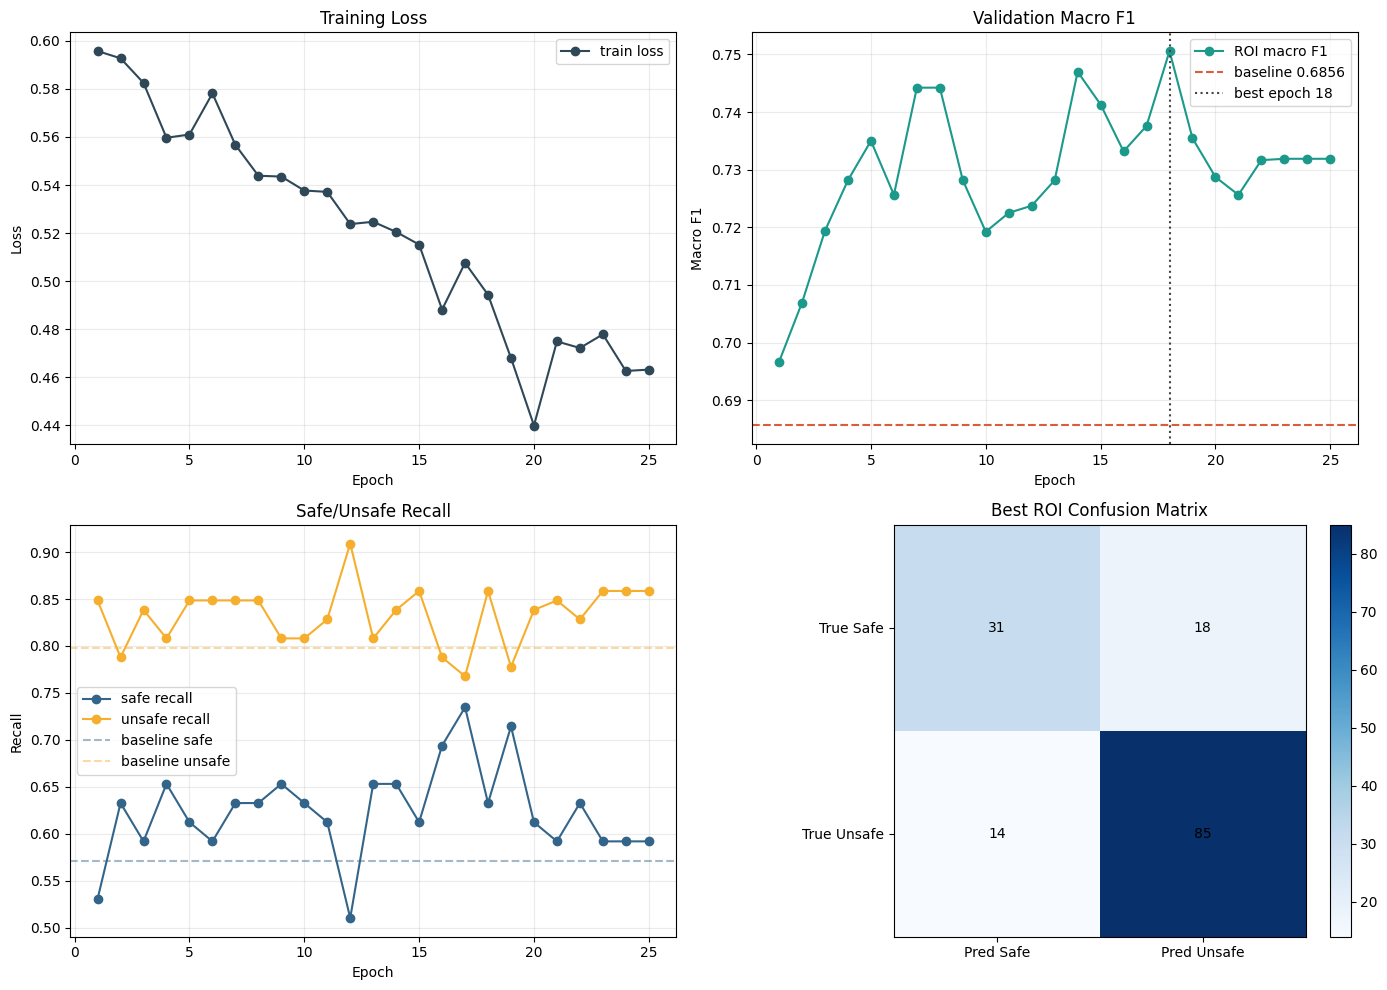

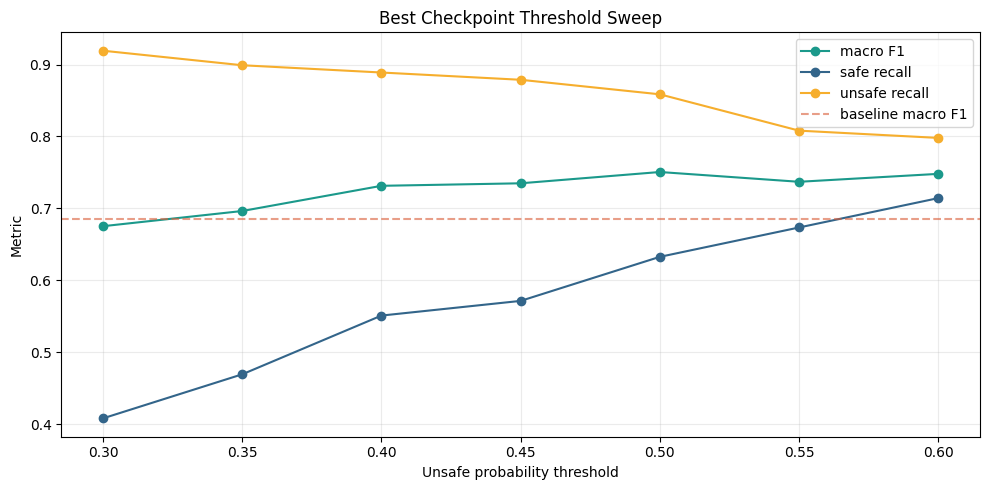

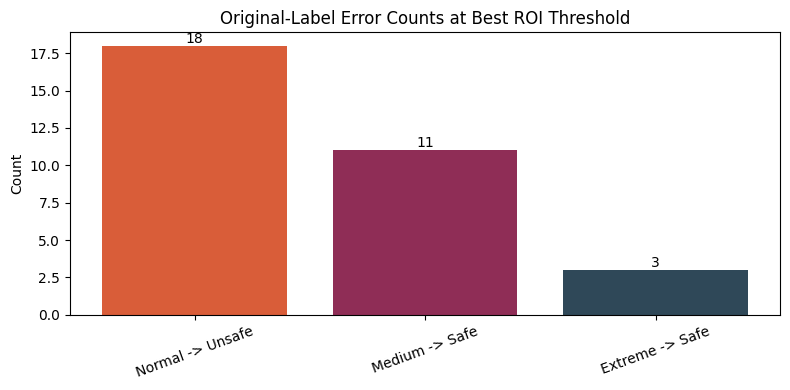


Decision: ACCEPT_ROI
Decision reason: macro F1 improved by +0.0650; unsafe recall improved by +0.0606 with safe recall 0.6327
Final decision object: {'baseline_macro_f1': 0.6856, 'baseline_unsafe_recall': 0.798, 'baseline_safe_recall': 0.5714, 'roi_macro_f1': 0.7505793132504739, 'roi_unsafe_recall': 0.8585858585858586, 'roi_safe_recall': 0.6326530612244898, 'decision': 'ACCEPT_ROI', 'decision_reason': 'macro F1 improved by +0.0650; unsafe recall improved by +0.0606 with safe recall 0.6327'}


In [18]:
# Dense evaluation for Binary Temporal ROI A/B Test: tables and plots only, no retraining
import ast as _roi_eval_ast
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROI_RESULTS_CSV = Path("eval_logs/binary_temporal_roi_results.csv")
ROI_SUMMARY_JSON = Path("eval_logs/binary_temporal_roi_summary.json")
if not ROI_RESULTS_CSV.exists() and Path("Implimentation/eval_logs/binary_temporal_roi_results.csv").exists():
    ROI_RESULTS_CSV = Path("Implimentation/eval_logs/binary_temporal_roi_results.csv")
if not ROI_SUMMARY_JSON.exists() and Path("Implimentation/eval_logs/binary_temporal_roi_summary.json").exists():
    ROI_SUMMARY_JSON = Path("Implimentation/eval_logs/binary_temporal_roi_summary.json")
if not ROI_RESULTS_CSV.exists():
    raise FileNotFoundError(f"ROI results CSV not found: {ROI_RESULTS_CSV}")
if not ROI_SUMMARY_JSON.exists():
    raise FileNotFoundError(f"ROI summary JSON not found: {ROI_SUMMARY_JSON}")

roi_results_df = pd.read_csv(ROI_RESULTS_CSV)
with open(ROI_SUMMARY_JSON, "r", encoding="utf-8") as f:
    roi_summary = json.load(f)

print("Loaded ROI results:", ROI_RESULTS_CSV, roi_results_df.shape)
print("Loaded ROI summary:", ROI_SUMMARY_JSON)

baseline_macro_f1 = float(roi_summary.get("baseline_macro_f1", 0.6856))
baseline_safe_recall = float(roi_summary.get("baseline_safe_recall", 0.5714))
baseline_unsafe_recall = float(roi_summary.get("baseline_unsafe_recall", 0.7980))
roi_macro_f1 = float(roi_summary.get("roi_macro_f1", roi_summary.get("best_macro_f1", np.nan)))
roi_safe_recall = float(roi_summary.get("roi_safe_recall", roi_summary.get("safe_recall", np.nan)))
roi_unsafe_recall = float(roi_summary.get("roi_unsafe_recall", roi_summary.get("unsafe_recall", np.nan)))

comparison_table = pd.DataFrame([
    {
        "model": "Non-ROI binary baseline",
        "macro_f1": baseline_macro_f1,
        "safe_recall": baseline_safe_recall,
        "unsafe_recall": baseline_unsafe_recall,
        "safe_precision": np.nan,
        "unsafe_precision": np.nan,
        "threshold": np.nan,
    },
    {
        "model": "ROI binary best",
        "macro_f1": roi_macro_f1,
        "safe_recall": roi_safe_recall,
        "unsafe_recall": roi_unsafe_recall,
        "safe_precision": float(roi_summary.get("safe_precision", np.nan)),
        "unsafe_precision": float(roi_summary.get("unsafe_precision", np.nan)),
        "threshold": float(roi_summary.get("best_threshold", np.nan)),
    },
])
comparison_table["macro_f1_delta"] = comparison_table["macro_f1"] - baseline_macro_f1
comparison_table["safe_recall_delta"] = comparison_table["safe_recall"] - baseline_safe_recall
comparison_table["unsafe_recall_delta"] = comparison_table["unsafe_recall"] - baseline_unsafe_recall
print("\nBaseline vs ROI best:")
display(comparison_table.round(4))

best_epoch = int(roi_summary.get("best_epoch", roi_results_df.loc[roi_results_df["val_macro_f1"].idxmax(), "epoch"]))
best_epoch_row = roi_results_df[roi_results_df["epoch"].astype(int) == best_epoch].copy()
if len(best_epoch_row) == 0:
    best_epoch_row = roi_results_df.loc[[roi_results_df["val_macro_f1"].idxmax()]].copy()
print("\nBest epoch row:")
display(best_epoch_row.round(4))

metric_cols = [
    "epoch", "train_loss", "val_accuracy", "val_macro_f1", "best_threshold",
    "safe_precision", "safe_recall", "safe_f1", "unsafe_precision", "unsafe_recall", "unsafe_f1",
    "original0_to_unsafe", "original1_to_safe", "original2_to_safe",
    "medium_unsafe_recall", "extreme_unsafe_recall", "peak_cuda_memory_gb",
]
metric_cols = [c for c in metric_cols if c in roi_results_df.columns]
print("\nPer-epoch metrics table:")
display(roi_results_df[metric_cols].round(4))

threshold_rows = roi_summary.get("threshold_rows", [])
threshold_df = pd.DataFrame(threshold_rows)
if len(threshold_df):
    if "original_label_error_breakdown" in threshold_df.columns:
        breakdown_df = pd.json_normalize(threshold_df["original_label_error_breakdown"])
        breakdown_df.columns = [f"breakdown_{c}" for c in breakdown_df.columns]
        threshold_df = pd.concat([threshold_df.drop(columns=["original_label_error_breakdown"]), breakdown_df], axis=1)
    print("\nBest-checkpoint threshold sweep:")
    display(threshold_df.round(4))
else:
    print("No threshold_rows found in ROI summary.")

breakdown = roi_summary.get("original_label_error_breakdown", {})
error_table = pd.DataFrame([
    {"error_type": "Normal -> Unsafe", "count": int(breakdown.get("original0_to_unsafe", roi_summary.get("normal_to_unsafe_count", 0)))},
    {"error_type": "Medium -> Safe", "count": int(breakdown.get("original1_to_safe", roi_summary.get("medium_to_safe_count", 0)))},
    {"error_type": "Extreme -> Safe", "count": int(breakdown.get("original2_to_safe", roi_summary.get("extreme_to_safe_count", 0)))},
])
print("\nOriginal-label error breakdown:")
display(error_table)

cm = np.asarray(roi_summary.get("confusion_matrix", [[0, 0], [0, 0]]), dtype=float)
if cm.shape != (2, 2):
    cm = np.asarray([[0, 0], [0, 0]], dtype=float)
cm_df = pd.DataFrame(cm.astype(int), index=["True Safe", "True Unsafe"], columns=["Pred Safe", "Pred Unsafe"])
print("\nBest ROI confusion matrix:")
display(cm_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

axes[0].plot(roi_results_df["epoch"], roi_results_df["train_loss"], marker="o", label="train loss", color="#2f4858")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(roi_results_df["epoch"], roi_results_df["val_macro_f1"], marker="o", label="ROI macro F1", color="#1b998b")
axes[1].axhline(baseline_macro_f1, linestyle="--", color="#d95d39", label=f"baseline {baseline_macro_f1:.4f}")
axes[1].axvline(best_epoch, linestyle=":", color="#444444", label=f"best epoch {best_epoch}")
axes[1].set_title("Validation Macro F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].plot(roi_results_df["epoch"], roi_results_df["safe_recall"], marker="o", label="safe recall", color="#33658a")
axes[2].plot(roi_results_df["epoch"], roi_results_df["unsafe_recall"], marker="o", label="unsafe recall", color="#f6ae2d")
axes[2].axhline(baseline_safe_recall, linestyle="--", color="#33658a", alpha=0.45, label="baseline safe")
axes[2].axhline(baseline_unsafe_recall, linestyle="--", color="#f6ae2d", alpha=0.45, label="baseline unsafe")
axes[2].set_title("Safe/Unsafe Recall")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Recall")
axes[2].grid(alpha=0.25)
axes[2].legend()

im = axes[3].imshow(cm, cmap="Blues")
axes[3].set_title("Best ROI Confusion Matrix")
axes[3].set_xticks([0, 1], ["Pred Safe", "Pred Unsafe"])
axes[3].set_yticks([0, 1], ["True Safe", "True Unsafe"])
for i in range(2):
    for j in range(2):
        axes[3].text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

if len(threshold_df):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(threshold_df["threshold"], threshold_df["macro_f1"], marker="o", label="macro F1", color="#1b998b")
    ax.plot(threshold_df["threshold"], threshold_df["safe_recall"], marker="o", label="safe recall", color="#33658a")
    ax.plot(threshold_df["threshold"], threshold_df["unsafe_recall"], marker="o", label="unsafe recall", color="#f6ae2d")
    ax.axhline(baseline_macro_f1, linestyle="--", color="#d95d39", alpha=0.6, label="baseline macro F1")
    ax.set_title("Best Checkpoint Threshold Sweep")
    ax.set_xlabel("Unsafe probability threshold")
    ax.set_ylabel("Metric")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(error_table["error_type"], error_table["count"], color=["#d95d39", "#8f2d56", "#2f4858"])
ax.set_title("Original-Label Error Counts at Best ROI Threshold")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
for idx, val in enumerate(error_table["count"].tolist()):
    ax.text(idx, val, str(val), ha="center", va="bottom")
plt.tight_layout()
plt.show()

print("\nDecision:", roi_summary.get("decision"))
print("Decision reason:", roi_summary.get("decision_reason"))
print("Final decision object:", roi_summary.get("final_decision"))



# Censorship Module Smoke Test

Run the next cell to verify the standalone `censorship_module` loads both project checkpoints. To run an end-to-end censorship test, set `TEST_VIDEO_PATH` to a local video path first.


In [3]:
# Standalone censorship module notebook smoke test
from pathlib import Path
import importlib
import json
import sys
import torch

IMPLEMENTATION_DIR = Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation")
if str(IMPLEMENTATION_DIR) not in sys.path:
    sys.path.insert(0, str(IMPLEMENTATION_DIR))

# Reload local module files so notebook kernels pick up edits without a restart.
import censorship_module.config as censorship_config
import censorship_module.model_loader as censorship_model_loader
import censorship_module.video_window_detector as censorship_video_window_detector
import censorship_module.patch_heatmap_localizer as censorship_patch_heatmap_localizer
import censorship_module.censor_renderer as censorship_censor_renderer
import censorship_module.run_censorship as censorship_run_censorship

censorship_config = importlib.reload(censorship_config)
censorship_model_loader = importlib.reload(censorship_model_loader)
censorship_video_window_detector = importlib.reload(censorship_video_window_detector)
censorship_patch_heatmap_localizer = importlib.reload(censorship_patch_heatmap_localizer)
censorship_censor_renderer = importlib.reload(censorship_censor_renderer)
censorship_run_censorship = importlib.reload(censorship_run_censorship)

load_binary_temporal_model = censorship_model_loader.load_binary_temporal_model
load_convnext_image_classifier = censorship_model_loader.load_convnext_image_classifier
run_pipeline = censorship_run_censorship.run_pipeline

# Set this to a real video path when you want an end-to-end censorship test.
TEST_VIDEO_PATH = "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Sangre en la boca.mp4"
TEST_OUTPUT_PATH = IMPLEMENTATION_DIR / "outputs/censored/notebook_test_censored.mp4"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FAST_DEMO_SETTINGS = True

if FAST_DEMO_SETTINGS:
    # These only matter if you switch to CENSOR_REGION_MODE='patch_debug'.
    censorship_config.LOCALIZE_EVERY_N_FRAMES = 8
    censorship_config.PATCH_SIZES = [224]

# Final demo mode: safety-first full-frame censorship inside unsafe temporal segments.
censorship_config.CENSOR_REGION_MODE = "full_frame"
censorship_config.LOCALIZATION_SCOPE = censorship_config.CENSOR_REGION_MODE
censorship_config.ROI_MODE = "auto"
censorship_config.CENSOR_MODE = "pixelate"
censorship_config.FUSED_UNSAFE_POLICY = "or"

print("Device:", DEVICE)
print("ROI mode:", censorship_config.ROI_MODE)
print("Censor region mode:", censorship_config.CENSOR_REGION_MODE)
print("Localization scope compatibility alias:", censorship_config.LOCALIZATION_SCOPE)
print("Body vertical range:", censorship_config.BODY_FALLBACK_VERTICAL_RANGE)
print("Body horizontal range:", censorship_config.BODY_FALLBACK_HORIZONTAL_RANGE)
print("Valid person ROI area ratio:", censorship_config.MIN_PERSON_ROI_AREA_RATIO, "to", censorship_config.MAX_PERSON_ROI_AREA_RATIO)
print("Patch heatmap debug settings:", {"patch_sizes": censorship_config.PATCH_SIZES, "localize_every_n_frames": censorship_config.LOCALIZE_EVERY_N_FRAMES})

if TEST_VIDEO_PATH is None:
    print("\nNo TEST_VIDEO_PATH set. Running checkpoint-load smoke test only...")
    temporal_model = load_binary_temporal_model(DEVICE)
    image_model = load_convnext_image_classifier(DEVICE)
    print("Checkpoint-load smoke test passed.")
    del temporal_model, image_model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    print("\nTo test a video, set TEST_VIDEO_PATH = '/path/to/video.mp4' and rerun this cell.")
else:
    TEST_VIDEO_PATH = Path(TEST_VIDEO_PATH)
    if not TEST_VIDEO_PATH.exists():
        raise FileNotFoundError(f"TEST_VIDEO_PATH does not exist: {TEST_VIDEO_PATH}")

    result = run_pipeline(
        input_video=TEST_VIDEO_PATH,
        output_video=TEST_OUTPUT_PATH,
        device=DEVICE,
    )
    summary = result["summary"]
    print("\nCensorship test complete.")
    print("Output video:", result["paths"]["video"])
    print("Windows JSON:", result["paths"]["windows"])
    print("Segments JSON:", result["paths"]["segments"])
    print("Frame boxes JSON:", result["paths"]["frame_boxes"])
    print("Summary JSON:", result["paths"]["summary"])
    print("\nSummary preview:")
    print(json.dumps({
        "num_unsafe_segments": summary.get("num_unsafe_segments"),
        "total_unsafe_duration": summary.get("total_unsafe_duration"),
        "max_temporal_unsafe_prob": summary.get("max_temporal_unsafe_prob"),
        "max_frame_clip_risk": summary.get("max_frame_clip_risk"),
        "max_fused_score": summary.get("max_fused_score"),
        "censor_region_mode": summary.get("censor_region_mode"),
        "localization_scope": summary.get("localization_scope"),
        "frames_full_frame_censored": summary.get("frames_full_frame_censored"),
        "fallback_used_frame_count": summary.get("fallback_used_frame_count"),
        "fallback_used_percent": summary.get("fallback_used_percent"),
        "frames_with_person_roi": summary.get("frames_with_person_roi"),
        "frames_with_valid_person_roi": summary.get("frames_with_valid_person_roi"),
        "frames_with_invalid_person_roi": summary.get("frames_with_invalid_person_roi"),
        "frames_using_body_fallback": summary.get("frames_using_body_fallback"),
        "frames_using_center_fallback": summary.get("frames_using_center_fallback"),
        "frames_using_full_frame_debug": summary.get("frames_using_full_frame_debug"),
        "frames_using_patch_heatmap": summary.get("frames_using_patch_heatmap"),
        "roi_mode": summary.get("roi_mode"),
        "roi_available": summary.get("roi_available"),
        "roi_fallback_used": summary.get("roi_fallback_used"),
    }, indent=2))


Device: cuda
ROI mode: auto
Censor region mode: full_frame
Localization scope compatibility alias: full_frame
Body vertical range: [0.25, 0.9]
Body horizontal range: [0.15, 0.85]
Valid person ROI area ratio: 0.03 to 0.8
Patch heatmap debug settings: {'patch_sizes': [224], 'localize_every_n_frames': 8}
Using project ConvNeXtTemporalClassifier from Models.temporal_model.
Loaded 354/354 keys using candidate 'raw'.
Loaded 344/344 keys using candidate 'raw'.
{
  "input_video": "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Sangre en la boca.mp4",
  "output_video": "/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/outputs/censored/notebook_test_censored.mp4",
  "temporal_threshold": 0.5,
  "frame_risk_threshold": 0.9,
  "patch_risk_threshold": 0.85,
  "fused_policy": "or",
  "temporal_only_mode": false,
  "num_windows_marked_unsafe": 346,
  "percent_windows_marked_unsafe": 94.27792915531334,
  "window_seconds": 4.0,
  "window_stride_seconds": 2.0,
  "pre_pad_seconds":

# Memory Cleanup Checkpoint Before Temporal Hard-Negative Backbone Retraining

This checkpoint frees GPU/CPU memory from the hard-negative backbone section before running the temporal experiment.

It does **not** clear any previous cell outputs. For a full reset, you can still restart the kernel manually and then run only the temporal section.


In [ ]:
# Memory Cleanup Checkpoint Before Temporal Hard-Negative Backbone Retraining
import gc

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

cleanup_variable_names = [
    "hard_negative_samples",
    "hard_negative_paths",
    "hard_negative_bias_summary",
    "hard_negative_bias_summary_after",
    "hard_negative_bias_delta",
    "hardneg_train_dataset",
    "hardneg_augmented_train_dataset",
    "hardneg_base_train_dataset",
    "hardneg_base_val_dataset",
    "hardneg_base_test_dataset",
    "hardneg_only_train_dataset",
    "hardneg_train_loader",
    "hardneg_val_loader",
    "hardneg_test_loader",
    "hardneg_train_targets",
    "hardneg_train_sources",
    "hardneg_train_sampler",
    "hardneg_training_history",
    "hardneg_best_summary",
    "hardneg_model",
    "hardneg_lmdb_source_summary",
    "hardneg_class_weights",
    "criterion_hardneg",
    "optimizer_hardneg",
    "scheduler_hardneg",
    "scaler_hardneg",
    "backbone_hardneg_comparison",
    "temporal_hardneg_history",
    "temporal_hardneg_best_summary",
]


def _cuda_mem():
    if "torch" not in globals():
        return None
    if not torch.cuda.is_available():
        return None
    return {
        "allocated_mb": float(torch.cuda.memory_allocated() / (1024 ** 2)),
        "reserved_mb": float(torch.cuda.memory_reserved() / (1024 ** 2)),
    }


before_cuda = _cuda_mem()
closed_objects = []
deleted_names = []

for name in cleanup_variable_names:
    if name not in globals():
        continue
    obj = globals().get(name)
    if hasattr(obj, "close"):
        try:
            obj.close()
            closed_objects.append(name)
        except Exception as exc:
            print(f"Close warning for {name}: {type(exc).__name__}: {exc}")
    deleted_names.append(name)
    del globals()[name]

if plt is not None:
    try:
        plt.close("all")
    except Exception:
        pass

collected = gc.collect()

if "torch" in globals() and torch.cuda.is_available():
    try:
        torch.cuda.empty_cache()
    except Exception as exc:
        print(f"CUDA empty_cache warning: {type(exc).__name__}: {exc}")
    try:
        torch.cuda.ipc_collect()
    except Exception:
        pass

after_cuda = _cuda_mem()

print("Memory cleanup checkpoint complete.")
print(f"Deleted variables: {len(deleted_names)}")
if deleted_names:
    print(sorted(deleted_names))
print(f"Closed objects: {len(closed_objects)}")
if closed_objects:
    print(sorted(closed_objects))
print(f"gc.collect() reclaimed objects: {collected}")
print(f"CUDA memory before cleanup: {before_cuda}")
print(f"CUDA memory after cleanup: {after_cuda}")
print("If you want a full hard reset before temporal training, restart the kernel now and then run only the temporal section.")


Memory cleanup checkpoint complete.
Deleted variables: 23
['backbone_hardneg_comparison', 'criterion_hardneg', 'hard_negative_bias_delta', 'hard_negative_bias_summary', 'hard_negative_bias_summary_after', 'hard_negative_paths', 'hard_negative_samples', 'hardneg_augmented_train_dataset', 'hardneg_base_test_dataset', 'hardneg_base_train_dataset', 'hardneg_base_val_dataset', 'hardneg_best_summary', 'hardneg_lmdb_source_summary', 'hardneg_model', 'hardneg_only_train_dataset', 'hardneg_test_loader', 'hardneg_train_dataset', 'hardneg_train_loader', 'hardneg_training_history', 'hardneg_val_loader', 'optimizer_hardneg', 'scaler_hardneg', 'scheduler_hardneg']
Closed objects: 4
['hardneg_augmented_train_dataset', 'hardneg_base_test_dataset', 'hardneg_base_train_dataset', 'hardneg_base_val_dataset']
gc.collect() reclaimed objects: 294
CUDA memory before cleanup: {'allocated_mb': 994.31298828125, 'reserved_mb': 6472.0}
CUDA memory after cleanup: {'allocated_mb': 205.79736328125, 'reserved_mb': 294

Run order for this self-contained section after a fresh kernel:

1. Cell 45: config and output paths
2. Cell 46: load the 813 hard-negative normal images
3. Cell 47: import ML libraries, define helpers, and run the BEFORE bias check
4. Cell 48: build/reuse the augmented train LMDB and unchanged val/test loaders
5. Cell 49: fine-tune ConvNeXt from the existing checkpoint
6. Cell 50: run the AFTER bias check and save the before/after delta
7. Cell 51: compare old vs new backbone on unchanged validation/test

No previous dataset setup cells are required.


# Temporal Model Retraining with Hard-Negative-Corrected Backbone

Self-contained Dataset 2 temporal experiment using `checkpoints/convnext_sexynude_hardneg_best.pt`.

This section intentionally does not depend on previous notebook variables/cells.


In [ ]:
# Temporal hard-negative backbone experiment: self-contained imports and config
import copy
import json
import os
import random
import sys
from collections import Counter
from functools import partial
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

cwd = Path.cwd().resolve()
candidate_module_roots = [cwd, cwd / "Implimentation"]
if cwd.name == "Implimentation":
    notebook_work_dir = cwd
elif (cwd / "Implimentation").exists():
    notebook_work_dir = cwd / "Implimentation"
else:
    notebook_work_dir = cwd

for module_root in [cwd, notebook_work_dir]:
    if module_root.exists() and str(module_root) not in sys.path:
        sys.path.insert(0, str(module_root))

from temporal_dataset2_loader import (
    TemporalDataset,
    collate_skip_none,
    load_dataset2_from_directory_fallback,
    load_frames_fallback,
)

try:
    from Models.temporal_model import ConvNeXtTemporalClassifier
except ModuleNotFoundError:
    from Implimentation.Models.temporal_model import ConvNeXtTemporalClassifier

SEED = int(globals().get("SEED", 42))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATASET2_PATH = str(
    globals().get(
        "DATASET2_PATH",
        "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset",
    )
)
TEMPORAL_BACKBONE_CKPT = "checkpoints/convnext_sexynude_hardneg_best.pt"
TEMPORAL_HEAD_TYPE = "attention"
TEMPORAL_USE_ROI = False
TEMPORAL_SEQ_LEN = 16
REQUESTED_BATCH_SIZE = 2
BATCH_SIZE = int(globals().get("TEMPORAL_HARDNEG_BATCH_SIZE", REQUESTED_BATCH_SIZE))
TEMPORAL_FALLBACK_BATCH_SIZE = int(globals().get("TEMPORAL_HARDNEG_FALLBACK_BATCH_SIZE", 1))
NUM_EPOCHS = 25
PATIENCE = 10
TEMPORAL_DROPOUT_PROB = 0.5
CLASS1_WEIGHT_BOOST = 1.2
LABEL_SMOOTHING = 0.1
HEAD_LR = 3e-4
ENCODER_LR = 5e-5
WEIGHT_DECAY = 1e-4
TEMPORAL_NUM_WORKERS = int(globals().get("TEMPORAL_NOTEBOOK_WORKERS", 0))

CHECKPOINT_DIR = notebook_work_dir / "checkpoints"
EVAL_LOGS_DIR = notebook_work_dir / "eval_logs"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_LOGS_DIR.mkdir(parents=True, exist_ok=True)

TEMPORAL_HARDNEG_BEST = "checkpoints/temporal_dataset2_hardneg_backbone_best.pt"
TEMPORAL_HARDNEG_LATEST = "checkpoints/temporal_dataset2_hardneg_backbone_latest.pt"
TEMPORAL_HARDNEG_RESULTS_CSV = "eval_logs/temporal_hardneg_backbone_results.csv"
TEMPORAL_HARDNEG_SUMMARY_JSON = "eval_logs/temporal_hardneg_backbone_best_summary.json"

CLASS_LABELS = [0, 1, 2]
CLASS_NAMES = ["Normal", "Medium", "Extreme"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEMPORAL_USE_AMP = bool(globals().get("TEMPORAL_HARDNEG_USE_AMP", DEVICE.type == "cuda"))

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = False
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True


def resolve_notebook_path(path_like):
    path = Path(path_like)
    if path.is_absolute():
        return path
    candidates = [cwd / path, notebook_work_dir / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return notebook_work_dir / path


def output_notebook_path(path_like):
    path = Path(path_like)
    if path.is_absolute():
        return path
    return notebook_work_dir / path


TEMPORAL_BACKBONE_CKPT_RESOLVED = resolve_notebook_path(TEMPORAL_BACKBONE_CKPT)
TEMPORAL_HARDNEG_BEST_PATH = output_notebook_path(TEMPORAL_HARDNEG_BEST)
TEMPORAL_HARDNEG_LATEST_PATH = output_notebook_path(TEMPORAL_HARDNEG_LATEST)
TEMPORAL_HARDNEG_RESULTS_CSV_PATH = output_notebook_path(TEMPORAL_HARDNEG_RESULTS_CSV)
TEMPORAL_HARDNEG_SUMMARY_JSON_PATH = output_notebook_path(TEMPORAL_HARDNEG_SUMMARY_JSON)

print("Temporal hard-negative backbone configuration")
print(f"  Work dir: {notebook_work_dir}")
print(f"  Device: {DEVICE}")
print(f"  Dataset 2 path: {DATASET2_PATH}")
print(f"  Backbone checkpoint: {TEMPORAL_BACKBONE_CKPT_RESOLVED}")
print(f"  Head type: {TEMPORAL_HEAD_TYPE}")
print(f"  ROI enabled: {TEMPORAL_USE_ROI}")
print(f"  Sequence length: {TEMPORAL_SEQ_LEN}")
print(f"  Batch size: {BATCH_SIZE} (requested default: {REQUESTED_BATCH_SIZE}, fallback: {TEMPORAL_FALLBACK_BATCH_SIZE})")
print(f"  AMP enabled: {TEMPORAL_USE_AMP}")
print(f"  Epochs: {NUM_EPOCHS} | Patience: {PATIENCE}")
print(f"  Head LR: {HEAD_LR} | Encoder LR: {ENCODER_LR}")
print(f"  Class 1 weight boost: {CLASS1_WEIGHT_BOOST}")
print(f"  Label smoothing: {LABEL_SMOOTHING}")


Temporal hard-negative backbone configuration
  Work dir: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation
  Device: cuda
  Dataset 2 path: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset
  Backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
  Head type: attention
  ROI enabled: False
  Sequence length: 16
  Batch size: 2 (requested default: 2, fallback: 1)
  AMP enabled: True
  Epochs: 25 | Patience: 10
  Head LR: 0.0003 | Encoder LR: 5e-05
  Class 1 weight boost: 1.2
  Label smoothing: 0.1


In [ ]:
# Load Dataset 2, create GroupKFold split, transforms, dataloaders, and shape sanity check
def count_labels(records):
    return dict(sorted(Counter(int(record["label"]) for record in records).items()))


def assert_all_classes_present(counts, split_name):
    missing = [class_idx for class_idx in CLASS_LABELS if int(counts.get(class_idx, 0)) <= 0]
    if missing:
        raise AssertionError(f"{split_name} split is missing classes: {missing}. Counts: {counts}")


dataset2_records = load_dataset2_from_directory_fallback(DATASET2_PATH, seq_len=TEMPORAL_SEQ_LEN)
dataset2_records = [
    dict(record)
    for record in dataset2_records
    if isinstance(record, dict) and int(record.get("label", -1)) in set(CLASS_LABELS)
]
if not dataset2_records:
    raise RuntimeError("Dataset 2 is empty after filtering labels {0,1,2}.")

groups = [record["video_id"] for record in dataset2_records]
targets = [int(record["label"]) for record in dataset2_records]
assert len(set(groups)) > 1, f"GroupKFold needs more than one video_id group. Found {len(set(groups))}."

group_kfold = GroupKFold(n_splits=5)
train_idx, val_idx = next(group_kfold.split(dataset2_records, y=targets, groups=groups))

temporal_hardneg_train_data = [dataset2_records[i] for i in train_idx]
temporal_hardneg_val_data = [dataset2_records[i] for i in val_idx]

train_class_counts = count_labels(temporal_hardneg_train_data)
val_class_counts = count_labels(temporal_hardneg_val_data)
assert_all_classes_present(train_class_counts, "train")
assert_all_classes_present(val_class_counts, "validation")

print("Dataset 2 split summary")
print(f"  Dataset size: {len(dataset2_records)}")
print(f"  Unique video groups: {len(set(groups))}")
print(f"  Train size: {len(temporal_hardneg_train_data)}")
print(f"  Val size: {len(temporal_hardneg_val_data)}")
print(f"  Train class counts: {train_class_counts}")
print(f"  Val class counts: {val_class_counts}")

temporal_hardneg_train_tf = T.Compose(
    [
        T.RandomResizedCrop(224, scale=(0.8, 1.0)),
        T.RandomHorizontalFlip(),
        T.ColorJitter(0.3, 0.3, 0.3),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)
temporal_hardneg_val_tf = T.Compose(
    [
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)


def build_temporal_hardneg_loader(records, transform, random_sampling, shuffle):
    load_frames_fn = partial(
        load_frames_fallback,
        seq_len=TEMPORAL_SEQ_LEN,
        random_sampling=bool(random_sampling),
        use_roi=TEMPORAL_USE_ROI,
    )
    dataset = TemporalDataset(
        records,
        transform=transform,
        load_frames_fn=load_frames_fn,
        clip_length=TEMPORAL_SEQ_LEN,
    )
    loader_kwargs = {
        "batch_size": BATCH_SIZE,
        "shuffle": bool(shuffle),
        "num_workers": TEMPORAL_NUM_WORKERS,
        "collate_fn": collate_skip_none,
    }
    if TEMPORAL_NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = False
    return DataLoader(dataset, **loader_kwargs)


def rebuild_temporal_hardneg_loaders():
    global temporal_hardneg_train_loader, temporal_hardneg_val_loader
    temporal_hardneg_train_loader = build_temporal_hardneg_loader(
        temporal_hardneg_train_data,
        temporal_hardneg_train_tf,
        random_sampling=True,
        shuffle=True,
    )
    temporal_hardneg_val_loader = build_temporal_hardneg_loader(
        temporal_hardneg_val_data,
        temporal_hardneg_val_tf,
        random_sampling=False,
        shuffle=False,
    )
    return temporal_hardneg_train_loader, temporal_hardneg_val_loader


temporal_hardneg_train_loader, temporal_hardneg_val_loader = rebuild_temporal_hardneg_loaders()

first_batch = None
for candidate_batch in temporal_hardneg_train_loader:
    if candidate_batch is not None:
        first_batch = candidate_batch
        break
if first_batch is None:
    raise RuntimeError("Could not load a non-empty first training batch for shape sanity check.")

frames_sanity, labels_sanity = first_batch
print("First train batch frames.shape:", tuple(frames_sanity.shape))
print("First train batch labels.shape:", tuple(labels_sanity.shape))
assert frames_sanity.ndim == 5, f"Expected frames ndim=5, got {frames_sanity.ndim}"
assert labels_sanity.ndim == 1, f"Expected labels ndim=1, got {labels_sanity.ndim}"
assert tuple(frames_sanity.shape[1:]) == (TEMPORAL_SEQ_LEN, 3, 224, 224), (
    f"Expected frames shape [B,{TEMPORAL_SEQ_LEN},3,224,224], got {tuple(frames_sanity.shape)}"
)
assert int(frames_sanity.shape[0]) == int(labels_sanity.shape[0]), (
    f"Batch mismatch: frames batch={frames_sanity.shape[0]}, labels batch={labels_sanity.shape[0]}"
)
print("First batch shape sanity check passed.")


Dataset 2 split summary
  Dataset size: 741
  Unique video groups: 27
  Train size: 593
  Val size: 148
  Train class counts: {0: 263, 1: 119, 2: 211}
  Val class counts: {0: 49, 1: 58, 2: 41}
First train batch frames.shape: (2, 16, 3, 224, 224)
First train batch labels.shape: (2,)
First batch shape sanity check passed.


In [ ]:
# Build temporal model with hard-negative-corrected backbone, freeze policy, loss, optimizer, scheduler
if not TEMPORAL_BACKBONE_CKPT_RESOLVED.exists():
    raise FileNotFoundError(f"Hard-negative backbone checkpoint not found: {TEMPORAL_BACKBONE_CKPT_RESOLVED}")

try:
    temporal_hardneg_model = ConvNeXtTemporalClassifier(
        model_name="convnext_small",
        head_type=TEMPORAL_HEAD_TYPE,
        freeze_encoder=False,
        num_classes=3,
        encoder_checkpoint_path=str(TEMPORAL_BACKBONE_CKPT_RESOLVED),
    ).to(DEVICE)
except Exception as exc:
    print("Failed to load hard-negative backbone into temporal model.")
    print(f"Checkpoint: {TEMPORAL_BACKBONE_CKPT_RESOLVED}")
    print(f"Error type: {type(exc).__name__}")
    print(f"Error: {exc}")
    raise

for name, param in temporal_hardneg_model.encoder.named_parameters():
    param.requires_grad = "stages.3" in name

for param in temporal_hardneg_model.head.parameters():
    param.requires_grad = True

temporal_hardneg_trainable_encoder_params = [
    param for param in temporal_hardneg_model.encoder.parameters() if param.requires_grad
]
temporal_hardneg_head_params = list(temporal_hardneg_model.head.parameters())

trainable_encoder_param_count = int(sum(param.numel() for param in temporal_hardneg_trainable_encoder_params))
trainable_head_param_count = int(sum(param.numel() for param in temporal_hardneg_head_params if param.requires_grad))
total_trainable_param_count = int(sum(param.numel() for param in temporal_hardneg_model.parameters() if param.requires_grad))

if trainable_encoder_param_count <= 0:
    raise RuntimeError("No trainable encoder parameters found after stage-3 unfreeze.")
if trainable_head_param_count <= 0:
    raise RuntimeError("No trainable temporal head parameters found.")

print("Trainable parameter summary")
print(f"  Trainable encoder stage-3 params: {trainable_encoder_param_count:,}")
print(f"  Trainable temporal head params: {trainable_head_param_count:,}")
print(f"  Total trainable params: {total_trainable_param_count:,}")

train_labels_tensor = torch.tensor(
    [int(record["label"]) for record in temporal_hardneg_train_data],
    dtype=torch.long,
)
class_counts_tensor = torch.bincount(train_labels_tensor, minlength=3).float()
if torch.any(class_counts_tensor <= 0):
    raise ValueError(f"Cannot build class weights with empty class counts: {class_counts_tensor.tolist()}")

temporal_hardneg_class_weights = class_counts_tensor.sum() / (3.0 * class_counts_tensor)
temporal_hardneg_class_weights[1] *= float(CLASS1_WEIGHT_BOOST)
temporal_hardneg_class_weights = temporal_hardneg_class_weights.to(DEVICE)

temporal_hardneg_criterion = nn.CrossEntropyLoss(
    weight=temporal_hardneg_class_weights,
    label_smoothing=float(LABEL_SMOOTHING),
)
print("Train class counts tensor:", class_counts_tensor.tolist())
print("Class weights with class-1 boost:", temporal_hardneg_class_weights.detach().cpu().tolist())

temporal_hardneg_optimizer = torch.optim.AdamW(
    [
        {"params": temporal_hardneg_model.head.parameters(), "lr": HEAD_LR},
        {"params": temporal_hardneg_trainable_encoder_params, "lr": ENCODER_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)
temporal_hardneg_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    temporal_hardneg_optimizer,
    T_max=max(1, NUM_EPOCHS),
)
print("Optimizer and scheduler ready.")


Trainable parameter summary
  Trainable encoder stage-3 params: 15,470,592
  Trainable temporal head params: 1,479,172
  Total trainable params: 16,949,764
Train class counts tensor: [263.0, 119.0, 211.0]
Class weights with class-1 boost: [0.7515842914581299, 1.9932773113250732, 0.9368088245391846]
Optimizer and scheduler ready.


/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/Models/temporal_model.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint

In [ ]:
# Train/evaluate the single temporal attention model with the hard-negative-corrected backbone
def apply_temporal_dropout(frames):
    if TEMPORAL_DROPOUT_PROB <= 0:
        return frames
    if torch.rand(1, device=frames.device).item() < float(TEMPORAL_DROPOUT_PROB):
        temporal_length = int(frames.shape[1])
        num_drop = max(1, temporal_length // 6)
        drop_indices = torch.randperm(temporal_length, device=frames.device)[:num_drop]
        frames = frames.clone()
        frames[:, drop_indices] = 0
    return frames


def _sync_cuda_if_needed():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


def _cleanup_cuda_after_failure():
    if DEVICE.type != "cuda":
        return
    try:
        torch.cuda.synchronize()
    except Exception:
        pass
    try:
        torch.cuda.empty_cache()
    except Exception:
        pass
    try:
        torch.cuda.ipc_collect()
    except Exception:
        pass


def evaluate_temporal_hardneg_model(model, loader, criterion=None):
    model.eval()
    running_loss = 0.0
    sample_count = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader, start=1):
            if batch is None:
                continue
            frames, labels = batch
            frames = frames.to(DEVICE)
            labels = labels.long().to(DEVICE)

            try:
                logits = model(frames)
                if criterion is not None:
                    loss = criterion(logits, labels)
                    running_loss += float(loss.item()) * int(frames.size(0))
                preds = torch.argmax(logits, dim=1)
                _sync_cuda_if_needed()
            except RuntimeError as exc:
                _cleanup_cuda_after_failure()
                raise RuntimeError(
                    "Validation CUDA failure. "
                    f"batch_idx={batch_idx}, frames_shape={tuple(frames.shape)}, "
                    f"labels_shape={tuple(labels.shape)}, labels={labels.detach().cpu().tolist()}, error={exc}"
                ) from exc

            sample_count += int(frames.size(0))
            y_true.extend(labels.detach().cpu().tolist())
            y_pred.extend(preds.detach().cpu().tolist())

    if not y_true:
        raise RuntimeError("Validation produced no predictions.")

    report = classification_report(
        y_true,
        y_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    report_text = classification_report(
        y_true,
        y_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)
    return {
        "loss": float(running_loss / max(1, sample_count)) if criterion is not None else 0.0,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, labels=CLASS_LABELS, average="macro", zero_division=0)),
        "classification_report": report,
        "classification_report_text": report_text,
        "confusion_matrix": cm.tolist(),
        "y_true": [int(x) for x in y_true],
        "y_pred": [int(x) for x in y_pred],
        "samples": int(sample_count),
    }


def train_one_temporal_hardneg_epoch(model, loader, optimizer, criterion, scaler=None, use_amp=False):
    model.train()
    running_loss = 0.0
    steps = 0
    sample_count = 0

    progress = tqdm(loader, desc="temporal hardneg train", leave=False)
    for batch_idx, batch in enumerate(progress, start=1):
        if batch is None:
            continue
        frames, labels = batch
        frames = frames.to(DEVICE)
        labels = labels.long().to(DEVICE)
        frames = apply_temporal_dropout(frames)

        try:
            optimizer.zero_grad(set_to_none=True)
            if use_amp and scaler is not None:
                with torch.amp.autocast("cuda", enabled=True):
                    logits = model(frames)
                    loss = criterion(logits, labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(frames)
                loss = criterion(logits, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            _sync_cuda_if_needed()
            loss_value = float(loss.detach().item())
        except RuntimeError as exc:
            _cleanup_cuda_after_failure()
            raise RuntimeError(
                "Training CUDA failure. "
                f"batch_idx={batch_idx}, frames_shape={tuple(frames.shape)}, "
                f"labels_shape={tuple(labels.shape)}, labels={labels.detach().cpu().tolist()}, error={exc}"
            ) from exc

        batch_size = int(frames.size(0))
        running_loss += loss_value * batch_size
        sample_count += batch_size
        steps += 1
        progress.set_postfix(loss=f"{running_loss / max(1, sample_count):.4f}")

    if steps <= 0:
        raise RuntimeError("Training epoch completed with zero valid batches.")
    return float(running_loss / max(1, sample_count))


def epoch_row(epoch, train_loss, val_metrics):
    report = val_metrics["classification_report"]
    row = {
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "val_accuracy": float(val_metrics["accuracy"]),
        "val_macro_f1": float(val_metrics["macro_f1"]),
        "confusion_matrix": json.dumps(val_metrics["confusion_matrix"]),
    }
    for class_idx, class_name in zip(CLASS_LABELS, CLASS_NAMES):
        class_report = report.get(class_name, {})
        row[f"class{class_idx}_precision"] = float(class_report.get("precision", 0.0))
        row[f"class{class_idx}_recall"] = float(class_report.get("recall", 0.0))
        row[f"class{class_idx}_f1"] = float(class_report.get("f1-score", 0.0))
    return row


def build_summary_payload(best_epoch, best_macro_f1, best_metrics):
    return {
        "best_epoch": int(best_epoch),
        "best_macro_f1": float(best_macro_f1),
        "classification_report": best_metrics["classification_report"],
        "classification_report_text": best_metrics["classification_report_text"],
        "confusion_matrix": best_metrics["confusion_matrix"],
        "checkpoint_path": str(TEMPORAL_HARDNEG_BEST_PATH),
        "backbone_checkpoint": str(TEMPORAL_BACKBONE_CKPT_RESOLVED),
        "seq_len": int(TEMPORAL_SEQ_LEN),
        "head_type": str(TEMPORAL_HEAD_TYPE),
        "roi_enabled": bool(TEMPORAL_USE_ROI),
        "class_weights": [float(x) for x in temporal_hardneg_class_weights.detach().cpu().tolist()],
        "temporal_dropout_enabled": bool(TEMPORAL_DROPOUT_PROB > 0),
        "temporal_dropout_prob": float(TEMPORAL_DROPOUT_PROB),
        "temporal_dropout_fraction": "T//6",
        "stage3_unfrozen": True,
        "optimizer_head_lr": float(HEAD_LR),
        "optimizer_encoder_lr": float(ENCODER_LR),
        "label_smoothing": float(LABEL_SMOOTHING),
        "class1_weight_boost": float(CLASS1_WEIGHT_BOOST),
        "train_class_counts": {str(k): int(v) for k, v in train_class_counts.items()},
        "val_class_counts": {str(k): int(v) for k, v in val_class_counts.items()},
        "dataset_path": str(DATASET2_PATH),
        "batch_size": int(BATCH_SIZE),
        "num_epochs_configured": int(NUM_EPOCHS),
        "patience": int(PATIENCE),
        "temporal_num_workers": int(TEMPORAL_NUM_WORKERS),
    }


temporal_hardneg_use_amp = bool(TEMPORAL_USE_AMP and DEVICE.type == "cuda" and hasattr(torch, "amp"))
temporal_hardneg_scaler = torch.amp.GradScaler("cuda", enabled=temporal_hardneg_use_amp) if temporal_hardneg_use_amp else None


def enable_temporal_hardneg_safe_mode():
    global BATCH_SIZE, temporal_hardneg_train_loader, temporal_hardneg_val_loader

    if int(BATCH_SIZE) == int(TEMPORAL_FALLBACK_BATCH_SIZE):
        return

    print(
        "Switching temporal hard-negative training to conservative CUDA safe mode: "
        f"batch_size {BATCH_SIZE} -> {TEMPORAL_FALLBACK_BATCH_SIZE}"
    )
    BATCH_SIZE = int(TEMPORAL_FALLBACK_BATCH_SIZE)
    _cleanup_cuda_after_failure()
    temporal_hardneg_train_loader, temporal_hardneg_val_loader = rebuild_temporal_hardneg_loaders()

    first_safe_batch = None
    for candidate_batch in temporal_hardneg_train_loader:
        if candidate_batch is not None:
            first_safe_batch = candidate_batch
            break
    if first_safe_batch is None:
        raise RuntimeError("Safe-mode loader rebuild produced no valid training batch.")
    safe_frames, safe_labels = first_safe_batch
    print("Safe-mode first batch frames.shape:", tuple(safe_frames.shape))
    print("Safe-mode first batch labels.shape:", tuple(safe_labels.shape))


temporal_hardneg_history = []
temporal_hardneg_best_epoch = -1
temporal_hardneg_best_macro_f1 = -1.0
temporal_hardneg_best_metrics = None
patience_counter = 0
training_start = perf_counter()

for epoch in range(1, NUM_EPOCHS + 1):
    for attempt in range(2):
        try:
            train_loss = train_one_temporal_hardneg_epoch(
                temporal_hardneg_model,
                temporal_hardneg_train_loader,
                temporal_hardneg_optimizer,
                temporal_hardneg_criterion,
                scaler=temporal_hardneg_scaler,
                use_amp=temporal_hardneg_use_amp,
            )
            break
        except RuntimeError as exc:
            msg = str(exc).lower()
            cuda_like_failure = any(
                token in msg
                for token in [
                    "cuda error",
                    "unspecified launch failure",
                    "out of memory",
                    "cublas",
                    "cudnn",
                    "device-side assert",
                ]
            )
            if DEVICE.type == "cuda" and attempt == 0 and cuda_like_failure:
                print("Temporal training hit a CUDA failure; retrying once in conservative safe mode.")
                print(str(exc))
                enable_temporal_hardneg_safe_mode()
                continue
            raise
    temporal_hardneg_scheduler.step()

    val_metrics = evaluate_temporal_hardneg_model(
        temporal_hardneg_model,
        temporal_hardneg_val_loader,
        criterion=temporal_hardneg_criterion,
    )
    row = epoch_row(epoch, train_loss, val_metrics)
    temporal_hardneg_history.append(row)
    pd.DataFrame(temporal_hardneg_history).to_csv(TEMPORAL_HARDNEG_RESULTS_CSV_PATH, index=False)

    latest_payload = {
        "epoch": int(epoch),
        "model_state_dict": temporal_hardneg_model.state_dict(),
        "optimizer_state_dict": temporal_hardneg_optimizer.state_dict(),
        "scheduler_state_dict": temporal_hardneg_scheduler.state_dict(),
        "val_macro_f1": float(val_metrics["macro_f1"]),
        "backbone_checkpoint": str(TEMPORAL_BACKBONE_CKPT_RESOLVED),
        "seq_len": int(TEMPORAL_SEQ_LEN),
        "head_type": str(TEMPORAL_HEAD_TYPE),
        "roi_enabled": bool(TEMPORAL_USE_ROI),
    }
    torch.save(latest_payload, TEMPORAL_HARDNEG_LATEST_PATH)

    if val_metrics["macro_f1"] > temporal_hardneg_best_macro_f1:
        temporal_hardneg_best_macro_f1 = float(val_metrics["macro_f1"])
        temporal_hardneg_best_epoch = int(epoch)
        temporal_hardneg_best_metrics = copy.deepcopy(val_metrics)
        patience_counter = 0
        best_payload = dict(latest_payload)
        best_payload.update(
            {
                "best_epoch": int(temporal_hardneg_best_epoch),
                "best_val_macro_f1": float(temporal_hardneg_best_macro_f1),
                "classification_report": temporal_hardneg_best_metrics["classification_report"],
                "confusion_matrix": temporal_hardneg_best_metrics["confusion_matrix"],
                "class_weights": [float(x) for x in temporal_hardneg_class_weights.detach().cpu().tolist()],
            }
        )
        torch.save(best_payload, TEMPORAL_HARDNEG_BEST_PATH)
        temporal_hardneg_best_summary = build_summary_payload(
            temporal_hardneg_best_epoch,
            temporal_hardneg_best_macro_f1,
            temporal_hardneg_best_metrics,
        )
        with open(TEMPORAL_HARDNEG_SUMMARY_JSON_PATH, "w", encoding="utf-8") as f:
            json.dump(temporal_hardneg_best_summary, f, indent=2)
        print(f"Saved new best checkpoint: {TEMPORAL_HARDNEG_BEST_PATH}")
    else:
        patience_counter += 1

    elapsed = perf_counter() - training_start
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Val macro F1: {val_metrics['macro_f1']:.4f}")
    print(f"Best macro F1: {temporal_hardneg_best_macro_f1:.4f} (epoch {temporal_hardneg_best_epoch})")
    print(f"Elapsed seconds: {elapsed:.1f}")
    print("Validation classification report:")
    print(val_metrics["classification_report_text"])
    print("Validation confusion matrix:")
    print(np.array(val_metrics["confusion_matrix"]))
    print("-" * 80)

    if patience_counter >= PATIENCE:
        print(f"Early stopping after {PATIENCE} epochs without macro-F1 improvement.")
        break

if temporal_hardneg_best_metrics is None:
    raise RuntimeError("Training did not produce a best validation checkpoint.")

temporal_hardneg_best_summary = build_summary_payload(
    temporal_hardneg_best_epoch,
    temporal_hardneg_best_macro_f1,
    temporal_hardneg_best_metrics,
)
with open(TEMPORAL_HARDNEG_SUMMARY_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(temporal_hardneg_best_summary, f, indent=2)

print("Temporal hard-negative backbone training complete.")
print(f"Best checkpoint: {TEMPORAL_HARDNEG_BEST_PATH}")
print(f"Latest checkpoint: {TEMPORAL_HARDNEG_LATEST_PATH}")
print(f"Results CSV: {TEMPORAL_HARDNEG_RESULTS_CSV_PATH}")
print(f"Best summary JSON: {TEMPORAL_HARDNEG_SUMMARY_JSON_PATH}")
print("Best validation classification report:")
print(temporal_hardneg_best_metrics["classification_report_text"])
print("Best validation confusion matrix:")
print(np.array(temporal_hardneg_best_metrics["confusion_matrix"]))


temporal hardneg train:   0%|          | 0/297 [00:00<?, ?it/s]

Saved new best checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/temporal_dataset2_hardneg_backbone_best.pt

Epoch 1/25
Train loss: 1.1450
Val accuracy: 0.3108
Val macro F1: 0.2561
Best macro F1: 0.2561 (epoch 1)
Elapsed seconds: 324.8
Validation classification report:
              precision    recall  f1-score   support

      Normal     0.3043    0.5714    0.3972        49
      Medium     0.0000    0.0000    0.0000        58
     Extreme     0.3214    0.4390    0.3711        41

    accuracy                         0.3108       148
   macro avg     0.2086    0.3368    0.2561       148
weighted avg     0.1898    0.3108    0.2343       148

Validation confusion matrix:
[[28  0 21]
 [41  0 17]
 [23  0 18]]
--------------------------------------------------------------------------------


temporal hardneg train:   0%|          | 0/297 [00:00<?, ?it/s]

Saved new best checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/temporal_dataset2_hardneg_backbone_best.pt

Epoch 2/25
Train loss: 1.1225
Val accuracy: 0.3243
Val macro F1: 0.2661
Best macro F1: 0.2661 (epoch 2)
Elapsed seconds: 656.1
Validation classification report:
              precision    recall  f1-score   support

      Normal     0.3167    0.3878    0.3486        49
      Medium     0.0000    0.0000    0.0000        58
     Extreme     0.3295    0.7073    0.4496        41

    accuracy                         0.3243       148
   macro avg     0.2154    0.3650    0.2661       148
weighted avg     0.1961    0.3243    0.2400       148

Validation confusion matrix:
[[19  0 30]
 [29  0 29]
 [12  0 29]]
--------------------------------------------------------------------------------


temporal hardneg train:   0%|          | 0/297 [00:00<?, ?it/s]

...


Epoch 23/25
Train loss: 1.0192
Val accuracy: 0.3446
Val macro F1: 0.3274
Best macro F1: 0.3697 (epoch 20)
Elapsed seconds: 7571.2
Validation classification report:
              precision    recall  f1-score   support

      Normal     0.3196    0.6327    0.4247        49
      Medium     0.2963    0.1379    0.1882        58
     Extreme     0.5000    0.2927    0.3692        41

    accuracy                         0.3446       148
   macro avg     0.3720    0.3544    0.3274       148
weighted avg     0.3604    0.3446    0.3167       148

Validation confusion matrix:
[[31 11  7]
 [45  8  5]
 [21  8 12]]
--------------------------------------------------------------------------------


temporal hardneg train:   0%|          | 0/297 [00:00<?, ?it/s]


Epoch 24/25
Train loss: 1.0331
Val accuracy: 0.3446
Val macro F1: 0.3272
Best macro F1: 0.3697 (epoch 20)
Elapsed seconds: 7902.7
Validation classification report:
              precision    recall  f1-score   support

      Normal     0.3163    0.6327    0.4218        49
      Medium     0.3077    0.1379    0.1905        58
     Extreme     0.5000    0.2927    0.3692        41

    accuracy                         0.3446       148
   macro avg     0.3747    0.3544    0.3272       148
weighted avg     0.3638    0.3446    0.3166       148

Validation confusion matrix:
[[31 11  7]
 [45  8  5]
 [22  7 12]]
--------------------------------------------------------------------------------


temporal hardneg train:   0%|          | 0/297 [00:00<?, ?it/s]


Epoch 25/25
Train loss: 1.0194
Val accuracy: 0.3446
Val macro F1: 0.3272
Best macro F1: 0.3697 (epoch 20)
Elapsed seconds: 8238.4
Validation classification report:
              precision    recall  f1-score   support

      Normal     0.3163    0.6327    0.4218        49
      Medium     0.3077    0.1379    0.1905        58
     Extreme     0.5000    0.2927    0.3692        41

    accuracy                         0.3446       148
   macro avg     0.3747    0.3544    0.3272       148
weighted avg     0.3638    0.3446    0.3166       148

Validation confusion matrix:
[[31 11  7]
 [45  8  5]
 [22  7 12]]
--------------------------------------------------------------------------------
Temporal hard-negative backbone training complete.
Best checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/temporal_dataset2_hardneg_backbone_best.pt
Latest checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/temporal_dataset2_hardneg_b

In [ ]:
# Optional old-vs-new temporal comparison from available result files
def confusion_error(cm, true_label, pred_label):
    try:
        return int(cm[int(true_label)][int(pred_label)])
    except Exception:
        return None


def extract_temporal_summary_from_json(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            payload = json.load(f)
    except Exception:
        return None

    if not isinstance(payload, dict):
        return None

    candidate = payload
    for key in ("best_val_metrics", "final_val_metrics", "selected_metrics", "validation"):
        if isinstance(candidate.get(key), dict):
            candidate = candidate[key]
            break

    report = candidate.get("classification_report") or candidate.get("report")
    cm = candidate.get("confusion_matrix")
    macro_f1 = candidate.get("best_macro_f1", candidate.get("macro_f1", payload.get("best_macro_f1")))

    if report is None or cm is None or macro_f1 is None:
        return None

    report_keys = set(report.keys()) if isinstance(report, dict) else set()
    if not ({"Normal", "Medium", "Extreme"} & report_keys or {"0", "1", "2"} & report_keys):
        return None

    return {
        "path": str(path),
        "macro_f1": float(macro_f1),
        "classification_report": report,
        "confusion_matrix": cm,
    }


def class_f1_from_report(report, class_idx):
    class_name = CLASS_NAMES[int(class_idx)]
    for key in (class_name, str(class_idx), int(class_idx)):
        if key in report:
            return float(report[key].get("f1-score", 0.0))
    return 0.0


new_summary = temporal_hardneg_best_summary
old_summary = None
candidate_jsons = []
for base in [EVAL_LOGS_DIR, CHECKPOINT_DIR]:
    if base.exists():
        candidate_jsons.extend(sorted(base.rglob("*temporal*.json")))

for candidate_path in candidate_jsons:
    name = candidate_path.name.lower()
    if "hardneg" in name or "hier" in name or "multi" in name or "ordinal" in name:
        continue
    parsed = extract_temporal_summary_from_json(candidate_path)
    if parsed is not None:
        old_summary = parsed
        break

if old_summary is None:
    print("Old temporal comparison unavailable; compare manually using previous logs.")
else:
    old_cm = old_summary["confusion_matrix"]
    new_cm = new_summary["confusion_matrix"]
    rows = [
        {
            "metric": "macro_f1",
            "old": float(old_summary["macro_f1"]),
            "new": float(new_summary["best_macro_f1"]),
        },
        {
            "metric": "class0_f1",
            "old": class_f1_from_report(old_summary["classification_report"], 0),
            "new": class_f1_from_report(new_summary["classification_report"], 0),
        },
        {
            "metric": "class1_f1",
            "old": class_f1_from_report(old_summary["classification_report"], 1),
            "new": class_f1_from_report(new_summary["classification_report"], 1),
        },
        {
            "metric": "class2_f1",
            "old": class_f1_from_report(old_summary["classification_report"], 2),
            "new": class_f1_from_report(new_summary["classification_report"], 2),
        },
        {"metric": "0_to_2_errors", "old": confusion_error(old_cm, 0, 2), "new": confusion_error(new_cm, 0, 2)},
        {"metric": "1_to_0_errors", "old": confusion_error(old_cm, 1, 0), "new": confusion_error(new_cm, 1, 0)},
        {"metric": "1_to_2_errors", "old": confusion_error(old_cm, 1, 2), "new": confusion_error(new_cm, 1, 2)},
    ]
    print(f"Old temporal comparison source: {old_summary['path']}")
    print(pd.DataFrame(rows).to_string(index=False))
    print("Old confusion matrix:")
    print(np.array(old_cm))
    print("New confusion matrix:")
    print(np.array(new_cm))


Old temporal comparison unavailable; compare manually using previous logs.


Run order for this self-contained section after a fresh kernel:

1. Config/imports
2. Dataset 2 split, transforms, dataloaders, and shape sanity check
3. Model/loss/optimizer setup
4. Training and best-summary export
5. Optional old/new temporal comparison

No previous notebook cells are required.


# Temporal Transfer Test — Hard-Negative Backbone with Matched Preprocessing

Experiment A: frozen hard-negative-corrected ConvNeXt encoder with temporal attention on Dataset 2.

This section uses preprocessing matched to the image backbone training path: resize/crop to 224, tensor values in `[0, 1]`, and no ImageNet normalization.


In [ ]:
# Temporal transfer test: self-contained imports, config, and checkpoint resolution
import copy
import json
import os
import random
import sys
from collections import Counter
from functools import partial
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

cwd = Path.cwd().resolve()
if cwd.name == "Implimentation":
    notebook_work_dir = cwd
elif (cwd / "Implimentation").exists():
    notebook_work_dir = cwd / "Implimentation"
else:
    notebook_work_dir = cwd

for module_root in [cwd, notebook_work_dir]:
    if module_root.exists() and str(module_root) not in sys.path:
        sys.path.insert(0, str(module_root))

from temporal_dataset2_loader import (
    TemporalDataset,
    collate_skip_none,
    load_dataset2_from_directory_fallback,
    load_frames_fallback,
)

try:
    from Models.temporal_model import ConvNeXtTemporalClassifier
except ModuleNotFoundError:
    from Implimentation.Models.temporal_model import ConvNeXtTemporalClassifier

try:
    from porn_data import fast_transform_rgb224
except ModuleNotFoundError:
    from Implimentation.porn_data import fast_transform_rgb224

SEED = int(globals().get("SEED", 42))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATASET2_PATH = "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset"
TEMPORAL_BACKBONE_CKPT = "checkpoints/convnext_sexynude_hardneg_best.pt"
TEMPORAL_HEAD_TYPE = "attention"
TEMPORAL_USE_ROI = False
TEMPORAL_SEQ_LEN = 16
BATCH_SIZE = 2
NUM_EPOCHS = 25
PATIENCE = 8

BEST_PATH = "checkpoints/temporal_hardneg_matched_preprocess_best.pt"
LATEST_PATH = "checkpoints/temporal_hardneg_matched_preprocess_latest.pt"
RESULTS_CSV = "eval_logs/temporal_hardneg_matched_preprocess_results.csv"
SUMMARY_JSON = "eval_logs/temporal_hardneg_matched_preprocess_summary.json"

CLASS_LABELS = [0, 1, 2]
CLASS_NAMES = ["Normal", "Medium", "Extreme"]
TEMPORAL_DROPOUT_PROB = 0.5
CLASS1_WEIGHT_BOOST = 1.2
LABEL_SMOOTHING = 0.1
HEAD_LR = 3e-4
WEIGHT_DECAY = 1e-4
TEMPORAL_NUM_WORKERS = int(globals().get("TEMPORAL_NOTEBOOK_WORKERS", 0))

CHECKPOINT_DIR = notebook_work_dir / "checkpoints"
EVAL_LOGS_DIR = notebook_work_dir / "eval_logs"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_LOGS_DIR.mkdir(parents=True, exist_ok=True)

BEST_PATH_RESOLVED = notebook_work_dir / BEST_PATH
LATEST_PATH_RESOLVED = notebook_work_dir / LATEST_PATH
RESULTS_CSV_RESOLVED = notebook_work_dir / RESULTS_CSV
SUMMARY_JSON_RESOLVED = notebook_work_dir / SUMMARY_JSON

checkpoint_candidates = [
    Path("checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
]
resolved_checkpoint = None
for candidate in checkpoint_candidates:
    candidate_path = candidate if candidate.is_absolute() else cwd / candidate
    if candidate_path.exists():
        resolved_checkpoint = candidate_path.resolve()
        break

if resolved_checkpoint is None:
    checked = [str((cwd / p).resolve()) if not p.is_absolute() else str(p) for p in checkpoint_candidates]
    raise FileNotFoundError("Hard-negative backbone checkpoint not found. Checked: " + json.dumps(checked, indent=2))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = bool(globals().get("TEMPORAL_MATCHED_USE_AMP", DEVICE.type == "cuda"))
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = False
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("Temporal transfer matched-preprocessing config")
print(f"  Work dir: {notebook_work_dir}")
print(f"  Device: {DEVICE}")
print(f"  Dataset 2 path: {DATASET2_PATH}")
print(f"  Backbone checkpoint: {resolved_checkpoint}")
print(f"  Head type: {TEMPORAL_HEAD_TYPE}")
print(f"  ROI enabled: {TEMPORAL_USE_ROI}")
print(f"  Sequence length: {TEMPORAL_SEQ_LEN}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS} | Patience: {PATIENCE}")
print(f"  AMP enabled: {USE_AMP}")
print(f"  Output best checkpoint: {BEST_PATH_RESOLVED}")


Temporal transfer matched-preprocessing config
  Work dir: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation
  Device: cuda
  Dataset 2 path: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset
  Backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
  Head type: attention
  ROI enabled: False
  Sequence length: 16
  Batch size: 2
  Epochs: 25 | Patience: 8
  AMP enabled: True
  Output best checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/temporal_hardneg_matched_preprocess_best.pt


In [ ]:
# Dataset 2 split, matched transforms, dataloaders, and first-batch preprocessing checks
def count_labels(records):
    return dict(sorted(Counter(int(record["label"]) for record in records).items()))


def assert_all_classes_present(counts, split_name):
    missing = [class_idx for class_idx in CLASS_LABELS if int(counts.get(class_idx, 0)) <= 0]
    if missing:
        raise AssertionError(f"{split_name} split is missing classes: {missing}. Counts: {counts}")


dataset2_records = load_dataset2_from_directory_fallback(DATASET2_PATH, seq_len=TEMPORAL_SEQ_LEN)
dataset2_records = [
    dict(record)
    for record in dataset2_records
    if isinstance(record, dict) and int(record.get("label", -1)) in set(CLASS_LABELS)
]
if not dataset2_records:
    raise RuntimeError("Dataset 2 is empty after filtering labels {0,1,2}.")

groups = [record["video_id"] for record in dataset2_records]
targets = [int(record["label"]) for record in dataset2_records]
if len(set(groups)) <= 1:
    raise AssertionError(f"GroupKFold needs more than one video_id group. Found {len(set(groups))}.")

group_kfold = GroupKFold(n_splits=5)
train_idx, val_idx = next(group_kfold.split(dataset2_records, y=targets, groups=groups))

matched_train_data = [dataset2_records[i] for i in train_idx]
matched_val_data = [dataset2_records[i] for i in val_idx]
train_groups = {record["video_id"] for record in matched_train_data}
val_groups = {record["video_id"] for record in matched_val_data}
overlap = train_groups & val_groups
if overlap:
    raise AssertionError(f"Train/val video_id overlap detected. Example overlap: {list(sorted(overlap))[:5]}")

train_class_counts = count_labels(matched_train_data)
val_class_counts = count_labels(matched_val_data)
assert_all_classes_present(train_class_counts, "train")
assert_all_classes_present(val_class_counts, "validation")

print("Dataset 2 split summary")
print(f"  Dataset size: {len(dataset2_records)}")
print(f"  Unique video groups: {len(set(groups))}")
print(f"  Train size: {len(matched_train_data)}")
print(f"  Val size: {len(matched_val_data)}")
print(f"  Train class counts: {train_class_counts}")
print(f"  Val class counts: {val_class_counts}")
print(f"  Train/val video_id overlap: {len(overlap)}")

matched_train_tf = T.Compose(
    [
        T.RandomResizedCrop(224, scale=(0.8, 1.0)),
        T.RandomHorizontalFlip(),
        T.ColorJitter(0.3, 0.3, 0.3),
        T.ToTensor(),
    ]
)
matched_val_tf = T.Compose(
    [
        T.Resize((224, 224)),
        T.ToTensor(),
    ]
)
transform_description = {
    "backbone_reference": "fast_transform_rgb224",
    "backbone_reference_behavior": "RGB, resize 224x224, float tensor in [0,1], no ImageNet normalization",
    "train": "RandomResizedCrop(224, scale=(0.8,1.0)) + RandomHorizontalFlip + ColorJitter(0.3,0.3,0.3) + ToTensor",
    "validation": "Resize((224,224)) + ToTensor",
    "imagenet_normalization": False,
}
print("Matched preprocessing note: fast_transform_rgb224 outputs [0,1] tensors with no ImageNet normalization.")
print("Train transform:")
print(matched_train_tf)
print("Validation transform:")
print(matched_val_tf)


def build_matched_temporal_loader(records, transform, random_sampling, shuffle):
    load_frames_fn = partial(
        load_frames_fallback,
        seq_len=TEMPORAL_SEQ_LEN,
        random_sampling=bool(random_sampling),
        use_roi=TEMPORAL_USE_ROI,
    )
    dataset = TemporalDataset(
        records,
        transform=transform,
        load_frames_fn=load_frames_fn,
        clip_length=TEMPORAL_SEQ_LEN,
    )
    loader_kwargs = {
        "batch_size": BATCH_SIZE,
        "shuffle": bool(shuffle),
        "num_workers": TEMPORAL_NUM_WORKERS,
        "collate_fn": collate_skip_none,
    }
    if TEMPORAL_NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = False
    return DataLoader(dataset, **loader_kwargs)


matched_train_loader = build_matched_temporal_loader(
    matched_train_data,
    matched_train_tf,
    random_sampling=True,
    shuffle=True,
)
matched_val_loader = build_matched_temporal_loader(
    matched_val_data,
    matched_val_tf,
    random_sampling=False,
    shuffle=False,
)

first_batch = None
for candidate_batch in matched_train_loader:
    if candidate_batch is not None:
        first_batch = candidate_batch
        break
if first_batch is None:
    raise RuntimeError("Could not load a non-empty first training batch for sanity checks.")

frames_sanity, labels_sanity = first_batch
first_batch_value_stats = {
    "min": float(frames_sanity.min().item()),
    "max": float(frames_sanity.max().item()),
    "mean": float(frames_sanity.mean().item()),
    "std": float(frames_sanity.std().item()),
}
print("First train batch frames.shape:", tuple(frames_sanity.shape))
print("First train batch labels.shape:", tuple(labels_sanity.shape))
print(
    "First train batch value stats:",
    first_batch_value_stats["min"],
    first_batch_value_stats["max"],
    first_batch_value_stats["mean"],
    first_batch_value_stats["std"],
)

if frames_sanity.ndim != 5:
    raise AssertionError(f"Expected frames ndim=5, got {frames_sanity.ndim}")
if labels_sanity.ndim != 1:
    raise AssertionError(f"Expected labels ndim=1, got {labels_sanity.ndim}")
if tuple(frames_sanity.shape[1:]) != (TEMPORAL_SEQ_LEN, 3, 224, 224):
    raise AssertionError(f"Expected frames shape [B,{TEMPORAL_SEQ_LEN},3,224,224], got {tuple(frames_sanity.shape)}")
if int(frames_sanity.shape[0]) != int(labels_sanity.shape[0]):
    raise AssertionError(f"Batch mismatch: frames batch={frames_sanity.shape[0]}, labels batch={labels_sanity.shape[0]}")
if first_batch_value_stats["min"] < -1e-4 or first_batch_value_stats["max"] > 1.0001:
    raise AssertionError(
        "First batch values are outside [0,1]. Normalization may be sneaking in. "
        f"Stats: {first_batch_value_stats}"
    )
print("First batch preprocessing sanity checks passed.")


Dataset 2 split summary
  Dataset size: 741
  Unique video groups: 27
  Train size: 593
  Val size: 148
  Train class counts: {0: 263, 1: 119, 2: 211}
  Val class counts: {0: 49, 1: 58, 2: 41}
  Train/val video_id overlap: 0
Matched preprocessing note: fast_transform_rgb224 outputs [0,1] tensors with no ImageNet normalization.
Train transform:
Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=None)
    ToTensor()
)
Validation transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)
First train batch frames.shape: (2, 16, 3, 224, 224)
First train batch labels.shape: (2,)
First train batch value stats: 0.01568627543747425 0.6235294342041016 0.2564999461174011 0.13926680386066437
First batch preprocessing sanity checks passed.


In [ ]:
# Frozen-encoder temporal attention model, weighted loss, optimizer, and scheduler
try:
    matched_model = ConvNeXtTemporalClassifier(
        model_name="convnext_small",
        head_type=TEMPORAL_HEAD_TYPE,
        freeze_encoder=True,
        num_classes=3,
        encoder_checkpoint_path=str(resolved_checkpoint),
    ).to(DEVICE)
except Exception as exc:
    print("Failed to load hard-negative backbone into frozen temporal model.")
    print(f"Checkpoint: {resolved_checkpoint}")
    print(f"Error type: {type(exc).__name__}")
    print(f"Error: {exc}")
    raise

print("Backbone checkpoint:", resolved_checkpoint)
encoder_frozen_check = all(not param.requires_grad for param in matched_model.encoder.parameters())
print("Encoder frozen:", encoder_frozen_check)

trainable_encoder_params = [param for param in matched_model.encoder.parameters() if param.requires_grad]
trainable_head_params = [param for param in matched_model.head.parameters() if param.requires_grad]
trainable_params = [param for param in matched_model.parameters() if param.requires_grad]

trainable_encoder_param_count = int(sum(param.numel() for param in trainable_encoder_params))
trainable_head_param_count = int(sum(param.numel() for param in trainable_head_params))
total_trainable_param_count = int(sum(param.numel() for param in trainable_params))

print("Trainable parameter summary")
print(f"  Trainable encoder params: {trainable_encoder_param_count:,}")
print(f"  Trainable temporal head params: {trainable_head_param_count:,}")
print(f"  Total trainable params: {total_trainable_param_count:,}")
if trainable_encoder_param_count != 0:
    raise AssertionError("Experiment A requires a fully frozen encoder.")
if trainable_head_param_count <= 0:
    raise AssertionError("Temporal head has no trainable parameters.")

train_labels_tensor = torch.tensor([int(record["label"]) for record in matched_train_data], dtype=torch.long)
class_counts_tensor = torch.bincount(train_labels_tensor, minlength=3).float()
if torch.any(class_counts_tensor <= 0):
    raise ValueError(f"Cannot build class weights with empty class counts: {class_counts_tensor.tolist()}")

class_weights = class_counts_tensor.sum() / (3.0 * class_counts_tensor)
class_weights[1] *= float(CLASS1_WEIGHT_BOOST)
class_weights = class_weights.to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)

optimizer = torch.optim.AdamW(
    filter(lambda param: param.requires_grad, matched_model.parameters()),
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, NUM_EPOCHS))
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP) if USE_AMP else None

print("Train class counts tensor:", class_counts_tensor.tolist())
print("Class weights:", class_weights.detach().cpu().tolist())
print("Optimizer: AdamW over trainable head params only")


/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/Models/temporal_model.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint

Backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Encoder frozen: True
Trainable parameter summary
  Trainable encoder params: 0
  Trainable temporal head params: 1,479,172
  Total trainable params: 1,479,172
Train class counts tensor: [263.0, 119.0, 211.0]
Class weights: [0.7515842914581299, 1.9932773113250732, 0.9368088245391846]
Optimizer: AdamW over trainable head params only


In [ ]:
# Train and evaluate Experiment A
def apply_temporal_dropout(frames):
    if TEMPORAL_DROPOUT_PROB <= 0:
        return frames
    if torch.rand(1, device=frames.device).item() < float(TEMPORAL_DROPOUT_PROB):
        temporal_length = int(frames.shape[1])
        num_drop = max(1, temporal_length // 6)
        drop_indices = torch.randperm(temporal_length, device=frames.device)[:num_drop]
        frames = frames.clone()
        frames[:, drop_indices] = 0
    return frames


def sync_cuda_if_needed():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


def evaluate_model(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue
            frames, labels = batch
            frames = frames.to(DEVICE)
            labels = labels.long().to(DEVICE)
            logits = model(frames)
            preds = torch.argmax(logits, dim=1)
            sync_cuda_if_needed()
            y_true.extend(labels.detach().cpu().tolist())
            y_pred.extend(preds.detach().cpu().tolist())

    if not y_true:
        raise RuntimeError("Validation produced no predictions.")

    report = classification_report(
        y_true,
        y_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    report_text = classification_report(
        y_true,
        y_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, labels=CLASS_LABELS, average="macro", zero_division=0)),
        "classification_report": report,
        "classification_report_text": report_text,
        "confusion_matrix": cm.tolist(),
        "y_true": [int(x) for x in y_true],
        "y_pred": [int(x) for x in y_pred],
    }


def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    sample_count = 0
    steps = 0

    progress = tqdm(loader, desc="matched preprocess train", leave=False)
    for batch in progress:
        if batch is None:
            continue
        frames, labels = batch
        frames = frames.to(DEVICE)
        labels = labels.long().to(DEVICE)
        frames = apply_temporal_dropout(frames)

        optimizer.zero_grad(set_to_none=True)
        if USE_AMP and scaler is not None:
            with torch.amp.autocast("cuda", enabled=True):
                logits = model(frames)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(matched_model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(frames)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(matched_model.parameters(), 1.0)
            optimizer.step()

        sync_cuda_if_needed()
        batch_size = int(frames.size(0))
        running_loss += float(loss.detach().item()) * batch_size
        sample_count += batch_size
        steps += 1
        progress.set_postfix(loss=f"{running_loss / max(1, sample_count):.4f}")

    if steps <= 0:
        raise RuntimeError("Training epoch completed with zero valid batches.")
    return float(running_loss / max(1, sample_count))


def row_from_metrics(epoch, train_loss, metrics):
    report = metrics["classification_report"]
    row = {
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "val_accuracy": float(metrics["accuracy"]),
        "val_macro_f1": float(metrics["macro_f1"]),
        "confusion_matrix": json.dumps(metrics["confusion_matrix"]),
    }
    for class_idx, class_name in zip(CLASS_LABELS, CLASS_NAMES):
        class_report = report.get(class_name, {})
        row[f"class{class_idx}_precision"] = float(class_report.get("precision", 0.0))
        row[f"class{class_idx}_recall"] = float(class_report.get("recall", 0.0))
        row[f"class{class_idx}_f1"] = float(class_report.get("f1-score", 0.0))
    return row


def build_summary(best_epoch, best_macro_f1, best_metrics):
    return {
        "best_epoch": int(best_epoch),
        "best_macro_f1": float(best_macro_f1),
        "classification_report": best_metrics["classification_report"],
        "classification_report_text": best_metrics["classification_report_text"],
        "confusion_matrix": best_metrics["confusion_matrix"],
        "checkpoint_path": str(BEST_PATH_RESOLVED),
        "backbone_checkpoint": str(resolved_checkpoint),
        "seq_len": int(TEMPORAL_SEQ_LEN),
        "roi_enabled": bool(TEMPORAL_USE_ROI),
        "encoder_frozen": bool(encoder_frozen_check),
        "matched_preprocessing": True,
        "transform_description": transform_description,
        "class_weights": [float(x) for x in class_weights.detach().cpu().tolist()],
        "label_smoothing": float(LABEL_SMOOTHING),
        "temporal_dropout_enabled": bool(TEMPORAL_DROPOUT_PROB > 0),
        "temporal_dropout_prob": float(TEMPORAL_DROPOUT_PROB),
        "temporal_dropout_fraction": "T//6",
        "first_batch_value_stats": first_batch_value_stats,
        "train_class_counts": {str(k): int(v) for k, v in train_class_counts.items()},
        "val_class_counts": {str(k): int(v) for k, v in val_class_counts.items()},
    }


history = []
best_epoch = -1
best_macro_f1 = -1.0
best_metrics = None
patience_counter = 0
start_time = perf_counter()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(matched_model, matched_train_loader)
    scheduler.step()
    val_metrics = evaluate_model(matched_model, matched_val_loader)
    history.append(row_from_metrics(epoch, train_loss, val_metrics))
    pd.DataFrame(history).to_csv(RESULTS_CSV_RESOLVED, index=False)

    latest_payload = {
        "epoch": int(epoch),
        "model_state_dict": matched_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "val_macro_f1": float(val_metrics["macro_f1"]),
        "backbone_checkpoint": str(resolved_checkpoint),
        "encoder_frozen": bool(encoder_frozen_check),
        "matched_preprocessing": True,
    }
    torch.save(latest_payload, LATEST_PATH_RESOLVED)

    if val_metrics["macro_f1"] > best_macro_f1:
        best_macro_f1 = float(val_metrics["macro_f1"])
        best_epoch = int(epoch)
        best_metrics = copy.deepcopy(val_metrics)
        patience_counter = 0
        best_payload = dict(latest_payload)
        best_payload.update(
            {
                "best_epoch": int(best_epoch),
                "best_macro_f1": float(best_macro_f1),
                "classification_report": best_metrics["classification_report"],
                "confusion_matrix": best_metrics["confusion_matrix"],
            }
        )
        torch.save(best_payload, BEST_PATH_RESOLVED)
        summary = build_summary(best_epoch, best_macro_f1, best_metrics)
        with open(SUMMARY_JSON_RESOLVED, "w", encoding="utf-8") as f:
            json.dump(summary, f, indent=2)
        print(f"Saved new best checkpoint: {BEST_PATH_RESOLVED}")
    else:
        patience_counter += 1

    elapsed = perf_counter() - start_time
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Val macro F1: {val_metrics['macro_f1']:.4f}")
    print(f"Best macro F1: {best_macro_f1:.4f} (epoch {best_epoch})")
    print(f"Elapsed seconds: {elapsed:.1f}")
    print("Validation classification report:")
    print(val_metrics["classification_report_text"])
    print("Validation confusion matrix:")
    print(np.array(val_metrics["confusion_matrix"]))
    print("-" * 80)

    if patience_counter >= PATIENCE:
        print(f"Early stopping after {PATIENCE} epochs without macro-F1 improvement.")
        break

if best_metrics is None:
    raise RuntimeError("Training did not produce a best checkpoint.")

summary = build_summary(best_epoch, best_macro_f1, best_metrics)
with open(SUMMARY_JSON_RESOLVED, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Temporal matched-preprocessing transfer test complete.")
print(f"Best checkpoint: {BEST_PATH_RESOLVED}")
print(f"Latest checkpoint: {LATEST_PATH_RESOLVED}")
print(f"Results CSV: {RESULTS_CSV_RESOLVED}")
print(f"Summary JSON: {SUMMARY_JSON_RESOLVED}")
print("Best validation classification report:")
print(best_metrics["classification_report_text"])
print("Best validation confusion matrix:")
print(np.array(best_metrics["confusion_matrix"]))
print("Experiment B suggestion: if Experiment A improves, rerun with encoder stage 3 unfrozen, encoder_lr=1e-5, head_lr=3e-4.")


matched preprocess train:   0%|          | 0/297 [00:00<?, ?it/s]

Saved new best checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/temporal_hardneg_matched_preprocess_best.pt

Epoch 1/25
Train loss: 1.0837
Val accuracy: 0.3716
Val macro F1: 0.3151
Best macro F1: 0.3151 (epoch 1)
Elapsed seconds: 340.8
Validation classification report:
              precision    recall  f1-score   support

      Normal     0.5000    0.5510    0.5243        49
      Medium     0.0000    0.0000    0.0000        58
     Extreme     0.3043    0.6829    0.4211        41

    accuracy                         0.3716       148
   macro avg     0.2681    0.4113    0.3151       148
weighted avg     0.2499    0.3716    0.2902       148

Validation confusion matrix:
[[27  1 21]
 [15  0 43]
 [12  1 28]]
--------------------------------------------------------------------------------


matched preprocess train:   0%|          | 0/297 [00:00<?, ?it/s]


Epoch 2/25
Train loss: 1.0652
Val accuracy: 0.3716
Val macro F1: 0.3119
Best macro F1: 0.3151 (epoch 1)
Elapsed seconds: 692.0
Validation classification report:
              precision    recall  f1-score   support

      Normal     0.5676    0.4286    0.4884        49
      Medium     0.0000    0.0000    0.0000        58
     Extreme     0.3063    0.8293    0.4474        41

    accuracy                         0.3716       148
   macro avg     0.2913    0.4193    0.3119       148
weighted avg     0.2728    0.3716    0.2856       148

Validation confusion matrix:
[[21  0 28]
 [ 9  0 49]
 [ 7  0 34]]
--------------------------------------------------------------------------------


matched preprocess train:   0%|          | 0/297 [00:00<?, ?it/s]

...


Epoch 18/25
Train loss: 0.9152
Val accuracy: 0.4392
Val macro F1: 0.4245
Best macro F1: 0.4365 (epoch 12)
Elapsed seconds: 6394.9
Validation classification report:
              precision    recall  f1-score   support

      Normal     0.5417    0.5306    0.5361        49
      Medium     0.4545    0.1724    0.2500        58
     Extreme     0.3718    0.7073    0.4874        41

    accuracy                         0.4392       148
   macro avg     0.4560    0.4701    0.4245       148
weighted avg     0.4605    0.4392    0.4105       148

Validation confusion matrix:
[[26  7 16]
 [15 10 33]
 [ 7  5 29]]
--------------------------------------------------------------------------------


matched preprocess train:   0%|          | 0/297 [00:00<?, ?it/s]


Epoch 19/25
Train loss: 0.9169
Val accuracy: 0.4459
Val macro F1: 0.4068
Best macro F1: 0.4365 (epoch 12)
Elapsed seconds: 6750.8
Validation classification report:
              precision    recall  f1-score   support

      Normal     0.5370    0.5918    0.5631        49
      Medium     0.5556    0.0862    0.1493        58
     Extreme     0.3765    0.7805    0.5079        41

    accuracy                         0.4459       148
   macro avg     0.4897    0.4862    0.4068       148
weighted avg     0.4998    0.4459    0.3856       148

Validation confusion matrix:
[[29  2 18]
 [18  5 35]
 [ 7  2 32]]
--------------------------------------------------------------------------------


matched preprocess train:   0%|          | 0/297 [00:00<?, ?it/s]


Epoch 20/25
Train loss: 0.8874
Val accuracy: 0.4527
Val macro F1: 0.4253
Best macro F1: 0.4365 (epoch 12)
Elapsed seconds: 7108.1
Validation classification report:
              precision    recall  f1-score   support

      Normal     0.5082    0.6327    0.5636        49
      Medium     0.6154    0.1379    0.2254        58
     Extreme     0.3784    0.6829    0.4870        41

    accuracy                         0.4527       148
   macro avg     0.5007    0.4845    0.4253       148
weighted avg     0.5142    0.4527    0.4098       148

Validation confusion matrix:
[[31  3 15]
 [19  8 31]
 [11  2 28]]
--------------------------------------------------------------------------------
Early stopping after 8 epochs without macro-F1 improvement.
Temporal matched-preprocessing transfer test complete.
Best checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/temporal_hardneg_matched_preprocess_best.pt
Latest checkpoint: /media/hazem/6A47B344CD80864E/GP Impl

Run order for this self-contained section after a fresh kernel:

1. Config/imports and checkpoint resolution
2. Dataset 2 split, matched transforms, dataloaders, and first-batch checks
3. Frozen-encoder model, weighted loss, optimizer, and scheduler
4. Training, checkpointing, CSV logging, and summary JSON export

No previous notebook cells are required.


# Temporal Transfer Test B — Matched Preprocessing with Gentle Stage-3 Unfreeze

Experiment B: hard-negative-corrected ConvNeXt with matched preprocessing, temporal attention, and only ConvNeXt `stages.3` unfrozen at a gentle encoder LR.


In [ ]:
# Temporal transfer test B: self-contained imports, config, and checkpoint resolution
import copy
import json
import os
import random
import sys
from collections import Counter
from functools import partial
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

cwd = Path.cwd().resolve()
if cwd.name == "Implimentation":
    notebook_work_dir = cwd
elif (cwd / "Implimentation").exists():
    notebook_work_dir = cwd / "Implimentation"
else:
    notebook_work_dir = cwd

for module_root in [cwd, notebook_work_dir]:
    if module_root.exists() and str(module_root) not in sys.path:
        sys.path.insert(0, str(module_root))

from temporal_dataset2_loader import (
    TemporalDataset,
    collate_skip_none,
    load_dataset2_from_directory_fallback,
    load_frames_fallback,
)

try:
    from Models.temporal_model import ConvNeXtTemporalClassifier
except ModuleNotFoundError:
    from Implimentation.Models.temporal_model import ConvNeXtTemporalClassifier

DATASET2_PATH = "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset"
TEMPORAL_BACKBONE_CKPT = "checkpoints/convnext_sexynude_hardneg_best.pt"
TEMPORAL_HEAD_TYPE = "attention"
TEMPORAL_USE_ROI = False
TEMPORAL_SEQ_LEN = 16
BATCH_SIZE = 2
NUM_EPOCHS = 25
PATIENCE = 8

BEST_PATH = "checkpoints/temporal_hardneg_matched_preprocess_stage3_best.pt"
LATEST_PATH = "checkpoints/temporal_hardneg_matched_preprocess_stage3_latest.pt"
RESULTS_CSV = "eval_logs/temporal_hardneg_matched_preprocess_stage3_results.csv"
SUMMARY_JSON = "eval_logs/temporal_hardneg_matched_preprocess_stage3_summary.json"

CLASS_LABELS = [0, 1, 2]
CLASS_NAMES = ["Normal", "Medium", "Extreme"]
TEMPORAL_DROPOUT_PROB = 0.5
CLASS1_WEIGHT_BOOST = 1.2
LABEL_SMOOTHING = 0.1
HEAD_LR = 3e-4
ENCODER_LR = 1e-5
WEIGHT_DECAY = 1e-4
TEMPORAL_NUM_WORKERS = int(globals().get("TEMPORAL_NOTEBOOK_WORKERS", 0))

SEED = int(globals().get("SEED", 42))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CHECKPOINT_DIR = notebook_work_dir / "checkpoints"
EVAL_LOGS_DIR = notebook_work_dir / "eval_logs"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_LOGS_DIR.mkdir(parents=True, exist_ok=True)

BEST_PATH_RESOLVED = notebook_work_dir / BEST_PATH
LATEST_PATH_RESOLVED = notebook_work_dir / LATEST_PATH
RESULTS_CSV_RESOLVED = notebook_work_dir / RESULTS_CSV
SUMMARY_JSON_RESOLVED = notebook_work_dir / SUMMARY_JSON

checkpoint_candidates = [
    Path("checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
]
resolved_checkpoint = None
for candidate in checkpoint_candidates:
    candidate_path = candidate if candidate.is_absolute() else cwd / candidate
    if candidate_path.exists():
        resolved_checkpoint = candidate_path.resolve()
        break

if resolved_checkpoint is None:
    checked = [str((cwd / p).resolve()) if not p.is_absolute() else str(p) for p in checkpoint_candidates]
    raise FileNotFoundError("Hard-negative backbone checkpoint not found. Checked: " + json.dumps(checked, indent=2))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = bool(globals().get("TEMPORAL_STAGE3_MATCHED_USE_AMP", DEVICE.type == "cuda"))
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = False
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("Temporal transfer test B configuration")
print(f"  Work dir: {notebook_work_dir}")
print(f"  Device: {DEVICE}")
print(f"  Dataset 2 path: {DATASET2_PATH}")
print(f"  Backbone checkpoint: {resolved_checkpoint}")
print(f"  Head type: {TEMPORAL_HEAD_TYPE}")
print(f"  ROI enabled: {TEMPORAL_USE_ROI}")
print(f"  Sequence length: {TEMPORAL_SEQ_LEN}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS} | Patience: {PATIENCE}")
print(f"  Head LR: {HEAD_LR} | Encoder stage-3 LR: {ENCODER_LR}")
print(f"  AMP enabled: {USE_AMP}")
print(f"  Output best checkpoint: {BEST_PATH_RESOLVED}")


Temporal transfer test B configuration
  Work dir: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation
  Device: cuda
  Dataset 2 path: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset
  Backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
  Head type: attention
  ROI enabled: False
  Sequence length: 16
  Batch size: 2
  Epochs: 25 | Patience: 8
  Head LR: 0.0003 | Encoder stage-3 LR: 1e-05
  AMP enabled: True
  Output best checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/temporal_hardneg_matched_preprocess_stage3_best.pt


In [ ]:
# Dataset 2 split, matched transforms, dataloaders, and first-batch preprocessing checks
def count_labels(records):
    return dict(sorted(Counter(int(record["label"]) for record in records).items()))


def assert_all_classes_present(counts, split_name):
    missing = [class_idx for class_idx in CLASS_LABELS if int(counts.get(class_idx, 0)) <= 0]
    if missing:
        raise AssertionError(f"{split_name} split is missing classes: {missing}. Counts: {counts}")


dataset2_records = load_dataset2_from_directory_fallback(DATASET2_PATH, seq_len=TEMPORAL_SEQ_LEN)
dataset2_records = [
    dict(record)
    for record in dataset2_records
    if isinstance(record, dict) and int(record.get("label", -1)) in set(CLASS_LABELS)
]
if not dataset2_records:
    raise RuntimeError("Dataset 2 is empty after filtering labels {0,1,2}.")

groups = [record["video_id"] for record in dataset2_records]
targets = [int(record["label"]) for record in dataset2_records]
if len(set(groups)) <= 1:
    raise AssertionError(f"GroupKFold needs more than one video_id group. Found {len(set(groups))}.")

group_kfold = GroupKFold(n_splits=5)
train_idx, val_idx = next(group_kfold.split(dataset2_records, y=targets, groups=groups))

stage3_train_data = [dataset2_records[i] for i in train_idx]
stage3_val_data = [dataset2_records[i] for i in val_idx]
train_groups = {record["video_id"] for record in stage3_train_data}
val_groups = {record["video_id"] for record in stage3_val_data}
overlap = train_groups & val_groups
if overlap:
    raise AssertionError(f"Train/val video_id overlap detected. Example overlap: {list(sorted(overlap))[:5]}")

train_class_counts = count_labels(stage3_train_data)
val_class_counts = count_labels(stage3_val_data)
assert_all_classes_present(train_class_counts, "train")
assert_all_classes_present(val_class_counts, "validation")

print("Dataset 2 split summary")
print(f"  Dataset size: {len(dataset2_records)}")
print(f"  Unique video groups: {len(set(groups))}")
print(f"  Train size: {len(stage3_train_data)}")
print(f"  Val size: {len(stage3_val_data)}")
print(f"  Train class counts: {train_class_counts}")
print(f"  Val class counts: {val_class_counts}")
print(f"  Train/val video_id overlap: {len(overlap)}")

stage3_train_tf = T.Compose(
    [
        T.RandomResizedCrop(224, scale=(0.8, 1.0)),
        T.RandomHorizontalFlip(),
        T.ColorJitter(0.3, 0.3, 0.3),
        T.ToTensor(),
    ]
)
stage3_val_tf = T.Compose(
    [
        T.Resize((224, 224)),
        T.ToTensor(),
    ]
)
transform_description = {
    "backbone_reference": "fast_transform_rgb224",
    "backbone_reference_behavior": "RGB, resize 224x224, float tensor in [0,1], no ImageNet normalization",
    "train": "RandomResizedCrop(224, scale=(0.8,1.0)) + RandomHorizontalFlip + ColorJitter(0.3,0.3,0.3) + ToTensor",
    "validation": "Resize((224,224)) + ToTensor",
    "imagenet_normalization": False,
}
print("Matched preprocessing note: [0,1] tensors, no ImageNet normalization.")
print("Train transform:")
print(stage3_train_tf)
print("Validation transform:")
print(stage3_val_tf)


def build_stage3_temporal_loader(records, transform, random_sampling, shuffle):
    load_frames_fn = partial(
        load_frames_fallback,
        seq_len=TEMPORAL_SEQ_LEN,
        random_sampling=bool(random_sampling),
        use_roi=TEMPORAL_USE_ROI,
    )
    dataset = TemporalDataset(
        records,
        transform=transform,
        load_frames_fn=load_frames_fn,
        clip_length=TEMPORAL_SEQ_LEN,
    )
    loader_kwargs = {
        "batch_size": BATCH_SIZE,
        "shuffle": bool(shuffle),
        "num_workers": TEMPORAL_NUM_WORKERS,
        "collate_fn": collate_skip_none,
    }
    if TEMPORAL_NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = False
    return DataLoader(dataset, **loader_kwargs)


stage3_train_loader = build_stage3_temporal_loader(stage3_train_data, stage3_train_tf, random_sampling=True, shuffle=True)
stage3_val_loader = build_stage3_temporal_loader(stage3_val_data, stage3_val_tf, random_sampling=False, shuffle=False)

first_batch = None
for candidate_batch in stage3_train_loader:
    if candidate_batch is not None:
        first_batch = candidate_batch
        break
if first_batch is None:
    raise RuntimeError("Could not load a non-empty first training batch for sanity checks.")

frames_sanity, labels_sanity = first_batch
first_batch_value_stats = {
    "min": float(frames_sanity.min().item()),
    "max": float(frames_sanity.max().item()),
    "mean": float(frames_sanity.mean().item()),
    "std": float(frames_sanity.std().item()),
}
print("First train batch frames.shape:", tuple(frames_sanity.shape))
print("First train batch labels.shape:", tuple(labels_sanity.shape))
print(
    "First train batch value stats:",
    first_batch_value_stats["min"],
    first_batch_value_stats["max"],
    first_batch_value_stats["mean"],
    first_batch_value_stats["std"],
)

if frames_sanity.ndim != 5:
    raise AssertionError(f"Expected frames ndim=5, got {frames_sanity.ndim}")
if labels_sanity.ndim != 1:
    raise AssertionError(f"Expected labels ndim=1, got {labels_sanity.ndim}")
if tuple(frames_sanity.shape[1:]) != (TEMPORAL_SEQ_LEN, 3, 224, 224):
    raise AssertionError(f"Expected frames shape [B,{TEMPORAL_SEQ_LEN},3,224,224], got {tuple(frames_sanity.shape)}")
if int(frames_sanity.shape[0]) != int(labels_sanity.shape[0]):
    raise AssertionError(f"Batch mismatch: frames batch={frames_sanity.shape[0]}, labels batch={labels_sanity.shape[0]}")
if first_batch_value_stats["min"] < -1e-4 or first_batch_value_stats["max"] > 1.0001:
    raise AssertionError(
        "First batch values are outside [0,1]. Normalization may be sneaking in. "
        f"Stats: {first_batch_value_stats}"
    )
print("First batch preprocessing sanity checks passed.")


Dataset 2 split summary
  Dataset size: 741
  Unique video groups: 27
  Train size: 593
  Val size: 148
  Train class counts: {0: 263, 1: 119, 2: 211}
  Val class counts: {0: 49, 1: 58, 2: 41}
  Train/val video_id overlap: 0
Matched preprocessing note: [0,1] tensors, no ImageNet normalization.
Train transform:
Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=None)
    ToTensor()
)
Validation transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)
First train batch frames.shape: (2, 16, 3, 224, 224)
First train batch labels.shape: (2,)
First train batch value stats: 0.01568627543747425 0.6235294342041016 0.2564999461174011 0.13926680386066437
First batch preprocessing sanity checks passed.


In [ ]:
# Stage-3-only temporal attention model, weighted loss, differential optimizer, and scheduler
try:
    stage3_model = ConvNeXtTemporalClassifier(
        model_name="convnext_small",
        head_type=TEMPORAL_HEAD_TYPE,
        freeze_encoder=False,
        num_classes=3,
        encoder_checkpoint_path=str(resolved_checkpoint),
    ).to(DEVICE)
except Exception as exc:
    print("Failed to load hard-negative backbone into stage-3 temporal model.")
    print(f"Checkpoint: {resolved_checkpoint}")
    print(f"Error type: {type(exc).__name__}")
    print(f"Error: {exc}")
    raise

for name, param in stage3_model.encoder.named_parameters():
    param.requires_grad = "stages.3" in name
for param in stage3_model.head.parameters():
    param.requires_grad = True

trainable_encoder_named_params = [
    (name, param) for name, param in stage3_model.encoder.named_parameters() if param.requires_grad
]
frozen_encoder_leaks = [
    name for name, param in stage3_model.encoder.named_parameters() if param.requires_grad and "stages.3" not in name
]
nontrainable_stage3 = [
    name for name, param in stage3_model.encoder.named_parameters() if "stages.3" in name and not param.requires_grad
]
if frozen_encoder_leaks:
    raise AssertionError(f"Non-stage-3 encoder params are trainable: {frozen_encoder_leaks[:10]}")
if nontrainable_stage3:
    raise AssertionError(f"Some stage-3 encoder params are not trainable: {nontrainable_stage3[:10]}")

trainable_encoder_params = [param for _name, param in trainable_encoder_named_params]
trainable_head_params = [param for param in stage3_model.head.parameters() if param.requires_grad]
trainable_params = [param for param in stage3_model.parameters() if param.requires_grad]

trainable_encoder_param_count = int(sum(param.numel() for param in trainable_encoder_params))
trainable_head_param_count = int(sum(param.numel() for param in trainable_head_params))
total_trainable_param_count = int(sum(param.numel() for param in trainable_params))

print("Backbone checkpoint:", resolved_checkpoint)
print("Stage 3 unfrozen:", True)
print("Trainable encoder parameter names are all stage 3:", all("stages.3" in name for name, _ in trainable_encoder_named_params))
print("Trainable parameter summary")
print(f"  Trainable encoder stage-3 params: {trainable_encoder_param_count:,}")
print(f"  Trainable temporal head params: {trainable_head_param_count:,}")
print(f"  Total trainable params: {total_trainable_param_count:,}")
print("First trainable encoder params:", [name for name, _ in trainable_encoder_named_params[:8]])
if trainable_encoder_param_count <= 0:
    raise AssertionError("Experiment B requires trainable stage-3 encoder parameters.")
if trainable_head_param_count <= 0:
    raise AssertionError("Temporal head has no trainable parameters.")

train_labels_tensor = torch.tensor([int(record["label"]) for record in stage3_train_data], dtype=torch.long)
class_counts_tensor = torch.bincount(train_labels_tensor, minlength=3).float()
if torch.any(class_counts_tensor <= 0):
    raise ValueError(f"Cannot build class weights with empty class counts: {class_counts_tensor.tolist()}")

class_weights = class_counts_tensor.sum() / (3.0 * class_counts_tensor)
class_weights[1] *= float(CLASS1_WEIGHT_BOOST)
class_weights = class_weights.to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)

optimizer = torch.optim.AdamW(
    [
        {"params": trainable_head_params, "lr": HEAD_LR},
        {"params": trainable_encoder_params, "lr": ENCODER_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, NUM_EPOCHS))
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP) if USE_AMP else None

print("Train class counts tensor:", class_counts_tensor.tolist())
print("Class weights:", class_weights.detach().cpu().tolist())
print("Optimizer: AdamW with head_lr=3e-4 and encoder_lr=1e-5")


/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/Models/temporal_model.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint

Backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Stage 3 unfrozen: True
Trainable encoder parameter names are all stage 3: True
Trainable parameter summary
  Trainable encoder stage-3 params: 15,470,592
  Trainable temporal head params: 1,479,172
  Total trainable params: 16,949,764
First trainable encoder params: ['stages.3.downsample.0.weight', 'stages.3.downsample.0.bias', 'stages.3.downsample.1.weight', 'stages.3.downsample.1.bias', 'stages.3.blocks.0.gamma', 'stages.3.blocks.0.conv_dw.weight', 'stages.3.blocks.0.conv_dw.bias', 'stages.3.blocks.0.norm.weight']
Train class counts tensor: [263.0, 119.0, 211.0]
Class weights: [0.7515842914581299, 1.9932773113250732, 0.9368088245391846]
Optimizer: AdamW with head_lr=3e-4 and encoder_lr=1e-5


In [ ]:
# Train and evaluate Experiment B
def apply_temporal_dropout(frames):
    if TEMPORAL_DROPOUT_PROB <= 0:
        return frames
    if torch.rand(1, device=frames.device).item() < float(TEMPORAL_DROPOUT_PROB):
        temporal_length = int(frames.shape[1])
        num_drop = max(1, temporal_length // 6)
        drop_indices = torch.randperm(temporal_length, device=frames.device)[:num_drop]
        frames = frames.clone()
        frames[:, drop_indices] = 0
    return frames


def sync_cuda_if_needed():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


def evaluate_model(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue
            frames, labels = batch
            frames = frames.to(DEVICE)
            labels = labels.long().to(DEVICE)
            logits = model(frames)
            preds = torch.argmax(logits, dim=1)
            sync_cuda_if_needed()
            y_true.extend(labels.detach().cpu().tolist())
            y_pred.extend(preds.detach().cpu().tolist())

    if not y_true:
        raise RuntimeError("Validation produced no predictions.")

    report = classification_report(
        y_true,
        y_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    report_text = classification_report(
        y_true,
        y_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, labels=CLASS_LABELS, average="macro", zero_division=0)),
        "classification_report": report,
        "classification_report_text": report_text,
        "confusion_matrix": cm.tolist(),
    }


def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    sample_count = 0
    steps = 0

    progress = tqdm(loader, desc="stage3 matched train", leave=False)
    for batch in progress:
        if batch is None:
            continue
        frames, labels = batch
        frames = frames.to(DEVICE)
        labels = labels.long().to(DEVICE)
        frames = apply_temporal_dropout(frames)

        optimizer.zero_grad(set_to_none=True)
        if USE_AMP and scaler is not None:
            with torch.amp.autocast("cuda", enabled=True):
                logits = model(frames)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(stage3_model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(frames)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(stage3_model.parameters(), 1.0)
            optimizer.step()

        sync_cuda_if_needed()
        batch_size = int(frames.size(0))
        running_loss += float(loss.detach().item()) * batch_size
        sample_count += batch_size
        steps += 1
        progress.set_postfix(loss=f"{running_loss / max(1, sample_count):.4f}")

    if steps <= 0:
        raise RuntimeError("Training epoch completed with zero valid batches.")
    return float(running_loss / max(1, sample_count))


def row_from_metrics(epoch, train_loss, metrics):
    report = metrics["classification_report"]
    row = {
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "val_accuracy": float(metrics["accuracy"]),
        "val_macro_f1": float(metrics["macro_f1"]),
        "confusion_matrix": json.dumps(metrics["confusion_matrix"]),
    }
    for class_idx, class_name in zip(CLASS_LABELS, CLASS_NAMES):
        class_report = report.get(class_name, {})
        row[f"class{class_idx}_precision"] = float(class_report.get("precision", 0.0))
        row[f"class{class_idx}_recall"] = float(class_report.get("recall", 0.0))
        row[f"class{class_idx}_f1"] = float(class_report.get("f1-score", 0.0))
    return row


def build_summary(best_epoch, best_macro_f1, best_metrics):
    return {
        "best_epoch": int(best_epoch),
        "best_macro_f1": float(best_macro_f1),
        "classification_report": best_metrics["classification_report"],
        "classification_report_text": best_metrics["classification_report_text"],
        "confusion_matrix": best_metrics["confusion_matrix"],
        "checkpoint_path": str(BEST_PATH_RESOLVED),
        "backbone_checkpoint": str(resolved_checkpoint),
        "seq_len": int(TEMPORAL_SEQ_LEN),
        "roi_enabled": bool(TEMPORAL_USE_ROI),
        "encoder_frozen": False,
        "stage3_unfrozen": True,
        "matched_preprocessing": True,
        "transform_description": transform_description,
        "class_weights": [float(x) for x in class_weights.detach().cpu().tolist()],
        "label_smoothing": float(LABEL_SMOOTHING),
        "temporal_dropout_enabled": bool(TEMPORAL_DROPOUT_PROB > 0),
        "temporal_dropout_prob": float(TEMPORAL_DROPOUT_PROB),
        "temporal_dropout_fraction": "T//6",
        "optimizer_head_lr": float(HEAD_LR),
        "optimizer_encoder_lr": float(ENCODER_LR),
        "first_batch_value_stats": first_batch_value_stats,
        "trainable_encoder_param_count": int(trainable_encoder_param_count),
        "trainable_head_param_count": int(trainable_head_param_count),
        "train_class_counts": {str(k): int(v) for k, v in train_class_counts.items()},
        "val_class_counts": {str(k): int(v) for k, v in val_class_counts.items()},
    }


history = []
best_epoch = -1
best_macro_f1 = -1.0
best_metrics = None
patience_counter = 0
start_time = perf_counter()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(stage3_model, stage3_train_loader)
    scheduler.step()
    val_metrics = evaluate_model(stage3_model, stage3_val_loader)
    history.append(row_from_metrics(epoch, train_loss, val_metrics))
    pd.DataFrame(history).to_csv(RESULTS_CSV_RESOLVED, index=False)

    latest_payload = {
        "epoch": int(epoch),
        "model_state_dict": stage3_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "val_macro_f1": float(val_metrics["macro_f1"]),
        "backbone_checkpoint": str(resolved_checkpoint),
        "stage3_unfrozen": True,
        "matched_preprocessing": True,
    }
    torch.save(latest_payload, LATEST_PATH_RESOLVED)

    if val_metrics["macro_f1"] > best_macro_f1:
        best_macro_f1 = float(val_metrics["macro_f1"])
        best_epoch = int(epoch)
        best_metrics = copy.deepcopy(val_metrics)
        patience_counter = 0
        best_payload = dict(latest_payload)
        best_payload.update(
            {
                "best_epoch": int(best_epoch),
                "best_macro_f1": float(best_macro_f1),
                "classification_report": best_metrics["classification_report"],
                "confusion_matrix": best_metrics["confusion_matrix"],
            }
        )
        torch.save(best_payload, BEST_PATH_RESOLVED)
        summary = build_summary(best_epoch, best_macro_f1, best_metrics)
        with open(SUMMARY_JSON_RESOLVED, "w", encoding="utf-8") as f:
            json.dump(summary, f, indent=2)
        print(f"Saved new best checkpoint: {BEST_PATH_RESOLVED}")
    else:
        patience_counter += 1

    elapsed = perf_counter() - start_time
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Val macro F1: {val_metrics['macro_f1']:.4f}")
    print(f"Best macro F1: {best_macro_f1:.4f} (epoch {best_epoch})")
    print(f"Elapsed seconds: {elapsed:.1f}")
    print("Validation classification report:")
    print(val_metrics["classification_report_text"])
    print("Validation confusion matrix:")
    print(np.array(val_metrics["confusion_matrix"]))
    print("-" * 80)

    if patience_counter >= PATIENCE:
        print(f"Early stopping after {PATIENCE} epochs without macro-F1 improvement.")
        break

if best_metrics is None:
    raise RuntimeError("Training did not produce a best checkpoint.")

summary = build_summary(best_epoch, best_macro_f1, best_metrics)
with open(SUMMARY_JSON_RESOLVED, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Temporal transfer test B complete.")
print(f"Best checkpoint: {BEST_PATH_RESOLVED}")
print(f"Latest checkpoint: {LATEST_PATH_RESOLVED}")
print(f"Results CSV: {RESULTS_CSV_RESOLVED}")
print(f"Summary JSON: {SUMMARY_JSON_RESOLVED}")
print("Best validation classification report:")
print(best_metrics["classification_report_text"])
print("Best validation confusion matrix:")
print(np.array(best_metrics["confusion_matrix"]))


stage3 matched train:   0%|          | 0/297 [00:00<?, ?it/s]

Saved new best checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/temporal_hardneg_matched_preprocess_stage3_best.pt

Epoch 1/25
Train loss: 1.0823
Val accuracy: 0.3784
Val macro F1: 0.3207
Best macro F1: 0.3207 (epoch 1)
Elapsed seconds: 363.0
Validation classification report:
              precision    recall  f1-score   support

      Normal     0.5094    0.5510    0.5294        49
      Medium     0.0000    0.0000    0.0000        58
     Extreme     0.3118    0.7073    0.4328        41

    accuracy                         0.3784       148
   macro avg     0.2738    0.4194    0.3207       148
weighted avg     0.2550    0.3784    0.2952       148

Validation confusion matrix:
[[27  1 21]
 [15  0 43]
 [11  1 29]]
--------------------------------------------------------------------------------


stage3 matched train:   0%|          | 0/297 [00:00<?, ?it/s]


Epoch 2/25
Train loss: 1.0561
Val accuracy: 0.3716
Val macro F1: 0.3119
Best macro F1: 0.3207 (epoch 1)
Elapsed seconds: 723.5
Validation classification report:
              precision    recall  f1-score   support

      Normal     0.5676    0.4286    0.4884        49
      Medium     0.0000    0.0000    0.0000        58
     Extreme     0.3063    0.8293    0.4474        41

    accuracy                         0.3716       148
   macro avg     0.2913    0.4193    0.3119       148
weighted avg     0.2728    0.3716    0.2856       148

Validation confusion matrix:
[[21  0 28]
 [ 9  0 49]
 [ 7  0 34]]
--------------------------------------------------------------------------------


stage3 matched train:   0%|          | 0/297 [00:00<?, ?it/s]

...


Epoch 14/25
Train loss: 0.9292
Val accuracy: 0.4122
Val macro F1: 0.3740
Best macro F1: 0.4321 (epoch 8)
Elapsed seconds: 5010.0
Validation classification report:
              precision    recall  f1-score   support

      Normal     0.6047    0.5306    0.5652        49
      Medium     0.3333    0.0517    0.0896        58
     Extreme     0.3333    0.7805    0.4672        41

    accuracy                         0.4122       148
   macro avg     0.4238    0.4543    0.3740       148
weighted avg     0.4232    0.4122    0.3516       148

Validation confusion matrix:
[[26  3 20]
 [11  3 44]
 [ 6  3 32]]
--------------------------------------------------------------------------------


stage3 matched train:   0%|          | 0/297 [00:00<?, ?it/s]


Epoch 15/25
Train loss: 0.9310
Val accuracy: 0.4122
Val macro F1: 0.3604
Best macro F1: 0.4321 (epoch 8)
Elapsed seconds: 5357.5
Validation classification report:
              precision    recall  f1-score   support

      Normal     0.5079    0.6531    0.5714        49
      Medium     0.4000    0.0345    0.0635        58
     Extreme     0.3375    0.6585    0.4463        41

    accuracy                         0.4122       148
   macro avg     0.4151    0.4487    0.3604       148
weighted avg     0.4184    0.4122    0.3377       148

Validation confusion matrix:
[[32  2 15]
 [18  2 38]
 [13  1 27]]
--------------------------------------------------------------------------------


stage3 matched train:   0%|          | 0/297 [00:00<?, ?it/s]


Epoch 16/25
Train loss: 0.9041
Val accuracy: 0.4122
Val macro F1: 0.3888
Best macro F1: 0.4321 (epoch 8)
Elapsed seconds: 5703.8
Validation classification report:
              precision    recall  f1-score   support

      Normal     0.5088    0.5918    0.5472        49
      Medium     0.4667    0.1207    0.1918        58
     Extreme     0.3289    0.6098    0.4274        41

    accuracy                         0.4122       148
   macro avg     0.4348    0.4408    0.3888       148
weighted avg     0.4425    0.4122    0.3747       148

Validation confusion matrix:
[[29  4 16]
 [16  7 35]
 [12  4 25]]
--------------------------------------------------------------------------------
Early stopping after 8 epochs without macro-F1 improvement.
Temporal transfer test B complete.
Best checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/temporal_hardneg_matched_preprocess_stage3_best.pt
Latest checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Imp

Run order for this self-contained section after a fresh kernel:

1. Config/imports and checkpoint resolution
2. Dataset 2 split, matched transforms, dataloaders, and first-batch checks
3. Stage-3-only model, weighted loss, differential optimizer, and scheduler
4. Training, checkpointing, CSV logging, and summary JSON export

No previous notebook cells are required.


# Ordinal Temporal Severity Regression — Dataset 2 Final Experiment

This append-only section trains a frozen-encoder ordinal severity regressor on Dataset 2 using the hard-negative-corrected ConvNeXt backbone. It uses matched `[0,1]` preprocessing with no ImageNet normalization, predicts a continuous severity score, and maps scores back to classes using validation threshold sweep.

In [ ]:
# Ordinal temporal severity regression: self-contained imports, config, paths, and checkpoint resolution
import ast
import copy
import gc
import json
import math
import os
import random
import sys
from collections import Counter
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import timm
import torchvision.transforms as T
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# -----------------------------
# Reproducibility and runtime
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = bool(torch.cuda.is_available())
NUM_WORKERS = 0

# -----------------------------
# Robust project path setup
# -----------------------------
CURRENT_DIR = Path.cwd()
PROJECT_ROOT_CANDIDATES = [
    CURRENT_DIR,
    CURRENT_DIR / "Implimentation",
    CURRENT_DIR.parent,
    CURRENT_DIR.parent / "Implimentation",
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation"),
]
for candidate in PROJECT_ROOT_CANDIDATES:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

if (CURRENT_DIR / "PORNMODULE.ipynb").exists():
    NOTEBOOK_RUN_DIR = CURRENT_DIR
elif (CURRENT_DIR / "Implimentation" / "PORNMODULE.ipynb").exists():
    NOTEBOOK_RUN_DIR = CURRENT_DIR / "Implimentation"
else:
    NOTEBOOK_RUN_DIR = CURRENT_DIR

try:
    from temporal_dataset2_loader import (
        TemporalDataset,
        collate_skip_none,
        load_dataset2_from_directory_fallback,
        load_frames_fallback,
    )
except ModuleNotFoundError:
    from Implimentation.temporal_dataset2_loader import (
        TemporalDataset,
        collate_skip_none,
        load_dataset2_from_directory_fallback,
        load_frames_fallback,
    )

# -----------------------------
# Config
# -----------------------------
DATASET2_PATH = "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset"
BACKBONE_CKPT = "checkpoints/convnext_sexynude_hardneg_best.pt"
TEMPORAL_USE_ROI = False
TEMPORAL_SEQ_LEN = 16
BATCH_SIZE = 2
NUM_EPOCHS = 25
PATIENCE = 8
TEMPORAL_DROPOUT_PROB = 0.5
TEMPORAL_DROPOUT_FRACTION = "T//6"
ORDINAL_BASELINE_MACRO_F1 = 0.44

BEST_PATH = "checkpoints/ordinal_temporal_severity_best.pt"
LATEST_PATH = "checkpoints/ordinal_temporal_severity_latest.pt"
RESULTS_CSV = "eval_logs/ordinal_temporal_severity_results.csv"
SUMMARY_JSON = "eval_logs/ordinal_temporal_severity_summary.json"

CHECKPOINT_DIR = NOTEBOOK_RUN_DIR / "checkpoints"
EVAL_LOGS_DIR = NOTEBOOK_RUN_DIR / "eval_logs"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_LOGS_DIR.mkdir(parents=True, exist_ok=True)

BEST_PATH_RESOLVED = NOTEBOOK_RUN_DIR / BEST_PATH
LATEST_PATH_RESOLVED = NOTEBOOK_RUN_DIR / LATEST_PATH
RESULTS_CSV_RESOLVED = NOTEBOOK_RUN_DIR / RESULTS_CSV
SUMMARY_JSON_RESOLVED = NOTEBOOK_RUN_DIR / SUMMARY_JSON

BACKBONE_CANDIDATES = [
    Path("checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
]
resolved_backbone_path = None
for candidate in BACKBONE_CANDIDATES:
    candidate_path = candidate if candidate.is_absolute() else (CURRENT_DIR / candidate)
    if candidate_path.exists():
        resolved_backbone_path = candidate_path.resolve()
        break
if resolved_backbone_path is None:
    for candidate in BACKBONE_CANDIDATES:
        candidate_path = candidate if candidate.is_absolute() else (NOTEBOOK_RUN_DIR / candidate)
        if candidate_path.exists():
            resolved_backbone_path = candidate_path.resolve()
            break
if resolved_backbone_path is None:
    raise FileNotFoundError(
        "Could not find hard-negative ConvNeXt backbone checkpoint. Checked: "
        + ", ".join(str(p) for p in BACKBONE_CANDIDATES)
    )

print("Ordinal Temporal Severity Regression — Dataset 2 Final Experiment")
print(f"Notebook run dir: {NOTEBOOK_RUN_DIR}")
print(f"Device: {DEVICE}")
print(f"Dataset 2 path: {DATASET2_PATH}")
print(f"Resolved backbone checkpoint: {resolved_backbone_path}")
print(f"Best checkpoint output: {BEST_PATH_RESOLVED}")
print(f"Latest checkpoint output: {LATEST_PATH_RESOLVED}")
print(f"Results CSV output: {RESULTS_CSV_RESOLVED}")
print(f"Summary JSON output: {SUMMARY_JSON_RESOLVED}")


Ordinal Temporal Severity Regression — Dataset 2 Final Experiment
Notebook run dir: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation
Device: cuda
Dataset 2 path: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset
Resolved backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Best checkpoint output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/ordinal_temporal_severity_best.pt
Latest checkpoint output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/ordinal_temporal_severity_latest.pt
Results CSV output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/ordinal_temporal_severity_results.csv
Summary JSON output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/ordinal_temporal_severity_summary.json


In [ ]:
# Dataset 2 loading, matched transforms, GroupKFold split, dataloaders, and first-batch checks
# Matched preprocessing: fast_transform_rgb224 resizes/RGB-converts to 224x224 and returns [0,1] tensors with no ImageNet normalization.
ordinal_train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.3, 0.3, 0.3),
    T.ToTensor(),
])
ordinal_val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])
ordinal_transform_description = {
    "backbone_reference": "fast_transform_rgb224",
    "matched_preprocessing": True,
    "normalization": "none",
    "pixel_range": "[0, 1]",
    "train": "RandomResizedCrop(224, scale=(0.8,1.0)) + RandomHorizontalFlip + ColorJitter(0.3,0.3,0.3) + ToTensor",
    "val": "Resize((224,224)) + ToTensor",
}
print("Train transform:", ordinal_train_transform)
print("Val transform:", ordinal_val_transform)
print("Matched preprocessing note: no ImageNet normalization; tensors should stay in [0,1].")

ordinal_all_records = load_dataset2_from_directory_fallback(DATASET2_PATH, seq_len=TEMPORAL_SEQ_LEN)
ordinal_all_records = [rec for rec in ordinal_all_records if int(rec.get("label", -1)) in {0, 1, 2}]
if not ordinal_all_records:
    raise RuntimeError(f"No Dataset 2 records found at {DATASET2_PATH}")

ordinal_groups = [str(rec.get("video_id", rec.get("frames", {}).get("video_path", idx))) for idx, rec in enumerate(ordinal_all_records)]
if len(set(ordinal_groups)) < 5:
    raise AssertionError(f"GroupKFold(n_splits=5) requires at least 5 unique groups; found {len(set(ordinal_groups))}")
assert len(set(ordinal_groups)) > 1, "Dataset 2 split requires more than one video/group."

ordinal_labels = np.asarray([int(rec["label"]) for rec in ordinal_all_records], dtype=np.int64)
ordinal_group_kfold = GroupKFold(n_splits=5)
ordinal_train_idx, ordinal_val_idx = next(ordinal_group_kfold.split(ordinal_all_records, ordinal_labels, groups=ordinal_groups))

ordinal_train_records = [ordinal_all_records[int(i)] for i in ordinal_train_idx]
ordinal_val_records = [ordinal_all_records[int(i)] for i in ordinal_val_idx]
ordinal_train_labels = np.asarray([int(rec["label"]) for rec in ordinal_train_records], dtype=np.int64)
ordinal_val_labels = np.asarray([int(rec["label"]) for rec in ordinal_val_records], dtype=np.int64)
ordinal_train_counts = np.bincount(ordinal_train_labels, minlength=3)
ordinal_val_counts = np.bincount(ordinal_val_labels, minlength=3)

ordinal_train_groups = {str(rec.get("video_id")) for rec in ordinal_train_records}
ordinal_val_groups = {str(rec.get("video_id")) for rec in ordinal_val_records}
overlap = ordinal_train_groups.intersection(ordinal_val_groups)
if overlap:
    raise AssertionError(f"Train/val video_id overlap detected: {list(sorted(overlap))[:10]}")
if not all(int(c) > 0 for c in ordinal_train_counts):
    raise AssertionError(f"Train split does not contain all classes 0/1/2: {ordinal_train_counts.tolist()}")
if not all(int(c) > 0 for c in ordinal_val_counts):
    raise AssertionError(f"Val split does not contain all classes 0/1/2: {ordinal_val_counts.tolist()}")

print(f"Dataset size: {len(ordinal_all_records)}")
print(f"Train size: {len(ordinal_train_records)}")
print(f"Val size: {len(ordinal_val_records)}")
print("Train class counts:", {i: int(c) for i, c in enumerate(ordinal_train_counts)})
print("Val class counts:", {i: int(c) for i, c in enumerate(ordinal_val_counts)})
print(f"Unique train groups: {len(ordinal_train_groups)}")
print(f"Unique val groups: {len(ordinal_val_groups)}")

ordinal_train_dataset = TemporalDataset(
    ordinal_train_records,
    transform=ordinal_train_transform,
    load_frames_fn=lambda frames_meta: load_frames_fallback(
        frames_meta,
        seq_len=TEMPORAL_SEQ_LEN,
        random_sampling=True,
        use_roi=TEMPORAL_USE_ROI,
    ),
    clip_length=TEMPORAL_SEQ_LEN,
    consistent_transform=True,
)
ordinal_val_dataset = TemporalDataset(
    ordinal_val_records,
    transform=ordinal_val_transform,
    load_frames_fn=lambda frames_meta: load_frames_fallback(
        frames_meta,
        seq_len=TEMPORAL_SEQ_LEN,
        random_sampling=False,
        use_roi=TEMPORAL_USE_ROI,
    ),
    clip_length=TEMPORAL_SEQ_LEN,
    consistent_transform=True,
)

ordinal_train_loader = DataLoader(
    ordinal_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_skip_none,
)
ordinal_val_loader = DataLoader(
    ordinal_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_skip_none,
)

def get_first_valid_batch(loader, max_batches=20):
    for batch_idx, batch in enumerate(loader):
        if batch is None:
            continue
        frames, labels = batch
        return frames, labels
    raise RuntimeError(f"Could not fetch a valid batch from loader after {max_batches} batches.")

ordinal_first_frames, ordinal_first_labels = get_first_valid_batch(ordinal_train_loader)
ordinal_first_batch_stats = {
    "shape": list(ordinal_first_frames.shape),
    "labels_shape": list(ordinal_first_labels.shape),
    "min": float(ordinal_first_frames.min().item()),
    "max": float(ordinal_first_frames.max().item()),
    "mean": float(ordinal_first_frames.mean().item()),
    "std": float(ordinal_first_frames.std().item()),
}
print("First batch frames.shape:", ordinal_first_frames.shape)
print("First batch labels.shape:", ordinal_first_labels.shape)
print(
    "First batch value stats:",
    ordinal_first_batch_stats["min"],
    ordinal_first_batch_stats["max"],
    ordinal_first_batch_stats["mean"],
    ordinal_first_batch_stats["std"],
)
if len(ordinal_first_frames.shape) != 5 or tuple(ordinal_first_frames.shape[1:]) != (TEMPORAL_SEQ_LEN, 3, 224, 224):
    raise AssertionError(f"Expected frames shape [B,{TEMPORAL_SEQ_LEN},3,224,224], got {tuple(ordinal_first_frames.shape)}")
if len(ordinal_first_labels.shape) != 1:
    raise AssertionError(f"Expected labels shape [B], got {tuple(ordinal_first_labels.shape)}")
if ordinal_first_batch_stats["min"] < -1e-4 or ordinal_first_batch_stats["max"] > 1.0001:
    raise AssertionError(
        "First batch values are not compatible with [0,1] no-normalization preprocessing. "
        f"Stats: {ordinal_first_batch_stats}"
    )


Train transform: Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=None)
    ToTensor()
)
Val transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)
Matched preprocessing note: no ImageNet normalization; tensors should stay in [0,1].
Dataset size: 741
Train size: 593
Val size: 148
Train class counts: {0: 263, 1: 119, 2: 211}
Val class counts: {0: 49, 1: 58, 2: 41}
Unique train groups: 22
Unique val groups: 5
First batch frames.shape: torch.Size([2, 16, 3, 224, 224])
First batch labels.shape: torch.Size([2])
First batch value stats: 0.01568627543747425 0.6235294342041016 0.2564999461174011 0.13926680386066437


In [ ]:
# Frozen ConvNeXt ordinal temporal regressor, SmoothL1 loss, optimizer, and scheduler
def _ordinal_unwrap_checkpoint_state(checkpoint):
    if isinstance(checkpoint, dict):
        if isinstance(checkpoint.get("best_model_state_dict"), dict):
            return checkpoint["best_model_state_dict"]
        if isinstance(checkpoint.get("model_state_dict"), dict):
            return checkpoint["model_state_dict"]
        if isinstance(checkpoint.get("state_dict"), dict):
            return checkpoint["state_dict"]
        return checkpoint
    raise TypeError(f"Unsupported checkpoint format: {type(checkpoint)}")


def _ordinal_strip_prefix_if_present(state_dict, prefix):
    prefix = str(prefix)
    return {key[len(prefix):]: value for key, value in state_dict.items() if key.startswith(prefix)}


def _ordinal_filter_matching_state_dict(source_state, target_state):
    matched = {}
    for key, value in source_state.items():
        if key in target_state and getattr(value, "shape", None) == target_state[key].shape:
            matched[key] = value
    return matched


class OrdinalTemporalRegressor(nn.Module):
    def __init__(self, model_name="convnext_small", encoder_checkpoint_path=None, hidden_dim=192, dropout=0.3):
        super().__init__()
        self.encoder = timm.create_model(model_name, pretrained=True, num_classes=0, global_pool="avg")
        self.embed_dim = int(getattr(self.encoder, "num_features", 768))
        self.temporal_lstm = nn.LSTM(
            input_size=self.embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )
        self.last_attention_weights = None
        self.encoder_checkpoint_path = str(encoder_checkpoint_path or "")
        if self.encoder_checkpoint_path:
            self._load_encoder_checkpoint(self.encoder_checkpoint_path)
        for param in self.encoder.parameters():
            param.requires_grad = False

    def _load_encoder_checkpoint(self, checkpoint_path):
        try:
            checkpoint = torch.load(checkpoint_path, map_location="cpu")
            raw_state = _ordinal_unwrap_checkpoint_state(checkpoint)
            encoder_state = self.encoder.state_dict()
            candidates = [
                raw_state,
                _ordinal_strip_prefix_if_present(raw_state, "encoder."),
                _ordinal_strip_prefix_if_present(raw_state, "model."),
                _ordinal_strip_prefix_if_present(raw_state, "module."),
            ]
            matched_state = {}
            for candidate in candidates:
                matched_state = _ordinal_filter_matching_state_dict(candidate, encoder_state)
                if matched_state:
                    break
            if not matched_state:
                raise RuntimeError(f"No matching encoder weights found in checkpoint: {checkpoint_path}")
            missing, unexpected = self.encoder.load_state_dict(matched_state, strict=False)
            print(f"Loaded {len(matched_state)} matching encoder tensors from {checkpoint_path}")
            print(f"Encoder load missing keys: {len(missing)} | unexpected keys: {len(unexpected)}")
        except Exception as exc:
            raise RuntimeError(f"Failed to load encoder checkpoint {checkpoint_path}: {exc}") from exc

    def forward(self, frames):
        b, t, c, h, w = frames.shape
        flat = frames.reshape(b * t, c, h, w)
        with torch.no_grad():
            emb = self.encoder(flat)
        emb = emb.reshape(b, t, self.embed_dim)
        lstm_out, _ = self.temporal_lstm(emb)
        weights = torch.softmax(self.attention(lstm_out).squeeze(-1), dim=1)
        self.last_attention_weights = weights.detach()
        context = torch.sum(lstm_out * weights.unsqueeze(-1), dim=1)
        score = self.regressor(self.dropout(context)).squeeze(-1)
        return score


ordinal_model = OrdinalTemporalRegressor(
    model_name="convnext_small",
    encoder_checkpoint_path=str(resolved_backbone_path),
    hidden_dim=192,
    dropout=0.3,
).to(DEVICE)

ordinal_encoder_frozen = all(not p.requires_grad for p in ordinal_model.encoder.parameters())
ordinal_trainable_encoder_params = sum(p.numel() for p in ordinal_model.encoder.parameters() if p.requires_grad)
ordinal_trainable_temporal_regressor_params = sum(
    p.numel()
    for name, p in ordinal_model.named_parameters()
    if p.requires_grad and not name.startswith("encoder.")
)
ordinal_total_trainable_params = sum(p.numel() for p in ordinal_model.parameters() if p.requires_grad)
print("Backbone checkpoint:", resolved_backbone_path)
print("Encoder frozen:", ordinal_encoder_frozen)
print("Trainable encoder params:", ordinal_trainable_encoder_params)
print("Trainable temporal/regressor params:", ordinal_trainable_temporal_regressor_params)
print("Total trainable params:", ordinal_total_trainable_params)
if not ordinal_encoder_frozen or ordinal_trainable_encoder_params != 0:
    raise AssertionError("Ordinal experiment requires a fully frozen encoder.")
if ordinal_trainable_temporal_regressor_params <= 0:
    raise AssertionError("Temporal/regression parameters must be trainable.")

ordinal_criterion = nn.SmoothL1Loss(beta=0.5)
ordinal_optimizer = torch.optim.AdamW(
    [p for p in ordinal_model.parameters() if p.requires_grad],
    lr=3e-4,
    weight_decay=1e-4,
)
ordinal_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ordinal_optimizer, T_max=NUM_EPOCHS)

print("Loss: SmoothL1Loss(beta=0.5)")
print("Optimizer: AdamW(trainable params only, lr=3e-4, weight_decay=1e-4)")
print("Scheduler: CosineAnnealingLR(T_max=NUM_EPOCHS)")


/tmp/ipykernel_7458/506006586.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location="cpu")


Loaded 342 matching encoder tensors from /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Encoder load missing keys: 0 | unexpected keys: 0
Backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Encoder frozen: True
Trainable encoder params: 0
Trainable temporal/regressor params: 1527426
Total trainable params: 1527426
Loss: SmoothL1Loss(beta=0.5)
Optimizer: AdamW(trainable params only, lr=3e-4, weight_decay=1e-4)
Scheduler: CosineAnnealingLR(T_max=NUM_EPOCHS)


In [ ]:
# Train, threshold-sweep validation, checkpointing, CSV logging, and final summary
ORDINAL_THRESHOLD_PAIRS = [
    (0.4, 1.4),
    (0.5, 1.5),
    (0.6, 1.6),
    (0.45, 1.35),
    (0.55, 1.45),
]


def apply_ordinal_temporal_dropout(frames):
    if torch.rand(1).item() < TEMPORAL_DROPOUT_PROB:
        frames = frames.clone()
        t_len = int(frames.shape[1])
        num_drop = max(1, t_len // 6)
        drop_indices = torch.randperm(t_len, device=frames.device)[:num_drop]
        frames[:, drop_indices] = 0
    return frames


def ordinal_scores_to_labels(scores, t1, t2):
    scores = np.asarray(scores, dtype=np.float32)
    return np.where(scores < float(t1), 0, np.where(scores < float(t2), 1, 2)).astype(np.int64)


def mean_score_per_true_class(y_true, scores):
    y_true = np.asarray(y_true, dtype=np.int64)
    scores = np.asarray(scores, dtype=np.float32)
    out = {}
    for cls in [0, 1, 2]:
        mask = y_true == cls
        out[str(cls)] = float(scores[mask].mean()) if mask.any() else None
    return out


def score_distribution_summary(scores):
    scores = np.asarray(scores, dtype=np.float32)
    if scores.size == 0:
        return {"min": None, "max": None, "mean": None, "std": None}
    return {
        "min": float(scores.min()),
        "max": float(scores.max()),
        "mean": float(scores.mean()),
        "std": float(scores.std()),
    }


def train_one_ordinal_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    sample_count = 0
    steps = 0
    progress = tqdm(loader, desc="Ordinal train", leave=False)
    for batch in progress:
        if batch is None:
            continue
        frames, labels = batch
        frames = frames.to(DEVICE, non_blocking=True)
        targets = labels.to(DEVICE, non_blocking=True).float()
        frames = apply_ordinal_temporal_dropout(frames)

        optimizer.zero_grad(set_to_none=True)
        scores = model(frames)
        if scores.shape != targets.shape:
            raise AssertionError(f"Expected scores shape {tuple(targets.shape)}, got {tuple(scores.shape)}")
        loss = criterion(scores, targets)
        loss.backward()
        optimizer.step()

        batch_size = int(frames.size(0))
        running_loss += float(loss.item()) * batch_size
        sample_count += batch_size
        steps += 1
        progress.set_postfix(loss=f"{loss.item():.4f}")

    if sample_count == 0:
        raise RuntimeError("No valid training batches were produced.")
    return running_loss / sample_count


@torch.no_grad()
def evaluate_ordinal_model(model, loader, criterion):
    model.eval()
    y_true = []
    y_scores = []
    running_loss = 0.0
    sample_count = 0
    progress = tqdm(loader, desc="Ordinal val", leave=False)
    for batch in progress:
        if batch is None:
            continue
        frames, labels = batch
        frames = frames.to(DEVICE, non_blocking=True)
        targets = labels.to(DEVICE, non_blocking=True).float()
        scores = model(frames)
        if scores.shape != targets.shape:
            raise AssertionError(f"Expected scores shape {tuple(targets.shape)}, got {tuple(scores.shape)}")
        loss = criterion(scores, targets)
        batch_size = int(frames.size(0))
        running_loss += float(loss.item()) * batch_size
        sample_count += batch_size
        y_true.extend(labels.cpu().numpy().astype(int).tolist())
        y_scores.extend(scores.detach().cpu().numpy().astype(float).tolist())

    if sample_count == 0:
        raise RuntimeError("No valid validation batches were produced.")

    y_true_np = np.asarray(y_true, dtype=np.int64)
    y_scores_np = np.asarray(y_scores, dtype=np.float32)
    mae = float(np.mean(np.abs(y_scores_np - y_true_np.astype(np.float32))))

    threshold_results = []
    for t1, t2 in ORDINAL_THRESHOLD_PAIRS:
        mapped = ordinal_scores_to_labels(y_scores_np, t1, t2)
        macro_f1 = float(f1_score(y_true_np, mapped, labels=[0, 1, 2], average="macro", zero_division=0))
        threshold_results.append({"t1": float(t1), "t2": float(t2), "macro_f1": macro_f1})
    best_threshold = max(threshold_results, key=lambda row: row["macro_f1"])
    y_pred = ordinal_scores_to_labels(y_scores_np, best_threshold["t1"], best_threshold["t2"])

    report_dict = classification_report(
        y_true_np,
        y_pred,
        labels=[0, 1, 2],
        target_names=["Normal", "Medium", "Extreme"],
        output_dict=True,
        zero_division=0,
    )
    report_text = classification_report(
        y_true_np,
        y_pred,
        labels=[0, 1, 2],
        target_names=["Normal", "Medium", "Extreme"],
        zero_division=0,
    )
    cm = confusion_matrix(y_true_np, y_pred, labels=[0, 1, 2])
    examples = [
        {
            "true_label": int(y_true_np[i]),
            "predicted_score": float(y_scores_np[i]),
            "mapped_prediction": int(y_pred[i]),
        }
        for i in range(min(10, len(y_true_np)))
    ]

    return {
        "val_loss": float(running_loss / sample_count),
        "val_mae": mae,
        "val_macro_f1": float(best_threshold["macro_f1"]),
        "best_t1": float(best_threshold["t1"]),
        "best_t2": float(best_threshold["t2"]),
        "threshold_results": threshold_results,
        "classification_report": report_dict,
        "classification_report_text": report_text,
        "confusion_matrix": cm.tolist(),
        "mean_score_per_true_class": mean_score_per_true_class(y_true_np, y_scores_np),
        "score_distribution_summary": score_distribution_summary(y_scores_np),
        "examples": examples,
        "y_true": y_true_np.tolist(),
        "y_scores": y_scores_np.astype(float).tolist(),
        "y_pred": y_pred.astype(int).tolist(),
    }


def per_class_row_from_report(report_dict, cls_idx, metric):
    return float(report_dict.get(str(cls_idx), {}).get(metric, 0.0))


def save_ordinal_checkpoint(path, epoch, model, optimizer, scheduler, best_metrics, best_macro_f1):
    torch.save(
        {
            "epoch": int(epoch),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_macro_f1": float(best_macro_f1),
            "best_t1": float(best_metrics["best_t1"]),
            "best_t2": float(best_metrics["best_t2"]),
            "backbone_checkpoint": str(resolved_backbone_path),
            "seq_len": int(TEMPORAL_SEQ_LEN),
            "roi_enabled": bool(TEMPORAL_USE_ROI),
            "loss": "SmoothL1Loss(beta=0.5)",
            "encoder_frozen": True,
        },
        path,
    )


ordinal_history = []
ordinal_best_macro_f1 = -float("inf")
ordinal_best_epoch = None
ordinal_best_metrics = None
ordinal_epochs_without_improvement = 0
ordinal_training_start = perf_counter()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_ordinal_epoch(ordinal_model, ordinal_train_loader, ordinal_optimizer, ordinal_criterion)
    ordinal_scheduler.step()
    val_metrics = evaluate_ordinal_model(ordinal_model, ordinal_val_loader, ordinal_criterion)

    report = val_metrics["classification_report"]
    cm = val_metrics["confusion_matrix"]
    row = {
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "val_mae": float(val_metrics["val_mae"]),
        "val_macro_f1": float(val_metrics["val_macro_f1"]),
        "best_t1": float(val_metrics["best_t1"]),
        "best_t2": float(val_metrics["best_t2"]),
        "class0_precision": per_class_row_from_report(report, 0, "precision"),
        "class0_recall": per_class_row_from_report(report, 0, "recall"),
        "class0_f1": per_class_row_from_report(report, 0, "f1-score"),
        "class1_precision": per_class_row_from_report(report, 1, "precision"),
        "class1_recall": per_class_row_from_report(report, 1, "recall"),
        "class1_f1": per_class_row_from_report(report, 1, "f1-score"),
        "class2_precision": per_class_row_from_report(report, 2, "precision"),
        "class2_recall": per_class_row_from_report(report, 2, "recall"),
        "class2_f1": per_class_row_from_report(report, 2, "f1-score"),
        "score_mean_true0": val_metrics["mean_score_per_true_class"].get("0"),
        "score_mean_true1": val_metrics["mean_score_per_true_class"].get("1"),
        "score_mean_true2": val_metrics["mean_score_per_true_class"].get("2"),
        "score_std": val_metrics["score_distribution_summary"].get("std"),
        "confusion_matrix": json.dumps(cm),
    }
    ordinal_history.append(row)
    pd.DataFrame(ordinal_history).to_csv(RESULTS_CSV_RESOLVED, index=False)

    improved = float(val_metrics["val_macro_f1"]) > ordinal_best_macro_f1 + 1e-12
    if improved:
        ordinal_best_macro_f1 = float(val_metrics["val_macro_f1"])
        ordinal_best_epoch = int(epoch)
        ordinal_best_metrics = copy.deepcopy(val_metrics)
        ordinal_epochs_without_improvement = 0
        save_ordinal_checkpoint(
            BEST_PATH_RESOLVED,
            epoch,
            ordinal_model,
            ordinal_optimizer,
            ordinal_scheduler,
            ordinal_best_metrics,
            ordinal_best_macro_f1,
        )
    else:
        ordinal_epochs_without_improvement += 1

    save_ordinal_checkpoint(
        LATEST_PATH_RESOLVED,
        epoch,
        ordinal_model,
        ordinal_optimizer,
        ordinal_scheduler,
        val_metrics,
        ordinal_best_macro_f1,
    )

    print("=" * 80)
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val MAE: {val_metrics['val_mae']:.4f}")
    print(f"Val macro F1: {val_metrics['val_macro_f1']:.4f}")
    print(f"Best threshold pair this epoch: ({val_metrics['best_t1']:.2f}, {val_metrics['best_t2']:.2f})")
    print("Classification report:")
    print(val_metrics["classification_report_text"])
    print("Confusion matrix:")
    print(np.asarray(cm))
    print("Mean predicted score per true class:", val_metrics["mean_score_per_true_class"])
    print("Predicted score distribution:", val_metrics["score_distribution_summary"])
    print("10 examples: true_label, predicted_score, mapped_prediction")
    for example in val_metrics["examples"]:
        print(example)
    print(f"Best epoch so far: {ordinal_best_epoch} | best macro F1: {ordinal_best_macro_f1:.4f}")

    if ordinal_epochs_without_improvement >= PATIENCE:
        print(f"Early stopping after {PATIENCE} epochs without macro F1 improvement.")
        break

if ordinal_best_metrics is None:
    raise RuntimeError("Training finished without a valid best validation metric.")

ordinal_training_seconds = perf_counter() - ordinal_training_start
ordinal_best_summary = {
    "best_epoch": int(ordinal_best_epoch),
    "best_macro_f1": float(ordinal_best_macro_f1),
    "best_t1": float(ordinal_best_metrics["best_t1"]),
    "best_t2": float(ordinal_best_metrics["best_t2"]),
    "best_mae": float(ordinal_best_metrics["val_mae"]),
    "classification_report": ordinal_best_metrics["classification_report"],
    "confusion_matrix": ordinal_best_metrics["confusion_matrix"],
    "checkpoint_path": str(BEST_PATH_RESOLVED),
    "latest_checkpoint_path": str(LATEST_PATH_RESOLVED),
    "backbone_checkpoint": str(resolved_backbone_path),
    "seq_len": int(TEMPORAL_SEQ_LEN),
    "roi_enabled": bool(TEMPORAL_USE_ROI),
    "encoder_frozen": True,
    "matched_preprocessing": True,
    "transform_description": ordinal_transform_description,
    "loss": "SmoothL1Loss(beta=0.5)",
    "optimizer": "AdamW(lr=3e-4, weight_decay=1e-4)",
    "scheduler": "CosineAnnealingLR",
    "temporal_dropout_enabled": True,
    "temporal_dropout_prob": float(TEMPORAL_DROPOUT_PROB),
    "temporal_dropout_fraction": TEMPORAL_DROPOUT_FRACTION,
    "score_distribution_summary": ordinal_best_metrics["score_distribution_summary"],
    "mean_score_per_true_class": ordinal_best_metrics["mean_score_per_true_class"],
    "threshold_results": ordinal_best_metrics["threshold_results"],
    "first_batch_value_stats": ordinal_first_batch_stats,
    "train_class_counts": {str(i): int(c) for i, c in enumerate(ordinal_train_counts)},
    "val_class_counts": {str(i): int(c) for i, c in enumerate(ordinal_val_counts)},
    "training_seconds": float(ordinal_training_seconds),
}
with open(SUMMARY_JSON_RESOLVED, "w", encoding="utf-8") as f:
    json.dump(ordinal_best_summary, f, indent=2)

print("=" * 80)
print("Ordinal temporal severity regression complete.")
print(f"Best macro F1: {ordinal_best_macro_f1:.4f}")
print(f"Best thresholds: ({ordinal_best_metrics['best_t1']:.2f}, {ordinal_best_metrics['best_t2']:.2f})")
print("Best confusion matrix:")
print(np.asarray(ordinal_best_metrics["confusion_matrix"]))
if ordinal_best_macro_f1 <= ORDINAL_BASELINE_MACRO_F1:
    print("Ordinal regression did not improve beyond the classification baseline; Dataset 2 Medium ambiguity likely limits performance.")
else:
    print("Ordinal regression improved over the classification baseline; ordered severity modeling is promising.")
print("Optional follow-up: if ordinal frozen encoder improves, rerun with stage 3 unfrozen at encoder_lr=1e-5.")
print(f"Saved best checkpoint: {BEST_PATH_RESOLVED}")
print(f"Saved latest checkpoint: {LATEST_PATH_RESOLVED}")
print(f"Saved results CSV: {RESULTS_CSV_RESOLVED}")
print(f"Saved summary JSON: {SUMMARY_JSON_RESOLVED}")


Ordinal train:   0%|          | 0/297 [00:00<?, ?it/s]

Ordinal val:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 1/25
Train loss: 0.5069
Val MAE: 0.6213
Val macro F1: 0.2803
Best threshold pair this epoch: (0.55, 1.45)
Classification report:
              precision    recall  f1-score   support

      Normal       0.73      0.16      0.27        49
      Medium       0.41      0.97      0.57        58
     Extreme       0.00      0.00      0.00        41

    accuracy                           0.43       148
   macro avg       0.38      0.38      0.28       148
weighted avg       0.40      0.43      0.31       148

Confusion matrix:
[[ 8 41  0]
 [ 2 56  0]
 [ 1 40  0]]
Mean predicted score per true class: {'0': 0.8715311288833618, '1': 1.068543791770935, '2': 1.0913774967193604}
Predicted score distribution: {'min': 0.24830250442028046, 'max': 1.3727551698684692, 'mean': 1.009642243385315, 'std': 0.25517815351486206}
10 examples: true_label, predicted_score, mapped_prediction
{'true_label': 1, 'predicted_score': 1.0228488445281982, 'mapped_prediction': 1}
{'true_label': 2, 'predicted_score'

Ordinal train:   0%|          | 0/297 [00:00<?, ?it/s]

Ordinal val:   0%|          | 0/74 [00:00<?, ?it/s]

...

Ordinal val:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 11/25
Train loss: 0.3740
Val MAE: 0.6236
Val macro F1: 0.4650
Best threshold pair this epoch: (0.60, 1.60)
Classification report:
              precision    recall  f1-score   support

      Normal       0.72      0.43      0.54        49
      Medium       0.40      0.50      0.44        58
     Extreme       0.39      0.44      0.41        41

    accuracy                           0.46       148
   macro avg       0.50      0.46      0.47       148
weighted avg       0.50      0.46      0.47       148

Confusion matrix:
[[21 23  5]
 [ 6 29 23]
 [ 2 21 18]]
Mean predicted score per true class: {'0': 0.8012059330940247, '1': 1.3545029163360596, '2': 1.4552206993103027}
Predicted score distribution: {'min': 0.05296845734119415, 'max': 1.987740397453308, 'mean': 1.1992183923721313, 'std': 0.5699124336242676}
10 examples: true_label, predicted_score, mapped_prediction
{'true_label': 1, 'predicted_score': 1.649255394935608, 'mapped_prediction': 2}
{'true_label': 2, 'predicted_score'

Ordinal train:   0%|          | 0/297 [00:00<?, ?it/s]

Ordinal val:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 12/25
Train loss: 0.3626
Val MAE: 0.6389
Val macro F1: 0.4696
Best threshold pair this epoch: (0.60, 1.60)
Classification report:
              precision    recall  f1-score   support

      Normal       0.60      0.53      0.57        49
      Medium       0.41      0.43      0.42        58
     Extreme       0.41      0.44      0.42        41

    accuracy                           0.47       148
   macro avg       0.47      0.47      0.47       148
weighted avg       0.47      0.47      0.47       148

Confusion matrix:
[[26 18  5]
 [12 25 21]
 [ 5 18 18]]
Mean predicted score per true class: {'0': 0.7047723531723022, '1': 1.2586432695388794, '2': 1.3429183959960938}
Predicted score distribution: {'min': 0.013193964958190918, 'max': 2.0629420280456543, 'mean': 1.0986133813858032, 'std': 0.6338453888893127}
10 examples: true_label, predicted_score, mapped_prediction
{'true_label': 1, 'predicted_score': 1.3696521520614624, 'mapped_prediction': 1}
{'true_label': 2, 'predicted_sco

Run order for this self-contained section after a fresh kernel:

1. Run the config/import/checkpoint cell.
2. Run the Dataset 2 split, transform, dataloader, and first-batch sanity-check cell.
3. Run the ordinal regressor/model setup cell.
4. Run the training/evaluation/logging cell.

This section is intentionally frozen-encoder ordinal regression only: no ROI, hierarchy, multitask, new labels, Dataset 2 mutation, ImageNet normalization, or encoder unfreezing.

# Ordinal Temporal Regression with Dataset 3 Endpoint Augmentation — Low-Memory Retry

This append-only retry keeps the same Dataset 3 train-only endpoint augmentation experiment, but lowers CUDA pressure with `BATCH_SIZE=1`, `GRAD_ACCUM_STEPS=2`, AMP on CUDA, and chunked frozen-encoder frame encoding. It writes separate `_lowmem` outputs and keeps Dataset 2 validation untouched.

In [ ]:
# Dataset 3 endpoint ordinal regression low-memory retry: self-contained imports, config, paths, and checkpoint resolution
import copy
import gc
import json
import os
import random
import sys
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import timm
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupKFold
from torch.utils.data import ConcatDataset, DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = bool(torch.cuda.is_available())
NUM_WORKERS = 0

CURRENT_DIR = Path.cwd()
PROJECT_ROOT_CANDIDATES = [
    CURRENT_DIR,
    CURRENT_DIR / "Implimentation",
    CURRENT_DIR.parent,
    CURRENT_DIR.parent / "Implimentation",
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation"),
]
for candidate in PROJECT_ROOT_CANDIDATES:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

if (CURRENT_DIR / "PORNMODULE.ipynb").exists():
    NOTEBOOK_RUN_DIR = CURRENT_DIR
elif (CURRENT_DIR / "Implimentation" / "PORNMODULE.ipynb").exists():
    NOTEBOOK_RUN_DIR = CURRENT_DIR / "Implimentation"
else:
    NOTEBOOK_RUN_DIR = CURRENT_DIR

try:
    from temporal_dataset2_loader import (
        TemporalDataset,
        load_dataset2_from_directory_fallback,
        load_frames_fallback,
    )
except ModuleNotFoundError:
    from Implimentation.temporal_dataset2_loader import (
        TemporalDataset,
        load_dataset2_from_directory_fallback,
        load_frames_fallback,
    )

DATASET2_PATH = "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset"
DATASET3_ENDPOINT_PATH = "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset"
BACKBONE_CKPT = "checkpoints/convnext_sexynude_hardneg_best.pt"

TEMPORAL_SEQ_LEN = 16
TEMPORAL_USE_ROI = False
BATCH_SIZE = 1
NUM_EPOCHS = 25
PATIENCE = 8
TEMPORAL_DROPOUT_PROB = 0.5
TEMPORAL_DROPOUT_FRACTION = "T//6"
GRAD_ACCUM_STEPS = 2
USE_AMP = bool(torch.cuda.is_available())
ENCODER_CHUNK_SIZE = 4

DATASET2_SAMPLE_WEIGHT = 1.0
DATASET3_SAMPLE_WEIGHT = 0.5
DATASET3_MAX_PER_CLASS = 10000

BASELINE_ORDINAL_MACRO_F1 = 0.5029
BASELINE_MEDIUM_CORRECT = 39
BASELINE_MEDIUM_TOTAL = 58
BASELINE_EXTREME_CORRECT = 10
BASELINE_EXTREME_TOTAL = 41
MEDIUM_COLLAPSE_REJECT_THRESHOLD = 30

BEST_PATH = "checkpoints/ordinal_temporal_dataset3_endpoint_lowmem_best.pt"
LATEST_PATH = "checkpoints/ordinal_temporal_dataset3_endpoint_lowmem_latest.pt"
RESULTS_CSV = "eval_logs/ordinal_temporal_dataset3_endpoint_lowmem_results.csv"
SUMMARY_JSON = "eval_logs/ordinal_temporal_dataset3_endpoint_lowmem_summary.json"

CHECKPOINT_DIR = NOTEBOOK_RUN_DIR / "checkpoints"
EVAL_LOGS_DIR = NOTEBOOK_RUN_DIR / "eval_logs"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_LOGS_DIR.mkdir(parents=True, exist_ok=True)

BEST_PATH_RESOLVED = NOTEBOOK_RUN_DIR / BEST_PATH
LATEST_PATH_RESOLVED = NOTEBOOK_RUN_DIR / LATEST_PATH
RESULTS_CSV_RESOLVED = NOTEBOOK_RUN_DIR / RESULTS_CSV
SUMMARY_JSON_RESOLVED = NOTEBOOK_RUN_DIR / SUMMARY_JSON

BACKBONE_CANDIDATES = [
    Path("checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
]
DATASET3_CANDIDATES = [
    Path("Dataset/Dataset 3/image dataset"),
    Path("../Dataset/Dataset 3/image dataset"),
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset"),
]

def resolve_first_existing(candidates, base_dirs):
    for candidate in candidates:
        if candidate.is_absolute() and candidate.exists():
            return candidate.resolve()
        for base in base_dirs:
            candidate_path = base / candidate
            if candidate_path.exists():
                return candidate_path.resolve()
    return None

resolved_backbone_path = resolve_first_existing(BACKBONE_CANDIDATES, [CURRENT_DIR, NOTEBOOK_RUN_DIR])
if resolved_backbone_path is None:
    raise FileNotFoundError("Could not find hard-negative ConvNeXt backbone checkpoint. Checked: " + ", ".join(str(p) for p in BACKBONE_CANDIDATES))

resolved_dataset3_path = resolve_first_existing(DATASET3_CANDIDATES, [CURRENT_DIR, NOTEBOOK_RUN_DIR])
if resolved_dataset3_path is None:
    raise FileNotFoundError("Could not find Dataset 3 endpoint path. Checked: " + ", ".join(str(p) for p in DATASET3_CANDIDATES))

resolved_dataset2_path = Path(DATASET2_PATH)
if not resolved_dataset2_path.exists():
    raise FileNotFoundError(f"Dataset 2 path does not exist: {resolved_dataset2_path}")

print("Ordinal Temporal Regression with Dataset 3 Endpoint Augmentation — Low-Memory Retry")
print(f"Notebook run dir: {NOTEBOOK_RUN_DIR}")
print(f"Device: {DEVICE}")
print(f"Resolved Dataset 2 path: {resolved_dataset2_path}")
print(f"Resolved Dataset 3 path: {resolved_dataset3_path}")
print(f"Resolved backbone checkpoint: {resolved_backbone_path}")
print(f"Best checkpoint output: {BEST_PATH_RESOLVED}")
print(f"Latest checkpoint output: {LATEST_PATH_RESOLVED}")
print(f"Results CSV output: {RESULTS_CSV_RESOLVED}")
print(f"Summary JSON output: {SUMMARY_JSON_RESOLVED}")

print(f"Low-memory retry settings: batch_size={BATCH_SIZE}, grad_accum_steps={GRAD_ACCUM_STEPS}, effective_batch_size={BATCH_SIZE * GRAD_ACCUM_STEPS}, amp={USE_AMP}, encoder_chunk_size={ENCODER_CHUNK_SIZE}")


Ordinal Temporal Regression with Dataset 3 Endpoint Augmentation — Low-Memory Retry
Notebook run dir: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation
Device: cuda
Resolved Dataset 2 path: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset
Resolved Dataset 3 path: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset
Resolved backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Best checkpoint output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/ordinal_temporal_dataset3_endpoint_lowmem_best.pt
Latest checkpoint output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/ordinal_temporal_dataset3_endpoint_lowmem_latest.pt
Results CSV output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/ordinal_temporal_dataset3_endpoint_lowmem_results.csv
Summary

In [ ]:
# Dataset 3 endpoint low-memory retry: Dataset 2 split, Dataset 3 train-only endpoint loading, unified ordinal datasets, and sanity checks
endpoint_train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.3, 0.3, 0.3),
    T.ToTensor(),
])
endpoint_val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])
endpoint_transform_description = {
    "backbone_reference": "fast_transform_rgb224",
    "matched_preprocessing": True,
    "normalization": "none",
    "pixel_range": "[0, 1]",
    "train": "RandomResizedCrop(224, scale=(0.8,1.0)) + RandomHorizontalFlip + ColorJitter(0.3,0.3,0.3) + ToTensor",
    "val": "Resize((224,224)) + ToTensor",
}
print("Train transform:", endpoint_train_transform)
print("Val transform:", endpoint_val_transform)
print("Matched preprocessing note: no ImageNet normalization; tensors should stay in [0,1].")

# -----------------------------
# Dataset 2 split
# -----------------------------
endpoint_dataset2_records = load_dataset2_from_directory_fallback(str(resolved_dataset2_path), seq_len=TEMPORAL_SEQ_LEN)
endpoint_dataset2_records = [rec for rec in endpoint_dataset2_records if int(rec.get("label", -1)) in {0, 1, 2}]
if not endpoint_dataset2_records:
    raise RuntimeError(f"No Dataset 2 records found at {resolved_dataset2_path}")

endpoint_groups = [str(rec.get("video_id", rec.get("frames", {}).get("video_path", idx))) for idx, rec in enumerate(endpoint_dataset2_records)]
if len(set(endpoint_groups)) < 5:
    raise AssertionError(f"GroupKFold(n_splits=5) requires at least 5 unique groups; found {len(set(endpoint_groups))}")

endpoint_dataset2_labels = np.asarray([int(rec["label"]) for rec in endpoint_dataset2_records], dtype=np.int64)
endpoint_gkf = GroupKFold(n_splits=5)
endpoint_train_idx, endpoint_val_idx = next(endpoint_gkf.split(endpoint_dataset2_records, endpoint_dataset2_labels, groups=endpoint_groups))
endpoint_dataset2_train_records = [endpoint_dataset2_records[int(i)] for i in endpoint_train_idx]
endpoint_dataset2_val_records = [endpoint_dataset2_records[int(i)] for i in endpoint_val_idx]
endpoint_dataset2_train_labels = np.asarray([int(rec["label"]) for rec in endpoint_dataset2_train_records], dtype=np.int64)
endpoint_dataset2_val_labels = np.asarray([int(rec["label"]) for rec in endpoint_dataset2_val_records], dtype=np.int64)
endpoint_train_counts = np.bincount(endpoint_dataset2_train_labels, minlength=3)
endpoint_val_counts = np.bincount(endpoint_dataset2_val_labels, minlength=3)
endpoint_train_groups = {str(rec.get("video_id")) for rec in endpoint_dataset2_train_records}
endpoint_val_groups = {str(rec.get("video_id")) for rec in endpoint_dataset2_val_records}
endpoint_group_overlap = endpoint_train_groups.intersection(endpoint_val_groups)
if endpoint_group_overlap:
    raise AssertionError(f"Train/val video_id overlap detected: {list(sorted(endpoint_group_overlap))[:10]}")
if not all(int(c) > 0 for c in endpoint_train_counts):
    raise AssertionError(f"Dataset 2 train split does not contain labels 0,1,2: {endpoint_train_counts.tolist()}")
if not all(int(c) > 0 for c in endpoint_val_counts):
    raise AssertionError(f"Dataset 2 val split does not contain labels 0,1,2: {endpoint_val_counts.tolist()}")

print(f"Dataset 2 total size: {len(endpoint_dataset2_records)}")
print(f"Dataset 2 train size: {len(endpoint_dataset2_train_records)}")
print(f"Dataset 2 val size: {len(endpoint_dataset2_val_records)}")
print("Dataset 2 train class counts:", {i: int(c) for i, c in enumerate(endpoint_train_counts)})
print("Dataset 2 val class counts:", {i: int(c) for i, c in enumerate(endpoint_val_counts)})

# -----------------------------
# Dataset 3 endpoint discovery
# -----------------------------
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
VIDEO_EXTS = {".mp4", ".mov", ".mkv", ".avi"}
NORMAL_ALIASES = {"normal", "safe", "class0", "0"}
EXTREME_ALIASES = {"extreme", "nude", "explicit", "class2", "2"}
MEDIUM_ALIASES = {"medium", "sexy", "class1", "1"}

def normalized_name(path):
    return path.name.strip().lower().replace(" ", "").replace("_", "").replace("-", "")

def class_role_for_name(name):
    n = str(name).strip().lower().replace(" ", "").replace("_", "").replace("-", "")
    if n in NORMAL_ALIASES:
        return "normal"
    if n in EXTREME_ALIASES:
        return "extreme"
    if n in MEDIUM_ALIASES:
        return "medium"
    return None

endpoint_dataset3_train_root = resolved_dataset3_path / "train" if (resolved_dataset3_path / "train").exists() else resolved_dataset3_path
endpoint_class_dirs = {"normal": [], "extreme": [], "medium": []}
for child in sorted(endpoint_dataset3_train_root.iterdir()):
    if not child.is_dir():
        continue
    role = class_role_for_name(child.name)
    if role in endpoint_class_dirs:
        endpoint_class_dirs[role].append(child)

if not endpoint_class_dirs["normal"]:
    raise RuntimeError(f"No Dataset 3 normal/safe endpoint class folder found under {endpoint_dataset3_train_root}")
if not endpoint_class_dirs["extreme"]:
    raise RuntimeError(f"No Dataset 3 extreme/nude endpoint class folder found under {endpoint_dataset3_train_root}")
if endpoint_class_dirs["medium"]:
    print("Ignoring Dataset 3 medium/sexy folders:", [str(p) for p in endpoint_class_dirs["medium"]])

print("Dataset 3 train root used:", endpoint_dataset3_train_root)
print("Dataset 3 normal class dirs:", [str(p) for p in endpoint_class_dirs["normal"]])
print("Dataset 3 extreme class dirs:", [str(p) for p in endpoint_class_dirs["extreme"]])

def collect_endpoint_records(class_dirs, label, target_score, source):
    records = []
    for class_dir in class_dirs:
        direct_images = sorted([p for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS])
        direct_videos = sorted([p for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in VIDEO_EXTS])
        for path in direct_images:
            records.append({"path": str(path), "kind": "image", "label": int(label), "target_score": float(target_score), "sample_weight": float(DATASET3_SAMPLE_WEIGHT), "source": source})
        for path in direct_videos:
            records.append({"path": str(path), "kind": "video", "label": int(label), "target_score": float(target_score), "sample_weight": float(DATASET3_SAMPLE_WEIGHT), "source": source})
        for folder in sorted([p for p in class_dir.iterdir() if p.is_dir()]):
            has_images = any(p.is_file() and p.suffix.lower() in IMAGE_EXTS for p in folder.rglob("*"))
            has_videos = any(p.is_file() and p.suffix.lower() in VIDEO_EXTS for p in folder.rglob("*"))
            if has_videos:
                for video_path in sorted([p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in VIDEO_EXTS]):
                    records.append({"path": str(video_path), "kind": "video", "label": int(label), "target_score": float(target_score), "sample_weight": float(DATASET3_SAMPLE_WEIGHT), "source": source})
            elif has_images:
                records.append({"path": str(folder), "kind": "frame_folder", "label": int(label), "target_score": float(target_score), "sample_weight": float(DATASET3_SAMPLE_WEIGHT), "source": source})
    return records

endpoint_dataset3_normal_all = collect_endpoint_records(endpoint_class_dirs["normal"], 0, 0.0, "dataset3_endpoint_normal")
endpoint_dataset3_extreme_all = collect_endpoint_records(endpoint_class_dirs["extreme"], 2, 2.0, "dataset3_endpoint_extreme")
if not endpoint_dataset3_normal_all:
    raise RuntimeError("Dataset 3 normal endpoint class produced zero samples.")
if not endpoint_dataset3_extreme_all:
    raise RuntimeError("Dataset 3 extreme endpoint class produced zero samples.")

def select_endpoint_records(records, max_per_class, seed):
    records = list(records)
    rng = random.Random(seed)
    if len(records) > max_per_class:
        records = rng.sample(records, max_per_class)
    return sorted(records, key=lambda row: row["path"])

endpoint_dataset3_normal_selected = select_endpoint_records(endpoint_dataset3_normal_all, DATASET3_MAX_PER_CLASS, SEED)
endpoint_dataset3_extreme_selected = select_endpoint_records(endpoint_dataset3_extreme_all, DATASET3_MAX_PER_CLASS, SEED)
endpoint_dataset3_records = endpoint_dataset3_normal_selected + endpoint_dataset3_extreme_selected

print(f"Dataset 3 normal count before cap: {len(endpoint_dataset3_normal_all)}")
print(f"Dataset 3 extreme count before cap: {len(endpoint_dataset3_extreme_all)}")
print("Dataset 3 normal first 5 paths:", [row["path"] for row in endpoint_dataset3_normal_all[:5]])
print("Dataset 3 extreme first 5 paths:", [row["path"] for row in endpoint_dataset3_extreme_all[:5]])
print(f"Dataset 3 normal selected count: {len(endpoint_dataset3_normal_selected)}")
print(f"Dataset 3 extreme selected count: {len(endpoint_dataset3_extreme_selected)}")

# -----------------------------
# Unified datasets
# -----------------------------
def endpoint_sample_indices(total_items, seq_len, random_sampling=True):
    total_items = int(total_items)
    seq_len = int(seq_len)
    if total_items <= 0:
        return []
    if total_items <= seq_len:
        return np.linspace(0, total_items - 1, num=seq_len).astype(np.int64).tolist()
    if not random_sampling:
        return np.linspace(0, total_items - 1, num=seq_len).astype(np.int64).tolist()
    bin_edges = np.linspace(0, total_items, num=seq_len + 1).astype(np.int64)
    indices = []
    for i in range(seq_len):
        lo = int(bin_edges[i])
        hi = min(max(lo + 1, int(bin_edges[i + 1])), total_items)
        idx = int(np.random.randint(lo, hi)) if hi > lo else min(lo, total_items - 1)
        indices.append(idx)
    return indices


def endpoint_apply_transform_consistently(frame_list, transform):
    if transform is None:
        return torch.stack([T.ToTensor()(frame) for frame in frame_list])
    py_state = random.getstate()
    np_state = np.random.get_state()
    torch_state = torch.get_rng_state()
    seed = random.randint(0, 2**31 - 1)
    transformed = []
    try:
        for frame in frame_list:
            random.seed(seed)
            np.random.seed(seed % (2**32 - 1))
            torch.manual_seed(seed)
            transformed.append(transform(frame))
    finally:
        random.setstate(py_state)
        np.random.set_state(np_state)
        torch.set_rng_state(torch_state)
    return torch.stack(transformed)

class Dataset2OrdinalWrapper(Dataset):
    def __init__(self, base_dataset, sample_weight=1.0):
        self.base_dataset = base_dataset
        self.sample_weight = float(sample_weight)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        item = self.base_dataset[idx]
        if item is None:
            return None
        frames, label = item
        label = int(label)
        return frames, torch.tensor(float(label), dtype=torch.float32), torch.tensor(label, dtype=torch.long), torch.tensor(self.sample_weight, dtype=torch.float32)

class Dataset3EndpointOrdinalDataset(Dataset):
    def __init__(self, records, transform, seq_len=16, random_sampling=True):
        self.records = list(records)
        self.transform = transform
        self.seq_len = int(seq_len)
        self.random_sampling = bool(random_sampling)

    def __len__(self):
        return len(self.records)

    def _load_image_clip(self, path):
        image = Image.open(path).convert("RGB")
        return [image.copy() for _ in range(self.seq_len)]

    def _load_frame_folder_clip(self, path):
        folder = Path(path)
        image_paths = sorted([p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])
        if not image_paths:
            return None
        indices = endpoint_sample_indices(len(image_paths), self.seq_len, random_sampling=self.random_sampling)
        frames = []
        for idx in indices:
            frames.append(Image.open(image_paths[int(idx)]).convert("RGB"))
        return frames

    def _load_video_clip(self, path):
        return load_frames_fallback(str(path), seq_len=self.seq_len, random_sampling=self.random_sampling, use_roi=False)

    def __getitem__(self, idx):
        rec = self.records[int(idx)]
        try:
            kind = rec.get("kind")
            if kind == "image":
                frames = self._load_image_clip(rec["path"])
            elif kind == "frame_folder":
                frames = self._load_frame_folder_clip(rec["path"])
            elif kind == "video":
                frames = self._load_video_clip(rec["path"])
            else:
                raise ValueError(f"Unsupported Dataset 3 record kind: {kind}")
            if frames is None or len(frames) == 0:
                return None
            frames = list(frames)[: self.seq_len]
            if len(frames) < self.seq_len:
                frames.extend([frames[-1].copy()] * (self.seq_len - len(frames)))
            clip = endpoint_apply_transform_consistently(frames, self.transform)
            return (
                clip,
                torch.tensor(float(rec["target_score"]), dtype=torch.float32),
                torch.tensor(int(rec["label"]), dtype=torch.long),
                torch.tensor(float(rec["sample_weight"]), dtype=torch.float32),
            )
        except Exception as exc:
            print(f"Skipping Dataset 3 sample due to load error: {rec.get('path')} | {exc}")
            return None


def endpoint_collate_skip_none(batch):
    batch = [item for item in batch if item is not None]
    if not batch:
        return None
    frames, targets, labels, weights = zip(*batch)
    return torch.stack(frames), torch.stack(targets).float(), torch.stack(labels).long(), torch.stack(weights).float()

endpoint_dataset2_train_temporal = TemporalDataset(
    endpoint_dataset2_train_records,
    transform=endpoint_train_transform,
    load_frames_fn=lambda frames_meta: load_frames_fallback(frames_meta, seq_len=TEMPORAL_SEQ_LEN, random_sampling=True, use_roi=TEMPORAL_USE_ROI),
    clip_length=TEMPORAL_SEQ_LEN,
    consistent_transform=True,
)
endpoint_dataset2_val_temporal = TemporalDataset(
    endpoint_dataset2_val_records,
    transform=endpoint_val_transform,
    load_frames_fn=lambda frames_meta: load_frames_fallback(frames_meta, seq_len=TEMPORAL_SEQ_LEN, random_sampling=False, use_roi=TEMPORAL_USE_ROI),
    clip_length=TEMPORAL_SEQ_LEN,
    consistent_transform=True,
)
train_dataset2_ordinal = Dataset2OrdinalWrapper(endpoint_dataset2_train_temporal, sample_weight=DATASET2_SAMPLE_WEIGHT)
val_dataset2_ordinal = Dataset2OrdinalWrapper(endpoint_dataset2_val_temporal, sample_weight=DATASET2_SAMPLE_WEIGHT)
train_dataset3_endpoint = Dataset3EndpointOrdinalDataset(endpoint_dataset3_records, transform=endpoint_train_transform, seq_len=TEMPORAL_SEQ_LEN, random_sampling=True)
augmented_train_dataset = ConcatDataset([train_dataset2_ordinal, train_dataset3_endpoint])

print(f"Dataset 2 train count: {len(train_dataset2_ordinal)}")
print(f"Dataset 3 endpoint train count: {len(train_dataset3_endpoint)}")
print(f"Augmented train count: {len(augmented_train_dataset)}")
print(f"Validation count: {len(val_dataset2_ordinal)}")

endpoint_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=endpoint_collate_skip_none,
)
endpoint_val_loader = DataLoader(
    val_dataset2_ordinal,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=endpoint_collate_skip_none,
)

def endpoint_first_valid_batch(loader):
    for batch in loader:
        if batch is not None:
            return batch
    raise RuntimeError("Could not fetch a valid batch from loader.")

endpoint_first_frames, endpoint_first_targets, endpoint_first_labels, endpoint_first_weights = endpoint_first_valid_batch(endpoint_train_loader)
endpoint_first_batch_stats = {
    "frames_shape": list(endpoint_first_frames.shape),
    "target_scores_shape": list(endpoint_first_targets.shape),
    "labels_shape": list(endpoint_first_labels.shape),
    "sample_weights_shape": list(endpoint_first_weights.shape),
    "min": float(endpoint_first_frames.min().item()),
    "max": float(endpoint_first_frames.max().item()),
    "mean": float(endpoint_first_frames.mean().item()),
    "std": float(endpoint_first_frames.std().item()),
    "targets": [float(x) for x in endpoint_first_targets.tolist()],
    "labels": [int(x) for x in endpoint_first_labels.tolist()],
    "sample_weights": [float(x) for x in endpoint_first_weights.tolist()],
}
print("First batch frames.shape:", endpoint_first_frames.shape)
print("First batch target_scores.shape:", endpoint_first_targets.shape)
print("First batch labels.shape:", endpoint_first_labels.shape)
print("First batch sample_weights.shape:", endpoint_first_weights.shape)
print("First batch frame min/max/mean/std:", endpoint_first_batch_stats["min"], endpoint_first_batch_stats["max"], endpoint_first_batch_stats["mean"], endpoint_first_batch_stats["std"])
print("First batch targets:", endpoint_first_batch_stats["targets"])
print("First batch labels:", endpoint_first_batch_stats["labels"])
print("First batch sample weights:", endpoint_first_batch_stats["sample_weights"])

if len(endpoint_first_frames.shape) != 5 or tuple(endpoint_first_frames.shape[1:]) != (TEMPORAL_SEQ_LEN, 3, 224, 224):
    raise AssertionError(f"Expected frames shape [B,{TEMPORAL_SEQ_LEN},3,224,224], got {tuple(endpoint_first_frames.shape)}")
if len(endpoint_first_targets.shape) != 1 or len(endpoint_first_labels.shape) != 1 or len(endpoint_first_weights.shape) != 1:
    raise AssertionError("Expected target_scores, labels, and sample_weights to be shape [B].")
if endpoint_first_batch_stats["min"] < -1e-5 or endpoint_first_batch_stats["max"] > 1.0 + 1e-5:
    raise AssertionError(f"Frame values look normalized or invalid; expected [0,1], got {endpoint_first_batch_stats}")


Train transform: Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=None)
    ToTensor()
)
Val transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)
Matched preprocessing note: no ImageNet normalization; tensors should stay in [0,1].
Dataset 2 total size: 741
Dataset 2 train size: 593
Dataset 2 val size: 148
Dataset 2 train class counts: {0: 263, 1: 119, 2: 211}
Dataset 2 val class counts: {0: 49, 1: 58, 2: 41}
Dataset 3 train root used: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset/train
Dataset 3 normal class dirs: ['/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset/train/safe']
Dataset 3 extreme class dirs: ['/media/hazem/6A47B344CD80864E/GP Implementation/Datase

In [ ]:
# Dataset 3 endpoint low-memory retry: frozen ordinal temporal regressor, weighted SmoothL1 loss, optimizer, and scheduler
def _endpoint_unwrap_checkpoint_state(checkpoint):
    if isinstance(checkpoint, dict):
        if isinstance(checkpoint.get("best_model_state_dict"), dict):
            return checkpoint["best_model_state_dict"]
        if isinstance(checkpoint.get("model_state_dict"), dict):
            return checkpoint["model_state_dict"]
        if isinstance(checkpoint.get("state_dict"), dict):
            return checkpoint["state_dict"]
        return checkpoint
    raise TypeError(f"Unsupported checkpoint format: {type(checkpoint)}")


def _endpoint_strip_prefix_if_present(state_dict, prefix):
    prefix = str(prefix)
    return {key[len(prefix):]: value for key, value in state_dict.items() if key.startswith(prefix)}


def _endpoint_filter_matching_state_dict(source_state, target_state):
    matched = {}
    for key, value in source_state.items():
        if key in target_state and getattr(value, "shape", None) == target_state[key].shape:
            matched[key] = value
    return matched

class EndpointOrdinalTemporalRegressor(nn.Module):
    def __init__(self, model_name="convnext_small", encoder_checkpoint_path=None, hidden_dim=192, dropout=0.3):
        super().__init__()
        self.encoder = timm.create_model(model_name, pretrained=True, num_classes=0, global_pool="avg")
        self.embed_dim = int(getattr(self.encoder, "num_features", 768))
        self.temporal_lstm = nn.LSTM(
            input_size=self.embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )
        self.last_attention_weights = None
        self.encoder_checkpoint_path = str(encoder_checkpoint_path or "")
        if self.encoder_checkpoint_path:
            self._load_encoder_checkpoint(self.encoder_checkpoint_path)
        for param in self.encoder.parameters():
            param.requires_grad = False

    def _load_encoder_checkpoint(self, checkpoint_path):
        try:
            checkpoint = torch.load(checkpoint_path, map_location="cpu")
            raw_state = _endpoint_unwrap_checkpoint_state(checkpoint)
            encoder_state = self.encoder.state_dict()
            candidates = [
                raw_state,
                _endpoint_strip_prefix_if_present(raw_state, "encoder."),
                _endpoint_strip_prefix_if_present(raw_state, "model."),
                _endpoint_strip_prefix_if_present(raw_state, "module."),
            ]
            matched_state = {}
            for candidate in candidates:
                matched_state = _endpoint_filter_matching_state_dict(candidate, encoder_state)
                if matched_state:
                    break
            if not matched_state:
                raise RuntimeError(f"No matching encoder weights found in checkpoint: {checkpoint_path}")
            missing, unexpected = self.encoder.load_state_dict(matched_state, strict=False)
            print(f"Loaded {len(matched_state)} matching encoder tensors from {checkpoint_path}")
            print(f"Encoder load missing keys: {len(missing)} | unexpected keys: {len(unexpected)}")
        except Exception as exc:
            raise RuntimeError(f"Failed to load encoder checkpoint {checkpoint_path}: {exc}") from exc

    def forward(self, frames):
        b, t, c, h, w = frames.shape
        flat = frames.reshape(b * t, c, h, w)
        emb_chunks = []
        with torch.no_grad():
            for chunk in flat.split(int(ENCODER_CHUNK_SIZE), dim=0):
                emb_chunks.append(self.encoder(chunk))
        emb = torch.cat(emb_chunks, dim=0).reshape(b, t, self.embed_dim)
        lstm_out, _ = self.temporal_lstm(emb)
        weights = torch.softmax(self.attention(lstm_out).squeeze(-1), dim=1)
        self.last_attention_weights = weights.detach()
        context = torch.sum(lstm_out * weights.unsqueeze(-1), dim=1)
        return self.regressor(self.dropout(context)).squeeze(-1)

endpoint_model = EndpointOrdinalTemporalRegressor(
    model_name="convnext_small",
    encoder_checkpoint_path=str(resolved_backbone_path),
    hidden_dim=192,
    dropout=0.3,
).to(DEVICE)

endpoint_encoder_frozen = all(not p.requires_grad for p in endpoint_model.encoder.parameters())
endpoint_trainable_encoder_params = sum(p.numel() for p in endpoint_model.encoder.parameters() if p.requires_grad)
endpoint_trainable_head_params = sum(p.numel() for name, p in endpoint_model.named_parameters() if p.requires_grad and not name.startswith("encoder."))
endpoint_total_trainable_params = sum(p.numel() for p in endpoint_model.parameters() if p.requires_grad)
print("Backbone checkpoint:", resolved_backbone_path)
print("Encoder frozen:", endpoint_encoder_frozen)
print("Trainable encoder params:", endpoint_trainable_encoder_params)
print("Trainable temporal/regression params:", endpoint_trainable_head_params)
print("Total trainable params:", endpoint_total_trainable_params)
if not endpoint_encoder_frozen or endpoint_trainable_encoder_params != 0:
    raise AssertionError("Endpoint augmentation experiment requires a fully frozen encoder.")
if endpoint_trainable_head_params <= 0:
    raise AssertionError("Temporal/regression parameters must be trainable.")

endpoint_base_criterion = nn.SmoothL1Loss(beta=0.5, reduction="none")
endpoint_optimizer = torch.optim.AdamW(
    [p for p in endpoint_model.parameters() if p.requires_grad],
    lr=3e-4,
    weight_decay=1e-4,
)
endpoint_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(endpoint_optimizer, T_max=NUM_EPOCHS)

print("Loss: weighted SmoothL1Loss(beta=0.5, reduction='none')")
print("Optimizer: AdamW(trainable params only, lr=3e-4, weight_decay=1e-4)")
print("Scheduler: CosineAnnealingLR(T_max=NUM_EPOCHS)")
print(f"Low-memory model settings: encoder_chunk_size={ENCODER_CHUNK_SIZE}, amp={USE_AMP}")


Loaded 342 matching encoder tensors from /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Encoder load missing keys: 0 | unexpected keys: 0
Backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Encoder frozen: True
Trainable encoder params: 0
Trainable temporal/regression params: 1527426
Total trainable params: 1527426
Loss: weighted SmoothL1Loss(beta=0.5, reduction='none')
Optimizer: AdamW(trainable params only, lr=3e-4, weight_decay=1e-4)
Scheduler: CosineAnnealingLR(T_max=NUM_EPOCHS)
Low-memory model settings: encoder_chunk_size=4, amp=True


/tmp/ipykernel_15228/118267983.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location="cpu")


In [ ]:
# Dataset 3 endpoint low-memory retry: AMP + accumulation training, Dataset 2 validation, checkpointing, and decision print
ENDPOINT_THRESHOLD_PAIRS = [
    (0.4, 1.4),
    (0.5, 1.5),
    (0.55, 1.45),
    (0.6, 1.6),
    (0.65, 1.55),
]

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

try:
    endpoint_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
except AttributeError:
    endpoint_scaler = None
    USE_AMP = False


def endpoint_weighted_smooth_l1(pred_scores, target_scores, sample_weights):
    loss_per_sample = endpoint_base_criterion(pred_scores, target_scores)
    return (loss_per_sample * sample_weights).sum() / sample_weights.sum().clamp_min(1e-6)


def endpoint_apply_temporal_dropout(frames):
    if torch.rand(1).item() < TEMPORAL_DROPOUT_PROB:
        frames = frames.clone()
        t_len = int(frames.shape[1])
        num_drop = max(1, t_len // 6)
        drop_indices = torch.randperm(t_len, device=frames.device)[:num_drop]
        frames[:, drop_indices] = 0
    return frames


def endpoint_scores_to_labels(scores, t1, t2):
    scores = np.asarray(scores, dtype=np.float32)
    return np.where(scores < float(t1), 0, np.where(scores < float(t2), 1, 2)).astype(np.int64)


def endpoint_mean_score_per_true_class(y_true, scores):
    y_true = np.asarray(y_true, dtype=np.int64)
    scores = np.asarray(scores, dtype=np.float32)
    out = {}
    for cls in [0, 1, 2]:
        mask = y_true == cls
        out[str(cls)] = float(scores[mask].mean()) if mask.any() else None
    return out


def endpoint_score_distribution_summary(scores):
    scores = np.asarray(scores, dtype=np.float32)
    if scores.size == 0:
        return {"min": None, "max": None, "mean": None, "std": None}
    return {"min": float(scores.min()), "max": float(scores.max()), "mean": float(scores.mean()), "std": float(scores.std())}


def endpoint_optimizer_step(model, optimizer):
    if endpoint_scaler is not None and USE_AMP:
        endpoint_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=5.0)
        endpoint_scaler.step(optimizer)
        endpoint_scaler.update()
    else:
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=5.0)
        optimizer.step()
    optimizer.zero_grad(set_to_none=True)


def train_one_endpoint_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    sample_count = 0
    accum_count = 0
    optimizer.zero_grad(set_to_none=True)
    progress = tqdm(loader, desc="Endpoint ordinal lowmem train", leave=False)
    for batch in progress:
        if batch is None:
            continue
        frames, target_scores, labels, sample_weights = batch
        frames = frames.to(DEVICE, non_blocking=True)
        target_scores = target_scores.to(DEVICE, non_blocking=True).float()
        sample_weights = sample_weights.to(DEVICE, non_blocking=True).float()
        frames = endpoint_apply_temporal_dropout(frames)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            pred_scores = model(frames)
            if pred_scores.shape != target_scores.shape:
                raise AssertionError(f"Expected scores shape {tuple(target_scores.shape)}, got {tuple(pred_scores.shape)}")
            raw_loss = endpoint_weighted_smooth_l1(pred_scores, target_scores, sample_weights)
            loss = raw_loss / int(GRAD_ACCUM_STEPS)

        if endpoint_scaler is not None and USE_AMP:
            endpoint_scaler.scale(loss).backward()
        else:
            loss.backward()
        accum_count += 1

        if accum_count % int(GRAD_ACCUM_STEPS) == 0:
            endpoint_optimizer_step(model, optimizer)

        batch_size = int(frames.size(0))
        running_loss += float(raw_loss.detach().float().cpu().item()) * batch_size
        sample_count += batch_size
        progress.set_postfix(loss=f"{raw_loss.detach().float().cpu().item():.4f}")

    if sample_count == 0:
        raise RuntimeError("No valid training batches were produced.")
    if accum_count % int(GRAD_ACCUM_STEPS) != 0:
        endpoint_optimizer_step(model, optimizer)
    return running_loss / sample_count


@torch.no_grad()
def evaluate_endpoint_model(model, loader):
    model.eval()
    y_true = []
    y_scores = []
    running_loss = 0.0
    sample_count = 0
    progress = tqdm(loader, desc="Dataset 2 lowmem val", leave=False)
    for batch in progress:
        if batch is None:
            continue
        frames, target_scores, labels, sample_weights = batch
        frames = frames.to(DEVICE, non_blocking=True)
        target_scores = target_scores.to(DEVICE, non_blocking=True).float()
        sample_weights = sample_weights.to(DEVICE, non_blocking=True).float()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            pred_scores = model(frames)
            if pred_scores.shape != target_scores.shape:
                raise AssertionError(f"Expected scores shape {tuple(target_scores.shape)}, got {tuple(pred_scores.shape)}")
            loss = endpoint_weighted_smooth_l1(pred_scores, target_scores, sample_weights)
        batch_size = int(frames.size(0))
        running_loss += float(loss.detach().float().cpu().item()) * batch_size
        sample_count += batch_size
        y_true.extend(labels.cpu().numpy().astype(int).tolist())
        y_scores.extend(pred_scores.detach().float().cpu().numpy().astype(float).tolist())
    if sample_count == 0:
        raise RuntimeError("No valid validation batches were produced.")

    y_true_np = np.asarray(y_true, dtype=np.int64)
    y_scores_np = np.asarray(y_scores, dtype=np.float32)
    mae = float(np.mean(np.abs(y_scores_np - y_true_np.astype(np.float32))))

    threshold_results = []
    for t1, t2 in ENDPOINT_THRESHOLD_PAIRS:
        mapped = endpoint_scores_to_labels(y_scores_np, t1, t2)
        macro_f1 = float(f1_score(y_true_np, mapped, labels=[0, 1, 2], average="macro", zero_division=0))
        threshold_results.append({"t1": float(t1), "t2": float(t2), "macro_f1": macro_f1})
    best_threshold = max(threshold_results, key=lambda row: row["macro_f1"])
    y_pred = endpoint_scores_to_labels(y_scores_np, best_threshold["t1"], best_threshold["t2"])

    report_dict = classification_report(
        y_true_np,
        y_pred,
        labels=[0, 1, 2],
        target_names=["Normal", "Medium", "Extreme"],
        output_dict=True,
        zero_division=0,
    )
    report_text = classification_report(
        y_true_np,
        y_pred,
        labels=[0, 1, 2],
        target_names=["Normal", "Medium", "Extreme"],
        zero_division=0,
    )
    cm = confusion_matrix(y_true_np, y_pred, labels=[0, 1, 2])
    examples = [
        {"true_label": int(y_true_np[i]), "predicted_score": float(y_scores_np[i]), "mapped_prediction": int(y_pred[i])}
        for i in range(min(10, len(y_true_np)))
    ]
    return {
        "val_loss": float(running_loss / sample_count),
        "val_mae": mae,
        "val_macro_f1": float(best_threshold["macro_f1"]),
        "best_t1": float(best_threshold["t1"]),
        "best_t2": float(best_threshold["t2"]),
        "threshold_results": threshold_results,
        "classification_report": report_dict,
        "classification_report_text": report_text,
        "confusion_matrix": cm.tolist(),
        "mean_score_per_true_class": endpoint_mean_score_per_true_class(y_true_np, y_scores_np),
        "score_distribution_summary": endpoint_score_distribution_summary(y_scores_np),
        "examples": examples,
    }


def endpoint_report_metric(report_dict, cls_idx, metric):
    return float(report_dict.get(str(cls_idx), {}).get(metric, 0.0))


def save_endpoint_checkpoint(path, epoch, model, optimizer, scheduler, best_metrics, best_macro_f1):
    torch.save(
        {
            "epoch": int(epoch),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_macro_f1": float(best_macro_f1),
            "best_t1": float(best_metrics["best_t1"]),
            "best_t2": float(best_metrics["best_t2"]),
            "backbone_checkpoint": str(resolved_backbone_path),
            "seq_len": int(TEMPORAL_SEQ_LEN),
            "roi_enabled": bool(TEMPORAL_USE_ROI),
            "loss": "weighted SmoothL1Loss(beta=0.5, reduction=none)",
            "encoder_frozen": True,
            "dataset3_endpoint_train_only": True,
            "dataset3_sample_weight": float(DATASET3_SAMPLE_WEIGHT),
            "low_memory_retry": True,
            "batch_size": int(BATCH_SIZE),
            "grad_accum_steps": int(GRAD_ACCUM_STEPS),
            "effective_batch_size": int(BATCH_SIZE * GRAD_ACCUM_STEPS),
            "amp_enabled": bool(USE_AMP),
            "encoder_chunk_size": int(ENCODER_CHUNK_SIZE),
        },
        path,
    )

endpoint_history = []
endpoint_best_macro_f1 = -float("inf")
endpoint_best_epoch = None
endpoint_best_metrics = None
endpoint_epochs_without_improvement = 0
endpoint_training_start = perf_counter()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_endpoint_epoch(endpoint_model, endpoint_train_loader, endpoint_optimizer)
    endpoint_scheduler.step()
    val_metrics = evaluate_endpoint_model(endpoint_model, endpoint_val_loader)

    if torch.cuda.is_available():
        peak_memory_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
        torch.cuda.empty_cache()
    else:
        peak_memory_gb = 0.0

    report = val_metrics["classification_report"]
    cm = val_metrics["confusion_matrix"]
    row = {
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "val_mae": float(val_metrics["val_mae"]),
        "val_macro_f1": float(val_metrics["val_macro_f1"]),
        "best_t1": float(val_metrics["best_t1"]),
        "best_t2": float(val_metrics["best_t2"]),
        "class0_precision": endpoint_report_metric(report, 0, "precision"),
        "class0_recall": endpoint_report_metric(report, 0, "recall"),
        "class0_f1": endpoint_report_metric(report, 0, "f1-score"),
        "class1_precision": endpoint_report_metric(report, 1, "precision"),
        "class1_recall": endpoint_report_metric(report, 1, "recall"),
        "class1_f1": endpoint_report_metric(report, 1, "f1-score"),
        "class2_precision": endpoint_report_metric(report, 2, "precision"),
        "class2_recall": endpoint_report_metric(report, 2, "recall"),
        "class2_f1": endpoint_report_metric(report, 2, "f1-score"),
        "score_mean_true0": val_metrics["mean_score_per_true_class"].get("0"),
        "score_mean_true1": val_metrics["mean_score_per_true_class"].get("1"),
        "score_mean_true2": val_metrics["mean_score_per_true_class"].get("2"),
        "score_std": val_metrics["score_distribution_summary"].get("std"),
        "peak_cuda_memory_gb": float(peak_memory_gb),
        "confusion_matrix": json.dumps(cm),
    }
    endpoint_history.append(row)
    pd.DataFrame(endpoint_history).to_csv(RESULTS_CSV_RESOLVED, index=False)

    improved = float(val_metrics["val_macro_f1"]) > endpoint_best_macro_f1 + 1e-12
    if improved:
        endpoint_best_macro_f1 = float(val_metrics["val_macro_f1"])
        endpoint_best_epoch = int(epoch)
        endpoint_best_metrics = copy.deepcopy(val_metrics)
        endpoint_epochs_without_improvement = 0
        save_endpoint_checkpoint(BEST_PATH_RESOLVED, epoch, endpoint_model, endpoint_optimizer, endpoint_scheduler, endpoint_best_metrics, endpoint_best_macro_f1)
    else:
        endpoint_epochs_without_improvement += 1

    save_endpoint_checkpoint(LATEST_PATH_RESOLVED, epoch, endpoint_model, endpoint_optimizer, endpoint_scheduler, val_metrics, endpoint_best_macro_f1)

    print("=" * 80)
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val MAE: {val_metrics['val_mae']:.4f}")
    print(f"Val macro F1: {val_metrics['val_macro_f1']:.4f}")
    print(f"Best threshold pair this epoch: ({val_metrics['best_t1']:.2f}, {val_metrics['best_t2']:.2f})")
    print(f"Peak CUDA memory GB: {peak_memory_gb:.2f}")
    print("Classification report:")
    print(val_metrics["classification_report_text"])
    print("Confusion matrix:")
    print(np.asarray(cm))
    print("Mean predicted score per true class:", val_metrics["mean_score_per_true_class"])
    print("Predicted score distribution:", val_metrics["score_distribution_summary"])
    print("10 examples: true_label, predicted_score, mapped_prediction")
    for example in val_metrics["examples"]:
        print(example)
    print(f"Best epoch so far: {endpoint_best_epoch} | best macro F1: {endpoint_best_macro_f1:.4f}")

    if endpoint_epochs_without_improvement >= PATIENCE:
        print(f"Early stopping after {PATIENCE} epochs without macro F1 improvement.")
        break

if endpoint_best_metrics is None:
    raise RuntimeError("Training finished without a valid best validation metric.")

endpoint_best_cm = np.asarray(endpoint_best_metrics["confusion_matrix"], dtype=np.int64)
endpoint_medium_correct = int(endpoint_best_cm[1, 1])
endpoint_extreme_correct = int(endpoint_best_cm[2, 2])
endpoint_medium_total_actual = int(endpoint_best_cm[1].sum())
endpoint_extreme_total_actual = int(endpoint_best_cm[2].sum())
endpoint_medium_f1 = endpoint_report_metric(endpoint_best_metrics["classification_report"], 1, "f1-score")
endpoint_extreme_recall = endpoint_report_metric(endpoint_best_metrics["classification_report"], 2, "recall")
endpoint_medium_collapsed = endpoint_medium_correct < MEDIUM_COLLAPSE_REJECT_THRESHOLD

if endpoint_medium_collapsed:
    endpoint_decision = "REJECT: Medium correct dropped below 30 / 58 even if Extreme improved."
elif endpoint_best_macro_f1 <= BASELINE_ORDINAL_MACRO_F1:
    endpoint_decision = "REJECT: macro F1 did not improve over baseline."
else:
    endpoint_decision = "ACCEPT: macro F1 improved and Medium did not collapse."

endpoint_training_seconds = perf_counter() - endpoint_training_start
endpoint_best_summary = {
    "best_epoch": int(endpoint_best_epoch),
    "best_macro_f1": float(endpoint_best_macro_f1),
    "best_t1": float(endpoint_best_metrics["best_t1"]),
    "best_t2": float(endpoint_best_metrics["best_t2"]),
    "best_mae": float(endpoint_best_metrics["val_mae"]),
    "classification_report": endpoint_best_metrics["classification_report"],
    "confusion_matrix": endpoint_best_metrics["confusion_matrix"],
    "checkpoint_path": str(BEST_PATH_RESOLVED),
    "latest_checkpoint_path": str(LATEST_PATH_RESOLVED),
    "backbone_checkpoint": str(resolved_backbone_path),
    "seq_len": int(TEMPORAL_SEQ_LEN),
    "roi_enabled": bool(TEMPORAL_USE_ROI),
    "encoder_frozen": True,
    "low_memory_retry": True,
    "matched_preprocessing": True,
    "transform_description": endpoint_transform_description,
    "loss": "weighted SmoothL1Loss(beta=0.5, reduction=none)",
    "temporal_dropout_enabled": True,
    "temporal_dropout_prob": float(TEMPORAL_DROPOUT_PROB),
    "temporal_dropout_fraction": TEMPORAL_DROPOUT_FRACTION,
    "dataset2_train_count": int(len(train_dataset2_ordinal)),
    "dataset2_val_count": int(len(val_dataset2_ordinal)),
    "dataset3_normal_count": int(len(endpoint_dataset3_normal_selected)),
    "dataset3_extreme_count": int(len(endpoint_dataset3_extreme_selected)),
    "dataset3_sample_weight": float(DATASET3_SAMPLE_WEIGHT),
    "dataset3_max_per_class": int(DATASET3_MAX_PER_CLASS),
    "dataset3_train_only": True,
    "batch_size": int(BATCH_SIZE),
    "grad_accum_steps": int(GRAD_ACCUM_STEPS),
    "effective_batch_size": int(BATCH_SIZE * GRAD_ACCUM_STEPS),
    "amp_enabled": bool(USE_AMP),
    "encoder_chunk_size": int(ENCODER_CHUNK_SIZE),
    "score_distribution_summary": endpoint_best_metrics["score_distribution_summary"],
    "mean_score_per_true_class": endpoint_best_metrics["mean_score_per_true_class"],
    "threshold_results": endpoint_best_metrics["threshold_results"],
    "first_batch_value_stats": endpoint_first_batch_stats,
    "baseline_macro_f1": float(BASELINE_ORDINAL_MACRO_F1),
    "baseline_medium_correct": int(BASELINE_MEDIUM_CORRECT),
    "baseline_medium_total": int(BASELINE_MEDIUM_TOTAL),
    "baseline_extreme_correct": int(BASELINE_EXTREME_CORRECT),
    "baseline_extreme_total": int(BASELINE_EXTREME_TOTAL),
    "dataset3_endpoint_medium_correct": int(endpoint_medium_correct),
    "dataset3_endpoint_medium_total_actual": int(endpoint_medium_total_actual),
    "dataset3_endpoint_extreme_correct": int(endpoint_extreme_correct),
    "dataset3_endpoint_extreme_total_actual": int(endpoint_extreme_total_actual),
    "medium_f1": float(endpoint_medium_f1),
    "extreme_recall": float(endpoint_extreme_recall),
    "medium_collapsed": bool(endpoint_medium_collapsed),
    "decision": endpoint_decision,
    "training_seconds": float(endpoint_training_seconds),
}
with open(SUMMARY_JSON_RESOLVED, "w", encoding="utf-8") as f:
    json.dump(endpoint_best_summary, f, indent=2)

print("=" * 80)
print("Ordinal temporal Dataset 3 endpoint low-memory augmentation complete.")
print("Baseline frozen ordinal:")
print("Macro F1 = 0.5029")
print("Medium correct = 39 / 58")
print("Extreme correct = 10 / 41")
print("")
print("Dataset 3 endpoint model:")
print(f"Macro F1 = {endpoint_best_macro_f1:.4f}")
print(f"Medium correct = {endpoint_medium_correct} / 58")
print(f"Extreme correct = {endpoint_extreme_correct} / 41")
print("")
print("Decision:")
print(endpoint_decision)
print(f"Medium F1 (Dataset 3 endpoint model): {endpoint_medium_f1:.4f}")
print(f"Extreme recall (Dataset 3 endpoint model): {endpoint_extreme_recall:.4f}")
print(f"Medium collapsed: {endpoint_medium_collapsed}")
if endpoint_medium_total_actual != BASELINE_MEDIUM_TOTAL or endpoint_extreme_total_actual != BASELINE_EXTREME_TOTAL:
    print(f"Note: actual validation totals from this split are Medium={endpoint_medium_total_actual}, Extreme={endpoint_extreme_total_actual}; comparison print keeps requested baseline denominators 58 and 41.")
print(f"Saved best checkpoint: {BEST_PATH_RESOLVED}")
print(f"Saved latest checkpoint: {LATEST_PATH_RESOLVED}")
print(f"Saved results CSV: {RESULTS_CSV_RESOLVED}")
print(f"Saved summary JSON: {SUMMARY_JSON_RESOLVED}")


/tmp/ipykernel_15228/3581358311.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  endpoint_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Endpoint ordinal lowmem train:   0%|          | 0/20593 [00:00<?, ?it/s]

/tmp/ipykernel_15228/3581358311.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Skipping Dataset 3 sample due to load error: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset/train/nude/test3 (97).jpg | image file is truncated (24 bytes not processed)
Skipping Dataset 3 sample due to load error: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset/train/nude/train3 (2281).jpg | image file is truncated (9 bytes not processed)


Dataset 2 lowmem val:   0%|          | 0/148 [00:00<?, ?it/s]

...

Epoch 1/25
Train loss: 0.2233
Val MAE: 0.7391
Val macro F1: 0.4077
Best threshold pair this epoch: (0.40, 1.40)
Peak CUDA memory GB: 0.26
Classification report:
              precision    recall  f1-score   support

      Normal       0.41      0.82      0.54        49
      Medium       0.50      0.17      0.26        58
     Extreme       0.50      0.37      0.42        41

    accuracy                           0.44       148
   macro avg       0.47      0.45      0.41       148
weighted avg       0.47      0.44      0.40       148

Confusion matrix:
[[40  6  3]
 [36 10 12]
 [22  4 15]]
Mean predicted score per true class: {'0': 0.2920936942100525, '1': 0.5863989591598511, '2': 0.7175069451332092}
Predicted score distribution: {'min': 0.051910400390625, 'max': 1.7568359375, 'mean': 0.5252805352210999, 'std': 0.6357807517051697}
10 examples: true_label, predicted_score, mapped_prediction
{'true_label': 1, 'predicted_score': 0.0740966796875, 'mapped_prediction': 0}
{'true_label': 2, '

Endpoint ordinal lowmem train:   0%|          | 0/20593 [00:00<?, ?it/s]

/tmp/ipykernel_15228/3581358311.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Skipping Dataset 3 sample due to load error: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset/train/nude/test3 (97).jpg | image file is truncated (24 bytes not processed)


KeyboardInterrupt: 

Run order after the CUDA launch failure:

1. Restart the kernel first. A CUDA unspecified launch failure usually poisons the CUDA context.
2. Run only this low-memory retry section cells in order.
3. Do not rerun the previous Dataset 3 endpoint training cell that crashed.

This retry keeps the same experiment intent but reduces GPU pressure with batch size `1`, gradient accumulation `2`, AMP, and frozen-encoder frame chunking.

# Ordinal Temporal Regression — Dataset 3 Only Low-Memory Retry

This append-only section trains and validates only on Dataset 3 endpoint classes. It uses the full Dataset 3 train split for training, the full Dataset 3 test split for validation, no Dataset 2, frozen hard-negative ConvNeXt backbone, matched no-normalization preprocessing, and low-memory execution.

In [ ]:
# Dataset 3-only ordinal endpoint regression: imports, config, paths, and checkpoint resolution
import copy
import json
import os
import random
import sys
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import timm
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = bool(torch.cuda.is_available())
NUM_WORKERS = 8

CURRENT_DIR = Path.cwd()
PROJECT_ROOT_CANDIDATES = [
    CURRENT_DIR,
    CURRENT_DIR / "Implimentation",
    CURRENT_DIR.parent,
    CURRENT_DIR.parent / "Implimentation",
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation"),
]
for candidate in PROJECT_ROOT_CANDIDATES:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

if (CURRENT_DIR / "PORNMODULE.ipynb").exists():
    NOTEBOOK_RUN_DIR = CURRENT_DIR
elif (CURRENT_DIR / "Implimentation" / "PORNMODULE.ipynb").exists():
    NOTEBOOK_RUN_DIR = CURRENT_DIR / "Implimentation"
else:
    NOTEBOOK_RUN_DIR = CURRENT_DIR

try:
    from temporal_dataset2_loader import load_frames_fallback
except ModuleNotFoundError:
    from Implimentation.temporal_dataset2_loader import load_frames_fallback

DATASET3_PATH = "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset"
BACKBONE_CKPT = "checkpoints/convnext_sexynude_hardneg_best.pt"

TEMPORAL_SEQ_LEN = 16
TEMPORAL_USE_ROI = False
BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 2
NUM_EPOCHS = 25
PATIENCE = 8
TEMPORAL_DROPOUT_PROB = 0.5
TEMPORAL_DROPOUT_FRACTION = "T//6"
USE_AMP = bool(torch.cuda.is_available())
ENCODER_CHUNK_SIZE = 4
SAMPLE_WEIGHT = 1.0

BEST_PATH = "checkpoints/ordinal_temporal_dataset3_only_lowmem_best.pt"
LATEST_PATH = "checkpoints/ordinal_temporal_dataset3_only_lowmem_latest.pt"
RESULTS_CSV = "eval_logs/ordinal_temporal_dataset3_only_lowmem_results.csv"
SUMMARY_JSON = "eval_logs/ordinal_temporal_dataset3_only_lowmem_summary.json"

CHECKPOINT_DIR = NOTEBOOK_RUN_DIR / "checkpoints"
EVAL_LOGS_DIR = NOTEBOOK_RUN_DIR / "eval_logs"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_LOGS_DIR.mkdir(parents=True, exist_ok=True)

BEST_PATH_RESOLVED = NOTEBOOK_RUN_DIR / BEST_PATH
LATEST_PATH_RESOLVED = NOTEBOOK_RUN_DIR / LATEST_PATH
RESULTS_CSV_RESOLVED = NOTEBOOK_RUN_DIR / RESULTS_CSV
SUMMARY_JSON_RESOLVED = NOTEBOOK_RUN_DIR / SUMMARY_JSON

BACKBONE_CANDIDATES = [
    Path("checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
]
DATASET3_CANDIDATES = [
    Path("Dataset/Dataset 3/image dataset"),
    Path("../Dataset/Dataset 3/image dataset"),
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset"),
]

def resolve_first_existing(candidates, base_dirs):
    for candidate in candidates:
        if candidate.is_absolute() and candidate.exists():
            return candidate.resolve()
        for base in base_dirs:
            candidate_path = base / candidate
            if candidate_path.exists():
                return candidate_path.resolve()
    return None

resolved_backbone_path = resolve_first_existing(BACKBONE_CANDIDATES, [CURRENT_DIR, NOTEBOOK_RUN_DIR])
if resolved_backbone_path is None:
    raise FileNotFoundError("Could not find hard-negative ConvNeXt backbone checkpoint. Checked: " + ", ".join(str(p) for p in BACKBONE_CANDIDATES))

resolved_dataset3_path = resolve_first_existing(DATASET3_CANDIDATES, [CURRENT_DIR, NOTEBOOK_RUN_DIR])
if resolved_dataset3_path is None:
    raise FileNotFoundError("Could not find Dataset 3 path. Checked: " + ", ".join(str(p) for p in DATASET3_CANDIDATES))

print("Ordinal Temporal Regression — Dataset 3 Only Low-Memory Retry")
print(f"Notebook run dir: {NOTEBOOK_RUN_DIR}")
print(f"Device: {DEVICE}")
print(f"Resolved Dataset 3 path: {resolved_dataset3_path}")
print(f"Resolved backbone checkpoint: {resolved_backbone_path}")
print(f"Low-memory settings: batch_size={BATCH_SIZE}, grad_accum_steps={GRAD_ACCUM_STEPS}, effective_batch_size={BATCH_SIZE * GRAD_ACCUM_STEPS}, amp={USE_AMP}, encoder_chunk_size={ENCODER_CHUNK_SIZE}")
print(f"Best checkpoint output: {BEST_PATH_RESOLVED}")
print(f"Latest checkpoint output: {LATEST_PATH_RESOLVED}")
print(f"Results CSV output: {RESULTS_CSV_RESOLVED}")
print(f"Summary JSON output: {SUMMARY_JSON_RESOLVED}")


Ordinal Temporal Regression — Dataset 3 Only Low-Memory Retry
Notebook run dir: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation
Device: cuda
Resolved Dataset 3 path: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset
Resolved backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Low-memory settings: batch_size=1, grad_accum_steps=2, effective_batch_size=2, amp=True, encoder_chunk_size=4
Best checkpoint output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/ordinal_temporal_dataset3_only_lowmem_best.pt
Latest checkpoint output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/ordinal_temporal_dataset3_only_lowmem_latest.pt
Results CSV output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/ordinal_temporal_dataset3_only_lowmem_results.csv
Summary JSON output: /media/hazem/6A47B344CD80864E/GP

In [ ]:
# Dataset 3-only train/test endpoint datasets, dataloaders, and first-batch checks
dataset3_train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.3, 0.3, 0.3),
    T.ToTensor(),
])
dataset3_val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])
dataset3_transform_description = {
    "backbone_reference": "fast_transform_rgb224",
    "matched_preprocessing": True,
    "normalization": "none",
    "pixel_range": "[0, 1]",
    "train": "RandomResizedCrop(224, scale=(0.8,1.0)) + RandomHorizontalFlip + ColorJitter(0.3,0.3,0.3) + ToTensor",
    "val": "Resize((224,224)) + ToTensor",
}
print("Train transform:", dataset3_train_transform)
print("Val transform:", dataset3_val_transform)
print("Matched preprocessing note: no ImageNet normalization; tensors should stay in [0,1].")

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
VIDEO_EXTS = {".mp4", ".mov", ".mkv", ".avi"}

train_safe_dir = resolved_dataset3_path / "train" / "safe"
train_nude_dir = resolved_dataset3_path / "train" / "nude"
val_safe_dir = resolved_dataset3_path / "test" / "safe"
val_nude_dir = resolved_dataset3_path / "test" / "nude"
required_dirs = [train_safe_dir, train_nude_dir, val_safe_dir, val_nude_dir]
missing_dirs = [str(path) for path in required_dirs if not path.exists()]
if missing_dirs:
    raise FileNotFoundError("Missing Dataset 3 split/class folders: " + ", ".join(missing_dirs))


def collect_dataset3_endpoint_records(root_dir, label, target_score, split_name, source):
    records = []
    for path in sorted(root_dir.rglob("*")):
        if not path.is_file():
            continue
        suffix = path.suffix.lower()
        if suffix in IMAGE_EXTS:
            kind = "image"
        elif suffix in VIDEO_EXTS:
            kind = "video"
        else:
            continue
        records.append({
            "path": str(path),
            "kind": kind,
            "label": int(label),
            "target_score": float(target_score),
            "sample_weight": float(SAMPLE_WEIGHT),
            "split": split_name,
            "source": source,
        })
    return records

train_records = []
train_records.extend(collect_dataset3_endpoint_records(train_safe_dir, 0, 0.0, "train", "dataset3_train_safe"))
train_records.extend(collect_dataset3_endpoint_records(train_nude_dir, 2, 2.0, "train", "dataset3_train_nude"))
val_records = []
val_records.extend(collect_dataset3_endpoint_records(val_safe_dir, 0, 0.0, "test", "dataset3_test_safe"))
val_records.extend(collect_dataset3_endpoint_records(val_nude_dir, 2, 2.0, "test", "dataset3_test_nude"))

if not train_records or not val_records:
    raise RuntimeError("Dataset 3 train/test records must be non-empty.")
train_label_counts = {0: sum(1 for row in train_records if row["label"] == 0), 2: sum(1 for row in train_records if row["label"] == 2)}
val_label_counts = {0: sum(1 for row in val_records if row["label"] == 0), 2: sum(1 for row in val_records if row["label"] == 2)}
if train_label_counts[0] == 0 or train_label_counts[2] == 0:
    raise AssertionError(f"Dataset 3 train must contain both safe and nude endpoint classes: {train_label_counts}")
if val_label_counts[0] == 0 or val_label_counts[2] == 0:
    raise AssertionError(f"Dataset 3 validation must contain both safe and nude endpoint classes: {val_label_counts}")

print("Dataset 3 train safe count:", train_label_counts[0])
print("Dataset 3 train nude count:", train_label_counts[2])
print("Dataset 3 validation safe count:", val_label_counts[0])
print("Dataset 3 validation nude count:", val_label_counts[2])
print("Dataset 3 train total:", len(train_records))
print("Dataset 3 validation total:", len(val_records))
print("First 5 train safe paths:", [row["path"] for row in train_records if row["label"] == 0][:5])
print("First 5 train nude paths:", [row["path"] for row in train_records if row["label"] == 2][:5])


def dataset3_sample_indices(total_items, seq_len, random_sampling=True):
    total_items = int(total_items)
    seq_len = int(seq_len)
    if total_items <= 0:
        return []
    if total_items <= seq_len:
        return np.linspace(0, total_items - 1, num=seq_len).astype(np.int64).tolist()
    if not random_sampling:
        return np.linspace(0, total_items - 1, num=seq_len).astype(np.int64).tolist()
    bin_edges = np.linspace(0, total_items, num=seq_len + 1).astype(np.int64)
    indices = []
    for i in range(seq_len):
        lo = int(bin_edges[i])
        hi = min(max(lo + 1, int(bin_edges[i + 1])), total_items)
        idx = int(np.random.randint(lo, hi)) if hi > lo else min(lo, total_items - 1)
        indices.append(idx)
    return indices


def dataset3_apply_transform_consistently(frame_list, transform):
    py_state = random.getstate()
    np_state = np.random.get_state()
    torch_state = torch.get_rng_state()
    seed = random.randint(0, 2**31 - 1)
    transformed = []
    try:
        for frame in frame_list:
            random.seed(seed)
            np.random.seed(seed % (2**32 - 1))
            torch.manual_seed(seed)
            transformed.append(transform(frame))
    finally:
        random.setstate(py_state)
        np.random.set_state(np_state)
        torch.set_rng_state(torch_state)
    return torch.stack(transformed)

class Dataset3OnlyOrdinalDataset(Dataset):
    def __init__(self, records, transform, seq_len=16, random_sampling=True):
        self.records = list(records)
        self.transform = transform
        self.seq_len = int(seq_len)
        self.random_sampling = bool(random_sampling)

    def __len__(self):
        return len(self.records)

    def _load_image_clip(self, path):
        image = Image.open(path).convert("RGB")
        return [image.copy() for _ in range(self.seq_len)]

    def _load_video_clip(self, path):
        return load_frames_fallback(str(path), seq_len=self.seq_len, random_sampling=self.random_sampling, use_roi=False)

    def __getitem__(self, idx):
        rec = self.records[int(idx)]
        try:
            if rec["kind"] == "image":
                frames = self._load_image_clip(rec["path"])
            elif rec["kind"] == "video":
                frames = self._load_video_clip(rec["path"])
            else:
                raise ValueError(f"Unsupported record kind: {rec['kind']}")
            if frames is None or len(frames) == 0:
                return None
            frames = list(frames)[: self.seq_len]
            if len(frames) < self.seq_len:
                frames.extend([frames[-1].copy()] * (self.seq_len - len(frames)))
            clip = dataset3_apply_transform_consistently(frames, self.transform)
            return (
                clip,
                torch.tensor(float(rec["target_score"]), dtype=torch.float32),
                torch.tensor(int(rec["label"]), dtype=torch.long),
                torch.tensor(float(rec["sample_weight"]), dtype=torch.float32),
            )
        except Exception as exc:
            print(f"Skipping Dataset 3 sample due to load error: {rec.get('path')} | {exc}")
            return None


def dataset3_collate_skip_none(batch):
    batch = [item for item in batch if item is not None]
    if not batch:
        return None
    frames, targets, labels, weights = zip(*batch)
    return torch.stack(frames), torch.stack(targets).float(), torch.stack(labels).long(), torch.stack(weights).float()

train_dataset3_only = Dataset3OnlyOrdinalDataset(train_records, transform=dataset3_train_transform, seq_len=TEMPORAL_SEQ_LEN, random_sampling=True)
val_dataset3_only = Dataset3OnlyOrdinalDataset(val_records, transform=dataset3_val_transform, seq_len=TEMPORAL_SEQ_LEN, random_sampling=False)

train_loader_dataset3_only = DataLoader(
    train_dataset3_only,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=dataset3_collate_skip_none,
)
val_loader_dataset3_only = DataLoader(
    val_dataset3_only,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=dataset3_collate_skip_none,
)

def first_valid_dataset3_batch(loader):
    for batch in loader:
        if batch is not None:
            return batch
    raise RuntimeError("Could not fetch a valid Dataset 3 batch.")

first_frames, first_targets, first_labels, first_weights = first_valid_dataset3_batch(train_loader_dataset3_only)
first_batch_stats = {
    "frames_shape": list(first_frames.shape),
    "target_scores_shape": list(first_targets.shape),
    "labels_shape": list(first_labels.shape),
    "sample_weights_shape": list(first_weights.shape),
    "min": float(first_frames.min().item()),
    "max": float(first_frames.max().item()),
    "mean": float(first_frames.mean().item()),
    "std": float(first_frames.std().item()),
    "targets": [float(x) for x in first_targets.tolist()],
    "labels": [int(x) for x in first_labels.tolist()],
    "sample_weights": [float(x) for x in first_weights.tolist()],
}
print("First batch frames.shape:", first_frames.shape)
print("First batch target_scores.shape:", first_targets.shape)
print("First batch labels.shape:", first_labels.shape)
print("First batch sample_weights.shape:", first_weights.shape)
print("First batch frame min/max/mean/std:", first_batch_stats["min"], first_batch_stats["max"], first_batch_stats["mean"], first_batch_stats["std"])
print("First batch targets:", first_batch_stats["targets"])
print("First batch labels:", first_batch_stats["labels"])
print("First batch sample weights:", first_batch_stats["sample_weights"])

if len(first_frames.shape) != 5 or tuple(first_frames.shape[1:]) != (TEMPORAL_SEQ_LEN, 3, 224, 224):
    raise AssertionError(f"Expected frames shape [B,{TEMPORAL_SEQ_LEN},3,224,224], got {tuple(first_frames.shape)}")
if len(first_targets.shape) != 1 or len(first_labels.shape) != 1 or len(first_weights.shape) != 1:
    raise AssertionError("Expected target_scores, labels, and sample_weights to be shape [B].")
if first_batch_stats["min"] < -1e-5 or first_batch_stats["max"] > 1.0 + 1e-5:
    raise AssertionError(f"Frame values look normalized or invalid; expected [0,1], got {first_batch_stats}")


Train transform: Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=None)
    ToTensor()
)
Val transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)
Matched preprocessing note: no ImageNet normalization; tensors should stay in [0,1].
Dataset 3 train safe count: 11131
Dataset 3 train nude count: 10813
Dataset 3 validation safe count: 4468
Dataset 3 validation nude count: 4775
Dataset 3 train total: 21944
Dataset 3 validation total: 9243
First 5 train safe paths: ['/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset/train/safe/a_1.png', '/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset/train/safe/a_10.png', '/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3

In [ ]:
# Dataset 3-only frozen ordinal temporal regressor, weighted SmoothL1 loss, optimizer, and scheduler
def _dataset3_only_unwrap_checkpoint_state(checkpoint):
    if isinstance(checkpoint, dict):
        if isinstance(checkpoint.get("best_model_state_dict"), dict):
            return checkpoint["best_model_state_dict"]
        if isinstance(checkpoint.get("model_state_dict"), dict):
            return checkpoint["model_state_dict"]
        if isinstance(checkpoint.get("state_dict"), dict):
            return checkpoint["state_dict"]
        return checkpoint
    raise TypeError(f"Unsupported checkpoint format: {type(checkpoint)}")


def _dataset3_only_strip_prefix_if_present(state_dict, prefix):
    prefix = str(prefix)
    return {key[len(prefix):]: value for key, value in state_dict.items() if key.startswith(prefix)}


def _dataset3_only_filter_matching_state_dict(source_state, target_state):
    matched = {}
    for key, value in source_state.items():
        if key in target_state and getattr(value, "shape", None) == target_state[key].shape:
            matched[key] = value
    return matched

class Dataset3OnlyOrdinalTemporalRegressor(nn.Module):
    def __init__(self, model_name="convnext_small", encoder_checkpoint_path=None, hidden_dim=192, dropout=0.3):
        super().__init__()
        self.encoder = timm.create_model(model_name, pretrained=True, num_classes=0, global_pool="avg")
        self.embed_dim = int(getattr(self.encoder, "num_features", 768))
        self.temporal_lstm = nn.LSTM(
            input_size=self.embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )
        self.last_attention_weights = None
        self.encoder_checkpoint_path = str(encoder_checkpoint_path or "")
        if self.encoder_checkpoint_path:
            self._load_encoder_checkpoint(self.encoder_checkpoint_path)
        for param in self.encoder.parameters():
            param.requires_grad = False

    def _load_encoder_checkpoint(self, checkpoint_path):
        try:
            checkpoint = torch.load(checkpoint_path, map_location="cpu")
            raw_state = _dataset3_only_unwrap_checkpoint_state(checkpoint)
            encoder_state = self.encoder.state_dict()
            candidates = [
                raw_state,
                _dataset3_only_strip_prefix_if_present(raw_state, "encoder."),
                _dataset3_only_strip_prefix_if_present(raw_state, "model."),
                _dataset3_only_strip_prefix_if_present(raw_state, "module."),
            ]
            matched_state = {}
            for candidate in candidates:
                matched_state = _dataset3_only_filter_matching_state_dict(candidate, encoder_state)
                if matched_state:
                    break
            if not matched_state:
                raise RuntimeError(f"No matching encoder weights found in checkpoint: {checkpoint_path}")
            missing, unexpected = self.encoder.load_state_dict(matched_state, strict=False)
            print(f"Loaded {len(matched_state)} matching encoder tensors from {checkpoint_path}")
            print(f"Encoder load missing keys: {len(missing)} | unexpected keys: {len(unexpected)}")
        except Exception as exc:
            raise RuntimeError(f"Failed to load encoder checkpoint {checkpoint_path}: {exc}") from exc

    def forward(self, frames):
        b, t, c, h, w = frames.shape
        flat = frames.reshape(b * t, c, h, w)
        emb_chunks = []
        with torch.no_grad():
            for chunk in flat.split(int(ENCODER_CHUNK_SIZE), dim=0):
                emb_chunks.append(self.encoder(chunk))
        emb = torch.cat(emb_chunks, dim=0).reshape(b, t, self.embed_dim)
        lstm_out, _ = self.temporal_lstm(emb)
        weights = torch.softmax(self.attention(lstm_out).squeeze(-1), dim=1)
        self.last_attention_weights = weights.detach()
        context = torch.sum(lstm_out * weights.unsqueeze(-1), dim=1)
        return self.regressor(self.dropout(context)).squeeze(-1)

model_dataset3_only = Dataset3OnlyOrdinalTemporalRegressor(
    model_name="convnext_small",
    encoder_checkpoint_path=str(resolved_backbone_path),
    hidden_dim=192,
    dropout=0.3,
).to(DEVICE)

encoder_frozen_dataset3_only = all(not p.requires_grad for p in model_dataset3_only.encoder.parameters())
trainable_encoder_params_dataset3_only = sum(p.numel() for p in model_dataset3_only.encoder.parameters() if p.requires_grad)
trainable_head_params_dataset3_only = sum(p.numel() for name, p in model_dataset3_only.named_parameters() if p.requires_grad and not name.startswith("encoder."))
total_trainable_params_dataset3_only = sum(p.numel() for p in model_dataset3_only.parameters() if p.requires_grad)
print("Backbone checkpoint:", resolved_backbone_path)
print("Encoder frozen:", encoder_frozen_dataset3_only)
print("Trainable encoder params:", trainable_encoder_params_dataset3_only)
print("Trainable temporal/regression params:", trainable_head_params_dataset3_only)
print("Total trainable params:", total_trainable_params_dataset3_only)
if not encoder_frozen_dataset3_only or trainable_encoder_params_dataset3_only != 0:
    raise AssertionError("Dataset 3-only experiment requires a fully frozen encoder.")
if trainable_head_params_dataset3_only <= 0:
    raise AssertionError("Temporal/regression parameters must be trainable.")

base_criterion_dataset3_only = nn.SmoothL1Loss(beta=0.5, reduction="none")
optimizer_dataset3_only = torch.optim.AdamW(
    [p for p in model_dataset3_only.parameters() if p.requires_grad],
    lr=3e-4,
    weight_decay=1e-4,
)
scheduler_dataset3_only = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_dataset3_only, T_max=NUM_EPOCHS)

print("Loss: weighted SmoothL1Loss(beta=0.5, reduction='none')")
print("Optimizer: AdamW(trainable params only, lr=3e-4, weight_decay=1e-4)")
print("Scheduler: CosineAnnealingLR(T_max=NUM_EPOCHS)")
print(f"Low-memory model settings: encoder_chunk_size={ENCODER_CHUNK_SIZE}, amp={USE_AMP}")


Loaded 342 matching encoder tensors from /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Encoder load missing keys: 0 | unexpected keys: 0
Backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Encoder frozen: True
Trainable encoder params: 0
Trainable temporal/regression params: 1527426
Total trainable params: 1527426
Loss: weighted SmoothL1Loss(beta=0.5, reduction='none')
Optimizer: AdamW(trainable params only, lr=3e-4, weight_decay=1e-4)
Scheduler: CosineAnnealingLR(T_max=NUM_EPOCHS)
Low-memory model settings: encoder_chunk_size=4, amp=True


/tmp/ipykernel_71500/1125954221.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location="cpu")


In [ ]:
# Dataset 3-only low-memory training, endpoint validation, checkpointing, and final report
DATASET3_ONLY_THRESHOLD_PAIRS = [
    (0.4, 1.4),
    (0.5, 1.5),
    (0.55, 1.45),
    (0.6, 1.6),
    (0.65, 1.55),
]

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

try:
    scaler_dataset3_only = torch.cuda.amp.GradScaler(enabled=USE_AMP)
except AttributeError:
    scaler_dataset3_only = None
    USE_AMP = False


def weighted_smooth_l1_dataset3_only(pred_scores, target_scores, sample_weights):
    loss_per_sample = base_criterion_dataset3_only(pred_scores, target_scores)
    return (loss_per_sample * sample_weights).sum() / sample_weights.sum().clamp_min(1e-6)


def apply_temporal_dropout_dataset3_only(frames):
    if torch.rand(1).item() < TEMPORAL_DROPOUT_PROB:
        frames = frames.clone()
        t_len = int(frames.shape[1])
        num_drop = max(1, t_len // 6)
        drop_indices = torch.randperm(t_len, device=frames.device)[:num_drop]
        frames[:, drop_indices] = 0
    return frames


def scores_to_labels_dataset3_only(scores, t1, t2):
    scores = np.asarray(scores, dtype=np.float32)
    return np.where(scores < float(t1), 0, np.where(scores < float(t2), 1, 2)).astype(np.int64)


def score_distribution_summary_dataset3_only(scores):
    scores = np.asarray(scores, dtype=np.float32)
    if scores.size == 0:
        return {"min": None, "max": None, "mean": None, "std": None}
    return {"min": float(scores.min()), "max": float(scores.max()), "mean": float(scores.mean()), "std": float(scores.std())}


def optimizer_step_dataset3_only(model, optimizer):
    if scaler_dataset3_only is not None and USE_AMP:
        scaler_dataset3_only.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=5.0)
        scaler_dataset3_only.step(optimizer)
        scaler_dataset3_only.update()
    else:
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=5.0)
        optimizer.step()
    optimizer.zero_grad(set_to_none=True)


def train_one_epoch_dataset3_only(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    sample_count = 0
    accum_count = 0
    optimizer.zero_grad(set_to_none=True)
    progress = tqdm(loader, desc="Dataset 3-only train", leave=False)
    for batch in progress:
        if batch is None:
            continue
        frames, target_scores, labels, sample_weights = batch
        frames = frames.to(DEVICE, non_blocking=True)
        target_scores = target_scores.to(DEVICE, non_blocking=True).float()
        sample_weights = sample_weights.to(DEVICE, non_blocking=True).float()
        frames = apply_temporal_dropout_dataset3_only(frames)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            pred_scores = model(frames)
            if pred_scores.shape != target_scores.shape:
                raise AssertionError(f"Expected scores shape {tuple(target_scores.shape)}, got {tuple(pred_scores.shape)}")
            raw_loss = weighted_smooth_l1_dataset3_only(pred_scores, target_scores, sample_weights)
            loss = raw_loss / int(GRAD_ACCUM_STEPS)

        if scaler_dataset3_only is not None and USE_AMP:
            scaler_dataset3_only.scale(loss).backward()
        else:
            loss.backward()
        accum_count += 1

        if accum_count % int(GRAD_ACCUM_STEPS) == 0:
            optimizer_step_dataset3_only(model, optimizer)

        batch_size = int(frames.size(0))
        running_loss += float(raw_loss.detach().float().cpu().item()) * batch_size
        sample_count += batch_size
        progress.set_postfix(loss=f"{raw_loss.detach().float().cpu().item():.4f}")

    if sample_count == 0:
        raise RuntimeError("No valid training batches were produced.")
    if accum_count % int(GRAD_ACCUM_STEPS) != 0:
        optimizer_step_dataset3_only(model, optimizer)
    return running_loss / sample_count


@torch.no_grad()
def evaluate_dataset3_only(model, loader):
    model.eval()
    y_true = []
    y_scores = []
    running_loss = 0.0
    sample_count = 0
    progress = tqdm(loader, desc="Dataset 3-only val", leave=False)
    for batch in progress:
        if batch is None:
            continue
        frames, target_scores, labels, sample_weights = batch
        frames = frames.to(DEVICE, non_blocking=True)
        target_scores = target_scores.to(DEVICE, non_blocking=True).float()
        sample_weights = sample_weights.to(DEVICE, non_blocking=True).float()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            pred_scores = model(frames)
            if pred_scores.shape != target_scores.shape:
                raise AssertionError(f"Expected scores shape {tuple(target_scores.shape)}, got {tuple(pred_scores.shape)}")
            loss = weighted_smooth_l1_dataset3_only(pred_scores, target_scores, sample_weights)
        batch_size = int(frames.size(0))
        running_loss += float(loss.detach().float().cpu().item()) * batch_size
        sample_count += batch_size
        y_true.extend(labels.cpu().numpy().astype(int).tolist())
        y_scores.extend(pred_scores.detach().float().cpu().numpy().astype(float).tolist())
    if sample_count == 0:
        raise RuntimeError("No valid validation batches were produced.")

    y_true_np = np.asarray(y_true, dtype=np.int64)
    y_scores_np = np.asarray(y_scores, dtype=np.float32)
    mae = float(np.mean(np.abs(y_scores_np - y_true_np.astype(np.float32))))

    threshold_results = []
    for t1, t2 in DATASET3_ONLY_THRESHOLD_PAIRS:
        y_pred_candidate = scores_to_labels_dataset3_only(y_scores_np, t1, t2)
        endpoint_macro_f1 = float(f1_score(y_true_np, y_pred_candidate, labels=[0, 2], average="macro", zero_division=0))
        endpoint_accuracy = float(accuracy_score(y_true_np, y_pred_candidate))
        threshold_results.append({"t1": float(t1), "t2": float(t2), "endpoint_macro_f1": endpoint_macro_f1, "endpoint_accuracy": endpoint_accuracy})
    best_threshold = max(threshold_results, key=lambda row: (row["endpoint_macro_f1"], row["endpoint_accuracy"]))
    y_pred = scores_to_labels_dataset3_only(y_scores_np, best_threshold["t1"], best_threshold["t2"])

    cm3 = confusion_matrix(y_true_np, y_pred, labels=[0, 1, 2])
    report_endpoint = classification_report(y_true_np, y_pred, labels=[0, 2], target_names=["Normal", "Extreme"], output_dict=True, zero_division=0)
    report_endpoint_text = classification_report(y_true_np, y_pred, labels=[0, 2], target_names=["Normal", "Extreme"], zero_division=0)
    normal_correct = int(cm3[0, 0])
    normal_total = int(cm3[0].sum())
    extreme_correct = int(cm3[2, 2])
    extreme_total = int(cm3[2].sum())
    medium_prediction_count = int((y_pred == 1).sum())

    return {
        "val_loss": float(running_loss / sample_count),
        "val_mae": mae,
        "endpoint_macro_f1": float(best_threshold["endpoint_macro_f1"]),
        "endpoint_accuracy": float(best_threshold["endpoint_accuracy"]),
        "best_t1": float(best_threshold["t1"]),
        "best_t2": float(best_threshold["t2"]),
        "threshold_results": threshold_results,
        "classification_report_endpoint": report_endpoint,
        "classification_report_endpoint_text": report_endpoint_text,
        "confusion_matrix_3class": cm3.tolist(),
        "normal_correct": normal_correct,
        "normal_total": normal_total,
        "extreme_correct": extreme_correct,
        "extreme_total": extreme_total,
        "medium_prediction_count": medium_prediction_count,
        "score_distribution_summary": score_distribution_summary_dataset3_only(y_scores_np),
    }


def save_checkpoint_dataset3_only(path, epoch, model, optimizer, scheduler, metrics, best_endpoint_macro_f1):
    torch.save(
        {
            "epoch": int(epoch),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_endpoint_macro_f1": float(best_endpoint_macro_f1),
            "best_t1": float(metrics["best_t1"]),
            "best_t2": float(metrics["best_t2"]),
            "backbone_checkpoint": str(resolved_backbone_path),
            "dataset3_train_only": False,
            "dataset3_only_train_split": True,
            "dataset3_only_val_split": True,
            "seq_len": int(TEMPORAL_SEQ_LEN),
            "roi_enabled": bool(TEMPORAL_USE_ROI),
            "loss": "weighted SmoothL1Loss(beta=0.5, reduction=none)",
            "encoder_frozen": True,
            "batch_size": int(BATCH_SIZE),
            "grad_accum_steps": int(GRAD_ACCUM_STEPS),
            "effective_batch_size": int(BATCH_SIZE * GRAD_ACCUM_STEPS),
            "amp_enabled": bool(USE_AMP),
            "encoder_chunk_size": int(ENCODER_CHUNK_SIZE),
        },
        path,
    )

history_dataset3_only = []
best_endpoint_macro_f1 = -float("inf")
best_epoch_dataset3_only = None
best_metrics_dataset3_only = None
epochs_without_improvement_dataset3_only = 0
training_start_dataset3_only = perf_counter()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch_dataset3_only(model_dataset3_only, train_loader_dataset3_only, optimizer_dataset3_only)
    scheduler_dataset3_only.step()
    val_metrics = evaluate_dataset3_only(model_dataset3_only, val_loader_dataset3_only)

    if torch.cuda.is_available():
        peak_memory_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
        torch.cuda.empty_cache()
    else:
        peak_memory_gb = 0.0

    row = {
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "val_mae": float(val_metrics["val_mae"]),
        "endpoint_macro_f1": float(val_metrics["endpoint_macro_f1"]),
        "endpoint_accuracy": float(val_metrics["endpoint_accuracy"]),
        "best_t1": float(val_metrics["best_t1"]),
        "best_t2": float(val_metrics["best_t2"]),
        "normal_correct": int(val_metrics["normal_correct"]),
        "normal_total": int(val_metrics["normal_total"]),
        "extreme_correct": int(val_metrics["extreme_correct"]),
        "extreme_total": int(val_metrics["extreme_total"]),
        "medium_prediction_count": int(val_metrics["medium_prediction_count"]),
        "score_mean": val_metrics["score_distribution_summary"].get("mean"),
        "score_std": val_metrics["score_distribution_summary"].get("std"),
        "peak_cuda_memory_gb": float(peak_memory_gb),
        "confusion_matrix_3class": json.dumps(val_metrics["confusion_matrix_3class"]),
    }
    history_dataset3_only.append(row)
    pd.DataFrame(history_dataset3_only).to_csv(RESULTS_CSV_RESOLVED, index=False)

    improved = float(val_metrics["endpoint_macro_f1"]) > best_endpoint_macro_f1 + 1e-12
    if improved:
        best_endpoint_macro_f1 = float(val_metrics["endpoint_macro_f1"])
        best_epoch_dataset3_only = int(epoch)
        best_metrics_dataset3_only = copy.deepcopy(val_metrics)
        epochs_without_improvement_dataset3_only = 0
        save_checkpoint_dataset3_only(BEST_PATH_RESOLVED, epoch, model_dataset3_only, optimizer_dataset3_only, scheduler_dataset3_only, best_metrics_dataset3_only, best_endpoint_macro_f1)
    else:
        epochs_without_improvement_dataset3_only += 1

    save_checkpoint_dataset3_only(LATEST_PATH_RESOLVED, epoch, model_dataset3_only, optimizer_dataset3_only, scheduler_dataset3_only, val_metrics, best_endpoint_macro_f1)

    print("=" * 80)
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Validation MAE: {val_metrics['val_mae']:.4f}")
    print(f"Endpoint macro F1: {val_metrics['endpoint_macro_f1']:.4f}")
    print(f"Endpoint accuracy: {val_metrics['endpoint_accuracy']:.4f}")
    print(f"Best threshold pair this epoch: ({val_metrics['best_t1']:.2f}, {val_metrics['best_t2']:.2f})")
    print(f"Normal correct / total: {val_metrics['normal_correct']} / {val_metrics['normal_total']}")
    print(f"Extreme correct / total: {val_metrics['extreme_correct']} / {val_metrics['extreme_total']}")
    print(f"Medium prediction count: {val_metrics['medium_prediction_count']}")
    print(f"Peak CUDA memory GB: {peak_memory_gb:.2f}")
    print("Endpoint classification report:")
    print(val_metrics["classification_report_endpoint_text"])
    print("3-class confusion matrix [0,1,2]:")
    print(np.asarray(val_metrics["confusion_matrix_3class"]))
    print("Score distribution:", val_metrics["score_distribution_summary"])
    print(f"Best epoch so far: {best_epoch_dataset3_only} | best endpoint macro F1: {best_endpoint_macro_f1:.4f}")

    if epochs_without_improvement_dataset3_only >= PATIENCE:
        print(f"Early stopping after {PATIENCE} epochs without endpoint macro F1 improvement.")
        break

if best_metrics_dataset3_only is None:
    raise RuntimeError("Training finished without a valid best validation metric.")

training_seconds_dataset3_only = perf_counter() - training_start_dataset3_only
summary_dataset3_only = {
    "best_epoch": int(best_epoch_dataset3_only),
    "best_endpoint_macro_f1": float(best_endpoint_macro_f1),
    "best_endpoint_accuracy": float(best_metrics_dataset3_only["endpoint_accuracy"]),
    "best_t1": float(best_metrics_dataset3_only["best_t1"]),
    "best_t2": float(best_metrics_dataset3_only["best_t2"]),
    "best_mae": float(best_metrics_dataset3_only["val_mae"]),
    "classification_report_endpoint": best_metrics_dataset3_only["classification_report_endpoint"],
    "confusion_matrix_3class": best_metrics_dataset3_only["confusion_matrix_3class"],
    "checkpoint_path": str(BEST_PATH_RESOLVED),
    "latest_checkpoint_path": str(LATEST_PATH_RESOLVED),
    "backbone_checkpoint": str(resolved_backbone_path),
    "dataset3_path": str(resolved_dataset3_path),
    "dataset3_train_safe_count": int(train_label_counts[0]),
    "dataset3_train_nude_count": int(train_label_counts[2]),
    "dataset3_val_safe_count": int(val_label_counts[0]),
    "dataset3_val_nude_count": int(val_label_counts[2]),
    "dataset2_used": False,
    "seq_len": int(TEMPORAL_SEQ_LEN),
    "roi_enabled": bool(TEMPORAL_USE_ROI),
    "encoder_frozen": True,
    "matched_preprocessing": True,
    "transform_description": dataset3_transform_description,
    "loss": "weighted SmoothL1Loss(beta=0.5, reduction=none)",
    "temporal_dropout_enabled": True,
    "temporal_dropout_prob": float(TEMPORAL_DROPOUT_PROB),
    "temporal_dropout_fraction": TEMPORAL_DROPOUT_FRACTION,
    "batch_size": int(BATCH_SIZE),
    "grad_accum_steps": int(GRAD_ACCUM_STEPS),
    "effective_batch_size": int(BATCH_SIZE * GRAD_ACCUM_STEPS),
    "amp_enabled": bool(USE_AMP),
    "encoder_chunk_size": int(ENCODER_CHUNK_SIZE),
    "normal_correct": int(best_metrics_dataset3_only["normal_correct"]),
    "normal_total": int(best_metrics_dataset3_only["normal_total"]),
    "extreme_correct": int(best_metrics_dataset3_only["extreme_correct"]),
    "extreme_total": int(best_metrics_dataset3_only["extreme_total"]),
    "medium_prediction_count": int(best_metrics_dataset3_only["medium_prediction_count"]),
    "score_distribution_summary": best_metrics_dataset3_only["score_distribution_summary"],
    "threshold_results": best_metrics_dataset3_only["threshold_results"],
    "first_batch_value_stats": first_batch_stats,
    "decision_note": "Dataset 2 comparison is intentionally not applicable because this run uses Dataset 3 only.",
    "training_seconds": float(training_seconds_dataset3_only),
}
with open(SUMMARY_JSON_RESOLVED, "w", encoding="utf-8") as f:
    json.dump(summary_dataset3_only, f, indent=2)

print("=" * 80)
print("Dataset 3-only ordinal endpoint regression complete.")
print(f"Dataset 3 validation endpoint macro F1: {best_endpoint_macro_f1:.4f}")
print(f"Normal correct count: {best_metrics_dataset3_only['normal_correct']} / {best_metrics_dataset3_only['normal_total']}")
print(f"Extreme correct count: {best_metrics_dataset3_only['extreme_correct']} / {best_metrics_dataset3_only['extreme_total']}")
print(f"Medium predictions count: {best_metrics_dataset3_only['medium_prediction_count']}")
print("Decision note: Dataset 2 comparison is intentionally not applicable because this run uses Dataset 3 only.")
print(f"Saved best checkpoint: {BEST_PATH_RESOLVED}")
print(f"Saved latest checkpoint: {LATEST_PATH_RESOLVED}")
print(f"Saved results CSV: {RESULTS_CSV_RESOLVED}")
print(f"Saved summary JSON: {SUMMARY_JSON_RESOLVED}")


/tmp/ipykernel_71500/1106949367.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_dataset3_only = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Dataset 3-only train:   0%|          | 0/21944 [00:00<?, ?it/s]

/tmp/ipykernel_71500/1106949367.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Skipping Dataset 3 sample due to load error: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset/train/nude/train3 (2281).jpg | image file is truncated (9 bytes not processed)
Skipping Dataset 3 sample due to load error: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset/train/nude/test3 (97).jpg | image file is truncated (24 bytes not processed)


Dataset 3-only val:   0%|          | 0/9243 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x74fc72351cf0>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x74fc72351cf0><function _MultiProcessingDataLoaderIter.__del__ at 0x74fc72351cf0>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x74fc72351cf0>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x74fc72351cf0><function _MultiProcessingDataLoaderIter.__del__ at 0x74fc72351cf0>


<function _MultiProcessingDataLoaderIter.__del__ at 0x74fc72351cf0>
<function _MultiProcessingDataLoaderIter.__del__ at 0x74fc72351cf0>
Traceback (most recent call last):

Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):


Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/hazem/cuda-env/lib/python3.10/site-packages/torch/utils/

Skipping Dataset 3 sample due to load error: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset/test/nude/val3 (82).jpg | image file is truncated (53 bytes not processed)
Epoch 1/25
Train loss: 0.2393
Validation MAE: 0.3190
Endpoint macro F1: 0.8563
Endpoint accuracy: 0.8334
Best threshold pair this epoch: (0.65, 1.55)
Normal correct / total: 3658 / 4468
Extreme correct / total: 4044 / 4774
Medium prediction count: 499
Peak CUDA memory GB: 0.26
Endpoint classification report:
              precision    recall  f1-score   support

      Normal       0.89      0.82      0.85      4468
     Extreme       0.88      0.85      0.86      4774

   micro avg       0.88      0.83      0.86      9242
   macro avg       0.88      0.83      0.86      9242
weighted avg       0.88      0.83      0.86      9242

3-class confusion matrix [0,1,2]:
[[3658  235  575]
 [   0    0    0]
 [ 466  264 4044]]
Score distribution: {'min': -0.08172607421875, 'max': 2.130859375, 'mean':

Dataset 3-only train:   0%|          | 0/21944 [00:00<?, ?it/s]

/tmp/ipykernel_71500/1106949367.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


KeyboardInterrupt: 

Run order for this Dataset 3-only section after a fresh kernel:

1. Run the config/import/path-resolution cell.
2. Run the Dataset 3 train/test dataset and dataloader cell.
3. Run the frozen ordinal model setup cell.
4. Run the low-memory training/evaluation/checkpointing cell.

This section intentionally does not use Dataset 2. Dataset 3 train is used for training; Dataset 3 test is used for validation.

# Ordinal Temporal Regression — Dataset 3 Reconstructed Clips Low-Memory

This append-only section uses the reorganized Dataset 3 clip folders as real temporal samples. Static `Images/images` buckets are included as lower-weight training anchors only, while validation is clip-folder only.

In [ ]:
# Dataset 3 reconstructed clips low-memory: imports, config, paths, and checkpoint resolution
import copy
import json
import os
import random
import re
import sys
from pathlib import Path
from statistics import mean, median
from time import perf_counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import timm
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = bool(torch.cuda.is_available())
NUM_WORKERS = 8

CURRENT_DIR = Path.cwd()
PROJECT_ROOT_CANDIDATES = [
    CURRENT_DIR,
    CURRENT_DIR / "Implimentation",
    CURRENT_DIR.parent,
    CURRENT_DIR.parent / "Implimentation",
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation"),
]
for candidate in PROJECT_ROOT_CANDIDATES:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

if (CURRENT_DIR / "PORNMODULE.ipynb").exists():
    NOTEBOOK_RUN_DIR = CURRENT_DIR
elif (CURRENT_DIR / "Implimentation" / "PORNMODULE.ipynb").exists():
    NOTEBOOK_RUN_DIR = CURRENT_DIR / "Implimentation"
else:
    NOTEBOOK_RUN_DIR = CURRENT_DIR

DATASET3_PATH = "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset"
BACKBONE_CKPT = "checkpoints/convnext_sexynude_hardneg_best.pt"

TEMPORAL_SEQ_LEN = 16
TEMPORAL_USE_ROI = False
BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 2
NUM_EPOCHS = 25
PATIENCE = 8
USE_AMP = bool(torch.cuda.is_available())
ENCODER_CHUNK_SIZE = 4
TEMPORAL_DROPOUT_PROB = 0.5
TEMPORAL_DROPOUT_FRACTION = "T//6"
CLIP_SAMPLE_WEIGHT = 1.0
STATIC_IMAGE_WEIGHT = 0.25
GRAD_CLIP_MAX_NORM = 5.0

BEST_PATH = "checkpoints/ordinal_temporal_dataset3_clips_lowmem_best.pt"
LATEST_PATH = "checkpoints/ordinal_temporal_dataset3_clips_lowmem_latest.pt"
RESULTS_CSV = "eval_logs/ordinal_temporal_dataset3_clips_lowmem_results.csv"
SUMMARY_JSON = "eval_logs/ordinal_temporal_dataset3_clips_lowmem_summary.json"

CHECKPOINT_DIR = NOTEBOOK_RUN_DIR / "checkpoints"
EVAL_LOGS_DIR = NOTEBOOK_RUN_DIR / "eval_logs"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_LOGS_DIR.mkdir(parents=True, exist_ok=True)

BEST_PATH_RESOLVED = NOTEBOOK_RUN_DIR / BEST_PATH
LATEST_PATH_RESOLVED = NOTEBOOK_RUN_DIR / LATEST_PATH
RESULTS_CSV_RESOLVED = NOTEBOOK_RUN_DIR / RESULTS_CSV
SUMMARY_JSON_RESOLVED = NOTEBOOK_RUN_DIR / SUMMARY_JSON

BACKBONE_CANDIDATES = [
    Path("checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt"),
]
DATASET3_CANDIDATES = [
    Path("Dataset/Dataset 3/image dataset"),
    Path("../Dataset/Dataset 3/image dataset"),
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset"),
]

def resolve_first_existing(candidates, base_dirs):
    for candidate in candidates:
        if candidate.is_absolute() and candidate.exists():
            return candidate.resolve()
        for base in base_dirs:
            candidate_path = base / candidate
            if candidate_path.exists():
                return candidate_path.resolve()
    return None

resolved_backbone_path = resolve_first_existing(BACKBONE_CANDIDATES, [CURRENT_DIR, NOTEBOOK_RUN_DIR])
if resolved_backbone_path is None:
    raise FileNotFoundError("Could not find hard-negative ConvNeXt backbone checkpoint. Checked: " + ", ".join(str(p) for p in BACKBONE_CANDIDATES))

resolved_dataset3_path = resolve_first_existing(DATASET3_CANDIDATES, [CURRENT_DIR, NOTEBOOK_RUN_DIR])
if resolved_dataset3_path is None:
    raise FileNotFoundError("Could not find Dataset 3 path. Checked: " + ", ".join(str(p) for p in DATASET3_CANDIDATES))

print("Ordinal Temporal Regression — Dataset 3 Reconstructed Clips Low-Memory")
print(f"Notebook run dir: {NOTEBOOK_RUN_DIR}")
print(f"Device: {DEVICE}")
print(f"Resolved Dataset 3 path: {resolved_dataset3_path}")
print(f"Resolved backbone checkpoint: {resolved_backbone_path}")
print(f"Low-memory settings: batch_size={BATCH_SIZE}, grad_accum_steps={GRAD_ACCUM_STEPS}, effective_batch_size={BATCH_SIZE * GRAD_ACCUM_STEPS}, amp={USE_AMP}, encoder_chunk_size={ENCODER_CHUNK_SIZE}, grad_clip={GRAD_CLIP_MAX_NORM}")
print(f"Best checkpoint output: {BEST_PATH_RESOLVED}")
print(f"Latest checkpoint output: {LATEST_PATH_RESOLVED}")
print(f"Results CSV output: {RESULTS_CSV_RESOLVED}")
print(f"Summary JSON output: {SUMMARY_JSON_RESOLVED}")


Ordinal Temporal Regression — Dataset 3 Reconstructed Clips Low-Memory
Notebook run dir: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation
Device: cuda
Resolved Dataset 3 path: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset
Resolved backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Low-memory settings: batch_size=1, grad_accum_steps=2, effective_batch_size=2, amp=True, encoder_chunk_size=4, grad_clip=5.0
Best checkpoint output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/ordinal_temporal_dataset3_clips_lowmem_best.pt
Latest checkpoint output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/ordinal_temporal_dataset3_clips_lowmem_latest.pt
Results CSV output: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/ordinal_temporal_dataset3_clips_lowmem_results.csv
Summary JSON output: /medi

In [ ]:
# Dataset 3 reconstructed clip records, static anchors, dataloaders, and first-batch checks
train_transform_clips = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.3, 0.3, 0.3),
    T.ToTensor(),
])
val_transform_clips = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])
transform_description_clips = {
    "backbone_reference": "fast_transform_rgb224",
    "matched_preprocessing": True,
    "normalization": "none",
    "pixel_range": "[0, 1]",
    "train": "RandomResizedCrop(224, scale=(0.8,1.0)) + RandomHorizontalFlip + ColorJitter(0.3,0.3,0.3) + ToTensor",
    "val": "Resize((224,224)) + ToTensor",
}
print("Train transform:", train_transform_clips)
print("Val transform:", val_transform_clips)
print("Matched preprocessing note: no ImageNet normalization; tensors should stay in [0,1].")

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
STATIC_DIR_NAMES = {"images", "image", "static", "static images", "static_images", "statric images", "statric_images"}

SPLIT_SPECS = [
    {"name": "safe_train", "root": resolved_dataset3_path / "safe" / "safe train", "split": "train", "label": 0, "target_score": 0.0, "class_name": "safe"},
    {"name": "nude_train", "root": resolved_dataset3_path / "nude" / "nude train", "split": "train", "label": 2, "target_score": 2.0, "class_name": "nude"},
    {"name": "safe_val", "root": resolved_dataset3_path / "safe" / "safe test", "split": "val", "label": 0, "target_score": 0.0, "class_name": "safe"},
    {"name": "nude_val", "root": resolved_dataset3_path / "nude" / "nude test", "split": "val", "label": 2, "target_score": 2.0, "class_name": "nude"},
]
missing_roots = [str(spec["root"]) for spec in SPLIT_SPECS if not spec["root"].exists()]
if missing_roots:
    raise FileNotFoundError("Missing Dataset 3 clip split folders: " + ", ".join(missing_roots))

def natural_key(path):
    text = path.name if isinstance(path, Path) else str(path)
    return [int(tok) if tok.isdigit() else tok.lower() for tok in re.split(r"(\d+)", text)]

def image_files_under(path):
    return sorted([p for p in path.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS], key=natural_key)

def collect_clip_and_static_records(spec):
    clip_records = []
    static_records = []
    skipped_empty = []
    root = spec["root"]
    for child in sorted([p for p in root.iterdir() if p.is_dir()], key=natural_key):
        imgs = image_files_under(child)
        if child.name.strip().lower() in STATIC_DIR_NAMES:
            for img_path in imgs:
                static_records.append({
                    "path": str(img_path),
                    "kind": "static_image",
                    "label": int(spec["label"]),
                    "target_score": float(spec["target_score"]),
                    "sample_weight": float(STATIC_IMAGE_WEIGHT),
                    "split": spec["split"],
                    "class_name": spec["class_name"],
                    "source": f"dataset3_{spec['name']}_static",
                    "frame_count": 1,
                })
            continue
        if len(imgs) == 0:
            skipped_empty.append(str(child))
            continue
        clip_records.append({
            "path": str(child),
            "kind": "clip_folder",
            "label": int(spec["label"]),
            "target_score": float(spec["target_score"]),
            "sample_weight": float(CLIP_SAMPLE_WEIGHT),
            "split": spec["split"],
            "class_name": spec["class_name"],
            "source": f"dataset3_{spec['name']}_clip",
            "frame_count": int(len(imgs)),
        })
    return clip_records, static_records, skipped_empty

train_clip_records = []
val_clip_records = []
train_static_records = []
skipped_empty_clips = []
per_split_diagnostics = {}
for spec in SPLIT_SPECS:
    clips, statics, skipped = collect_clip_and_static_records(spec)
    if spec["split"] == "train":
        train_clip_records.extend(clips)
        train_static_records.extend(statics)
    else:
        val_clip_records.extend(clips)
        if statics:
            print(f"Validation static anchors found but intentionally excluded for {spec['name']}: {len(statics)}")
    skipped_empty_clips.extend(skipped)
    counts = [row["frame_count"] for row in clips]
    per_split_diagnostics[spec["name"]] = {
        "clip_count": len(clips),
        "static_count": len(statics),
        "skipped_empty_count": len(skipped),
        "skipped_empty_paths": skipped,
        "frame_count_min": int(min(counts)) if counts else None,
        "frame_count_median": float(median(counts)) if counts else None,
        "frame_count_mean": float(mean(counts)) if counts else None,
        "frame_count_max": int(max(counts)) if counts else None,
        "first_clip_paths": [row["path"] for row in clips[:5]],
    }

train_records_clips_lowmem = train_clip_records + train_static_records
val_records_clips_lowmem = val_clip_records
train_clip_counts_by_class = {0: sum(1 for row in train_clip_records if row["label"] == 0), 2: sum(1 for row in train_clip_records if row["label"] == 2)}
val_clip_counts_by_class = {0: sum(1 for row in val_clip_records if row["label"] == 0), 2: sum(1 for row in val_clip_records if row["label"] == 2)}
static_counts_by_class = {0: sum(1 for row in train_static_records if row["label"] == 0), 2: sum(1 for row in train_static_records if row["label"] == 2)}
if train_clip_counts_by_class[0] == 0 or train_clip_counts_by_class[2] == 0:
    raise AssertionError(f"Train clip folders must contain safe and nude classes: {train_clip_counts_by_class}")
if val_clip_counts_by_class[0] == 0 or val_clip_counts_by_class[2] == 0:
    raise AssertionError(f"Validation clip folders must contain safe and nude classes: {val_clip_counts_by_class}")

print("Train clip counts by class:", train_clip_counts_by_class)
print("Val clip counts by class:", val_clip_counts_by_class)
print("Static train image counts by class:", static_counts_by_class)
print("Skipped empty clip count:", len(skipped_empty_clips))
print("Skipped empty clip paths:", skipped_empty_clips[:20])
print("Dataset diagnostics:")
print(json.dumps(per_split_diagnostics, indent=2))
print("Train sample count including static anchors:", len(train_records_clips_lowmem))
print("Validation clip sample count:", len(val_records_clips_lowmem))


def sample_indices_for_clip(total_frames, seq_len, random_sampling):
    total_frames = int(total_frames)
    seq_len = int(seq_len)
    if total_frames <= 0:
        return []
    if total_frames <= seq_len:
        return np.linspace(0, total_frames - 1, num=seq_len).astype(np.int64).tolist()
    if not random_sampling:
        return np.linspace(0, total_frames - 1, num=seq_len).astype(np.int64).tolist()
    bin_edges = np.linspace(0, total_frames, num=seq_len + 1).astype(np.int64)
    indices = []
    for i in range(seq_len):
        lo = int(bin_edges[i])
        hi = min(max(lo + 1, int(bin_edges[i + 1])), total_frames)
        idx = int(np.random.randint(lo, hi)) if hi > lo else min(lo, total_frames - 1)
        indices.append(idx)
    return indices


def apply_transform_consistently_to_clip(frame_list, transform):
    py_state = random.getstate()
    np_state = np.random.get_state()
    torch_state = torch.get_rng_state()
    seed = random.randint(0, 2**31 - 1)
    transformed = []
    try:
        for frame in frame_list:
            random.seed(seed)
            np.random.seed(seed % (2**32 - 1))
            torch.manual_seed(seed)
            transformed.append(transform(frame))
    finally:
        random.setstate(py_state)
        np.random.set_state(np_state)
        torch.set_rng_state(torch_state)
    return torch.stack(transformed)

class Dataset3ReconstructedClipsDataset(Dataset):
    def __init__(self, records, transform, seq_len=16, random_sampling=True):
        self.records = list(records)
        self.transform = transform
        self.seq_len = int(seq_len)
        self.random_sampling = bool(random_sampling)

    def __len__(self):
        return len(self.records)

    def _load_static_clip(self, path):
        image = Image.open(path).convert("RGB")
        return [image.copy() for _ in range(self.seq_len)]

    def _load_folder_clip(self, path):
        frame_paths = image_files_under(Path(path))
        if not frame_paths:
            return None
        indices = sample_indices_for_clip(len(frame_paths), self.seq_len, self.random_sampling)
        frames = [Image.open(frame_paths[int(i)]).convert("RGB") for i in indices]
        if len(frames) < self.seq_len and frames:
            frames.extend([frames[-1].copy()] * (self.seq_len - len(frames)))
        return frames[: self.seq_len]

    def __getitem__(self, idx):
        rec = self.records[int(idx)]
        try:
            if rec["kind"] == "static_image":
                frames = self._load_static_clip(rec["path"])
            elif rec["kind"] == "clip_folder":
                frames = self._load_folder_clip(rec["path"])
            else:
                raise ValueError(f"Unsupported record kind: {rec['kind']}")
            if frames is None or len(frames) == 0:
                return None
            clip = apply_transform_consistently_to_clip(frames, self.transform)
            return (
                clip,
                torch.tensor(float(rec["target_score"]), dtype=torch.float32),
                torch.tensor(int(rec["label"]), dtype=torch.long),
                torch.tensor(float(rec["sample_weight"]), dtype=torch.float32),
                rec["kind"],
            )
        except Exception as exc:
            print(f"Skipping Dataset 3 reconstructed clip sample due to load error: {rec.get('path')} | {exc}")
            return None


def collate_reconstructed_clips_skip_none(batch):
    batch = [item for item in batch if item is not None]
    if not batch:
        return None
    frames, targets, labels, weights, kinds = zip(*batch)
    return torch.stack(frames), torch.stack(targets).float(), torch.stack(labels).long(), torch.stack(weights).float(), list(kinds)

train_dataset_clips_lowmem = Dataset3ReconstructedClipsDataset(train_records_clips_lowmem, train_transform_clips, seq_len=TEMPORAL_SEQ_LEN, random_sampling=True)
val_dataset_clips_lowmem = Dataset3ReconstructedClipsDataset(val_records_clips_lowmem, val_transform_clips, seq_len=TEMPORAL_SEQ_LEN, random_sampling=False)
train_loader_clips_lowmem = DataLoader(train_dataset_clips_lowmem, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_reconstructed_clips_skip_none)
val_loader_clips_lowmem = DataLoader(val_dataset_clips_lowmem, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_reconstructed_clips_skip_none)

def first_valid_clip_batch(loader):
    for batch in loader:
        if batch is not None:
            return batch
    raise RuntimeError("Could not fetch a valid reconstructed clip batch.")

first_frames_clips, first_targets_clips, first_labels_clips, first_weights_clips, first_kinds_clips = first_valid_clip_batch(train_loader_clips_lowmem)
first_batch_stats_clips = {
    "frames_shape": list(first_frames_clips.shape),
    "target_scores_shape": list(first_targets_clips.shape),
    "labels_shape": list(first_labels_clips.shape),
    "sample_weights_shape": list(first_weights_clips.shape),
    "min": float(first_frames_clips.min().item()),
    "max": float(first_frames_clips.max().item()),
    "mean": float(first_frames_clips.mean().item()),
    "std": float(first_frames_clips.std().item()),
    "targets": [float(x) for x in first_targets_clips.tolist()],
    "labels": [int(x) for x in first_labels_clips.tolist()],
    "sample_weights": [float(x) for x in first_weights_clips.tolist()],
    "kinds": list(first_kinds_clips),
}
print("First batch frames.shape:", first_frames_clips.shape)
print("First batch target_scores.shape:", first_targets_clips.shape)
print("First batch labels.shape:", first_labels_clips.shape)
print("First batch sample_weights.shape:", first_weights_clips.shape)
print("First batch kinds:", first_kinds_clips)
print("First batch frame min/max/mean/std:", first_batch_stats_clips["min"], first_batch_stats_clips["max"], first_batch_stats_clips["mean"], first_batch_stats_clips["std"])
if len(first_frames_clips.shape) != 5 or tuple(first_frames_clips.shape[1:]) != (TEMPORAL_SEQ_LEN, 3, 224, 224):
    raise AssertionError(f"Expected frames shape [B,{TEMPORAL_SEQ_LEN},3,224,224], got {tuple(first_frames_clips.shape)}")
if len(first_targets_clips.shape) != 1 or len(first_labels_clips.shape) != 1 or len(first_weights_clips.shape) != 1:
    raise AssertionError("Expected target_scores, labels, and sample_weights to be shape [B].")
if first_batch_stats_clips["min"] < -1e-5 or first_batch_stats_clips["max"] > 1.0 + 1e-5:
    raise AssertionError(f"Frame values look normalized or invalid; expected [0,1], got {first_batch_stats_clips}")


Train transform: Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=None)
    ToTensor()
)
Val transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)
Matched preprocessing note: no ImageNet normalization; tensors should stay in [0,1].
Validation static anchors found but intentionally excluded for safe_val: 3035
Validation static anchors found but intentionally excluded for nude_val: 2324
Train clip counts by class: {0: 73, 2: 68}
Val clip counts by class: {0: 20, 2: 41}
Static train image counts by class: {0: 7619, 2: 5030}
Skipped empty clip count: 2
Skipped empty clip paths: ['/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset/nude/nude train/47', '/media/hazem/6A47B344CD80864E/GP Implementation/Dat

In [ ]:
# Dataset 3 reconstructed clips frozen ordinal temporal regressor, loss, optimizer, and scheduler
def _clips_unwrap_checkpoint_state(checkpoint):
    if isinstance(checkpoint, dict):
        if isinstance(checkpoint.get("best_model_state_dict"), dict):
            return checkpoint["best_model_state_dict"]
        if isinstance(checkpoint.get("model_state_dict"), dict):
            return checkpoint["model_state_dict"]
        if isinstance(checkpoint.get("state_dict"), dict):
            return checkpoint["state_dict"]
        return checkpoint
    raise TypeError(f"Unsupported checkpoint format: {type(checkpoint)}")

def _clips_strip_prefix_if_present(state_dict, prefix):
    prefix = str(prefix)
    return {key[len(prefix):]: value for key, value in state_dict.items() if key.startswith(prefix)}

def _clips_filter_matching_state_dict(source_state, target_state):
    matched = {}
    for key, value in source_state.items():
        if key in target_state and getattr(value, "shape", None) == target_state[key].shape:
            matched[key] = value
    return matched

class ReconstructedClipsOrdinalRegressor(nn.Module):
    def __init__(self, model_name="convnext_small", encoder_checkpoint_path=None, hidden_dim=192, dropout=0.3):
        super().__init__()
        self.encoder = timm.create_model(model_name, pretrained=True, num_classes=0, global_pool="avg")
        self.embed_dim = int(getattr(self.encoder, "num_features", 768))
        self.temporal_lstm = nn.LSTM(input_size=self.embed_dim, hidden_size=hidden_dim, num_layers=1, batch_first=True, bidirectional=True)
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Sequential(nn.Linear(hidden_dim * 2, 128), nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(128, 1))
        self.last_attention_weights = None
        self.encoder_checkpoint_path = str(encoder_checkpoint_path or "")
        if self.encoder_checkpoint_path:
            self._load_encoder_checkpoint(self.encoder_checkpoint_path)
        for param in self.encoder.parameters():
            param.requires_grad = False

    def _load_encoder_checkpoint(self, checkpoint_path):
        try:
            checkpoint = torch.load(checkpoint_path, map_location="cpu")
            raw_state = _clips_unwrap_checkpoint_state(checkpoint)
            encoder_state = self.encoder.state_dict()
            candidates = [raw_state, _clips_strip_prefix_if_present(raw_state, "encoder."), _clips_strip_prefix_if_present(raw_state, "model."), _clips_strip_prefix_if_present(raw_state, "module.")]
            matched_state = {}
            for candidate in candidates:
                matched_state = _clips_filter_matching_state_dict(candidate, encoder_state)
                if matched_state:
                    break
            if not matched_state:
                raise RuntimeError(f"No matching encoder weights found in checkpoint: {checkpoint_path}")
            missing, unexpected = self.encoder.load_state_dict(matched_state, strict=False)
            print(f"Loaded {len(matched_state)} matching encoder tensors from {checkpoint_path}")
            print(f"Encoder load missing keys: {len(missing)} | unexpected keys: {len(unexpected)}")
        except Exception as exc:
            raise RuntimeError(f"Failed to load encoder checkpoint {checkpoint_path}: {exc}") from exc

    def forward(self, frames):
        b, t, c, h, w = frames.shape
        flat = frames.reshape(b * t, c, h, w)
        emb_chunks = []
        with torch.no_grad():
            for chunk in flat.split(int(ENCODER_CHUNK_SIZE), dim=0):
                emb_chunks.append(self.encoder(chunk))
        emb = torch.cat(emb_chunks, dim=0).reshape(b, t, self.embed_dim)
        lstm_out, _ = self.temporal_lstm(emb)
        weights = torch.softmax(self.attention(lstm_out).squeeze(-1), dim=1)
        self.last_attention_weights = weights.detach()
        context = torch.sum(lstm_out * weights.unsqueeze(-1), dim=1)
        return self.regressor(self.dropout(context)).squeeze(-1)

model_clips_lowmem = ReconstructedClipsOrdinalRegressor(model_name="convnext_small", encoder_checkpoint_path=str(resolved_backbone_path), hidden_dim=192, dropout=0.3).to(DEVICE)
encoder_frozen_clips = all(not p.requires_grad for p in model_clips_lowmem.encoder.parameters())
trainable_encoder_params_clips = sum(p.numel() for p in model_clips_lowmem.encoder.parameters() if p.requires_grad)
trainable_head_params_clips = sum(p.numel() for name, p in model_clips_lowmem.named_parameters() if p.requires_grad and not name.startswith("encoder."))
total_trainable_params_clips = sum(p.numel() for p in model_clips_lowmem.parameters() if p.requires_grad)
print("Backbone checkpoint:", resolved_backbone_path)
print("Encoder frozen:", encoder_frozen_clips)
print("Trainable encoder params:", trainable_encoder_params_clips)
print("Trainable temporal/regression params:", trainable_head_params_clips)
print("Total trainable params:", total_trainable_params_clips)
if not encoder_frozen_clips or trainable_encoder_params_clips != 0:
    raise AssertionError("Reconstructed clip experiment requires a fully frozen encoder.")
if trainable_head_params_clips <= 0:
    raise AssertionError("Temporal/regression parameters must be trainable.")

base_criterion_clips = nn.SmoothL1Loss(beta=0.5, reduction="none")
optimizer_clips_lowmem = torch.optim.AdamW([p for p in model_clips_lowmem.parameters() if p.requires_grad], lr=3e-4, weight_decay=1e-4)
scheduler_clips_lowmem = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_clips_lowmem, T_max=NUM_EPOCHS)
print("Loss: weighted SmoothL1Loss(beta=0.5, reduction='none')")
print("Optimizer: AdamW(trainable params only, lr=3e-4, weight_decay=1e-4)")
print("Scheduler: CosineAnnealingLR(T_max=NUM_EPOCHS)")
print(f"Low-memory model settings: encoder_chunk_size={ENCODER_CHUNK_SIZE}, amp={USE_AMP}")


Loaded 342 matching encoder tensors from /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Encoder load missing keys: 0 | unexpected keys: 0
Backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_hardneg_best.pt
Encoder frozen: True
Trainable encoder params: 0
Trainable temporal/regression params: 1527426
Total trainable params: 1527426
Loss: weighted SmoothL1Loss(beta=0.5, reduction='none')
Optimizer: AdamW(trainable params only, lr=3e-4, weight_decay=1e-4)
Scheduler: CosineAnnealingLR(T_max=NUM_EPOCHS)
Low-memory model settings: encoder_chunk_size=4, amp=True


/tmp/ipykernel_189682/2539264685.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location="cpu")


In [ ]:
# Dataset 3 reconstructed clips low-memory training, clip-only validation, checkpointing, and final report
CLIP_THRESHOLD_PAIRS = [(0.4, 1.4), (0.5, 1.5), (0.55, 1.45), (0.6, 1.6), (0.65, 1.55)]

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

try:
    scaler_clips = torch.cuda.amp.GradScaler(enabled=USE_AMP)
except AttributeError:
    scaler_clips = None
    USE_AMP = False


def weighted_smooth_l1_clips(pred_scores, target_scores, sample_weights):
    loss_per_sample = base_criterion_clips(pred_scores, target_scores)
    return (loss_per_sample * sample_weights).sum() / sample_weights.sum().clamp_min(1e-6)


def apply_temporal_dropout_clips(frames):
    if torch.rand(1).item() < TEMPORAL_DROPOUT_PROB:
        frames = frames.clone()
        t_len = int(frames.shape[1])
        num_drop = max(1, t_len // 6)
        drop_indices = torch.randperm(t_len, device=frames.device)[:num_drop]
        frames[:, drop_indices] = 0
    return frames


def scores_to_labels_clips(scores, t1, t2):
    scores = np.asarray(scores, dtype=np.float32)
    return np.where(scores < float(t1), 0, np.where(scores < float(t2), 1, 2)).astype(np.int64)


def score_distribution_summary_clips(scores):
    scores = np.asarray(scores, dtype=np.float32)
    if scores.size == 0:
        return {"min": None, "max": None, "mean": None, "std": None}
    return {"min": float(scores.min()), "max": float(scores.max()), "mean": float(scores.mean()), "std": float(scores.std())}


def optimizer_step_clips(model, optimizer):
    if scaler_clips is not None and USE_AMP:
        scaler_clips.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=GRAD_CLIP_MAX_NORM)
        scaler_clips.step(optimizer)
        scaler_clips.update()
    else:
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=GRAD_CLIP_MAX_NORM)
        optimizer.step()
    optimizer.zero_grad(set_to_none=True)


def train_one_epoch_clips(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    sample_count = 0
    accum_count = 0
    optimizer.zero_grad(set_to_none=True)
    progress = tqdm(loader, desc="Dataset 3 reconstructed clips train", leave=False)
    for batch in progress:
        if batch is None:
            continue
        frames, target_scores, labels, sample_weights, kinds = batch
        frames = frames.to(DEVICE, non_blocking=True)
        target_scores = target_scores.to(DEVICE, non_blocking=True).float()
        sample_weights = sample_weights.to(DEVICE, non_blocking=True).float()
        frames = apply_temporal_dropout_clips(frames)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            pred_scores = model(frames)
            if pred_scores.shape != target_scores.shape:
                raise AssertionError(f"Expected scores shape {tuple(target_scores.shape)}, got {tuple(pred_scores.shape)}")
            raw_loss = weighted_smooth_l1_clips(pred_scores, target_scores, sample_weights)
            loss = raw_loss / int(GRAD_ACCUM_STEPS)
        if scaler_clips is not None and USE_AMP:
            scaler_clips.scale(loss).backward()
        else:
            loss.backward()
        accum_count += 1
        if accum_count % int(GRAD_ACCUM_STEPS) == 0:
            optimizer_step_clips(model, optimizer)
        batch_size = int(frames.size(0))
        running_loss += float(raw_loss.detach().float().cpu().item()) * batch_size
        sample_count += batch_size
        progress.set_postfix(loss=f"{raw_loss.detach().float().cpu().item():.4f}")
    if sample_count == 0:
        raise RuntimeError("No valid training batches were produced.")
    if accum_count % int(GRAD_ACCUM_STEPS) != 0:
        optimizer_step_clips(model, optimizer)
    return running_loss / sample_count


@torch.no_grad()
def evaluate_clips(model, loader):
    model.eval()
    y_true = []
    y_scores = []
    running_loss = 0.0
    sample_count = 0
    progress = tqdm(loader, desc="Dataset 3 reconstructed clips val", leave=False)
    for batch in progress:
        if batch is None:
            continue
        frames, target_scores, labels, sample_weights, kinds = batch
        frames = frames.to(DEVICE, non_blocking=True)
        target_scores = target_scores.to(DEVICE, non_blocking=True).float()
        sample_weights = sample_weights.to(DEVICE, non_blocking=True).float()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            pred_scores = model(frames)
            if pred_scores.shape != target_scores.shape:
                raise AssertionError(f"Expected scores shape {tuple(target_scores.shape)}, got {tuple(pred_scores.shape)}")
            loss = weighted_smooth_l1_clips(pred_scores, target_scores, sample_weights)
        batch_size = int(frames.size(0))
        running_loss += float(loss.detach().float().cpu().item()) * batch_size
        sample_count += batch_size
        y_true.extend(labels.cpu().numpy().astype(int).tolist())
        y_scores.extend(pred_scores.detach().float().cpu().numpy().astype(float).tolist())
    if sample_count == 0:
        raise RuntimeError("No valid validation batches were produced.")
    y_true_np = np.asarray(y_true, dtype=np.int64)
    y_scores_np = np.asarray(y_scores, dtype=np.float32)
    mae = float(np.mean(np.abs(y_scores_np - y_true_np.astype(np.float32))))
    threshold_results = []
    for t1, t2 in CLIP_THRESHOLD_PAIRS:
        y_pred_candidate = scores_to_labels_clips(y_scores_np, t1, t2)
        endpoint_macro_f1 = float(f1_score(y_true_np, y_pred_candidate, labels=[0, 2], average="macro", zero_division=0))
        endpoint_accuracy = float(accuracy_score(y_true_np, y_pred_candidate))
        threshold_results.append({"t1": float(t1), "t2": float(t2), "endpoint_macro_f1": endpoint_macro_f1, "endpoint_accuracy": endpoint_accuracy})
    best_threshold = max(threshold_results, key=lambda row: (row["endpoint_macro_f1"], row["endpoint_accuracy"]))
    y_pred = scores_to_labels_clips(y_scores_np, best_threshold["t1"], best_threshold["t2"])
    cm3 = confusion_matrix(y_true_np, y_pred, labels=[0, 1, 2])
    report_endpoint = classification_report(y_true_np, y_pred, labels=[0, 2], target_names=["Normal", "Extreme"], output_dict=True, zero_division=0)
    report_endpoint_text = classification_report(y_true_np, y_pred, labels=[0, 2], target_names=["Normal", "Extreme"], zero_division=0)
    return {
        "val_loss": float(running_loss / sample_count),
        "val_mae": mae,
        "endpoint_macro_f1": float(best_threshold["endpoint_macro_f1"]),
        "endpoint_accuracy": float(best_threshold["endpoint_accuracy"]),
        "best_t1": float(best_threshold["t1"]),
        "best_t2": float(best_threshold["t2"]),
        "threshold_results": threshold_results,
        "classification_report_endpoint": report_endpoint,
        "classification_report_endpoint_text": report_endpoint_text,
        "confusion_matrix_3class": cm3.tolist(),
        "normal_correct": int(cm3[0, 0]),
        "normal_total": int(cm3[0].sum()),
        "extreme_correct": int(cm3[2, 2]),
        "extreme_total": int(cm3[2].sum()),
        "medium_prediction_count": int((y_pred == 1).sum()),
        "score_distribution_summary": score_distribution_summary_clips(y_scores_np),
    }


def save_checkpoint_clips(path, epoch, model, optimizer, scheduler, metrics, best_endpoint_macro_f1):
    torch.save({
        "epoch": int(epoch),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_endpoint_macro_f1": float(best_endpoint_macro_f1),
        "best_t1": float(metrics["best_t1"]),
        "best_t2": float(metrics["best_t2"]),
        "backbone_checkpoint": str(resolved_backbone_path),
        "dataset3_reconstructed_clips": True,
        "static_train_anchors_enabled": True,
        "static_image_weight": float(STATIC_IMAGE_WEIGHT),
        "clip_sample_weight": float(CLIP_SAMPLE_WEIGHT),
        "seq_len": int(TEMPORAL_SEQ_LEN),
        "roi_enabled": bool(TEMPORAL_USE_ROI),
        "loss": "weighted SmoothL1Loss(beta=0.5, reduction=none)",
        "encoder_frozen": True,
        "batch_size": int(BATCH_SIZE),
        "grad_accum_steps": int(GRAD_ACCUM_STEPS),
        "effective_batch_size": int(BATCH_SIZE * GRAD_ACCUM_STEPS),
        "amp_enabled": bool(USE_AMP),
        "encoder_chunk_size": int(ENCODER_CHUNK_SIZE),
    }, path)

history_clips_lowmem = []
best_endpoint_macro_f1_clips = -float("inf")
best_epoch_clips = None
best_metrics_clips = None
epochs_without_improvement_clips = 0
training_start_clips = perf_counter()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch_clips(model_clips_lowmem, train_loader_clips_lowmem, optimizer_clips_lowmem)
    scheduler_clips_lowmem.step()
    val_metrics = evaluate_clips(model_clips_lowmem, val_loader_clips_lowmem)
    if torch.cuda.is_available():
        peak_memory_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
        torch.cuda.empty_cache()
    else:
        peak_memory_gb = 0.0
    row = {
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "val_mae": float(val_metrics["val_mae"]),
        "endpoint_macro_f1": float(val_metrics["endpoint_macro_f1"]),
        "endpoint_accuracy": float(val_metrics["endpoint_accuracy"]),
        "best_t1": float(val_metrics["best_t1"]),
        "best_t2": float(val_metrics["best_t2"]),
        "normal_correct": int(val_metrics["normal_correct"]),
        "normal_total": int(val_metrics["normal_total"]),
        "extreme_correct": int(val_metrics["extreme_correct"]),
        "extreme_total": int(val_metrics["extreme_total"]),
        "medium_prediction_count": int(val_metrics["medium_prediction_count"]),
        "score_mean": val_metrics["score_distribution_summary"].get("mean"),
        "score_std": val_metrics["score_distribution_summary"].get("std"),
        "peak_cuda_memory_gb": float(peak_memory_gb),
        "confusion_matrix_3class": json.dumps(val_metrics["confusion_matrix_3class"]),
    }
    history_clips_lowmem.append(row)
    pd.DataFrame(history_clips_lowmem).to_csv(RESULTS_CSV_RESOLVED, index=False)
    improved = float(val_metrics["endpoint_macro_f1"]) > best_endpoint_macro_f1_clips + 1e-12
    if improved:
        best_endpoint_macro_f1_clips = float(val_metrics["endpoint_macro_f1"])
        best_epoch_clips = int(epoch)
        best_metrics_clips = copy.deepcopy(val_metrics)
        epochs_without_improvement_clips = 0
        save_checkpoint_clips(BEST_PATH_RESOLVED, epoch, model_clips_lowmem, optimizer_clips_lowmem, scheduler_clips_lowmem, best_metrics_clips, best_endpoint_macro_f1_clips)
    else:
        epochs_without_improvement_clips += 1
    save_checkpoint_clips(LATEST_PATH_RESOLVED, epoch, model_clips_lowmem, optimizer_clips_lowmem, scheduler_clips_lowmem, val_metrics, best_endpoint_macro_f1_clips)
    print("=" * 80)
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Validation MAE: {val_metrics['val_mae']:.4f}")
    print(f"Endpoint macro F1: {val_metrics['endpoint_macro_f1']:.4f}")
    print(f"Endpoint accuracy: {val_metrics['endpoint_accuracy']:.4f}")
    print(f"Best threshold pair this epoch: ({val_metrics['best_t1']:.2f}, {val_metrics['best_t2']:.2f})")
    print(f"Normal correct / total: {val_metrics['normal_correct']} / {val_metrics['normal_total']}")
    print(f"Extreme correct / total: {val_metrics['extreme_correct']} / {val_metrics['extreme_total']}")
    print(f"Medium prediction count: {val_metrics['medium_prediction_count']}")
    print(f"Peak CUDA memory GB: {peak_memory_gb:.2f}")
    print("Endpoint classification report:")
    print(val_metrics["classification_report_endpoint_text"])
    print("3-class confusion matrix [0,1,2]:")
    print(np.asarray(val_metrics["confusion_matrix_3class"]))
    print("Score distribution:", val_metrics["score_distribution_summary"])
    print(f"Best epoch so far: {best_epoch_clips} | best endpoint macro F1: {best_endpoint_macro_f1_clips:.4f}")
    if epochs_without_improvement_clips >= PATIENCE:
        print(f"Early stopping after {PATIENCE} epochs without endpoint macro F1 improvement.")
        break

if best_metrics_clips is None:
    raise RuntimeError("Training finished without a valid best validation metric.")

training_seconds_clips = perf_counter() - training_start_clips
summary_clips_lowmem = {
    "best_epoch": int(best_epoch_clips),
    "best_endpoint_macro_f1": float(best_endpoint_macro_f1_clips),
    "best_endpoint_accuracy": float(best_metrics_clips["endpoint_accuracy"]),
    "best_t1": float(best_metrics_clips["best_t1"]),
    "best_t2": float(best_metrics_clips["best_t2"]),
    "best_mae": float(best_metrics_clips["val_mae"]),
    "classification_report_endpoint": best_metrics_clips["classification_report_endpoint"],
    "confusion_matrix_3class": best_metrics_clips["confusion_matrix_3class"],
    "checkpoint_path": str(BEST_PATH_RESOLVED),
    "latest_checkpoint_path": str(LATEST_PATH_RESOLVED),
    "backbone_checkpoint": str(resolved_backbone_path),
    "dataset3_path": str(resolved_dataset3_path),
    "dataset3_reconstructed_clips": True,
    "dataset2_used": False,
    "train_clip_counts_by_class": {str(k): int(v) for k, v in train_clip_counts_by_class.items()},
    "val_clip_counts_by_class": {str(k): int(v) for k, v in val_clip_counts_by_class.items()},
    "static_train_image_counts_by_class": {str(k): int(v) for k, v in static_counts_by_class.items()},
    "skipped_empty_clip_count": int(len(skipped_empty_clips)),
    "skipped_empty_clip_paths": skipped_empty_clips,
    "per_split_diagnostics": per_split_diagnostics,
    "seq_len": int(TEMPORAL_SEQ_LEN),
    "roi_enabled": bool(TEMPORAL_USE_ROI),
    "encoder_frozen": True,
    "matched_preprocessing": True,
    "transform_description": transform_description_clips,
    "loss": "weighted SmoothL1Loss(beta=0.5, reduction=none)",
    "clip_sample_weight": float(CLIP_SAMPLE_WEIGHT),
    "static_image_weight": float(STATIC_IMAGE_WEIGHT),
    "static_train_anchors_enabled": True,
    "static_validation_enabled": False,
    "temporal_dropout_enabled": True,
    "temporal_dropout_prob": float(TEMPORAL_DROPOUT_PROB),
    "temporal_dropout_fraction": TEMPORAL_DROPOUT_FRACTION,
    "batch_size": int(BATCH_SIZE),
    "grad_accum_steps": int(GRAD_ACCUM_STEPS),
    "effective_batch_size": int(BATCH_SIZE * GRAD_ACCUM_STEPS),
    "amp_enabled": bool(USE_AMP),
    "encoder_chunk_size": int(ENCODER_CHUNK_SIZE),
    "grad_clip_max_norm": float(GRAD_CLIP_MAX_NORM),
    "normal_correct": int(best_metrics_clips["normal_correct"]),
    "normal_total": int(best_metrics_clips["normal_total"]),
    "extreme_correct": int(best_metrics_clips["extreme_correct"]),
    "extreme_total": int(best_metrics_clips["extreme_total"]),
    "medium_prediction_count": int(best_metrics_clips["medium_prediction_count"]),
    "score_distribution_summary": best_metrics_clips["score_distribution_summary"],
    "threshold_results": best_metrics_clips["threshold_results"],
    "first_batch_value_stats": first_batch_stats_clips,
    "decision_note": "Dataset 2 comparison is intentionally not applicable because this run uses Dataset 3 reconstructed clips only.",
    "training_seconds": float(training_seconds_clips),
}
with open(SUMMARY_JSON_RESOLVED, "w", encoding="utf-8") as f:
    json.dump(summary_clips_lowmem, f, indent=2)

print("=" * 80)
print("Dataset 3 reconstructed clip ordinal regression complete.")
print(f"Best endpoint macro F1: {best_endpoint_macro_f1_clips:.4f}")
print(f"Best thresholds: ({best_metrics_clips['best_t1']:.2f}, {best_metrics_clips['best_t2']:.2f})")
print(f"Normal correct count: {best_metrics_clips['normal_correct']} / {best_metrics_clips['normal_total']}")
print(f"Extreme correct count: {best_metrics_clips['extreme_correct']} / {best_metrics_clips['extreme_total']}")
print(f"Medium predictions count: {best_metrics_clips['medium_prediction_count']}")
print("Decision note: Dataset 2 comparison is intentionally not applicable because this run uses Dataset 3 reconstructed clips only.")
print(f"Saved best checkpoint: {BEST_PATH_RESOLVED}")
print(f"Saved latest checkpoint: {LATEST_PATH_RESOLVED}")
print(f"Saved results CSV: {RESULTS_CSV_RESOLVED}")
print(f"Saved summary JSON: {SUMMARY_JSON_RESOLVED}")


/tmp/ipykernel_189682/804638836.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_clips = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Dataset 3 reconstructed clips train:   0%|          | 0/12790 [00:00<?, ?it/s]

/tmp/ipykernel_189682/804638836.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Skipping Dataset 3 reconstructed clip sample due to load error: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset/nude/nude train/Images/test3 (97).jpg | image file is truncated (24 bytes not processed)
Skipping Dataset 3 reconstructed clip sample due to load error: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset/nude/nude train/Images/train3 (2281).jpg | image file is truncated (9 bytes not processed)


Dataset 3 reconstructed clips val:   0%|          | 0/61 [00:00<?, ?it/s]

...

/tmp/ipykernel_189682/804638836.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Skipping Dataset 3 reconstructed clip sample due to load error: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset/nude/nude train/Images/test3 (97).jpg | image file is truncated (24 bytes not processed)
Skipping Dataset 3 reconstructed clip sample due to load error: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 3/image dataset/nude/nude train/Images/train3 (2281).jpg | image file is truncated (9 bytes not processed)


Dataset 3 reconstructed clips val:   0%|          | 0/61 [00:00<?, ?it/s]

/tmp/ipykernel_189682/804638836.py:108: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 15/25
Train loss: 0.1655
Validation MAE: 0.4651
Endpoint macro F1: 0.7848
Endpoint accuracy: 0.7541
Best threshold pair this epoch: (0.40, 1.40)
Normal correct / total: 19 / 20
Extreme correct / total: 27 / 41
Medium prediction count: 5
Peak CUDA memory GB: 0.26
Endpoint classification report:
              precision    recall  f1-score   support

      Normal       0.66      0.95      0.78        20
     Extreme       1.00      0.66      0.79        41

   micro avg       0.82      0.75      0.79        61
   macro avg       0.83      0.80      0.78        61
weighted avg       0.89      0.75      0.79        61

3-class confusion matrix [0,1,2]:
[[19  1  0]
 [ 0  0  0]
 [10  4 27]]
Score distribution: {'min': -0.0242919921875, 'max': 2.048828125, 'mean': 0.9349575638771057, 'std': 0.8865000009536743}
Best epoch so far: 7 | best endpoint macro F1: 0.8377
Early stopping after 8 epochs without endpoint macro F1 improvement.
Dataset 3 reconstructed clip ordinal regression complete.

Epoch 7/25
Train loss: 0.1893
Validation MAE: 0.3730
Endpoint macro F1: 0.8377
Endpoint accuracy: 0.8197
Best threshold pair this epoch: (0.40, 1.40)
Normal correct / total: 19 / 20
Extreme correct / total: 31 / 41
Medium prediction count: 3
Peak CUDA memory GB: 0.26
Endpoint classification report:
              precision    recall  f1-score   support

      Normal       0.73      0.95      0.83        20
     Extreme       0.97      0.76      0.85        41

   micro avg       0.86      0.82      0.84        61
   macro avg       0.85      0.85      0.84        61
weighted avg       0.89      0.82      0.84        61

3-class confusion matrix [0,1,2]:
[[19  0  1]
 [ 0  0  0]
 [ 7  3 31]]
Score distribution: {'min': -0.0194244384765625, 'max': 2.140625, 'mean': 1.0788551568984985, 'std': 0.9066380858421326}
Best epoch so far: 7 | best endpoint macro F1: 0.8377

Run order for this self-contained Dataset 3 reconstructed-clip section after a fresh kernel:

1. Run the config/import/path-resolution cell.
2. Run the Dataset 3 reconstructed clip/static-anchor dataset cell.
3. Run the frozen ordinal model setup cell.
4. Run the low-memory training/evaluation/checkpointing cell.

This section intentionally validates only on real clip folders. Static `Images/images` samples are training anchors only.

# Dataset 2 Evaluation — Dataset 3 Reconstructed Clips Ordinal Checkpoint

This append-only addendum evaluates `ordinal_temporal_dataset3_clips_lowmem_best.pt` on Dataset 2 using the checkpoint's saved ordinal thresholds. It does not train or modify any data.

# Audio Fusion with Binary ROI Temporal Model — Final Optional Experiment

This append-only section tests weak audio late fusion on top of the frozen binary ROI temporal model. Audio is treated as auxiliary context only, never as a clean Dataset 2 audio label.



In [1]:
# Audio Fusion with Binary ROI Temporal Model: imports, config, paths, and optional dependencies
import copy
import gc
import json
import math
import os
import pickle
import random
import subprocess
import sys
import types
import warnings
from contextlib import nullcontext
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import timm
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

try:
    from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
    from sklearn.linear_model import LogisticRegression, RidgeClassifier
    from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
    from sklearn.model_selection import StratifiedKFold, cross_val_score, GroupKFold
    from sklearn.neural_network import MLPClassifier
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    SKLEARN_AVAILABLE = True
except Exception as exc:
    SKLEARN_AVAILABLE = False
    SKLEARN_IMPORT_ERROR = repr(exc)
    print("sklearn unavailable; fusion will use visual-only and rule-style gated models only.", SKLEARN_IMPORT_ERROR)

try:
    import joblib
    JOBLIB_AVAILABLE = True
except Exception:
    JOBLIB_AVAILABLE = False

try:
    from scipy.fftpack import dct as scipy_dct
    SCIPY_DCT_AVAILABLE = True
except Exception:
    SCIPY_DCT_AVAILABLE = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = bool(torch.cuda.is_available())
NUM_WORKERS = 0

CURRENT_DIR = Path.cwd()
PROJECT_ROOT_CANDIDATES = [
    CURRENT_DIR,
    CURRENT_DIR / "Implimentation",
    CURRENT_DIR.parent,
    CURRENT_DIR.parent / "Implimentation",
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation"),
]
for candidate in PROJECT_ROOT_CANDIDATES:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

if (CURRENT_DIR / "PORNMODULE.ipynb").exists():
    NOTEBOOK_RUN_DIR = CURRENT_DIR
elif (CURRENT_DIR / "Implimentation" / "PORNMODULE.ipynb").exists():
    NOTEBOOK_RUN_DIR = CURRENT_DIR / "Implimentation"
else:
    NOTEBOOK_RUN_DIR = CURRENT_DIR

try:
    from temporal_dataset2_loader import TemporalDataset, load_dataset2_from_directory_fallback, load_frames_fallback
except ModuleNotFoundError:
    from Implimentation.temporal_dataset2_loader import TemporalDataset, load_dataset2_from_directory_fallback, load_frames_fallback

try:
    from Models.temporal_model import ConvNeXtTemporalClassifier
except ModuleNotFoundError:
    from Implimentation.Models.temporal_model import ConvNeXtTemporalClassifier

DATASET2_PATH = "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset"
EXPLICIT_AUDIO_DIR = "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Explicit audio"

BINARY_ROI_CKPT = "checkpoints/binary_temporal_roi_best.pt"
BINARY_ROI_SUMMARY_JSON = "eval_logs/binary_temporal_roi_summary.json"

AUDIO_FEATURE_CACHE = "eval_logs/dataset2_audio_features_binary_roi.csv"
EXPLICIT_AUDIO_FEATURE_CACHE = "eval_logs/explicit_audio_reference_features_binary_roi.csv"
VISUAL_BINARY_ROI_PRED_CACHE = "eval_logs/dataset2_binary_roi_visual_predictions.csv"
FUSION_RESULTS_CSV = "eval_logs/audio_fusion_binary_roi_results.csv"
FUSION_SUMMARY_JSON = "eval_logs/audio_fusion_binary_roi_summary.json"
FUSION_MODEL_PATH = "checkpoints/audio_fusion_binary_roi_model.joblib"

AUDIO_SAMPLE_RATE = 16000
AUDIO_DURATION_SECONDS = 10
N_MFCC = 20
TEMPORAL_SEQ_LEN = 16
TEMPORAL_USE_ROI = True
ROI_CONF = 0.25
ROI_INFERENCE_SIZE = 320
ROI_CACHE_SIZE = 512
ROI_CACHE_MAX_BYTES = 128 * 1024 * 1024
BATCH_SIZE = 1
BINARY_ENCODER_CHUNK_SIZE = 4
BINARY_ENCODER_AMP_ENABLED = bool(torch.cuda.is_available())

BINARY_ROI_BASELINE_MACRO_F1 = 0.7506
BINARY_ROI_BASELINE_SAFE_RECALL = 0.6327
BINARY_ROI_BASELINE_UNSAFE_RECALL = 0.8586
BINARY_ROI_BASELINE_THRESHOLD = 0.50

FORCE_RECOMPUTE_AUDIO = False
FORCE_RECOMPUTE_VISUAL = False

# Use Explicit audio/video files as extra train-only unsafe audio examples in the fusion table.
USE_EXPLICIT_AUDIO_AS_TRAIN_ROWS = True
EXPLICIT_AUDIO_TRAIN_BINARY_LABEL = 1
EXPLICIT_AUDIO_TRAIN_ORIGINAL_LABEL = 2

CHECKPOINT_DIR = NOTEBOOK_RUN_DIR / "checkpoints"
EVAL_LOGS_DIR = NOTEBOOK_RUN_DIR / "eval_logs"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_LOGS_DIR.mkdir(parents=True, exist_ok=True)

AUDIO_FEATURE_CACHE_RESOLVED = NOTEBOOK_RUN_DIR / AUDIO_FEATURE_CACHE
EXPLICIT_AUDIO_FEATURE_CACHE_RESOLVED = NOTEBOOK_RUN_DIR / EXPLICIT_AUDIO_FEATURE_CACHE
VISUAL_BINARY_ROI_PRED_CACHE_RESOLVED = NOTEBOOK_RUN_DIR / VISUAL_BINARY_ROI_PRED_CACHE
FUSION_RESULTS_CSV_RESOLVED = NOTEBOOK_RUN_DIR / FUSION_RESULTS_CSV
FUSION_SUMMARY_JSON_RESOLVED = NOTEBOOK_RUN_DIR / FUSION_SUMMARY_JSON
FUSION_MODEL_PATH_RESOLVED = NOTEBOOK_RUN_DIR / FUSION_MODEL_PATH

BINARY_ROI_CKPT_CANDIDATES = [
    Path(BINARY_ROI_CKPT),
    Path("Implimentation") / BINARY_ROI_CKPT,
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation") / BINARY_ROI_CKPT,
]
BINARY_ROI_SUMMARY_CANDIDATES = [
    Path(BINARY_ROI_SUMMARY_JSON),
    Path("Implimentation") / BINARY_ROI_SUMMARY_JSON,
    Path("/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation") / BINARY_ROI_SUMMARY_JSON,
]
DATASET2_CANDIDATES = [Path(DATASET2_PATH), Path("Dataset/Dataset 2/censora_movies_tvshows_dataset"), Path("../Dataset/Dataset 2/censora_movies_tvshows_dataset")]
EXPLICIT_AUDIO_CANDIDATES = [Path(EXPLICIT_AUDIO_DIR), Path("Dataset/Explicit audio"), Path("../Dataset/Explicit audio")]

def resolve_first_existing(candidates, base_dirs):
    for candidate in candidates:
        if candidate.is_absolute() and candidate.exists():
            return candidate.resolve()
        for base in base_dirs:
            candidate_path = base / candidate
            if candidate_path.exists():
                return candidate_path.resolve()
    return None

resolved_dataset2_path = resolve_first_existing(DATASET2_CANDIDATES, [CURRENT_DIR, NOTEBOOK_RUN_DIR])
if resolved_dataset2_path is None:
    raise FileNotFoundError("Could not resolve Dataset 2 path.")
resolved_binary_roi_ckpt = resolve_first_existing(BINARY_ROI_CKPT_CANDIDATES, [CURRENT_DIR, NOTEBOOK_RUN_DIR])
if resolved_binary_roi_ckpt is None:
    raise FileNotFoundError("Could not resolve binary ROI checkpoint.")
resolved_binary_roi_summary = resolve_first_existing(BINARY_ROI_SUMMARY_CANDIDATES, [CURRENT_DIR, NOTEBOOK_RUN_DIR])
if resolved_binary_roi_summary is None:
    raise FileNotFoundError("Could not resolve binary ROI summary JSON.")
resolved_explicit_audio_dir = resolve_first_existing(EXPLICIT_AUDIO_CANDIDATES, [CURRENT_DIR, NOTEBOOK_RUN_DIR])

with open(resolved_binary_roi_summary, "r", encoding="utf-8") as f:
    binary_roi_summary_source = json.load(f)
BINARY_ROI_THRESHOLD = float(binary_roi_summary_source.get("best_threshold", binary_roi_summary_source.get("final_decision", {}).get("best_threshold", BINARY_ROI_BASELINE_THRESHOLD)))
if not np.isfinite(BINARY_ROI_THRESHOLD):
    BINARY_ROI_THRESHOLD = BINARY_ROI_BASELINE_THRESHOLD

print("Audio Fusion with Binary ROI Temporal Model — Final Optional Experiment")
print("Notebook run dir:", NOTEBOOK_RUN_DIR)
print("Device:", DEVICE)
print("sklearn available:", SKLEARN_AVAILABLE)
print("Resolved Dataset 2:", resolved_dataset2_path)
print("Resolved binary ROI checkpoint:", resolved_binary_roi_ckpt)
print("Resolved binary ROI summary:", resolved_binary_roi_summary)
print("Resolved explicit audio dir:", resolved_explicit_audio_dir if resolved_explicit_audio_dir else "missing; reference classifier will be skipped")
print("Binary ROI threshold:", BINARY_ROI_THRESHOLD)
print("Known binary ROI baseline macro/safe recall/unsafe recall:", BINARY_ROI_BASELINE_MACRO_F1, BINARY_ROI_BASELINE_SAFE_RECALL, BINARY_ROI_BASELINE_UNSAFE_RECALL)




Audio Fusion with Binary ROI Temporal Model — Final Optional Experiment
Notebook run dir: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation
Device: cuda
sklearn available: True
Resolved Dataset 2: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset
Resolved binary ROI checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/binary_temporal_roi_best.pt
Resolved binary ROI summary: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/binary_temporal_roi_summary.json
Resolved explicit audio dir: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Explicit audio
Binary ROI threshold: 0.5
Known binary ROI baseline macro/safe recall/unsafe recall: 0.7506 0.6327 0.8586


In [2]:
# Dataset 2 split, ffmpeg audio features, explicit reference features, and weak reference classifier
EXPLICIT_AUDIO_VIDEO_EXTENSIONS = {".mp4", ".mov", ".mkv", ".avi", ".webm"}
EXPLICIT_AUDIO_ONLY_EXTENSIONS = {".wav", ".mp3", ".flac", ".m4a"}
MEDIA_EXTENSIONS = EXPLICIT_AUDIO_VIDEO_EXTENSIONS | EXPLICIT_AUDIO_ONLY_EXTENSIONS
META_COLUMNS = {"eval_index", "video_id", "original_label", "binary_label", "split", "media_path", "audio_missing", "source", "audio_ref_label"}

def load_binary_roi_dataset2_split():
    rows = load_dataset2_from_directory_fallback(str(resolved_dataset2_path), seq_len=TEMPORAL_SEQ_LEN)
    rows = [rec for rec in rows if int(rec.get("label", -1)) in {0, 1, 2}]
    if not rows:
        raise RuntimeError("No Dataset 2 rows found.")
    for idx, rec in enumerate(rows):
        original = int(rec["label"])
        rec["eval_index"] = int(idx)
        rec["original_label"] = original
        rec["binary_label"] = 0 if original == 0 else 1
        rec["video_path"] = rec.get("frames", {}).get("video_path")
    labels = np.asarray([int(rec["binary_label"]) for rec in rows], dtype=np.int64)
    groups = [str(rec.get("video_id", rec.get("video_path", idx))) for idx, rec in enumerate(rows)]
    if len(set(groups)) < 5:
        raise AssertionError(f"GroupKFold requires at least 5 groups; found {len(set(groups))}")
    train_idx, val_idx = next(GroupKFold(n_splits=5).split(rows, labels, groups=groups))
    train_set = set(int(i) for i in train_idx)
    val_set = set(int(i) for i in val_idx)
    for idx, rec in enumerate(rows):
        rec["split"] = "train" if idx in train_set else "val"
    train_rows = [rows[i] for i in sorted(train_set)]
    val_rows = [rows[i] for i in sorted(val_set)]
    train_groups = {str(r.get("video_id")) for r in train_rows}
    val_groups = {str(r.get("video_id")) for r in val_rows}
    if train_groups.intersection(val_groups):
        raise AssertionError("Train/val video_id overlap detected.")
    train_binary_counts = np.bincount([r["binary_label"] for r in train_rows], minlength=2)
    val_binary_counts = np.bincount([r["binary_label"] for r in val_rows], minlength=2)
    if not all(int(c) > 0 for c in train_binary_counts) or not all(int(c) > 0 for c in val_binary_counts):
        raise AssertionError(f"Train/val must contain both binary classes. train={train_binary_counts.tolist()} val={val_binary_counts.tolist()}")
    print(f"Dataset 2 size: {len(rows)} | train={len(train_rows)} | val={len(val_rows)}")
    print("Original label counts:", {i: int(c) for i, c in enumerate(np.bincount([r["original_label"] for r in rows], minlength=3))})
    print("Train binary counts:", {i: int(c) for i, c in enumerate(train_binary_counts)})
    print("Val binary counts:", {i: int(c) for i, c in enumerate(val_binary_counts)})
    print("No train/val video_id overlap confirmed.")
    return rows, train_rows, val_rows

dataset2_rows_audio_binroi, dataset2_train_rows_audio_binroi, dataset2_val_rows_audio_binroi = load_binary_roi_dataset2_split()

def media_path_for_sample(sample):
    for key in ["video_path", "path", "media_path", "image_path"]:
        value = sample.get(key)
        if value and Path(str(value)).exists():
            return str(value)
    frames = sample.get("frames")
    if isinstance(frames, dict):
        value = frames.get("video_path") or frames.get("path")
        if value and Path(str(value)).exists():
            return str(value)
    return ""

def cache_valid(df, expected_rows, required_cols):
    return isinstance(df, pd.DataFrame) and len(df) == int(expected_rows) and all(col in df.columns for col in required_cols)

def extract_audio_ffmpeg(media_path, sample_rate=AUDIO_SAMPLE_RATE, duration=AUDIO_DURATION_SECONDS):
    target_len = int(sample_rate * duration)
    if not media_path or not Path(str(media_path)).exists():
        return np.zeros(target_len, dtype=np.float32), 1, "missing_media_path"
    cmd = [
        "ffmpeg", "-nostdin", "-hide_banner", "-loglevel", "error", "-i", str(media_path),
        "-vn", "-ac", "1", "-ar", str(sample_rate), "-t", str(duration), "-f", "f32le", "pipe:1",
    ]
    try:
        proc = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, timeout=max(30, int(duration) + 20))
        if proc.returncode != 0 or not proc.stdout:
            return np.zeros(target_len, dtype=np.float32), 1, proc.stderr.decode("utf-8", errors="ignore")[:300]
        audio = np.frombuffer(proc.stdout, dtype=np.float32).astype(np.float32)
        if len(audio) < target_len:
            audio = np.pad(audio, (0, target_len - len(audio)))
        else:
            audio = audio[:target_len]
        audio = np.nan_to_num(audio, nan=0.0, posinf=0.0, neginf=0.0)
        return audio, 0, ""
    except Exception as exc:
        return np.zeros(target_len, dtype=np.float32), 1, repr(exc)[:300]

def frame_audio(audio, frame_length=1024, hop_length=512):
    audio = np.asarray(audio, dtype=np.float32)
    if len(audio) < frame_length:
        audio = np.pad(audio, (0, frame_length - len(audio)))
    starts = np.arange(0, max(1, len(audio) - frame_length + 1), hop_length)
    frames = np.stack([audio[s:s + frame_length] for s in starts], axis=0)
    if frames.shape[0] == 0:
        frames = audio[:frame_length][None, :]
    return frames

def simple_dct(x, n=N_MFCC):
    x = np.asarray(x, dtype=np.float32)
    k = np.arange(n)[:, None]
    i = np.arange(x.shape[-1])[None, :]
    basis = np.cos(np.pi / x.shape[-1] * (i + 0.5) * k)
    return np.matmul(x, basis.T)

def compute_audio_feature_dict(audio, sample_rate=AUDIO_SAMPLE_RATE):
    audio = np.nan_to_num(np.asarray(audio, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    frames = frame_audio(audio)
    window = np.hanning(frames.shape[1]).astype(np.float32)
    rms = np.sqrt(np.mean(frames ** 2, axis=1) + 1e-12)
    zcr = np.mean(np.abs(np.diff(np.signbit(frames), axis=1)), axis=1)
    spec = np.abs(np.fft.rfft(frames * window[None, :], axis=1)).astype(np.float32)
    power = spec ** 2
    freqs = np.fft.rfftfreq(frames.shape[1], d=1.0 / sample_rate).astype(np.float32)
    spec_sum = spec.sum(axis=1) + 1e-8
    centroid = (spec * freqs[None, :]).sum(axis=1) / spec_sum
    bandwidth = np.sqrt(((spec * (freqs[None, :] - centroid[:, None]) ** 2).sum(axis=1) / spec_sum).clip(min=0.0))
    cumsum = np.cumsum(spec, axis=1)
    rolloff_idx = np.asarray([np.searchsorted(cumsum[i], 0.85 * cumsum[i, -1]) for i in range(cumsum.shape[0])])
    rolloff = freqs[np.clip(rolloff_idx, 0, len(freqs) - 1)]
    feats = {
        "rms_mean": float(np.mean(rms)),
        "rms_std": float(np.std(rms)),
        "rms_max": float(np.max(rms)),
        "silence_ratio": float(np.mean(rms < 0.01)),
        "zero_crossing_rate_mean": float(np.mean(zcr)),
        "zero_crossing_rate_std": float(np.std(zcr)),
        "spectral_centroid_mean": float(np.mean(centroid)),
        "spectral_centroid_std": float(np.std(centroid)),
        "spectral_bandwidth_mean": float(np.mean(bandwidth)),
        "spectral_bandwidth_std": float(np.std(bandwidth)),
        "spectral_rolloff_mean": float(np.mean(rolloff)),
        "spectral_rolloff_std": float(np.std(rolloff)),
        "audio_abs_mean": float(np.mean(np.abs(audio))),
        "audio_abs_std": float(np.std(np.abs(audio))),
    }
    band_edges = np.linspace(0, len(freqs) - 1, 9).astype(int)
    total_power = power.sum(axis=1) + 1e-8
    for b in range(8):
        lo, hi = int(band_edges[b]), max(int(band_edges[b + 1]), int(band_edges[b]) + 1)
        vals = power[:, lo:hi].sum(axis=1) / total_power
        feats[f"fft_band_{b}_mean"] = float(np.mean(vals))
        feats[f"fft_band_{b}_std"] = float(np.std(vals))
    mel_edges = np.unique(np.geomspace(1, len(freqs), num=17).astype(int) - 1)
    if len(mel_edges) < 17:
        mel_edges = np.linspace(0, len(freqs) - 1, 17).astype(int)
    mel_logs = []
    for m in range(16):
        lo, hi = int(mel_edges[m]), max(int(mel_edges[m + 1]), int(mel_edges[m]) + 1)
        vals = np.log1p(power[:, lo:hi].mean(axis=1))
        feats[f"mel_band_{m}_mean"] = float(np.mean(vals))
        feats[f"mel_band_{m}_std"] = float(np.std(vals))
        mel_logs.append(vals)
    mel_matrix = np.stack(mel_logs, axis=1)
    cepstra = scipy_dct(mel_matrix, type=2, axis=1, norm="ortho")[:, :N_MFCC] if SCIPY_DCT_AVAILABLE else simple_dct(mel_matrix, n=N_MFCC)[:, :N_MFCC]
    for i in range(min(N_MFCC, cepstra.shape[1])):
        feats[f"mfcc_like_{i}_mean"] = float(np.mean(cepstra[:, i]))
        feats[f"mfcc_like_{i}_std"] = float(np.std(cepstra[:, i]))
    return {k: (0.0 if not np.isfinite(v) else float(v)) for k, v in feats.items()}

AUDIO_FEATURE_COLUMNS = sorted(compute_audio_feature_dict(np.zeros(AUDIO_SAMPLE_RATE * AUDIO_DURATION_SECONDS, dtype=np.float32)).keys())

def feature_row_for_media(media_path):
    audio, missing, error = extract_audio_ffmpeg(media_path)
    feats = compute_audio_feature_dict(audio)
    row = {col: float(feats.get(col, 0.0)) for col in AUDIO_FEATURE_COLUMNS}
    row["audio_missing"] = int(missing)
    row["audio_error"] = error
    return row

def build_dataset2_audio_cache():
    required = ["eval_index", "video_id", "original_label", "binary_label", "split", "media_path", "audio_missing"] + AUDIO_FEATURE_COLUMNS
    if AUDIO_FEATURE_CACHE_RESOLVED.exists() and not FORCE_RECOMPUTE_AUDIO:
        cached = pd.read_csv(AUDIO_FEATURE_CACHE_RESOLVED)
        if cache_valid(cached, len(dataset2_rows_audio_binroi), required):
            print("Loaded Dataset 2 audio feature cache:", AUDIO_FEATURE_CACHE_RESOLVED)
            return cached
        print("Dataset 2 audio cache invalid; recomputing.")
    rows = []
    for rec in tqdm(dataset2_rows_audio_binroi, desc="Dataset 2 audio features"):
        media_path = media_path_for_sample(rec)
        row = {
            "eval_index": int(rec["eval_index"]),
            "video_id": str(rec.get("video_id")),
            "original_label": int(rec["original_label"]),
            "binary_label": int(rec["binary_label"]),
            "split": str(rec["split"]),
            "media_path": media_path,
            "source": "dataset2",
        }
        row.update(feature_row_for_media(media_path))
        rows.append(row)
    df = pd.DataFrame(rows).sort_values("eval_index").reset_index(drop=True)
    df.to_csv(AUDIO_FEATURE_CACHE_RESOLVED, index=False)
    print("Saved Dataset 2 audio feature cache:", AUDIO_FEATURE_CACHE_RESOLVED)
    return df

dataset2_audio_binroi_df = build_dataset2_audio_cache()

def canonical_media_path(path):
    path = Path(str(path))
    try:
        return str(path.resolve()) if path.exists() else str(path)
    except Exception:
        return str(path)


def explicit_audio_source_type(path):
    suffix = Path(str(path)).suffix.lower()
    return "video_audio" if suffix in EXPLICIT_AUDIO_VIDEO_EXTENSIONS else "audio_file"


explicit_audio_files = []
explicit_audio_media_summary = {"total": 0, "video_audio": 0, "audio_file": 0, "extensions": {}}
if resolved_explicit_audio_dir and resolved_explicit_audio_dir.exists():
    explicit_audio_files = sorted([p for p in resolved_explicit_audio_dir.rglob("*") if p.is_file() and p.suffix.lower() in MEDIA_EXTENSIONS])
    for path in explicit_audio_files:
        media_type = explicit_audio_source_type(path)
        suffix = path.suffix.lower()
        explicit_audio_media_summary["total"] += 1
        explicit_audio_media_summary[media_type] += 1
        explicit_audio_media_summary["extensions"][suffix] = explicit_audio_media_summary["extensions"].get(suffix, 0) + 1
print(f"Explicit audio/media files found: {len(explicit_audio_files)}")
print("Explicit reference media summary:", explicit_audio_media_summary)


def build_explicit_audio_cache():
    required = ["media_path", "audio_ref_label", "source", "source_media_type", "media_extension", "audio_missing"] + AUDIO_FEATURE_COLUMNS
    expected_paths = {canonical_media_path(path) for path in explicit_audio_files}
    if EXPLICIT_AUDIO_FEATURE_CACHE_RESOLVED.exists() and not FORCE_RECOMPUTE_AUDIO:
        cached = pd.read_csv(EXPLICIT_AUDIO_FEATURE_CACHE_RESOLVED)
        cached_paths = {canonical_media_path(path) for path in cached.get("media_path", pd.Series(dtype=str)).dropna().astype(str).tolist()}
        cache_has_required_columns = all(col in cached.columns for col in required)
        cache_media_list_matches = cached_paths == expected_paths
        if cache_has_required_columns and cache_media_list_matches:
            print("Loaded explicit audio/video feature cache:", EXPLICIT_AUDIO_FEATURE_CACHE_RESOLVED)
            return cached
        print(
            "Explicit audio/video cache invalid; recomputing. "
            f"required_columns={cache_has_required_columns}, media_list_matches={cache_media_list_matches}, "
            f"cached={len(cached_paths)}, discovered={len(expected_paths)}"
        )
    rows = []
    for path in tqdm(explicit_audio_files, desc="Explicit audio/video reference features"):
        canonical_path = canonical_media_path(path)
        row = {
            "media_path": canonical_path,
            "audio_ref_label": 1,
            "source": "explicit_audio_reference",
            "source_media_type": explicit_audio_source_type(path),
            "media_extension": path.suffix.lower(),
        }
        row.update(feature_row_for_media(canonical_path))
        rows.append(row)
    df = pd.DataFrame(rows)
    if len(df) == 0:
        df = pd.DataFrame(columns=required)
    df.to_csv(EXPLICIT_AUDIO_FEATURE_CACHE_RESOLVED, index=False)
    print("Saved explicit audio/video feature cache:", EXPLICIT_AUDIO_FEATURE_CACHE_RESOLVED)
    return df


explicit_audio_binroi_df = build_explicit_audio_cache()
explicit_audio_media_type_counts = (
    explicit_audio_binroi_df.get("source_media_type", pd.Series(dtype=str)).fillna("unknown").astype(str).value_counts().to_dict()
    if len(explicit_audio_binroi_df) else {}
)
explicit_audio_extension_counts = (
    explicit_audio_binroi_df.get("media_extension", pd.Series(dtype=str)).fillna("unknown").astype(str).value_counts().to_dict()
    if len(explicit_audio_binroi_df) else {}
)
print("Explicit reference cache media type counts:", explicit_audio_media_type_counts)
print("Explicit reference cache extension counts:", explicit_audio_extension_counts)


def build_explicit_audio_training_rows(explicit_df):
    if not USE_EXPLICIT_AUDIO_AS_TRAIN_ROWS or explicit_df is None or len(explicit_df) == 0:
        return pd.DataFrame()
    rows = []
    start_eval_index = int(len(dataset2_rows_audio_binroi))
    for offset, (_, src_row) in enumerate(explicit_df.reset_index(drop=True).iterrows()):
        media_path = str(src_row.get("media_path", ""))
        row = {col: float(src_row.get(col, 0.0)) for col in AUDIO_FEATURE_COLUMNS}
        row.update({
            "eval_index": int(start_eval_index + offset),
            "video_id": f"explicit_audio::{offset:05d}::{Path(media_path).stem}",
            "original_label": int(EXPLICIT_AUDIO_TRAIN_ORIGINAL_LABEL),
            "binary_label": int(EXPLICIT_AUDIO_TRAIN_BINARY_LABEL),
            "split": "train",
            "media_path": media_path,
            "source": "explicit_audio_train_positive",
            "sample_origin": "explicit_audio",
            "audio_missing": int(src_row.get("audio_missing", 0)),
            "audio_error": str(src_row.get("audio_error", "")),
            "source_media_type": str(src_row.get("source_media_type", "unknown")),
            "media_extension": str(src_row.get("media_extension", Path(media_path).suffix.lower())),
            "audio_explicit_prob": 1.0,
            "audio_neutral_prob": 0.0,
            "audio_reference_confidence": 1.0,
            # Neutral visual features: these rows are intended to teach audio context, not visual ROI behavior.
            "safe_prob": 0.5,
            "unsafe_prob": 0.5,
            "visual_binary_pred": int(0.5 >= float(BINARY_ROI_THRESHOLD)),
            "visual_confidence_proxy": 0.0,
            "visual_prediction_missing": 1,
        })
        rows.append(row)
    return pd.DataFrame(rows)


explicit_audio_training_rows_df = build_explicit_audio_training_rows(explicit_audio_binroi_df)
print(f"Explicit audio rows added to fusion training: {len(explicit_audio_training_rows_df)}")
if len(explicit_audio_training_rows_df):
    print("Explicit train row media type counts:", explicit_audio_training_rows_df["source_media_type"].value_counts().to_dict())
    print("Explicit train row audio_missing count:", int(explicit_audio_training_rows_df["audio_missing"].sum()))

def add_reference_audio_scores(dataset_df, explicit_df):
    out = dataset_df.copy()
    out["audio_explicit_prob"] = 0.0
    out["audio_neutral_prob"] = 1.0
    out["audio_reference_confidence"] = 0.0
    reference_classifier_used = False
    reference_classifier_name = "skipped_neutral_defaults"
    reference_classifier_score = None
    if len(explicit_df) < 5:
        print("Explicit reference classifier skipped: fewer than 5 explicit reference files.")
        return out, reference_classifier_used, reference_classifier_name, reference_classifier_score, None
    neutral_df = out[(out["split"] == "train") & (out["original_label"].astype(int) == 0)].copy()
    if len(neutral_df) < 5:
        print("Explicit reference classifier skipped: fewer than 5 train normal audio negatives.")
        return out, reference_classifier_used, reference_classifier_name, reference_classifier_score, None
    if not SKLEARN_AVAILABLE:
        print("Explicit reference classifier skipped: sklearn unavailable.")
        return out, reference_classifier_used, reference_classifier_name, reference_classifier_score, None
    ref_pos = explicit_df.copy()
    ref_pos["audio_ref_label"] = 1
    ref_neg = neutral_df.copy()
    ref_neg["audio_ref_label"] = 0
    ref_train = pd.concat([ref_neg, ref_pos], ignore_index=True)
    X_ref = ref_train[AUDIO_FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float).values
    y_ref = ref_train["audio_ref_label"].astype(int).values
    candidates = [
        ("AudioRef_LogisticRegression", make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED))),
        ("AudioRef_RandomForest", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=SEED)),
        ("AudioRef_GradientBoosting", GradientBoostingClassifier(random_state=SEED)),
        ("AudioRef_MLP", make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(32,), max_iter=500, random_state=SEED))),
    ]
    best = None
    for name, model in candidates:
        try:
            if min(np.bincount(y_ref, minlength=2)) >= 3:
                cv = StratifiedKFold(n_splits=min(3, int(min(np.bincount(y_ref, minlength=2)))), shuffle=True, random_state=SEED)
                f1 = float(np.mean(cross_val_score(model, X_ref, y_ref, cv=cv, scoring="f1")))
                bal = float(np.mean(cross_val_score(model, X_ref, y_ref, cv=cv, scoring="balanced_accuracy")))
                score = 0.5 * (f1 + bal)
            else:
                score = float("nan")
            model.fit(X_ref, y_ref)
            if best is None or np.nan_to_num(score, nan=0.0) > np.nan_to_num(best[0], nan=0.0):
                best = (score, name, model)
        except Exception as exc:
            print(f"Reference classifier failed: {name}: {exc}")
    if best is None:
        print("Explicit reference classifier skipped: all candidates failed.")
        return out, reference_classifier_used, reference_classifier_name, reference_classifier_score, None
    reference_classifier_score, reference_classifier_name, reference_classifier_model = best
    X_all = out[AUDIO_FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float).values
    probs = reference_classifier_model.predict_proba(X_all)
    classes = list(getattr(reference_classifier_model, "classes_", [0, 1]))
    pos_idx = classes.index(1) if 1 in classes else min(1, probs.shape[1] - 1)
    explicit_probs = probs[:, pos_idx].astype(float)
    out["audio_explicit_prob"] = explicit_probs
    out["audio_neutral_prob"] = 1.0 - explicit_probs
    out["audio_reference_confidence"] = np.abs(explicit_probs - 0.5) * 2.0
    reference_classifier_used = True
    print("Reference classifier used:", reference_classifier_name, "score:", reference_classifier_score)
    if not set(out[out["split"] == "val"].index).isdisjoint(set(neutral_df.index)):
        raise AssertionError("Validation rows leaked into reference classifier negatives.")
    return out, reference_classifier_used, reference_classifier_name, reference_classifier_score, reference_classifier_model

dataset2_audio_binroi_df, reference_classifier_used, reference_classifier_name, reference_classifier_score, reference_classifier_model = add_reference_audio_scores(dataset2_audio_binroi_df, explicit_audio_binroi_df)
dataset2_audio_binroi_df.to_csv(AUDIO_FEATURE_CACHE_RESOLVED, index=False)
print("Dataset 2 audio rows:", len(dataset2_audio_binroi_df), "missing audio:", int(dataset2_audio_binroi_df["audio_missing"].sum()))
print("Reference classifier:", reference_classifier_used, reference_classifier_name)





Dataset 2 size: 741 | train=593 | val=148
Original label counts: {0: 312, 1: 177, 2: 252}
Train binary counts: {0: 263, 1: 330}
Val binary counts: {0: 49, 1: 99}
No train/val video_id overlap confirmed.
Loaded Dataset 2 audio feature cache: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/dataset2_audio_features_binary_roi.csv
Explicit audio/media files found: 9
Explicit reference media summary: {'total': 9, 'video_audio': 9, 'audio_file': 0, 'extensions': {'.mp4': 9}}
Loaded explicit audio/video feature cache: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/explicit_audio_reference_features_binary_roi.csv
Explicit reference cache media type counts: {'video_audio': 9}
Explicit reference cache extension counts: {'.mp4': 9}
Explicit audio rows added to fusion training: 9
Explicit train row media type counts: {'video_audio': 9}
Explicit train row audio_missing count: 0
Reference classifier used: AudioRef_RandomForest score: 0.86111111111111

In [3]:
# Binary ROI visual prediction cache from frozen model
binary_roi_val_transform_for_audio = T.Compose([T.Resize((224, 224)), T.ToTensor()])

class IndexedBinaryROIDataset(Dataset):
    def __init__(self, records):
        self.records = list(records)
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        rec = self.records[idx]
        frames = load_frames_fallback(
            rec["frames"],
            seq_len=TEMPORAL_SEQ_LEN,
            random_sampling=False,
            use_roi=TEMPORAL_USE_ROI,
            roi_conf=ROI_CONF,
            roi_inference_size=ROI_INFERENCE_SIZE,
            roi_cache_size=ROI_CACHE_SIZE,
            roi_cache_max_bytes=ROI_CACHE_MAX_BYTES,
        )
        if frames is None or len(frames) == 0:
            return None
        frames = frames[:TEMPORAL_SEQ_LEN]
        if len(frames) < TEMPORAL_SEQ_LEN:
            frames.extend([frames[-1]] * (TEMPORAL_SEQ_LEN - len(frames)))
        clip = torch.stack([binary_roi_val_transform_for_audio(frame) for frame in frames])
        return {
            "eval_index": int(rec["eval_index"]),
            "video_id": str(rec.get("video_id")),
            "original_label": int(rec["original_label"]),
            "binary_label": int(rec["binary_label"]),
            "split": str(rec["split"]),
            "frames": clip,
        }

def binary_roi_visual_collate(batch):
    batch = [item for item in batch if item is not None]
    if not batch:
        return None
    return {
        "eval_index": torch.tensor([item["eval_index"] for item in batch], dtype=torch.long),
        "video_id": [item["video_id"] for item in batch],
        "original_label": torch.tensor([item["original_label"] for item in batch], dtype=torch.long),
        "binary_label": torch.tensor([item["binary_label"] for item in batch], dtype=torch.long),
        "split": [item["split"] for item in batch],
        "frames": torch.stack([item["frames"] for item in batch]),
    }

def binary_roi_encoder_context_for_audio():
    if BINARY_ENCODER_AMP_ENABLED and torch.cuda.is_available():
        return torch.cuda.amp.autocast()
    return nullcontext()

def binary_roi_chunked_forward_for_audio(self, clips):
    b, t, c, h, w = clips.shape
    flat = clips.reshape(b * t, c, h, w)
    emb_chunks = []
    with torch.no_grad():
        for chunk in flat.split(int(BINARY_ENCODER_CHUNK_SIZE), dim=0):
            with binary_roi_encoder_context_for_audio():
                emb_chunks.append(self.encoder(chunk).float())
    emb = torch.cat(emb_chunks, dim=0).reshape(b, t, self.embed_dim)
    return self.head(emb.float())

def load_binary_roi_model_for_audio():
    model = ConvNeXtTemporalClassifier(
        model_name="convnext_small",
        head_type="attention",
        freeze_encoder=True,
        num_classes=2,
        encoder_checkpoint_path="",
    )
    checkpoint = torch.load(resolved_binary_roi_ckpt, map_location="cpu")
    state = checkpoint.get("model_state_dict", checkpoint) if isinstance(checkpoint, dict) else checkpoint
    if not isinstance(state, dict):
        raise RuntimeError(f"Unsupported binary ROI checkpoint format: {type(checkpoint)}")
    missing, unexpected = model.load_state_dict(state, strict=False)
    print("Loaded binary ROI model. Missing keys:", len(missing), "Unexpected keys:", len(unexpected))
    model.forward = types.MethodType(binary_roi_chunked_forward_for_audio, model)
    for param in model.encoder.parameters():
        param.requires_grad = False
    model.eval().to(DEVICE)
    if not all(not p.requires_grad for p in model.encoder.parameters()):
        raise AssertionError("Binary ROI visual encoder must be frozen.")
    return model

visual_required_cols = ["eval_index", "video_id", "original_label", "binary_label", "split", "safe_prob", "unsafe_prob", "visual_binary_pred", "visual_confidence_proxy"]
if VISUAL_BINARY_ROI_PRED_CACHE_RESOLVED.exists() and not FORCE_RECOMPUTE_VISUAL:
    visual_binary_roi_predictions_df = pd.read_csv(VISUAL_BINARY_ROI_PRED_CACHE_RESOLVED)
    if not cache_valid(visual_binary_roi_predictions_df, len(dataset2_rows_audio_binroi), visual_required_cols):
        print("Visual binary ROI prediction cache invalid; recomputing.")
        visual_binary_roi_predictions_df = None
    else:
        print("Loaded visual binary ROI prediction cache:", VISUAL_BINARY_ROI_PRED_CACHE_RESOLVED)
else:
    visual_binary_roi_predictions_df = None

if visual_binary_roi_predictions_df is None:
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    binary_roi_visual_model = load_binary_roi_model_for_audio()
    visual_dataset = IndexedBinaryROIDataset(dataset2_rows_audio_binroi)
    visual_loader = DataLoader(visual_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=binary_roi_visual_collate)
    rows = []
    seen = set()
    with torch.no_grad():
        for batch in tqdm(visual_loader, desc="Binary ROI visual predictions"):
            if batch is None:
                continue
            frames = batch["frames"].to(DEVICE, non_blocking=True)
            logits = binary_roi_visual_model(frames)
            if logits.ndim != 2 or logits.shape[1] != 2:
                raise AssertionError(f"Expected binary logits [B,2], got {tuple(logits.shape)}")
            probs = torch.softmax(logits.float(), dim=1).detach().cpu().numpy()
            for i, eval_index in enumerate(batch["eval_index"].cpu().numpy().astype(int).tolist()):
                safe_prob = float(probs[i, 0])
                unsafe_prob = float(probs[i, 1])
                pred = int(unsafe_prob >= BINARY_ROI_THRESHOLD)
                rows.append({
                    "eval_index": int(eval_index),
                    "video_id": str(batch["video_id"][i]),
                    "original_label": int(batch["original_label"][i].item()),
                    "binary_label": int(batch["binary_label"][i].item()),
                    "split": str(batch["split"][i]),
                    "safe_prob": safe_prob,
                    "unsafe_prob": unsafe_prob,
                    "visual_binary_pred": pred,
                    "visual_confidence_proxy": float(abs(unsafe_prob - 0.5)),
                    "visual_prediction_missing": 0,
                })
                seen.add(int(eval_index))
    missing_indices = sorted(set(range(len(dataset2_rows_audio_binroi))).difference(seen))
    if missing_indices:
        print(f"Visual prediction missing for {len(missing_indices)} rows; neutral-filling with unsafe_prob=0.5 and confidence=0.0")
        by_eval = {int(rec["eval_index"]): rec for rec in dataset2_rows_audio_binroi}
        for eval_index in missing_indices:
            rec = by_eval[int(eval_index)]
            rows.append({
                "eval_index": int(eval_index),
                "video_id": str(rec.get("video_id")),
                "original_label": int(rec["original_label"]),
                "binary_label": int(rec["binary_label"]),
                "split": str(rec["split"]),
                "safe_prob": 0.5,
                "unsafe_prob": 0.5,
                "visual_binary_pred": int(0.5 >= BINARY_ROI_THRESHOLD),
                "visual_confidence_proxy": 0.0,
                "visual_prediction_missing": 1,
            })
    visual_binary_roi_predictions_df = pd.DataFrame(rows).sort_values("eval_index").reset_index(drop=True)
    if len(visual_binary_roi_predictions_df) != len(dataset2_rows_audio_binroi):
        raise AssertionError(f"Visual predictions row count mismatch: {len(visual_binary_roi_predictions_df)} vs {len(dataset2_rows_audio_binroi)}")
    visual_binary_roi_predictions_df.to_csv(VISUAL_BINARY_ROI_PRED_CACHE_RESOLVED, index=False)
    print("Saved visual binary ROI prediction cache:", VISUAL_BINARY_ROI_PRED_CACHE_RESOLVED)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

print("Visual prediction rows:", len(visual_binary_roi_predictions_df), "missing visual:", int(visual_binary_roi_predictions_df.get("visual_prediction_missing", pd.Series([0])).sum()))



Loaded visual binary ROI prediction cache: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/eval_logs/dataset2_binary_roi_visual_predictions.csv
Visual prediction rows: 741 missing visual: 3


In [11]:
# Build binary ROI audio fusion dataset, train/evaluate late-fusion models, and save artifacts
fusion_audio_df = dataset2_audio_binroi_df.copy()
fusion_visual_df = visual_binary_roi_predictions_df.copy()
fusion_audio_df["eval_index"] = fusion_audio_df["eval_index"].astype(int)
fusion_visual_df["eval_index"] = fusion_visual_df["eval_index"].astype(int)
if fusion_audio_df["eval_index"].duplicated().any() or fusion_visual_df["eval_index"].duplicated().any():
    raise AssertionError("Duplicate eval_index values detected before fusion merge.")

fusion_df = fusion_audio_df.merge(fusion_visual_df, on="eval_index", how="inner", suffixes=("", "_visual"), indicator=True)
if len(fusion_df) != len(dataset2_rows_audio_binroi):
    raise AssertionError(f"Fusion row count mismatch: {len(fusion_df)} vs {len(dataset2_rows_audio_binroi)}")
for meta_col in ["video_id", "original_label", "binary_label", "split"]:
    visual_col = f"{meta_col}_visual"
    if visual_col in fusion_df.columns:
        present = fusion_df[visual_col].notna()
        mismatch = pd.Series(False, index=fusion_df.index)
        if bool(present.any()):
            if meta_col in {"original_label", "binary_label"}:
                left = pd.to_numeric(fusion_df.loc[present, meta_col], errors="coerce")
                right = pd.to_numeric(fusion_df.loc[present, visual_col], errors="coerce")
                mismatch.loc[present] = left.ne(right).fillna(True).to_numpy()
            else:
                mismatch.loc[present] = fusion_df.loc[present, meta_col].astype(str).ne(fusion_df.loc[present, visual_col].astype(str)).to_numpy()
        if int(mismatch.sum()) > 0:
            print(f"Warning: {int(mismatch.sum())} {meta_col} mismatches in fusion merge; keeping audio/Dataset2 metadata.")
        fusion_df = fusion_df.drop(columns=[visual_col])
if "_merge" in fusion_df.columns:
    fusion_df = fusion_df.drop(columns=["_merge"])

ref_cols = ["audio_explicit_prob", "audio_neutral_prob", "audio_reference_confidence"]
visual_cols = ["safe_prob", "unsafe_prob", "visual_binary_pred", "visual_confidence_proxy"]
if "visual_prediction_missing" in fusion_df.columns:
    visual_cols.append("visual_prediction_missing")
audio_cols = AUDIO_FEATURE_COLUMNS + ["audio_missing"] + ref_cols
feature_cols_audio = [c for c in audio_cols if c in fusion_df.columns]
feature_cols_visual_audio = visual_cols + feature_cols_audio
fusion_df[feature_cols_visual_audio] = fusion_df[feature_cols_visual_audio].replace([np.inf, -np.inf], np.nan).fillna(0.0)

dataset2_train_fusion_df = fusion_df[fusion_df["split"] == "train"].copy()
val_fusion_df = fusion_df[fusion_df["split"] == "val"].copy()
if len(dataset2_train_fusion_df) != len(dataset2_train_rows_audio_binroi) or len(val_fusion_df) != len(dataset2_val_rows_audio_binroi):
    raise AssertionError(f"Fusion split mismatch before explicit append: train={len(dataset2_train_fusion_df)} val={len(val_fusion_df)}")

explicit_fusion_train_df = explicit_audio_training_rows_df.copy() if "explicit_audio_training_rows_df" in globals() else pd.DataFrame()
if len(explicit_fusion_train_df):
    for col in fusion_df.columns:
        if col not in explicit_fusion_train_df.columns:
            explicit_fusion_train_df[col] = 0
    for col in feature_cols_visual_audio:
        if col not in explicit_fusion_train_df.columns:
            explicit_fusion_train_df[col] = 0.0
    explicit_fusion_train_df[feature_cols_visual_audio] = explicit_fusion_train_df[feature_cols_visual_audio].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    explicit_fusion_train_df["split"] = "train"
    explicit_fusion_train_df["binary_label"] = explicit_fusion_train_df["binary_label"].astype(int)
    explicit_fusion_train_df["original_label"] = explicit_fusion_train_df["original_label"].astype(int)

explicit_train_rows_added = int(len(explicit_fusion_train_df))
train_fusion_df = pd.concat([dataset2_train_fusion_df, explicit_fusion_train_df], ignore_index=True, sort=False) if explicit_train_rows_added else dataset2_train_fusion_df.copy()
train_fusion_df[feature_cols_visual_audio] = train_fusion_df[feature_cols_visual_audio].replace([np.inf, -np.inf], np.nan).fillna(0.0)

print(f"Merged Dataset 2 fusion rows: {len(fusion_df)} | dataset2_train={len(dataset2_train_fusion_df)} | explicit_train_added={explicit_train_rows_added} | total_train={len(train_fusion_df)} | val={len(val_fusion_df)} | features={len(feature_cols_visual_audio)}")
print("Missing/NaN feature count after fill:", int(train_fusion_df[feature_cols_visual_audio].isna().sum().sum() + val_fusion_df[feature_cols_visual_audio].isna().sum().sum()))
if explicit_train_rows_added:
    print("Explicit training rows are train-only positives and are not present in validation.")

y_train = train_fusion_df["binary_label"].astype(int).values
y_val = val_fusion_df["binary_label"].astype(int).values
original_val = val_fusion_df["original_label"].astype(int).values

THRESHOLDS = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
results = []
model_artifacts = {}

def original_breakdown_binary_roi_audio(original_labels, binary_preds):
    original_labels = np.asarray(original_labels, dtype=np.int64)
    binary_preds = np.asarray(binary_preds, dtype=np.int64)
    normal_mask = original_labels == 0
    medium_mask = original_labels == 1
    extreme_mask = original_labels == 2
    medium_total = int(np.sum(medium_mask))
    extreme_total = int(np.sum(extreme_mask))
    return {
        "normal_to_unsafe": int(np.sum(normal_mask & (binary_preds == 1))),
        "medium_to_safe": int(np.sum(medium_mask & (binary_preds == 0))),
        "extreme_to_safe": int(np.sum(extreme_mask & (binary_preds == 0))),
        "medium_total": medium_total,
        "extreme_total": extreme_total,
        "medium_unsafe_recall": float(np.sum(medium_mask & (binary_preds == 1)) / max(1, medium_total)),
        "extreme_unsafe_recall": float(np.sum(extreme_mask & (binary_preds == 1)) / max(1, extreme_total)),
    }

def evaluate_binary_scores(model_name, unsafe_scores, extra=None):
    unsafe_scores = np.asarray(unsafe_scores, dtype=np.float32)
    threshold_rows = []
    for threshold in THRESHOLDS:
        pred = (unsafe_scores >= float(threshold)).astype(np.int64)
        precision, recall, f1s, support = precision_recall_fscore_support(y_val, pred, labels=[0, 1], zero_division=0)
        cm = confusion_matrix(y_val, pred, labels=[0, 1])
        threshold_rows.append({
            "threshold": float(threshold),
            "accuracy": float(accuracy_score(y_val, pred)),
            "macro_f1": float(f1_score(y_val, pred, labels=[0, 1], average="macro", zero_division=0)),
            "safe_precision": float(precision[0]),
            "safe_recall": float(recall[0]),
            "safe_f1": float(f1s[0]),
            "unsafe_precision": float(precision[1]),
            "unsafe_recall": float(recall[1]),
            "unsafe_f1": float(f1s[1]),
            "confusion_matrix": cm.tolist(),
            "original_label_error_breakdown": original_breakdown_binary_roi_audio(original_val, pred),
        })
    best = max(threshold_rows, key=lambda row: (row["macro_f1"], row["unsafe_recall"], row["safe_recall"]))
    recall_candidates = [row for row in threshold_rows if row["safe_recall"] >= 0.50]
    recall_oriented = max(recall_candidates, key=lambda row: (row["unsafe_recall"], row["macro_f1"])) if recall_candidates else max(threshold_rows, key=lambda row: (row["unsafe_recall"], row["macro_f1"]))
    row = {
        "model_name": model_name,
        **best,
        "best_recall_oriented_threshold": float(recall_oriented["threshold"]),
        "improvement_over_binary_roi_baseline": float(best["macro_f1"] - BINARY_ROI_BASELINE_MACRO_F1),
        "threshold_rows": threshold_rows,
    }
    if extra:
        row.update(extra)
    results.append(row)
    return row

def model_unsafe_scores(model, X):
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)
        classes = list(getattr(model, "classes_", [0, 1]))
        idx = classes.index(1) if 1 in classes else min(1, probs.shape[1] - 1)
        return probs[:, idx].astype(float)
    if hasattr(model, "decision_function"):
        z = model.decision_function(X).astype(float)
        return (1.0 / (1.0 + np.exp(-z))).astype(float)
    return model.predict(X).astype(float)

known_baseline_row = {
    "model_name": "known_binary_roi_baseline",
    "accuracy": float(binary_roi_summary_source.get("accuracy", np.nan)) if isinstance(binary_roi_summary_source, dict) else np.nan,
    "macro_f1": float(BINARY_ROI_BASELINE_MACRO_F1),
    "safe_precision": np.nan,
    "safe_recall": float(BINARY_ROI_BASELINE_SAFE_RECALL),
    "safe_f1": np.nan,
    "unsafe_precision": np.nan,
    "unsafe_recall": float(BINARY_ROI_BASELINE_UNSAFE_RECALL),
    "unsafe_f1": float(binary_roi_summary_source.get("unsafe_f1", np.nan)) if isinstance(binary_roi_summary_source, dict) else np.nan,
    "threshold": float(BINARY_ROI_BASELINE_THRESHOLD),
    "best_recall_oriented_threshold": np.nan,
    "confusion_matrix": None,
    "original_label_error_breakdown": None,
    "improvement_over_binary_roi_baseline": 0.0,
    "threshold_rows": [],
    "feature_family": "known_baseline",
}
results.append(known_baseline_row)

visual_only_row = evaluate_binary_scores("visual_only_binary_roi_section", val_fusion_df["unsafe_prob"].astype(float).values, {"feature_family": "visual_only", "feature_columns": ["unsafe_prob"]})

if SKLEARN_AVAILABLE:
    def train_classifier_family(prefix, feature_columns):
        X_train = train_fusion_df[feature_columns].astype(float).values
        X_val = val_fusion_df[feature_columns].astype(float).values
        candidates = [
            (f"{prefix}_LogisticRegression", make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED))),
            (f"{prefix}_RandomForest", RandomForestClassifier(n_estimators=250, class_weight="balanced", random_state=SEED)),
            (f"{prefix}_GradientBoosting", GradientBoostingClassifier(random_state=SEED)),
            (f"{prefix}_MLP", make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=SEED))),
        ]
        if prefix.startswith("residual"):
            candidates.insert(1, (f"{prefix}_RidgeClassifier", make_pipeline(StandardScaler(), RidgeClassifier(class_weight="balanced"))))
        for name, model in candidates:
            try:
                model.fit(X_train, y_train)
                scores = model_unsafe_scores(model, X_val)
                row = evaluate_binary_scores(name, scores, {"feature_family": prefix, "feature_columns": list(feature_columns), "feature_count": len(feature_columns)})
                model_artifacts[name] = {"model": model, "feature_columns": list(feature_columns), "row": row, "type": "classifier"}
            except Exception as exc:
                print(f"Fusion classifier failed: {name}: {exc}")

    train_classifier_family("audio_only", feature_cols_audio)
    train_classifier_family("visual_audio", feature_cols_visual_audio)
    residual_feature_cols = ["unsafe_prob", "audio_explicit_prob", "audio_neutral_prob", "audio_reference_confidence"] + [c for c in AUDIO_FEATURE_COLUMNS if c in fusion_df.columns]
    residual_feature_cols = [c for c in residual_feature_cols if c in fusion_df.columns]
    train_classifier_family("residual_gated_classifier", residual_feature_cols)
    try:
        from xgboost import XGBClassifier
        model = XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=SEED)
        model.fit(train_fusion_df[feature_cols_visual_audio].astype(float).values, y_train)
        row = evaluate_binary_scores("visual_audio_XGBoost_optional", model_unsafe_scores(model, val_fusion_df[feature_cols_visual_audio].astype(float).values), {"feature_family": "visual_audio_optional", "feature_columns": feature_cols_visual_audio})
        model_artifacts[row["model_name"]] = {"model": model, "feature_columns": feature_cols_visual_audio, "row": row, "type": "classifier"}
    except Exception as exc:
        print("Optional XGBoost skipped:", exc)
    try:
        from lightgbm import LGBMClassifier
        model = LGBMClassifier(n_estimators=150, max_depth=3, learning_rate=0.05, random_state=SEED)
        model.fit(train_fusion_df[feature_cols_visual_audio].astype(float).values, y_train)
        row = evaluate_binary_scores("visual_audio_LightGBM_optional", model_unsafe_scores(model, val_fusion_df[feature_cols_visual_audio].astype(float).values), {"feature_family": "visual_audio_optional", "feature_columns": feature_cols_visual_audio})
        model_artifacts[row["model_name"]] = {"model": model, "feature_columns": feature_cols_visual_audio, "row": row, "type": "classifier"}
    except Exception as exc:
        print("Optional LightGBM skipped:", exc)
else:
    print("sklearn unavailable; skipping learned audio-only and visual+audio classifiers.")

# Rule-style gated fusion: audio nudges visual probability but cannot dominate.
for alpha in [-0.2, -0.1, 0.0, 0.1, 0.2, 0.3]:
    adjusted = val_fusion_df["unsafe_prob"].astype(float).values + float(alpha) * (
        val_fusion_df["audio_explicit_prob"].astype(float).values - val_fusion_df["audio_neutral_prob"].astype(float).values
    )
    adjusted = np.clip(adjusted, 0.0, 1.0)
    row = evaluate_binary_scores(f"rule_gated_alpha_{alpha:+.1f}", adjusted, {"feature_family": "rule_gated", "alpha": float(alpha), "feature_columns": ["unsafe_prob", "audio_explicit_prob", "audio_neutral_prob"]})
    model_artifacts[row["model_name"]] = {"model": {"alpha": float(alpha)}, "feature_columns": ["unsafe_prob", "audio_explicit_prob", "audio_neutral_prob"], "row": row, "type": "rule_gated"}

# Select the best model from the same numeric table that is printed/saved.
# This makes rule-gated rows eligible and prevents stale trained-only selection behavior.
for row in results:
    if "macro_f1" in row:
        row["macro_f1"] = float(row["macro_f1"])
    if "threshold" in row and row["threshold"] is not None:
        row["threshold"] = float(row["threshold"])

results_df = pd.DataFrame([{k: (json.dumps(v) if isinstance(v, (dict, list)) else v) for k, v in row.items()} for row in results])
results_df["macro_f1"] = pd.to_numeric(results_df["macro_f1"], errors="coerce")
results_df["unsafe_recall"] = pd.to_numeric(results_df["unsafe_recall"], errors="coerce")
results_df["safe_recall"] = pd.to_numeric(results_df["safe_recall"], errors="coerce")
results_df = results_df.sort_values(["macro_f1", "unsafe_recall", "safe_recall"], ascending=[False, False, False], na_position="last").reset_index(drop=True)
results_df.to_csv(FUSION_RESULTS_CSV_RESOLVED, index=False)

candidate_df = results_df[results_df["model_name"] != "known_binary_roi_baseline"].copy()
if len(candidate_df) == 0:
    raise RuntimeError("No candidate fusion models were evaluated.")
best_model_name = str(candidate_df.iloc[0]["model_name"])
matching_rows = [row for row in results if row["model_name"] == best_model_name]
if not matching_rows:
    raise RuntimeError(f"Best model from results_df not found in raw results: {best_model_name}")
best_row = matching_rows[0]
best_row["macro_f1"] = float(best_row["macro_f1"])
selection_top_table = candidate_df[["model_name", "macro_f1", "safe_recall", "unsafe_recall", "threshold"]].head(8).to_dict("records")
print("Best model selected from sorted results table:", best_model_name)
print("Top fusion candidates used for selection:")
print(candidate_df[["model_name", "macro_f1", "safe_recall", "unsafe_recall", "threshold"]].head(8).to_string(index=False))
if best_model_name != str(candidate_df.iloc[0]["model_name"]):
    raise AssertionError("Best model selection mismatch with sorted results table.")

best_artifact = model_artifacts.get(best_model_name, {"model": None, "feature_columns": best_row.get("feature_columns", []), "row": best_row, "type": "baseline_or_scores"})
artifact_payload = {
    "best_model_name": best_model_name,
    "best_selection_policy": "best_overall_by_numeric_results_table_macro_f1_then_recalls",
    "selection_top_table": selection_top_table,
    "artifact_type": best_artifact.get("type"),
    "feature_columns": best_artifact.get("feature_columns", []),
    "model": best_artifact.get("model"),
    "row": best_row,
}
if JOBLIB_AVAILABLE:
    joblib.dump(artifact_payload, FUSION_MODEL_PATH_RESOLVED)
    serialization_type = "joblib"
else:
    with open(FUSION_MODEL_PATH_RESOLVED, "wb") as f:
        pickle.dump(artifact_payload, f)
    serialization_type = "pickle_fallback_joblib_extension"

improvement = float(best_row["macro_f1"] - BINARY_ROI_BASELINE_MACRO_F1)
unsafe_recall_delta = float(best_row["unsafe_recall"] - BINARY_ROI_BASELINE_UNSAFE_RECALL)
safe_recall_delta = float(best_row["safe_recall"] - BINARY_ROI_BASELINE_SAFE_RECALL)
if improvement > 0.02:
    interpretation = "Audio fusion improved meaningfully over the binary ROI baseline."
elif abs(improvement) <= 0.02:
    interpretation = "Audio fusion did not meaningfully improve over binary ROI; audio is likely neutral/noisy."
else:
    interpretation = "Audio fusion hurt performance; keep binary ROI visual model as final."

if improvement >= 0.02:
    audio_decision = "ACCEPT_AUDIO"
    audio_decision_reason = f"macro F1 improved by {improvement:+.4f}"
elif unsafe_recall_delta > 0 and float(best_row["safe_recall"]) >= 0.60:
    audio_decision = "ACCEPT_AUDIO"
    audio_decision_reason = f"unsafe recall improved by {unsafe_recall_delta:+.4f} while safe recall stayed {best_row['safe_recall']:.4f}"
else:
    audio_decision = "REJECT_AUDIO"
    audio_decision_reason = "audio did not improve macro F1 by +0.02 and did not safely improve unsafe recall"

summary = {
    "best_model_name": best_model_name,
    "best_selection_policy": "best_overall_by_numeric_results_table_macro_f1_then_recalls",
    "selection_top_table": selection_top_table,
    "best_macro_f1": float(best_row["macro_f1"]),
    "best_threshold": float(best_row["threshold"]),
    "safe_precision": float(best_row["safe_precision"]),
    "safe_recall": float(best_row["safe_recall"]),
    "safe_f1": float(best_row["safe_f1"]),
    "unsafe_precision": float(best_row["unsafe_precision"]),
    "unsafe_recall": float(best_row["unsafe_recall"]),
    "unsafe_f1": float(best_row["unsafe_f1"]),
    "confusion_matrix": best_row["confusion_matrix"],
    "original_label_error_breakdown": best_row["original_label_error_breakdown"],
    "known_binary_roi_baseline_macro_f1": float(BINARY_ROI_BASELINE_MACRO_F1),
    "known_binary_roi_baseline_safe_recall": float(BINARY_ROI_BASELINE_SAFE_RECALL),
    "known_binary_roi_baseline_unsafe_recall": float(BINARY_ROI_BASELINE_UNSAFE_RECALL),
    "improvement_over_binary_roi_baseline": improvement,
    "unsafe_recall_delta_vs_binary_roi_baseline": unsafe_recall_delta,
    "safe_recall_delta_vs_binary_roi_baseline": safe_recall_delta,
    "decision": audio_decision,
    "decision_reason": audio_decision_reason,
    "interpretation": interpretation,
    "feature_columns": best_artifact.get("feature_columns", []),
    "audio_feature_columns": feature_cols_audio,
    "visual_feature_columns": visual_cols,
    "audio_feature_cache_path": str(AUDIO_FEATURE_CACHE_RESOLVED),
    "explicit_audio_feature_cache_path": str(EXPLICIT_AUDIO_FEATURE_CACHE_RESOLVED),
    "visual_prediction_path": str(VISUAL_BINARY_ROI_PRED_CACHE_RESOLVED),
    "explicit_audio_reference_count": int(len(explicit_audio_binroi_df)),
    "explicit_audio_used_as_train_rows": bool(USE_EXPLICIT_AUDIO_AS_TRAIN_ROWS),
    "explicit_audio_train_rows_added": int(explicit_train_rows_added),
    "explicit_audio_train_rows_are_validation": False,
    "explicit_audio_train_label_policy": {"binary_label": int(EXPLICIT_AUDIO_TRAIN_BINARY_LABEL), "original_label": int(EXPLICIT_AUDIO_TRAIN_ORIGINAL_LABEL), "split": "train"},
    "explicit_audio_visual_feature_policy": "neutral visual features safe_prob=0.5 unsafe_prob=0.5 confidence=0.0 so explicit rows train audio context only",
    "dataset2_train_rows": int(len(dataset2_train_fusion_df)),
    "total_train_rows_after_explicit_append": int(len(train_fusion_df)),
    "validation_rows_dataset2_only": int(len(val_fusion_df)),
    "explicit_audio_video_reference_count": int(explicit_audio_media_type_counts.get("video_audio", 0)),
    "explicit_audio_file_reference_count": int(explicit_audio_media_type_counts.get("audio_file", 0)),
    "explicit_audio_media_type_counts": explicit_audio_media_type_counts,
    "explicit_audio_extension_counts": explicit_audio_extension_counts,
    "explicit_audio_supported_video_extensions": sorted(EXPLICIT_AUDIO_VIDEO_EXTENSIONS),
    "explicit_audio_supported_audio_extensions": sorted(EXPLICIT_AUDIO_ONLY_EXTENSIONS),
    "reference_classifier_used": bool(reference_classifier_used),
    "reference_classifier_name": reference_classifier_name,
    "reference_classifier_score": None if reference_classifier_score is None or (isinstance(reference_classifier_score, float) and np.isnan(reference_classifier_score)) else float(reference_classifier_score),
    "model_artifact_path": str(FUSION_MODEL_PATH_RESOLVED),
    "model_artifact_serialization": serialization_type,
    "notes_about_weak_audio_labels": "Dataset 2 labels are video labels, not clean audio labels. Audio is used only as weak auxiliary context.",
    "results": results,
}
with open(FUSION_SUMMARY_JSON_RESOLVED, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("=" * 80)
print("Audio fusion binary ROI comparison table:")
print(results_df[["model_name", "macro_f1", "safe_f1", "unsafe_f1", "safe_recall", "unsafe_recall", "threshold", "improvement_over_binary_roi_baseline"]].to_string(index=False))
print("=" * 80)
print("Best model:", best_model_name)
print(f"Best macro F1: {best_row['macro_f1']:.4f}")
print(f"Binary ROI baseline macro F1: {BINARY_ROI_BASELINE_MACRO_F1:.4f}")
print(f"Macro F1 delta: {improvement:+.4f}")
print(f"Unsafe recall delta: {unsafe_recall_delta:+.4f}")
print(f"Safe recall delta: {safe_recall_delta:+.4f}")
print("Original-label breakdown:", best_row["original_label_error_breakdown"])
print("Interpretation:", interpretation)
print("Decision:", audio_decision)
print("Decision reason:", audio_decision_reason)
print(f"Saved results CSV: {FUSION_RESULTS_CSV_RESOLVED}")
print(f"Saved summary JSON: {FUSION_SUMMARY_JSON_RESOLVED}")
print(f"Saved model artifact: {FUSION_MODEL_PATH_RESOLVED} ({serialization_type})")








Merged Dataset 2 fusion rows: 741 | dataset2_train=593 | explicit_train_added=9 | total_train=602 | val=148 | features=103
Missing/NaN feature count after fill: 0
Explicit training rows are train-only positives and are not present in validation.
Optional XGBoost skipped: No module named 'xgboost'
Optional LightGBM skipped: No module named 'lightgbm'
Best model selected from sorted results table: rule_gated_alpha_+0.3
Top fusion candidates used for selection:
                    model_name  macro_f1  safe_recall  unsafe_recall  threshold
         rule_gated_alpha_+0.3  0.754314     0.714286       0.808081       0.30
visual_only_binary_roi_section  0.750579     0.632653       0.858586       0.50
         rule_gated_alpha_-0.1  0.750579     0.632653       0.858586       0.60
         rule_gated_alpha_+0.0  0.750579     0.632653       0.858586       0.50
         rule_gated_alpha_+0.1  0.750579     0.632653       0.858586       0.40
         rule_gated_alpha_+0.2  0.750579     0.632653    

The result: the best candidate was rule_gated_alpha_+0.3, with macro F1 0.7543 versus the Binary ROI baseline 0.7506, so only +0.0037. But unsafe recall dropped from about 0.8586 to 0.8081, which is bad for our use case

## Clean Multi-Task Temporal Architecture

Shared ConvNeXt temporal backbone with two task-specific heads:

- Head A: Safe vs Unsafe
- Head B: Medium vs Extreme, trained only on unsafe samples

This section is appended as a new experiment and does not modify the earlier single-head or hierarchical sections.


In [ ]:
# ==================================================
# CLEAN MULTI-TASK TEMPORAL ARCHITECTURE (DATASET 2)
# Shared ConvNeXt encoder + temporal attention + two heads
# ==================================================

import copy
import json
import os
import random
import sys
from collections import Counter
from functools import partial
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

cwd = Path.cwd().resolve()
for module_root in [cwd, cwd / "Implimentation"]:
    if module_root.exists() and str(module_root) not in sys.path:
        sys.path.insert(0, str(module_root))

from temporal_dataset2_loader import (
    TemporalDataset,
    collate_skip_none,
    load_dataset2_from_directory_fallback,
    load_frames_fallback,
)

try:
    from Models.temporal_model import ConvNeXtTemporalClassifier
except ModuleNotFoundError:
    from Implimentation.Models.temporal_model import ConvNeXtTemporalClassifier


# -----------------------------
# CONFIG
# -----------------------------
SEED = int(globals().get("SEED", 42))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MULTITASK_CLASS_NAMES_3 = ["Safe", "Medium", "Extreme"]
MULTITASK_SAFE_NAMES = ["Safe", "Unsafe"]
MULTITASK_SEVERITY_NAMES = ["Medium", "Extreme"]

MULTITASK_SEQ_LEN = int(globals().get("MULTITASK_SEQ_LEN", 16))
MULTITASK_BATCH_SIZE = int(globals().get("MULTITASK_BATCH_SIZE", globals().get("TEMPORAL_BATCH_SIZE", 2)))
MULTITASK_NUM_WORKERS = int(globals().get("MULTITASK_NUM_WORKERS", globals().get("TEMPORAL_NOTEBOOK_WORKERS", 0)))
MULTITASK_EPOCHS = int(globals().get("MULTITASK_EPOCHS", 30))
MULTITASK_PATIENCE = globals().get("MULTITASK_PATIENCE", None)
if MULTITASK_PATIENCE is not None:
    MULTITASK_PATIENCE = int(MULTITASK_PATIENCE)

MULTITASK_HEAD_LR = float(globals().get("MULTITASK_HEAD_LR", 3e-4))
MULTITASK_TEMPORAL_LR = float(globals().get("MULTITASK_TEMPORAL_LR", 1e-4))
MULTITASK_ENCODER_LR = float(globals().get("MULTITASK_ENCODER_LR", 3e-5))
MULTITASK_WEIGHT_DECAY = float(globals().get("MULTITASK_WEIGHT_DECAY", 1e-4))
MULTITASK_LABEL_SMOOTHING = float(globals().get("MULTITASK_LABEL_SMOOTHING", 0.1))
MULTITASK_SEVERITY_LOSS_WEIGHT = float(globals().get("MULTITASK_SEVERITY_LOSS_WEIGHT", 0.7))
MULTITASK_SAFE_THRESHOLD = float(globals().get("MULTITASK_SAFE_THRESHOLD", 0.5))
MULTITASK_TEMPORAL_DROPOUT_P = float(globals().get("MULTITASK_TEMPORAL_DROPOUT_P", 0.5))
MULTITASK_FRAME_DROP_FRACTION = float(globals().get("MULTITASK_FRAME_DROP_FRACTION", 1 / 6))

MULTITASK_DATASET2_PATH = str(
    globals().get(
        "DATASET2_PATH",
        "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset",
    )
)
MULTITASK_BACKBONE_PATH = str(
    globals().get(
        "BACKBONE_PATH",
        globals().get(
            "TEMPORAL_BACKBONE_CKPT",
            str(cwd / "checkpoints" / "convnext_sexynude_best.pt"),
        ),
    )
)
MULTITASK_CHECKPOINT_DIR = Path(
    globals().get("TEMPORAL_CHECKPOINT_DIR", str(cwd / "checkpoints"))
).resolve()
MULTITASK_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
MULTITASK_BEST_CKPT_PATH = MULTITASK_CHECKPOINT_DIR / "temporal_multitask_best.pt"
MULTITASK_RESULTS_PATH = MULTITASK_CHECKPOINT_DIR / "temporal_multitask_results.json"

multitask_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Clean multi-task temporal configuration")
print(f"  Device: {multitask_device}")
print(f"  Dataset path: {MULTITASK_DATASET2_PATH}")
print(f"  Backbone checkpoint: {MULTITASK_BACKBONE_PATH}")
print(f"  Sequence length: {MULTITASK_SEQ_LEN}")
print(f"  Checkpoint: {MULTITASK_BEST_CKPT_PATH}")


# -----------------------------
# MODEL
# -----------------------------
class MultiTaskTemporalClassifier(nn.Module):
    """
    ConvNeXt frame encoder -> reused temporal attention module -> shared temporal embedding.

    Heads:
      safe_head:     0 Safe, 1 Unsafe
      severity_head: 0 Medium, 1 Extreme
    """

    def __init__(
        self,
        model_name: str = "convnext_small",
        encoder_checkpoint_path: str = "",
        freeze_encoder: bool = False,
    ):
        super().__init__()

        bootstrap = ConvNeXtTemporalClassifier(
            model_name=model_name,
            head_type="attention",
            freeze_encoder=freeze_encoder,
            num_classes=2,
            encoder_checkpoint_path=encoder_checkpoint_path,
        )

        self.encoder = bootstrap.encoder
        self.embed_dim = int(bootstrap.embed_dim)
        self.temporal_attention = bootstrap.head
        shared_dim = int(self.temporal_attention.classifier.in_features)
        self.temporal_attention.classifier = nn.Identity()

        self.safe_head = nn.Linear(shared_dim, 2)
        self.severity_head = nn.Linear(shared_dim, 2)

    def set_encoder_stage3_trainable(self) -> None:
        for name, param in self.encoder.named_parameters():
            param.requires_grad = "stages.3" in name
        for param in self.temporal_attention.parameters():
            param.requires_grad = True
        for param in self.safe_head.parameters():
            param.requires_grad = True
        for param in self.severity_head.parameters():
            param.requires_grad = True

    def shared_embedding(self, clips: torch.Tensor) -> torch.Tensor:
        b, t, c, h, w = clips.shape
        frames = clips.reshape(b * t, c, h, w)
        frame_embeddings = self.encoder(frames).reshape(b, t, self.embed_dim)
        return self.temporal_attention(frame_embeddings)

    def forward(self, clips: torch.Tensor):
        embedding = self.shared_embedding(clips)
        safe_logits = self.safe_head(embedding)
        severity_logits = self.severity_head(embedding)
        return safe_logits, severity_logits


Clean multi-task temporal configuration
  Device: cuda
  Dataset path: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset
  Backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_best.pt
  Sequence length: 16
  Checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/temporal_multitask_best.pt


In [ ]:
# -----------------------------
# MULTI-TASK LABELS, LOSSES, AND METRICS
# -----------------------------
def make_multitask_targets(original_labels: torch.Tensor):
    safe_targets = (original_labels != 0).long()
    severity_targets = torch.zeros_like(original_labels, dtype=torch.long)
    severity_targets[original_labels == 2] = 1
    return safe_targets, severity_targets


def inverse_frequency_weights(labels, num_classes: int, device):
    labels = torch.as_tensor(labels, dtype=torch.long)
    counts = torch.bincount(labels, minlength=int(num_classes)).float()
    if torch.any(counts == 0):
        raise ValueError(f"Cannot compute weights with empty class counts: {counts.tolist()}")
    weights = counts.sum() / (int(num_classes) * counts)
    return weights.to(device), counts


def build_multitask_class_weights(records, device):
    original = [int(record["label"]) for record in records]
    safe_labels = [0 if label == 0 else 1 for label in original]
    severity_labels = [0 if label == 1 else 1 for label in original if label in (1, 2)]

    safe_weights, safe_counts = inverse_frequency_weights(safe_labels, 2, device)
    safe_weights[1] *= 1.3
    severity_weights, severity_counts = inverse_frequency_weights(severity_labels, 2, device)
    return safe_weights, severity_weights, safe_counts, severity_counts


def compute_multitask_loss(
    safe_logits,
    severity_logits,
    original_labels,
    safe_criterion,
    severity_criterion,
    severity_loss_weight: float = 0.7,
):
    safe_targets, severity_targets = make_multitask_targets(original_labels)
    safe_loss = safe_criterion(safe_logits, safe_targets)

    unsafe_mask = original_labels != 0
    if unsafe_mask.any():
        severity_loss = severity_criterion(
            severity_logits[unsafe_mask],
            severity_targets[unsafe_mask],
        )
    else:
        severity_loss = severity_logits.sum() * 0.0

    total_loss = safe_loss + float(severity_loss_weight) * severity_loss
    return total_loss, safe_loss, severity_loss


def apply_temporal_dropout(
    clips: torch.Tensor,
    drop_probability: float = 0.5,
    frame_drop_fraction: float = 1 / 6,
):
    if drop_probability <= 0 or torch.rand(1).item() >= float(drop_probability):
        return clips

    clips = clips.clone()
    temporal_length = int(clips.shape[1])
    num_drop = max(1, int(round(temporal_length * float(frame_drop_fraction))))
    num_drop = min(num_drop, temporal_length)
    drop_indices = torch.randperm(temporal_length, device=clips.device)[:num_drop]
    clips[:, drop_indices] = 0
    return clips


def multitask_final_predictions(safe_logits, severity_logits, safe_threshold: float = 0.5):
    safe_prob = torch.softmax(safe_logits, dim=1)[:, 1]
    severity_pred = torch.argmax(severity_logits, dim=1)
    final_pred = torch.zeros_like(severity_pred)
    unsafe_mask = safe_prob >= float(safe_threshold)
    final_pred[unsafe_mask] = severity_pred[unsafe_mask] + 1
    return final_pred, safe_prob, severity_pred


def evaluate_multitask_temporal_model(
    model,
    loader,
    device,
    safe_threshold: float = 0.5,
    print_matrices: bool = True,
):
    model.eval()
    final_true, final_pred = [], []
    safe_true, safe_pred = [], []
    severity_true, severity_pred = [], []

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue

            clips, labels = batch
            clips = clips.to(device)
            labels = labels.to(device)

            safe_logits, severity_logits = model(clips)
            batch_final_pred, _, batch_severity_pred = multitask_final_predictions(
                safe_logits,
                severity_logits,
                safe_threshold=safe_threshold,
            )
            batch_safe_pred = torch.argmax(safe_logits, dim=1)
            batch_safe_true, batch_severity_true = make_multitask_targets(labels)

            unsafe_mask = labels != 0
            if unsafe_mask.any():
                severity_true.extend(batch_severity_true[unsafe_mask].detach().cpu().numpy().tolist())
                severity_pred.extend(batch_severity_pred[unsafe_mask].detach().cpu().numpy().tolist())

            final_true.extend(labels.detach().cpu().numpy().tolist())
            final_pred.extend(batch_final_pred.detach().cpu().numpy().tolist())
            safe_true.extend(batch_safe_true.detach().cpu().numpy().tolist())
            safe_pred.extend(batch_safe_pred.detach().cpu().numpy().tolist())

    report_text = classification_report(
        final_true,
        final_pred,
        labels=[0, 1, 2],
        target_names=MULTITASK_CLASS_NAMES_3,
        digits=4,
        zero_division=0,
    )
    report = classification_report(
        final_true,
        final_pred,
        labels=[0, 1, 2],
        target_names=MULTITASK_CLASS_NAMES_3,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
    final_cm = confusion_matrix(final_true, final_pred, labels=[0, 1, 2])
    safe_cm = confusion_matrix(safe_true, safe_pred, labels=[0, 1])
    severity_cm = confusion_matrix(severity_true, severity_pred, labels=[0, 1])
    macro_f1 = float(f1_score(final_true, final_pred, labels=[0, 1, 2], average="macro", zero_division=0))
    per_class_f1 = f1_score(final_true, final_pred, labels=[0, 1, 2], average=None, zero_division=0)

    if print_matrices:
        print("Safe head confusion matrix")
        print(safe_cm)
        print("Severity head confusion matrix")
        print(severity_cm)
        print("Final combined confusion matrix")
        print(final_cm)

    return {
        "y_true": [int(x) for x in final_true],
        "y_pred": [int(x) for x in final_pred],
        "classification_report": report,
        "classification_report_text": report_text,
        "confusion_matrix": final_cm.tolist(),
        "safe_confusion_matrix": safe_cm.tolist(),
        "severity_confusion_matrix": severity_cm.tolist(),
        "macro_f1": macro_f1,
        "per_class_f1": {
            name: float(score)
            for name, score in zip(MULTITASK_CLASS_NAMES_3, per_class_f1)
        },
    }


In [ ]:
# -----------------------------
# DATA REUSE + LOADER SETUP
# -----------------------------
def _clone_record_with_original_label(record):
    cloned = copy.deepcopy(record)
    cloned["label"] = int(record["label"])
    return cloned


def build_multitask_temporal_loader(records, transform, random_sampling: bool, shuffle: bool):
    load_frames_fn = partial(
        load_frames_fallback,
        seq_len=MULTITASK_SEQ_LEN,
        random_sampling=bool(random_sampling),
        use_roi=False,
    )
    dataset = TemporalDataset(
        records,
        transform=transform,
        load_frames_fn=load_frames_fn,
        clip_length=MULTITASK_SEQ_LEN,
    )
    loader_kwargs = {
        "batch_size": MULTITASK_BATCH_SIZE,
        "shuffle": bool(shuffle),
        "num_workers": MULTITASK_NUM_WORKERS,
        "collate_fn": collate_skip_none,
    }
    if MULTITASK_NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = False
    return DataLoader(dataset, **loader_kwargs)


if "train_tf" in globals() and "val_tf" in globals():
    multitask_train_tf = train_tf
    multitask_val_tf = val_tf
    print("Reusing existing temporal transforms: train_tf / val_tf")
else:
    multitask_train_tf = T.Compose(
        [
            T.RandomResizedCrop(224, scale=(0.8, 1.0)),
            T.RandomHorizontalFlip(),
            T.ColorJitter(0.3, 0.3, 0.3),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )
    multitask_val_tf = T.Compose(
        [
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )
    print("Using temporal transforms equivalent to the existing temporal section")

if "train_data" in globals() and "val_data" in globals():
    multitask_train_data = [_clone_record_with_original_label(record) for record in train_data]
    multitask_val_data = [_clone_record_with_original_label(record) for record in val_data]
    print("Reusing existing Dataset 2 train/val split")
else:
    full_multitask_data = load_dataset2_from_directory_fallback(
        MULTITASK_DATASET2_PATH,
        seq_len=MULTITASK_SEQ_LEN,
    )
    full_multitask_data = [
        _clone_record_with_original_label(record)
        for record in full_multitask_data
        if int(record.get("label", -1)) in (0, 1, 2)
    ]
    if not full_multitask_data:
        raise RuntimeError("Dataset 2 is empty after filtering original labels {0,1,2}.")

    groups = [record["video_id"] for record in full_multitask_data]
    targets = [int(record["label"]) for record in full_multitask_data]
    group_kfold = GroupKFold(n_splits=5)
    train_idx, val_idx = next(group_kfold.split(full_multitask_data, y=targets, groups=groups))
    multitask_train_data = [full_multitask_data[i] for i in train_idx]
    multitask_val_data = [full_multitask_data[i] for i in val_idx]
    print("Created Dataset 2 train/val split with GroupKFold")

print("\nMulti-task split summary")
print("  Train original labels:", dict(sorted(Counter(int(r["label"]) for r in multitask_train_data).items())))
print("  Val original labels:  ", dict(sorted(Counter(int(r["label"]) for r in multitask_val_data).items())))

multitask_train_loader = build_multitask_temporal_loader(
    multitask_train_data,
    multitask_train_tf,
    random_sampling=True,
    shuffle=True,
)
multitask_val_loader = build_multitask_temporal_loader(
    multitask_val_data,
    multitask_val_tf,
    random_sampling=False,
    shuffle=False,
)

safe_weights, severity_weights, safe_counts, severity_counts = build_multitask_class_weights(
    multitask_train_data,
    multitask_device,
)
print("\nMulti-task class counts")
print("  Safe head counts [Safe, Unsafe]:", safe_counts.tolist())
print("  Severity head counts [Medium, Extreme]:", severity_counts.tolist())
print("Multi-task class weights")
print("  Safe head weights:", safe_weights.detach().cpu().tolist())
print("  Severity head weights:", severity_weights.detach().cpu().tolist())

multitask_safe_criterion = nn.CrossEntropyLoss(
    weight=safe_weights,
    label_smoothing=MULTITASK_LABEL_SMOOTHING,
)
multitask_severity_criterion = nn.CrossEntropyLoss(
    weight=severity_weights,
    label_smoothing=MULTITASK_LABEL_SMOOTHING,
)

multitask_model = MultiTaskTemporalClassifier(
    model_name="convnext_small",
    encoder_checkpoint_path=MULTITASK_BACKBONE_PATH,
    freeze_encoder=False,
).to(multitask_device)
multitask_model.set_encoder_stage3_trainable()

multitask_trainable_encoder_params = [
    param for param in multitask_model.encoder.parameters() if param.requires_grad
]
multitask_optimizer = torch.optim.AdamW(
    [
        {
            "params": list(multitask_model.safe_head.parameters()) + list(multitask_model.severity_head.parameters()),
            "lr": MULTITASK_HEAD_LR,
        },
        {
            "params": multitask_model.temporal_attention.parameters(),
            "lr": MULTITASK_TEMPORAL_LR,
        },
        {
            "params": multitask_trainable_encoder_params,
            "lr": MULTITASK_ENCODER_LR,
        },
    ],
    weight_decay=MULTITASK_WEIGHT_DECAY,
)
multitask_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    multitask_optimizer,
    T_max=max(1, MULTITASK_EPOCHS),
)
multitask_scaler = torch.cuda.amp.GradScaler(enabled=multitask_device.type == "cuda")

print("\nTrainable parameter summary")
print("  Encoder stage 3 params:", sum(p.numel() for p in multitask_trainable_encoder_params))
print("  Temporal attention params:", sum(p.numel() for p in multitask_model.temporal_attention.parameters()))
print("  Safe head params:", sum(p.numel() for p in multitask_model.safe_head.parameters()))
print("  Severity head params:", sum(p.numel() for p in multitask_model.severity_head.parameters()))


Using temporal transforms equivalent to the existing temporal section
Created Dataset 2 train/val split with GroupKFold

Multi-task split summary
  Train original labels: {0: 263, 1: 119, 2: 211}
  Val original labels:   {0: 49, 1: 58, 2: 41}

Multi-task class counts
  Safe head counts [Safe, Unsafe]: [263.0, 330.0]
  Severity head counts [Medium, Extreme]: [119.0, 211.0]
Multi-task class weights
  Safe head weights: [1.1273764371871948, 1.1680302619934082]
  Severity head weights: [1.3865545988082886, 0.7819905281066895]


/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/Models/temporal_model.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint


Trainable parameter summary
  Encoder stage 3 params: 15470592
  Temporal attention params: 1478017
  Safe head params: 770
  Severity head params: 770


/tmp/ipykernel_5550/669539159.py:150: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  multitask_scaler = torch.cuda.amp.GradScaler(enabled=multitask_device.type == "cuda")


In [ ]:
# -----------------------------
# TRAINING LOOP + VALIDATION
# -----------------------------
def train_multitask_temporal_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    scaler,
    safe_criterion,
    severity_criterion,
    device,
    num_epochs: int,
    patience=None,
):
    best_macro_f1 = -1.0
    best_epoch = -1
    best_state = None
    best_metrics = None
    history = []
    patience_counter = 0
    use_amp = device.type == "cuda"

    for epoch in range(1, int(num_epochs) + 1):
        model.train()
        running_total_loss = 0.0
        running_safe_loss = 0.0
        running_severity_loss = 0.0
        train_steps = 0

        progress = tqdm(train_loader, desc=f"multi-task train epoch {epoch}", leave=False)
        for batch in progress:
            if batch is None:
                continue

            clips, labels = batch
            clips = clips.to(device)
            labels = labels.to(device)
            clips = apply_temporal_dropout(
                clips,
                drop_probability=MULTITASK_TEMPORAL_DROPOUT_P,
                frame_drop_fraction=MULTITASK_FRAME_DROP_FRACTION,
            )

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                safe_logits, severity_logits = model(clips)
                loss, safe_loss, severity_loss = compute_multitask_loss(
                    safe_logits,
                    severity_logits,
                    labels,
                    safe_criterion,
                    severity_criterion,
                    severity_loss_weight=MULTITASK_SEVERITY_LOSS_WEIGHT,
                )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            running_total_loss += float(loss.detach().item())
            running_safe_loss += float(safe_loss.detach().item())
            running_severity_loss += float(severity_loss.detach().item())
            train_steps += 1
            progress.set_postfix(loss=f"{running_total_loss / max(1, train_steps):.4f}")

        scheduler.step()

        train_total_loss = running_total_loss / max(1, train_steps)
        train_safe_loss = running_safe_loss / max(1, train_steps)
        train_severity_loss = running_severity_loss / max(1, train_steps)

        print(f"\n[Multi-task] Epoch {epoch}/{num_epochs}")
        print(f"Train total loss: {train_total_loss:.4f}")
        print(f"Train safe loss: {train_safe_loss:.4f}")
        print(f"Train severity loss: {train_severity_loss:.4f}")

        val_metrics = evaluate_multitask_temporal_model(
            model,
            val_loader,
            device,
            safe_threshold=MULTITASK_SAFE_THRESHOLD,
            print_matrices=True,
        )
        print(val_metrics["classification_report_text"])
        print(f"Macro F1: {val_metrics['macro_f1']:.4f}")
        print("Per-class F1:", val_metrics["per_class_f1"])

        history.append(
            {
                "epoch": int(epoch),
                "train_total_loss": float(train_total_loss),
                "train_safe_loss": float(train_safe_loss),
                "train_severity_loss": float(train_severity_loss),
                "val_macro_f1": float(val_metrics["macro_f1"]),
                "val_per_class_f1": val_metrics["per_class_f1"],
                "val_confusion_matrix": val_metrics["confusion_matrix"],
                "val_safe_confusion_matrix": val_metrics["safe_confusion_matrix"],
                "val_severity_confusion_matrix": val_metrics["severity_confusion_matrix"],
            }
        )

        if val_metrics["macro_f1"] > best_macro_f1:
            best_macro_f1 = float(val_metrics["macro_f1"])
            best_epoch = int(epoch)
            best_state = copy.deepcopy(model.state_dict())
            best_metrics = copy.deepcopy(val_metrics)
            patience_counter = 0

            torch.save(
                {
                    "epoch": best_epoch,
                    "model_state_dict": best_state,
                    "best_val_macro_f1": best_macro_f1,
                    "class_names": MULTITASK_CLASS_NAMES_3,
                    "safe_class_names": MULTITASK_SAFE_NAMES,
                    "severity_class_names": MULTITASK_SEVERITY_NAMES,
                    "safe_threshold": float(MULTITASK_SAFE_THRESHOLD),
                    "sequence_length": int(MULTITASK_SEQ_LEN),
                    "backbone_checkpoint": MULTITASK_BACKBONE_PATH,
                    "safe_weights": safe_weights.detach().cpu().tolist(),
                    "severity_weights": severity_weights.detach().cpu().tolist(),
                    "label_smoothing": float(MULTITASK_LABEL_SMOOTHING),
                    "severity_loss_weight": float(MULTITASK_SEVERITY_LOSS_WEIGHT),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "history": history,
                    "val_metrics": best_metrics,
                },
                MULTITASK_BEST_CKPT_PATH,
            )
            print(f"Saved best multi-task checkpoint to: {MULTITASK_BEST_CKPT_PATH}")
        else:
            if patience is not None:
                patience_counter += 1
                print(f"Patience: {patience_counter}/{patience}")

        if patience is not None and patience_counter >= patience:
            print("Early stopping multi-task training")
            break

    if best_state is None:
        raise RuntimeError("Multi-task training did not produce a valid checkpoint.")

    model.load_state_dict(best_state)
    final_val_metrics = evaluate_multitask_temporal_model(
        model,
        val_loader,
        device,
        safe_threshold=MULTITASK_SAFE_THRESHOLD,
        print_matrices=True,
    )

    return {
        "model": model,
        "best_epoch": int(best_epoch),
        "best_macro_f1": float(best_macro_f1),
        "history": history,
        "checkpoint_path": str(MULTITASK_BEST_CKPT_PATH),
        "best_val_metrics": best_metrics,
        "final_val_metrics": final_val_metrics,
    }


multitask_results = train_multitask_temporal_model(
    model=multitask_model,
    train_loader=multitask_train_loader,
    val_loader=multitask_val_loader,
    optimizer=multitask_optimizer,
    scheduler=multitask_scheduler,
    scaler=multitask_scaler,
    safe_criterion=multitask_safe_criterion,
    severity_criterion=multitask_severity_criterion,
    device=multitask_device,
    num_epochs=MULTITASK_EPOCHS,
    patience=MULTITASK_PATIENCE,
)

multitask_results_json = {
    "dataset_path": MULTITASK_DATASET2_PATH,
    "backbone_path": MULTITASK_BACKBONE_PATH,
    "checkpoint_path": multitask_results["checkpoint_path"],
    "best_epoch": multitask_results["best_epoch"],
    "best_macro_f1": multitask_results["best_macro_f1"],
    "sequence_length": int(MULTITASK_SEQ_LEN),
    "batch_size": int(MULTITASK_BATCH_SIZE),
    "safe_threshold": float(MULTITASK_SAFE_THRESHOLD),
    "severity_loss_weight": float(MULTITASK_SEVERITY_LOSS_WEIGHT),
    "label_smoothing": float(MULTITASK_LABEL_SMOOTHING),
    "train_counts_original": dict(sorted(Counter(int(r["label"]) for r in multitask_train_data).items())),
    "val_counts_original": dict(sorted(Counter(int(r["label"]) for r in multitask_val_data).items())),
    "safe_counts": [int(x) for x in safe_counts.tolist()],
    "severity_counts": [int(x) for x in severity_counts.tolist()],
    "safe_weights": [float(x) for x in safe_weights.detach().cpu().tolist()],
    "severity_weights": [float(x) for x in severity_weights.detach().cpu().tolist()],
    "history": multitask_results["history"],
    "final_val_metrics": multitask_results["final_val_metrics"],
}

with open(MULTITASK_RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(multitask_results_json, f, indent=2)

print("\nBest multi-task checkpoint")
print(multitask_results["checkpoint_path"])
print("Saved multi-task results")
print(MULTITASK_RESULTS_PATH)
print("\nFinal validation classification report")
print(multitask_results["final_val_metrics"]["classification_report_text"])
print("Final combined confusion matrix")
print(np.array(multitask_results["final_val_metrics"]["confusion_matrix"]))
print("Macro F1:", multitask_results["final_val_metrics"]["macro_f1"])
print("Per-class F1:", multitask_results["final_val_metrics"]["per_class_f1"])


multi-task train epoch 1:   0%|          | 0/297 [00:00<?, ?it/s]

/tmp/ipykernel_5550/3311919447.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



[Multi-task] Epoch 1/30
Train total loss: 1.0993
Train safe loss: 0.6974
Train severity loss: 0.5740
Safe head confusion matrix
[[ 6 43]
 [ 9 90]]
Severity head confusion matrix
[[ 0 58]
 [ 0 41]]
Final combined confusion matrix
[[ 6  0 43]
 [ 7  0 51]
 [ 2  0 39]]
              precision    recall  f1-score   support

        Safe     0.4000    0.1224    0.1875        49
      Medium     0.0000    0.0000    0.0000        58
     Extreme     0.2932    0.9512    0.4483        41

    accuracy                         0.3041       148
   macro avg     0.2311    0.3579    0.2119       148
weighted avg     0.2137    0.3041    0.1863       148

Macro F1: 0.2119
Per-class F1: {'Safe': 0.1875, 'Medium': 0.0, 'Extreme': 0.4482758620689655}
Saved best multi-task checkpoint to: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/temporal_multitask_best.pt


multi-task train epoch 2:   0%|          | 0/297 [00:00<?, ?it/s]

/tmp/ipykernel_5550/3311919447.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


...

/tmp/ipykernel_5550/3311919447.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



[Multi-task] Epoch 29/30
Train total loss: 0.9589
Train safe loss: 0.6056
Train severity loss: 0.5046
Safe head confusion matrix
[[25 24]
 [50 49]]
Severity head confusion matrix
[[11 47]
 [ 3 38]]
Final combined confusion matrix
[[25  1 23]
 [35  3 20]
 [15  2 24]]
              precision    recall  f1-score   support

        Safe     0.3333    0.5102    0.4032        49
      Medium     0.5000    0.0517    0.0938        58
     Extreme     0.3582    0.5854    0.4444        41

    accuracy                         0.3514       148
   macro avg     0.3972    0.3824    0.3138       148
weighted avg     0.4055    0.3514    0.2934       148

Macro F1: 0.3138
Per-class F1: {'Safe': 0.4032258064516129, 'Medium': 0.09375, 'Extreme': 0.4444444444444444}


multi-task train epoch 30:   0%|          | 0/297 [00:00<?, ?it/s]

/tmp/ipykernel_5550/3311919447.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



[Multi-task] Epoch 30/30
Train total loss: 1.0004
Train safe loss: 0.6284
Train severity loss: 0.5315
Safe head confusion matrix
[[26 23]
 [50 49]]
Severity head confusion matrix
[[11 47]
 [ 3 38]]
Final combined confusion matrix
[[26  3 20]
 [35  3 20]
 [15  2 24]]
              precision    recall  f1-score   support

        Safe     0.3421    0.5306    0.4160        49
      Medium     0.3750    0.0517    0.0909        58
     Extreme     0.3750    0.5854    0.4571        41

    accuracy                         0.3581       148
   macro avg     0.3640    0.3892    0.3214       148
weighted avg     0.3641    0.3581    0.3000       148

Macro F1: 0.3214
Per-class F1: {'Safe': 0.416, 'Medium': 0.09090909090909091, 'Extreme': 0.45714285714285713}
Safe head confusion matrix
[[30 19]
 [52 47]]
Severity head confusion matrix
[[10 48]
 [ 2 39]]
Final combined confusion matrix
[[30  2 17]
 [36  3 19]
 [16  1 24]]

Best multi-task checkpoint
/media/hazem/6A47B344CD80864E/GP Implementation/

## Ordinal Temporal Regression

Shared ConvNeXt temporal backbone with a single scalar severity output.

The model learns the ordered spectrum `Safe < Medium < Extreme` using MSE regression targets `0.0`, `1.0`, and `2.0`, then maps scores back to the original 3-class labels with configurable thresholds.


In [ ]:
# ==================================================
# ORDINAL TEMPORAL REGRESSION (DATASET 2)
# Shared ConvNeXt encoder + temporal attention + scalar severity regressor
# ==================================================

import copy
import json
import os
import random
import sys
from collections import Counter
from functools import partial
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
from sklearn.metrics import classification_report, confusion_matrix, f1_score, mean_absolute_error
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

cwd = Path.cwd().resolve()
for module_root in [cwd, cwd / "Implimentation"]:
    if module_root.exists() and str(module_root) not in sys.path:
        sys.path.insert(0, str(module_root))

from temporal_dataset2_loader import (
    TemporalDataset,
    collate_skip_none,
    load_dataset2_from_directory_fallback,
    load_frames_fallback,
)

try:
    from Models.temporal_model import ConvNeXtTemporalClassifier
except ModuleNotFoundError:
    from Implimentation.Models.temporal_model import ConvNeXtTemporalClassifier


# -----------------------------
# CONFIG
# -----------------------------
SEED = int(globals().get("SEED", 42))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ORDINAL_CLASS_NAMES_3 = ["Safe", "Medium", "Extreme"]
ORDINAL_SEQ_LEN = int(globals().get("ORDINAL_SEQ_LEN", globals().get("TEMPORAL_SEQ_LEN", 16)))
ORDINAL_BATCH_SIZE = int(globals().get("ORDINAL_BATCH_SIZE", globals().get("TEMPORAL_BATCH_SIZE", 2)))
ORDINAL_NUM_WORKERS = int(globals().get("ORDINAL_NUM_WORKERS", globals().get("TEMPORAL_NOTEBOOK_WORKERS", 0)))
ORDINAL_EPOCHS = int(globals().get("ORDINAL_EPOCHS", 30))
ORDINAL_PATIENCE = globals().get("ORDINAL_PATIENCE", None)
if ORDINAL_PATIENCE is not None:
    ORDINAL_PATIENCE = int(ORDINAL_PATIENCE)

ORDINAL_REGRESSOR_LR = float(globals().get("ORDINAL_REGRESSOR_LR", 3e-4))
ORDINAL_ENCODER_LR = float(globals().get("ORDINAL_ENCODER_LR", 5e-5))
ORDINAL_WEIGHT_DECAY = float(globals().get("ORDINAL_WEIGHT_DECAY", 1e-4))
ORDINAL_TEMPORAL_DROPOUT_P = float(globals().get("ORDINAL_TEMPORAL_DROPOUT_P", 0.5))
ORDINAL_FRAME_DROP_FRACTION = float(globals().get("ORDINAL_FRAME_DROP_FRACTION", 1 / 6))
ORDINAL_DEBUG_EXAMPLES = int(globals().get("ORDINAL_DEBUG_EXAMPLES", 12))
ORDINAL_TRAIN_TEMPORAL_ATTENTION = bool(globals().get("ORDINAL_TRAIN_TEMPORAL_ATTENTION", True))
ORDINAL_THRESHOLD_GRID = list(
    globals().get(
        "ORDINAL_THRESHOLD_GRID",
        [(0.4, 1.4), (0.5, 1.5), (0.6, 1.6)],
    )
)
ORDINAL_DEFAULT_THRESHOLDS = tuple(globals().get("ORDINAL_DEFAULT_THRESHOLDS", (0.5, 1.5)))

ORDINAL_DATASET2_PATH = str(
    globals().get(
        "DATASET2_PATH",
        "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset",
    )
)
ORDINAL_BACKBONE_PATH = str(
    globals().get(
        "BACKBONE_PATH",
        globals().get(
            "TEMPORAL_BACKBONE_CKPT",
            str(cwd / "checkpoints" / "convnext_sexynude_best.pt"),
        ),
    )
)
ORDINAL_CHECKPOINT_DIR = Path(
    globals().get("TEMPORAL_CHECKPOINT_DIR", str(cwd / "checkpoints"))
).resolve()
ORDINAL_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
ORDINAL_BEST_CKPT_PATH = ORDINAL_CHECKPOINT_DIR / "temporal_ordinal_regressor_best.pt"
ORDINAL_RESULTS_PATH = ORDINAL_CHECKPOINT_DIR / "temporal_ordinal_regressor_results.json"

ordinal_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Ordinal temporal regression configuration")
print(f"  Device: {ordinal_device}")
print(f"  Dataset path: {ORDINAL_DATASET2_PATH}")
print(f"  Backbone checkpoint: {ORDINAL_BACKBONE_PATH}")
print(f"  Sequence length: {ORDINAL_SEQ_LEN}")
print(f"  Threshold grid: {ORDINAL_THRESHOLD_GRID}")
print(f"  Checkpoint: {ORDINAL_BEST_CKPT_PATH}")


# -----------------------------
# MODEL
# -----------------------------
class OrdinalTemporalRegressor(nn.Module):
    """
    ConvNeXt frame encoder -> reused temporal attention module -> scalar severity score.

    Regression target:
      0.0 Safe, 1.0 Medium, 2.0 Extreme
    """

    def __init__(
        self,
        model_name: str = "convnext_small",
        encoder_checkpoint_path: str = "",
        freeze_encoder: bool = False,
    ):
        super().__init__()

        bootstrap = ConvNeXtTemporalClassifier(
            model_name=model_name,
            head_type="attention",
            freeze_encoder=freeze_encoder,
            num_classes=3,
            encoder_checkpoint_path=encoder_checkpoint_path,
        )

        self.encoder = bootstrap.encoder
        self.embed_dim = int(bootstrap.embed_dim)
        self.temporal_attention = bootstrap.head
        hidden_dim_times_2 = int(self.temporal_attention.classifier.in_features)
        self.temporal_attention.classifier = nn.Identity()

        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim_times_2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def set_encoder_stage3_trainable(self) -> None:
        for name, param in self.encoder.named_parameters():
            param.requires_grad = "stages.3" in name
        for param in self.temporal_attention.parameters():
            param.requires_grad = True
        for param in self.regressor.parameters():
            param.requires_grad = True

    def shared_embedding(self, clips: torch.Tensor) -> torch.Tensor:
        b, t, c, h, w = clips.shape
        frames = clips.reshape(b * t, c, h, w)
        frame_embeddings = self.encoder(frames).reshape(b, t, self.embed_dim)
        return self.temporal_attention(frame_embeddings)

    def forward(self, clips: torch.Tensor) -> torch.Tensor:
        embedding = self.shared_embedding(clips)
        severity_score = self.regressor(embedding).squeeze(-1)
        return severity_score


Ordinal temporal regression configuration
  Device: cuda
  Dataset path: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset
  Backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_best.pt
  Sequence length: 16
  Threshold grid: [(0.4, 1.4), (0.5, 1.5), (0.6, 1.6)]
  Checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/temporal_ordinal_regressor_best.pt


In [ ]:
# -----------------------------
# ORDINAL THRESHOLD MAPPING + METRICS
# -----------------------------
def ordinal_scores_to_labels(scores, thresholds=(0.5, 1.5)):
    lower, upper = float(thresholds[0]), float(thresholds[1])
    if lower >= upper:
        raise ValueError(f"Ordinal thresholds must satisfy lower < upper, got {thresholds}")

    if torch.is_tensor(scores):
        preds = torch.zeros_like(scores, dtype=torch.long)
        preds[scores >= lower] = 1
        preds[scores >= upper] = 2
        return preds

    scores_np = np.asarray(scores, dtype=np.float32)
    preds = np.zeros_like(scores_np, dtype=np.int64)
    preds[scores_np >= lower] = 1
    preds[scores_np >= upper] = 2
    return preds


def ordinal_apply_temporal_dropout(
    clips: torch.Tensor,
    drop_probability: float = 0.5,
    frame_drop_fraction: float = 1 / 6,
):
    if "apply_temporal_dropout" in globals() and callable(globals()["apply_temporal_dropout"]):
        return apply_temporal_dropout(
            clips,
            drop_probability=drop_probability,
            frame_drop_fraction=frame_drop_fraction,
        )

    if drop_probability <= 0 or torch.rand(1).item() >= float(drop_probability):
        return clips

    clips = clips.clone()
    temporal_length = int(clips.shape[1])
    num_drop = max(1, int(round(temporal_length * float(frame_drop_fraction))))
    num_drop = min(num_drop, temporal_length)
    drop_indices = torch.randperm(temporal_length, device=clips.device)[:num_drop]
    clips[:, drop_indices] = 0
    return clips


def _score_histogram(scores):
    bins = np.linspace(-0.5, 2.5, 13)
    counts, edges = np.histogram(scores, bins=bins)
    return {
        "bins": [float(x) for x in edges.tolist()],
        "counts": [int(x) for x in counts.tolist()],
    }


def _mean_score_per_true_class(y_true, y_score):
    out = {}
    y_true = np.asarray(y_true, dtype=np.int64)
    y_score = np.asarray(y_score, dtype=np.float32)
    for class_idx, class_name in enumerate(ORDINAL_CLASS_NAMES_3):
        mask = y_true == class_idx
        out[class_name] = float(y_score[mask].mean()) if np.any(mask) else None
    return out


def _evaluate_threshold_pair(y_true, y_score, thresholds):
    y_pred = ordinal_scores_to_labels(y_score, thresholds=thresholds)
    report_text = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=ORDINAL_CLASS_NAMES_3,
        digits=4,
        zero_division=0,
    )
    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=ORDINAL_CLASS_NAMES_3,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    macro_f1 = float(f1_score(y_true, y_pred, labels=[0, 1, 2], average="macro", zero_division=0))
    mae = float(mean_absolute_error(y_true, y_score))
    per_class_f1 = f1_score(y_true, y_pred, labels=[0, 1, 2], average=None, zero_division=0)
    return {
        "thresholds": [float(thresholds[0]), float(thresholds[1])],
        "y_pred": [int(x) for x in y_pred.tolist()],
        "classification_report_text": report_text,
        "classification_report": report,
        "confusion_matrix": cm.tolist(),
        "macro_f1": macro_f1,
        "mae": mae,
        "per_class_f1": {
            name: float(score)
            for name, score in zip(ORDINAL_CLASS_NAMES_3, per_class_f1)
        },
    }


def evaluate_ordinal_temporal_regressor(
    model,
    loader,
    device,
    threshold_grid=None,
    debug_examples: int = 12,
    print_debug: bool = True,
):
    model.eval()
    y_true = []
    y_score = []

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue

            clips, labels = batch
            clips = clips.to(device)
            scores = model(clips)
            y_true.extend(labels.cpu().numpy().astype(np.int64).tolist())
            y_score.extend(scores.detach().cpu().numpy().astype(np.float32).tolist())

    y_true_np = np.asarray(y_true, dtype=np.int64)
    y_score_np = np.asarray(y_score, dtype=np.float32)
    if threshold_grid is None:
        threshold_grid = [ORDINAL_DEFAULT_THRESHOLDS]

    threshold_results = [
        _evaluate_threshold_pair(y_true_np, y_score_np, thresholds)
        for thresholds in threshold_grid
    ]
    best_threshold_result = max(threshold_results, key=lambda row: row["macro_f1"])
    pred_hist = _score_histogram(y_score_np)
    mean_scores = _mean_score_per_true_class(y_true_np, y_score_np)

    if print_debug:
        print("Predicted score distribution")
        print(
            {
                "min": float(y_score_np.min()) if y_score_np.size else None,
                "max": float(y_score_np.max()) if y_score_np.size else None,
                "mean": float(y_score_np.mean()) if y_score_np.size else None,
                "std": float(y_score_np.std()) if y_score_np.size else None,
            }
        )
        print("Predicted score histogram")
        print(pred_hist)
        print("Mean predicted score per true class")
        print(mean_scores)
        print("Threshold tuning")
        for row in threshold_results:
            print(
                f"  thresholds={row['thresholds']} macro_f1={row['macro_f1']:.4f} mae={row['mae']:.4f}"
            )
        print("Selected thresholds:", best_threshold_result["thresholds"])
        print("Classification report")
        print(best_threshold_result["classification_report_text"])
        print("Confusion matrix")
        print(np.array(best_threshold_result["confusion_matrix"]))
        print(f"Macro F1: {best_threshold_result['macro_f1']:.4f}")
        print(f"MAE: {best_threshold_result['mae']:.4f}")
        print("Calibration examples")
        example_preds = ordinal_scores_to_labels(
            y_score_np[:debug_examples],
            thresholds=best_threshold_result["thresholds"],
        )
        for true_label, score, mapped_pred in zip(
            y_true_np[:debug_examples],
            y_score_np[:debug_examples],
            example_preds,
        ):
            print(
                {
                    "true_label": int(true_label),
                    "predicted_score": float(score),
                    "mapped_prediction": int(mapped_pred),
                }
            )

    return {
        "y_true": [int(x) for x in y_true_np.tolist()],
        "y_score": [float(x) for x in y_score_np.tolist()],
        "selected_thresholds": best_threshold_result["thresholds"],
        "selected_metrics": best_threshold_result,
        "threshold_results": threshold_results,
        "predicted_score_histogram": pred_hist,
        "mean_predicted_score_per_class": mean_scores,
    }


In [ ]:
# -----------------------------
# DATA REUSE + TRAINING LOOP
# -----------------------------
def _clone_ordinal_record(record):
    cloned = copy.deepcopy(record)
    cloned["label"] = int(record["label"])
    return cloned


def build_ordinal_temporal_loader(records, transform, random_sampling: bool, shuffle: bool):
    load_frames_fn = partial(
        load_frames_fallback,
        seq_len=ORDINAL_SEQ_LEN,
        random_sampling=bool(random_sampling),
        use_roi=False,
    )
    dataset = TemporalDataset(
        records,
        transform=transform,
        load_frames_fn=load_frames_fn,
        clip_length=ORDINAL_SEQ_LEN,
    )
    loader_kwargs = {
        "batch_size": ORDINAL_BATCH_SIZE,
        "shuffle": bool(shuffle),
        "num_workers": ORDINAL_NUM_WORKERS,
        "collate_fn": collate_skip_none,
    }
    if ORDINAL_NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = False
    return DataLoader(dataset, **loader_kwargs)


if "train_tf" in globals() and "val_tf" in globals():
    ordinal_train_tf = train_tf
    ordinal_val_tf = val_tf
    print("Reusing existing temporal transforms: train_tf / val_tf")
else:
    ordinal_train_tf = T.Compose(
        [
            T.RandomResizedCrop(224, scale=(0.8, 1.0)),
            T.RandomHorizontalFlip(),
            T.ColorJitter(0.3, 0.3, 0.3),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )
    ordinal_val_tf = T.Compose(
        [
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )
    print("Using temporal transforms equivalent to the existing temporal section")

if "train_data" in globals() and "val_data" in globals():
    ordinal_train_data = [_clone_ordinal_record(record) for record in train_data]
    ordinal_val_data = [_clone_ordinal_record(record) for record in val_data]
    print("Reusing existing Dataset 2 train/val split")
else:
    full_ordinal_data = load_dataset2_from_directory_fallback(
        ORDINAL_DATASET2_PATH,
        seq_len=ORDINAL_SEQ_LEN,
    )
    full_ordinal_data = [
        _clone_ordinal_record(record)
        for record in full_ordinal_data
        if int(record.get("label", -1)) in (0, 1, 2)
    ]
    if not full_ordinal_data:
        raise RuntimeError("Dataset 2 is empty after filtering ordinal labels {0,1,2}.")

    groups = [record["video_id"] for record in full_ordinal_data]
    targets = [int(record["label"]) for record in full_ordinal_data]
    group_kfold = GroupKFold(n_splits=5)
    train_idx, val_idx = next(group_kfold.split(full_ordinal_data, y=targets, groups=groups))
    ordinal_train_data = [full_ordinal_data[i] for i in train_idx]
    ordinal_val_data = [full_ordinal_data[i] for i in val_idx]
    print("Created Dataset 2 train/val split with GroupKFold")

print("\nOrdinal split summary")
print("  Train labels:", dict(sorted(Counter(int(r["label"]) for r in ordinal_train_data).items())))
print("  Val labels:  ", dict(sorted(Counter(int(r["label"]) for r in ordinal_val_data).items())))

ordinal_train_loader = build_ordinal_temporal_loader(
    ordinal_train_data,
    ordinal_train_tf,
    random_sampling=True,
    shuffle=True,
)
ordinal_val_loader = build_ordinal_temporal_loader(
    ordinal_val_data,
    ordinal_val_tf,
    random_sampling=False,
    shuffle=False,
)

ordinal_model = OrdinalTemporalRegressor(
    model_name="convnext_small",
    encoder_checkpoint_path=ORDINAL_BACKBONE_PATH,
    freeze_encoder=False,
).to(ordinal_device)
ordinal_model.set_encoder_stage3_trainable()

ordinal_trainable_encoder_params = [
    param for param in ordinal_model.encoder.parameters() if param.requires_grad
]
ordinal_regression_params = list(ordinal_model.regressor.parameters())
if ORDINAL_TRAIN_TEMPORAL_ATTENTION:
    ordinal_regression_params += list(ordinal_model.temporal_attention.parameters())

criterion = torch.nn.MSELoss()
optimizer = torch.optim.AdamW(
    [
        {"params": ordinal_regression_params, "lr": ORDINAL_REGRESSOR_LR},
        {"params": ordinal_trainable_encoder_params, "lr": ORDINAL_ENCODER_LR},
    ],
    weight_decay=ORDINAL_WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, ORDINAL_EPOCHS),
)
ordinal_scaler = torch.cuda.amp.GradScaler(enabled=ordinal_device.type == "cuda")

print("\nTrainable parameter summary")
print("  Encoder stage 3 params:", sum(p.numel() for p in ordinal_trainable_encoder_params))
print("  Temporal attention params:", sum(p.numel() for p in ordinal_model.temporal_attention.parameters()))
print("  Regressor params:", sum(p.numel() for p in ordinal_model.regressor.parameters()))
print("  Temporal attention trained with regressor group:", ORDINAL_TRAIN_TEMPORAL_ATTENTION)


def train_ordinal_temporal_regressor(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    scaler,
    criterion,
    device,
    num_epochs: int,
    patience=None,
):
    best_macro_f1 = -1.0
    best_epoch = -1
    best_state = None
    best_metrics = None
    history = []
    patience_counter = 0
    use_amp = device.type == "cuda"

    for epoch in range(1, int(num_epochs) + 1):
        model.train()
        running_loss = 0.0
        train_steps = 0

        progress = tqdm(train_loader, desc=f"ordinal train epoch {epoch}", leave=False)
        for batch in progress:
            if batch is None:
                continue

            clips, labels = batch
            clips = clips.to(device)
            targets = labels.to(device).float()
            clips = ordinal_apply_temporal_dropout(
                clips,
                drop_probability=ORDINAL_TEMPORAL_DROPOUT_P,
                frame_drop_fraction=ORDINAL_FRAME_DROP_FRACTION,
            )

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                pred_scores = model(clips)
                loss = criterion(pred_scores.squeeze(), targets)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            running_loss += float(loss.detach().item())
            train_steps += 1
            progress.set_postfix(mse=f"{running_loss / max(1, train_steps):.4f}")

        scheduler.step()
        train_loss = running_loss / max(1, train_steps)

        print(f"\n[Ordinal] Epoch {epoch}/{num_epochs}")
        print(f"Train MSE loss: {train_loss:.4f}")
        val_metrics = evaluate_ordinal_temporal_regressor(
            model,
            val_loader,
            device,
            threshold_grid=ORDINAL_THRESHOLD_GRID,
            debug_examples=ORDINAL_DEBUG_EXAMPLES,
            print_debug=True,
        )
        selected = val_metrics["selected_metrics"]

        history.append(
            {
                "epoch": int(epoch),
                "train_mse_loss": float(train_loss),
                "selected_thresholds": selected["thresholds"],
                "val_macro_f1": float(selected["macro_f1"]),
                "val_mae": float(selected["mae"]),
                "val_confusion_matrix": selected["confusion_matrix"],
                "mean_predicted_score_per_class": val_metrics["mean_predicted_score_per_class"],
                "predicted_score_histogram": val_metrics["predicted_score_histogram"],
            }
        )

        if selected["macro_f1"] > best_macro_f1:
            best_macro_f1 = float(selected["macro_f1"])
            best_epoch = int(epoch)
            best_state = copy.deepcopy(model.state_dict())
            best_metrics = copy.deepcopy(val_metrics)
            patience_counter = 0
            torch.save(
                {
                    "epoch": best_epoch,
                    "model_state_dict": best_state,
                    "best_val_macro_f1": best_macro_f1,
                    "selected_thresholds": selected["thresholds"],
                    "class_names": ORDINAL_CLASS_NAMES_3,
                    "sequence_length": int(ORDINAL_SEQ_LEN),
                    "backbone_checkpoint": ORDINAL_BACKBONE_PATH,
                    "loss": "MSELoss",
                    "optimizer_state_dict": optimizer.state_dict(),
                    "history": history,
                    "val_metrics": best_metrics,
                },
                ORDINAL_BEST_CKPT_PATH,
            )
            print(f"Saved best ordinal checkpoint to: {ORDINAL_BEST_CKPT_PATH}")
        else:
            if patience is not None:
                patience_counter += 1
                print(f"Patience: {patience_counter}/{patience}")

        if patience is not None and patience_counter >= patience:
            print("Early stopping ordinal regression training")
            break

    if best_state is None:
        raise RuntimeError("Ordinal training did not produce a valid checkpoint.")

    model.load_state_dict(best_state)
    final_val_metrics = evaluate_ordinal_temporal_regressor(
        model,
        val_loader,
        device,
        threshold_grid=ORDINAL_THRESHOLD_GRID,
        debug_examples=ORDINAL_DEBUG_EXAMPLES,
        print_debug=True,
    )

    return {
        "model": model,
        "best_epoch": int(best_epoch),
        "best_macro_f1": float(best_macro_f1),
        "history": history,
        "checkpoint_path": str(ORDINAL_BEST_CKPT_PATH),
        "best_val_metrics": best_metrics,
        "final_val_metrics": final_val_metrics,
    }


ordinal_results = train_ordinal_temporal_regressor(
    model=ordinal_model,
    train_loader=ordinal_train_loader,
    val_loader=ordinal_val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=ordinal_scaler,
    criterion=criterion,
    device=ordinal_device,
    num_epochs=ORDINAL_EPOCHS,
    patience=ORDINAL_PATIENCE,
)

ordinal_results_json = {
    "dataset_path": ORDINAL_DATASET2_PATH,
    "backbone_path": ORDINAL_BACKBONE_PATH,
    "checkpoint_path": ordinal_results["checkpoint_path"],
    "best_epoch": ordinal_results["best_epoch"],
    "best_macro_f1": ordinal_results["best_macro_f1"],
    "sequence_length": int(ORDINAL_SEQ_LEN),
    "batch_size": int(ORDINAL_BATCH_SIZE),
    "threshold_grid": [[float(a), float(b)] for a, b in ORDINAL_THRESHOLD_GRID],
    "train_counts": dict(sorted(Counter(int(r["label"]) for r in ordinal_train_data).items())),
    "val_counts": dict(sorted(Counter(int(r["label"]) for r in ordinal_val_data).items())),
    "loss": "MSELoss",
    "history": ordinal_results["history"],
    "final_val_metrics": ordinal_results["final_val_metrics"],
}

with open(ORDINAL_RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(ordinal_results_json, f, indent=2)

final_selected = ordinal_results["final_val_metrics"]["selected_metrics"]
print("\nBest ordinal checkpoint")
print(ordinal_results["checkpoint_path"])
print("Saved ordinal results")
print(ORDINAL_RESULTS_PATH)
print("\nFinal validation classification report")
print(final_selected["classification_report_text"])
print("Final confusion matrix")
print(np.array(final_selected["confusion_matrix"]))
print("Macro F1:", final_selected["macro_f1"])
print("MAE:", final_selected["mae"])
print("Selected thresholds:", ordinal_results["final_val_metrics"]["selected_thresholds"])
print("Mean predicted score per class:", ordinal_results["final_val_metrics"]["mean_predicted_score_per_class"])
print("Predicted score histogram:", ordinal_results["final_val_metrics"]["predicted_score_histogram"])


Using temporal transforms equivalent to the existing temporal section
Created Dataset 2 train/val split with GroupKFold

Ordinal split summary
  Train labels: {0: 263, 1: 119, 2: 211}
  Val labels:   {0: 49, 1: 58, 2: 41}


/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/Models/temporal_model.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint


Trainable parameter summary
  Encoder stage 3 params: 15470592
  Temporal attention params: 1478017
  Regressor params: 49409
  Temporal attention trained with regressor group: True


/tmp/ipykernel_5981/1123549717.py:125: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  ordinal_scaler = torch.cuda.amp.GradScaler(enabled=ordinal_device.type == "cuda")


ordinal train epoch 1:   0%|          | 0/297 [00:00<?, ?it/s]

...

/tmp/ipykernel_5981/1123549717.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/home/hazem/cuda-env/lib/python3.10/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)



[Ordinal] Epoch 29/30
Train MSE loss: 0.5802
Predicted score distribution
{'min': -0.012088533490896225, 'max': 2.2607107162475586, 'mean': 0.712001621723175, 'std': 0.5804204940795898}
Predicted score histogram
{'bins': [-0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5], 'counts': [0, 1, 49, 18, 16, 16, 13, 16, 12, 6, 0, 1]}
Mean predicted score per true class
{'Safe': 0.5818871855735779, 'Medium': 0.6686945557594299, 'Extreme': 0.9287678003311157}
Threshold tuning
  thresholds=[0.4, 1.4] macro_f1=0.4427 mae=0.7129
  thresholds=[0.5, 1.5] macro_f1=0.4106 mae=0.7129
  thresholds=[0.6, 1.6] macro_f1=0.3774 mae=0.7129
Selected thresholds: [0.4, 1.4]
Classification report
              precision    recall  f1-score   support

        Safe     0.3898    0.4694    0.4259        49
      Medium     0.4462    0.5000    0.4715        58
     Extreme     0.5833    0.3415    0.4308        41

    accuracy                         0.4459       148
   macro avg     0.4731   

ordinal train epoch 30:   0%|          | 0/297 [00:00<?, ?it/s]

/tmp/ipykernel_5981/1123549717.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/home/hazem/cuda-env/lib/python3.10/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)



[Ordinal] Epoch 30/30
Train MSE loss: 0.6076
Predicted score distribution
{'min': -0.012136023491621017, 'max': 2.2616453170776367, 'mean': 0.7099683880805969, 'std': 0.5802434086799622}
Predicted score histogram
{'bins': [-0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5], 'counts': [0, 1, 49, 18, 17, 15, 13, 16, 12, 6, 0, 1]}
Mean predicted score per true class
{'Safe': 0.5800301432609558, 'Medium': 0.6664053797721863, 'Extreme': 0.9268862009048462}
Threshold tuning
  thresholds=[0.4, 1.4] macro_f1=0.4549 mae=0.7131
  thresholds=[0.5, 1.5] macro_f1=0.4106 mae=0.7131
  thresholds=[0.6, 1.6] macro_f1=0.3774 mae=0.7131
Selected thresholds: [0.4, 1.4]
Classification report
              precision    recall  f1-score   support

        Safe     0.4098    0.5102    0.4545        49
      Medium     0.4603    0.5000    0.4793        58
     Extreme     0.5833    0.3415    0.4308        41

    accuracy                         0.4595       148
   macro avg     0.4845  

### Temporal Modeling (Hierarchical 2-Stage)


In [ ]:
TEMPORAL_NOTEBOOK_WORKERS = 0
TEMPORAL_ROI_CACHE_SIZE = 32
TEMPORAL_ROI_CACHE_MAX_MB = 64

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
1
NVIDIA GeForce RTX 4070 Laptop GPU


In [ ]:
# ==================================================
# TEMPORAL HIERARCHICAL TRAINING CELL (DATASET 2)
# ==================================================

import copy
import json
import os
import random
import sys
from collections import Counter
from functools import partial
from pathlib import Path

import numpy as np
import torch
import torchvision.transforms as T
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# -----------------------------
# PATH SETUP
# -----------------------------
cwd = Path.cwd().resolve()
candidate_module_roots = [cwd, cwd / "Implimentation"]

for module_root in candidate_module_roots:
    if module_root.exists():
        if str(module_root) not in sys.path:
            sys.path.insert(0, str(module_root))

from temporal_dataset2_loader import (
    TemporalDataset,
    collate_skip_none,
    load_dataset2_from_directory_fallback,
    load_frames_fallback,
)

try:
    from Models.temporal_model import ConvNeXtTemporalClassifier
except ModuleNotFoundError:
    from Implimentation.Models.temporal_model import ConvNeXtTemporalClassifier

# -----------------------------
# CONFIG
# -----------------------------
SEED = int(globals().get("SEED", 42))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

TEMPORAL_HEAD_TYPE = "attention"
TEMPORAL_USE_ROI = False
CLASS_NAMES_3 = ["Normal", "Medium", "Extreme"]
STAGE1_NAMES = ["Safe", "Not Safe"]
STAGE2_NAMES = ["Medium", "Extreme"]

DATASET2_PATH = str(
    globals().get(
        "DATASET2_PATH",
        "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset",
    )
)
BACKBONE_PATH = str(
    globals().get(
        "TEMPORAL_BACKBONE_CKPT",
        "/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_best.pt",
    )
)
CHECKPOINT_DIR = Path(
    globals().get(
        "TEMPORAL_CHECKPOINT_DIR",
        "/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints",
    )
).resolve()
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = int(globals().get("TEMPORAL_BATCH_SIZE", 2))
NUM_WORKERS = int(globals().get("TEMPORAL_NOTEBOOK_WORKERS", 0))
SEQ_LEN = int(globals().get("TEMPORAL_SEQ_LEN", 16))
NUM_EPOCHS_STAGE1 = int(globals().get("TEMPORAL_STAGE1_EPOCHS", 30))
NUM_EPOCHS_STAGE2 = int(globals().get("TEMPORAL_STAGE2_EPOCHS", 30))
PATIENCE_STAGE1 = globals().get("TEMPORAL_STAGE1_PATIENCE", None)
if PATIENCE_STAGE1 is not None:
    PATIENCE_STAGE1 = int(PATIENCE_STAGE1)
PATIENCE_STAGE2 = globals().get("TEMPORAL_STAGE2_PATIENCE", None)
if PATIENCE_STAGE2 is not None:
    PATIENCE_STAGE2 = int(PATIENCE_STAGE2)
STAGE1_HEAD_LR = float(globals().get("TEMPORAL_STAGE1_HEAD_LR", 3e-4))
STAGE1_ENCODER_LR = float(globals().get("TEMPORAL_STAGE1_ENCODER_LR", 5e-5))
STAGE1_NOT_SAFE_WEIGHT_MULTIPLIER = float(globals().get("TEMPORAL_STAGE1_NOT_SAFE_WEIGHT_MULTIPLIER", 1.5))
STAGE1_NOT_SAFE_THRESHOLD = float(globals().get("TEMPORAL_STAGE1_NOT_SAFE_THRESHOLD", 0.30))
STAGE1_THRESHOLD_SWEEP = list(globals().get("TEMPORAL_STAGE1_THRESHOLD_SWEEP", [0.25, 0.30, 0.35, 0.40]))
STAGE2_HEAD_LR = float(globals().get("TEMPORAL_STAGE2_HEAD_LR", 1e-4))
STAGE2_ENCODER_LR = float(globals().get("TEMPORAL_STAGE2_ENCODER_LR", 3e-5))
STAGE2_LABEL_SMOOTHING = float(globals().get("TEMPORAL_STAGE2_LABEL_SMOOTHING", 0.1))
ROI_CONF = float(globals().get("TEMPORAL_ROI_CONF", 0.25))
ROI_INFERENCE_SIZE = int(globals().get("TEMPORAL_ROI_INFERENCE_SIZE", 320))
ROI_CACHE_SIZE = int(globals().get("TEMPORAL_ROI_CACHE_SIZE", 32))
ROI_CACHE_MAX_BYTES = int(float(globals().get("TEMPORAL_ROI_CACHE_MAX_MB", 64)) * 1024 * 1024)

print("Temporal hierarchy configuration")
print(f"  Device: {device}")
print(f"  Dataset path: {DATASET2_PATH}")
print(f"  Backbone checkpoint: {BACKBONE_PATH}")
print(f"  Sequence length: {SEQ_LEN}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  ROI enabled: {TEMPORAL_USE_ROI}")
print(f"  Stage 1 not-safe weight boost: {STAGE1_NOT_SAFE_WEIGHT_MULTIPLIER}")
print(f"  Stage 1 default not-safe threshold: {STAGE1_NOT_SAFE_THRESHOLD}")
print(f"  Stage 1 threshold sweep: {STAGE1_THRESHOLD_SWEEP}")


def clone_record(record, new_label):
    out = dict(record)
    out["label"] = int(new_label)
    out["original_label"] = int(record["label"])
    return out


def build_stage1_records(records):
    return [clone_record(record, 0 if int(record["label"]) == 0 else 1) for record in records]


def build_stage2_records(records):
    stage2_records = []
    for record in records:
        original_label = int(record["label"])
        if original_label == 1:
            stage2_records.append(clone_record(record, 0))
        elif original_label == 2:
            stage2_records.append(clone_record(record, 1))
    return stage2_records


def count_labels(records):
    return dict(sorted(Counter(int(record["label"]) for record in records).items()))


def build_weighted_cross_entropy(records, num_classes, label_smoothing=0.0, class_weight_multipliers=None):
    labels = torch.tensor([int(record["label"]) for record in records], dtype=torch.long)
    class_counts = torch.bincount(labels, minlength=int(num_classes)).float()
    if torch.any(class_counts == 0):
        raise ValueError(f"Cannot build class weights with empty class counts: {class_counts.tolist()}")
    weights = (class_counts.sum() / (int(num_classes) * class_counts)).to(device)
    if class_weight_multipliers is not None:
        multipliers = torch.tensor(class_weight_multipliers, dtype=weights.dtype, device=device)
        if multipliers.numel() != int(num_classes):
            raise ValueError(
                f"class_weight_multipliers must have {int(num_classes)} values, got {multipliers.numel()}"
            )
        weights = weights * multipliers
    criterion = torch.nn.CrossEntropyLoss(
        weight=weights,
        label_smoothing=float(label_smoothing),
    )
    return criterion, weights, class_counts


def build_temporal_loader(records, transform, random_sampling, shuffle):
    load_frames_fn = partial(
        load_frames_fallback,
        seq_len=SEQ_LEN,
        random_sampling=bool(random_sampling),
        use_roi=TEMPORAL_USE_ROI,
        roi_conf=ROI_CONF,
        roi_inference_size=ROI_INFERENCE_SIZE,
        roi_cache_size=ROI_CACHE_SIZE,
        roi_cache_max_bytes=ROI_CACHE_MAX_BYTES,
    )

    dataset = TemporalDataset(
        records,
        transform=transform,
        load_frames_fn=load_frames_fn,
        clip_length=SEQ_LEN,
    )

    loader_kwargs = {
        "batch_size": BATCH_SIZE,
        "shuffle": bool(shuffle),
        "num_workers": NUM_WORKERS,
        "collate_fn": collate_skip_none,
    }
    if NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = False

    return DataLoader(dataset, **loader_kwargs)


def make_stage_model():
    model = ConvNeXtTemporalClassifier(
        model_name="convnext_small",
        head_type=TEMPORAL_HEAD_TYPE,
        freeze_encoder=False,
        num_classes=2,
        encoder_checkpoint_path=BACKBONE_PATH,
    ).to(device)

    for name, param in model.encoder.named_parameters():
        param.requires_grad = "stages.3" in name

    for param in model.head.parameters():
        param.requires_grad = True

    return model


def evaluate_binary_model(model, loader, label_names, positive_threshold=None):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue

            frames, labels = batch
            frames = frames.to(device)
            logits = model(frames)
            if positive_threshold is not None:
                if len(label_names) != 2:
                    raise ValueError("positive_threshold is only supported for binary evaluation.")
                probs = torch.softmax(logits, dim=1)
                preds = (probs[:, 1] > float(positive_threshold)).long()
            else:
                preds = torch.argmax(logits, dim=1)

            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    labels_sorted = list(range(len(label_names)))
    report_text = classification_report(
        y_true,
        y_pred,
        labels=labels_sorted,
        target_names=label_names,
        digits=4,
        zero_division=0,
    )
    report = classification_report(
        y_true,
        y_pred,
        labels=labels_sorted,
        target_names=label_names,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
    cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)
    macro_f1 = float(f1_score(y_true, y_pred, labels=labels_sorted, average="macro", zero_division=0))

    return {
        "y_true": [int(x) for x in y_true],
        "y_pred": [int(x) for x in y_pred],
        "report_text": report_text,
        "report": report,
        "confusion_matrix": cm.tolist(),
        "macro_f1": macro_f1,
    }


def train_stage(
    stage_name,
    model,
    train_loader,
    val_loader,
    label_names,
    num_epochs,
    patience,
    checkpoint_name,
    criterion,
    head_lr,
    encoder_lr,
    debug_pred_counts=False,
    val_positive_threshold=None,
):
    trainable_encoder_params = [param for param in model.encoder.parameters() if param.requires_grad]
    optimizer = torch.optim.AdamW(
        [
            {"params": model.head.parameters(), "lr": float(head_lr)},
            {"params": trainable_encoder_params, "lr": float(encoder_lr)},
        ],
        weight_decay=1e-4,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, num_epochs))

    best_macro_f1 = -1.0
    best_epoch = -1
    best_state = None
    best_metrics = None
    patience_counter = 0
    history = []

    checkpoint_path = CHECKPOINT_DIR / checkpoint_name

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        train_steps = 0
        epoch_pred_counts = torch.zeros(len(label_names), dtype=torch.long)

        progress = tqdm(train_loader, desc=f"{stage_name} train", leave=False, disable=False)
        for step, batch in enumerate(progress, start=1):
            if batch is None:
                continue

            frames, labels = batch
            frames = frames.to(device)
            labels = labels.to(device)

            if torch.rand(1).item() < 0.5:
                temporal_length = frames.shape[1]
                num_drop = max(1, temporal_length // 6)
                drop_indices = torch.randperm(temporal_length, device=frames.device)[:num_drop]
                frames[:, drop_indices] = 0

            optimizer.zero_grad()
            logits = model(frames)
            loss = criterion(logits, labels)
            preds = torch.argmax(logits, dim=1)
            epoch_pred_counts += torch.bincount(preds.detach().cpu(), minlength=len(label_names))
            if debug_pred_counts and step % 50 == 0:
                print(f"[{stage_name}] Batch {step} pred counts:", torch.bincount(preds.detach().cpu(), minlength=len(label_names)))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += float(loss.item())
            train_steps += 1
            progress.set_postfix(loss=f"{running_loss / max(1, train_steps):.4f}")

        scheduler.step()

        val_metrics = evaluate_binary_model(
            model,
            val_loader,
            label_names,
            positive_threshold=val_positive_threshold,
        )
        train_loss = running_loss / max(1, train_steps)
        history.append(
            {
                "epoch": int(epoch),
                "train_loss": float(train_loss),
                "val_macro_f1": float(val_metrics["macro_f1"]),
            }
        )

        print(f"\n[{stage_name}] Epoch {epoch}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f}")
        if debug_pred_counts:
            print(f"[{stage_name}] Epoch train pred counts: {epoch_pred_counts}")
            print(f"[{stage_name}] Val pred counts: {torch.bincount(torch.tensor(val_metrics['y_pred']), minlength=len(label_names))}")
        print(val_metrics["report_text"])
        print("Confusion Matrix:")
        print(np.array(val_metrics["confusion_matrix"]))
        print(f"Macro F1: {val_metrics['macro_f1']:.4f}")

        if val_metrics["macro_f1"] > best_macro_f1:
            best_macro_f1 = float(val_metrics["macro_f1"])
            best_epoch = int(epoch)
            best_state = copy.deepcopy(model.state_dict())
            best_metrics = copy.deepcopy(val_metrics)
            patience_counter = 0
            torch.save(
                {
                    "epoch": best_epoch,
                    "model_state_dict": best_state,
                    "best_val_macro_f1": best_macro_f1,
                    "stage_name": stage_name,
                },
                checkpoint_path,
            )
            print(f"Saved best {stage_name} checkpoint to: {checkpoint_path}")
        else:
            if patience is not None:
                patience_counter += 1
                print(f"Patience: {patience_counter}/{patience}")

        if patience is not None and patience_counter >= patience:
            print(f"Early stopping {stage_name}")
            break

    if best_state is None:
        raise RuntimeError(f"{stage_name} did not produce a valid checkpoint.")

    model.load_state_dict(best_state)
    final_metrics = evaluate_binary_model(
        model,
        val_loader,
        label_names,
        positive_threshold=val_positive_threshold,
    )

    return {
        "model": model,
        "best_epoch": int(best_epoch),
        "best_macro_f1": float(best_macro_f1),
        "history": history,
        "checkpoint_path": str(checkpoint_path),
        "val_metrics": final_metrics,
        "best_val_metrics": best_metrics,
    }


def evaluate_hierarchical(stage1_model, stage2_model, loader, stage1_threshold):
    stage1_model.eval()
    stage2_model.eval()

    y_true = []
    y_pred = []
    stage1_binary_true = []
    stage1_binary_pred = []
    stage2_binary_true = []
    stage2_binary_pred = []
    stage2_routed_true = []
    stage2_routed_pred = []

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue

            frames, labels = batch
            frames = frames.to(device)
            labels = labels.to(device)

            stage1_logits = stage1_model(frames)
            stage1_probs = torch.softmax(stage1_logits, dim=1)
            stage1_preds = (stage1_probs[:, 1] > float(stage1_threshold)).long()
            final_preds = torch.zeros_like(stage1_preds)

            unsafe_mask = stage1_preds == 1
            if unsafe_mask.any():
                stage2_logits = stage2_model(frames[unsafe_mask])
                stage2_preds = torch.argmax(stage2_logits, dim=1)
                final_preds[unsafe_mask] = stage2_preds + 1

            labels_cpu = labels.cpu()
            stage1_preds_cpu = stage1_preds.cpu()
            final_preds_cpu = final_preds.cpu()

            y_true.extend(labels_cpu.numpy().tolist())
            y_pred.extend(final_preds_cpu.numpy().tolist())

            stage1_binary_true.extend((labels_cpu != 0).long().numpy().tolist())
            stage1_binary_pred.extend(stage1_preds_cpu.numpy().tolist())

            for true_label, pred_label in zip(labels_cpu.numpy().tolist(), final_preds_cpu.numpy().tolist()):
                if int(true_label) in (1, 2):
                    stage2_true_label = 0 if int(true_label) == 1 else 1
                    stage2_binary_true.append(stage2_true_label)
                    if int(pred_label) == 1:
                        stage2_binary_pred.append(0)
                        stage2_routed_true.append(stage2_true_label)
                        stage2_routed_pred.append(0)
                    elif int(pred_label) == 2:
                        stage2_binary_pred.append(1)
                        stage2_routed_true.append(stage2_true_label)
                        stage2_routed_pred.append(1)
                    else:
                        stage2_binary_pred.append(-1)

    report_text = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=CLASS_NAMES_3,
        digits=4,
        zero_division=0,
    )
    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=CLASS_NAMES_3,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    macro_f1 = float(f1_score(y_true, y_pred, labels=[0, 1, 2], average="macro", zero_division=0))

    stage1_consistency = classification_report(
        stage1_binary_true,
        stage1_binary_pred,
        labels=[0, 1],
        target_names=STAGE1_NAMES,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

    if stage2_routed_true and stage2_routed_pred:
        stage2_consistency = classification_report(
            stage2_routed_true,
            stage2_routed_pred,
            labels=[0, 1],
            target_names=STAGE2_NAMES,
            digits=4,
            zero_division=0,
            output_dict=True,
        )
    else:
        stage2_consistency = {}

    return {
        "y_true": [int(x) for x in y_true],
        "y_pred": [int(x) for x in y_pred],
        "report_text": report_text,
        "report": report,
        "confusion_matrix": cm.tolist(),
        "macro_f1": macro_f1,
        "stage1_binary_report": stage1_consistency,
        "stage2_binary_report_on_unsafe_predictions": stage2_consistency,
    }


# -----------------------------
# DATA PREPARATION
# -----------------------------
dataset = load_dataset2_from_directory_fallback(DATASET2_PATH, seq_len=SEQ_LEN)
dataset = [record for record in dataset if int(record.get("label", -1)) in (0, 1, 2)]
if not dataset:
    raise RuntimeError("Dataset 2 is empty after filtering labels {0,1,2}.")

groups = [record["video_id"] for record in dataset]
targets = [int(record["label"]) for record in dataset]
group_kfold = GroupKFold(n_splits=5)
train_idx, val_idx = next(group_kfold.split(dataset, y=targets, groups=groups))

train_data = [dataset[i] for i in train_idx]
val_data = [dataset[i] for i in val_idx]

train_stage1_data = build_stage1_records(train_data)
val_stage1_data = build_stage1_records(val_data)
train_stage2_data = build_stage2_records(train_data)
val_stage2_data = build_stage2_records(val_data)

print("\nDataset split summary")
print(f"  Full train counts:   {count_labels(train_data)}")
print(f"  Full val counts:     {count_labels(val_data)}")
print(f"  Stage 1 train:       {count_labels(train_stage1_data)}")
print(f"  Stage 1 val:         {count_labels(val_stage1_data)}")
print(f"  Stage 2 train only:  {count_labels(train_stage2_data)}")
print(f"  Stage 2 val only:    {count_labels(val_stage2_data)}")

# -----------------------------
# TRANSFORMS
# -----------------------------
train_tf = T.Compose(
    [
        T.RandomResizedCrop(224, scale=(0.8, 1.0)),
        T.RandomHorizontalFlip(),
        T.ColorJitter(0.3, 0.3, 0.3),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

val_tf = T.Compose(
    [
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

# -----------------------------
# LOADERS
# -----------------------------
train_loader_stage1 = build_temporal_loader(train_stage1_data, train_tf, random_sampling=True, shuffle=True)
val_loader_stage1 = build_temporal_loader(val_stage1_data, val_tf, random_sampling=False, shuffle=False)

train_loader_stage2 = build_temporal_loader(train_stage2_data, train_tf, random_sampling=True, shuffle=True)
val_loader_stage2 = build_temporal_loader(val_stage2_data, val_tf, random_sampling=False, shuffle=False)

val_loader_full = build_temporal_loader(val_data, val_tf, random_sampling=False, shuffle=False)

# -----------------------------
# STAGE 1 TRAINING
# -----------------------------
print("\nStarting Stage 1 training: Safe (0) vs Not Safe (1,2)")
model_stage1 = make_stage_model()
criterion_stage1, stage1_weights, stage1_class_counts = build_weighted_cross_entropy(
    train_stage1_data,
    num_classes=2,
    label_smoothing=0.0,
    class_weight_multipliers=[1.0, STAGE1_NOT_SAFE_WEIGHT_MULTIPLIER],
)
print("Stage 1 class counts:", stage1_class_counts)
print("Stage 1 weights:", stage1_weights)

stage1_results = train_stage(
    stage_name="stage1",
    model=model_stage1,
    train_loader=train_loader_stage1,
    val_loader=val_loader_stage1,
    label_names=STAGE1_NAMES,
    num_epochs=NUM_EPOCHS_STAGE1,
    patience=PATIENCE_STAGE1,
    checkpoint_name="temporal_hier_stage1_best.pt",
    criterion=criterion_stage1,
    head_lr=STAGE1_HEAD_LR,
    encoder_lr=STAGE1_ENCODER_LR,
    debug_pred_counts=False,
    val_positive_threshold=STAGE1_NOT_SAFE_THRESHOLD,
)

# -----------------------------
# STAGE 2 TRAINING
# -----------------------------
print("\nStarting Stage 2 training: Medium (1) vs Extreme (2)")
model_stage2 = make_stage_model()
criterion_stage2, stage2_weights, stage2_class_counts = build_weighted_cross_entropy(
    train_stage2_data,
    num_classes=2,
    label_smoothing=STAGE2_LABEL_SMOOTHING,
)
print("Stage 2 class counts:", stage2_class_counts)
print("Stage 2 weights:", stage2_weights)

stage2_results = train_stage(
    stage_name="stage2",
    model=model_stage2,
    train_loader=train_loader_stage2,
    val_loader=val_loader_stage2,
    label_names=STAGE2_NAMES,
    num_epochs=NUM_EPOCHS_STAGE2,
    patience=PATIENCE_STAGE2,
    checkpoint_name="temporal_hier_stage2_best.pt",
    criterion=criterion_stage2,
    head_lr=STAGE2_HEAD_LR,
    encoder_lr=STAGE2_ENCODER_LR,
    debug_pred_counts=True,
)

# -----------------------------
# FINAL HIERARCHICAL EVALUATION
# -----------------------------
threshold_sweep_results = []
for threshold in STAGE1_THRESHOLD_SWEEP:
    threshold_result = evaluate_hierarchical(
        stage1_results["model"],
        stage2_results["model"],
        val_loader_full,
        stage1_threshold=float(threshold),
    )
    threshold_sweep_results.append(
        {
            "threshold": float(threshold),
            "macro_f1": float(threshold_result["macro_f1"]),
            "confusion_matrix": threshold_result["confusion_matrix"],
            "report_text": threshold_result["report_text"],
            "report": threshold_result["report"],
            "stage1_binary_report": threshold_result["stage1_binary_report"],
            "stage2_binary_report_on_unsafe_predictions": threshold_result["stage2_binary_report_on_unsafe_predictions"],
        }
    )

best_threshold_result = max(
    threshold_sweep_results,
    key=lambda item: (item["macro_f1"], -abs(item["threshold"] - STAGE1_NOT_SAFE_THRESHOLD)),
)
selected_stage1_threshold = float(best_threshold_result["threshold"])
final_results = evaluate_hierarchical(
    stage1_results["model"],
    stage2_results["model"],
    val_loader_full,
    stage1_threshold=selected_stage1_threshold,
)

print("\nStage 1 threshold sweep (selected by final macro F1)")
for row in threshold_sweep_results:
    print(
        f"  threshold={row['threshold']:.2f} | final_macro_f1={row['macro_f1']:.4f}"
    )
print(f"Selected Stage 1 threshold: {selected_stage1_threshold:.2f}")

results_path = CHECKPOINT_DIR / "temporal_hierarchical_results.json"
hierarchical_results = {
    "dataset_path": DATASET2_PATH,
    "backbone_path": BACKBONE_PATH,
    "sequence_length": int(SEQ_LEN),
    "batch_size": int(BATCH_SIZE),
    "split_counts": {
        "train_full": count_labels(train_data),
        "val_full": count_labels(val_data),
        "stage1_train": count_labels(train_stage1_data),
        "stage1_val": count_labels(val_stage1_data),
        "stage2_train": count_labels(train_stage2_data),
        "stage2_val": count_labels(val_stage2_data),
    },
    "stage1": {
        "best_epoch": int(stage1_results["best_epoch"]),
        "best_macro_f1": float(stage1_results["best_macro_f1"]),
        "checkpoint_path": stage1_results["checkpoint_path"],
        "history": stage1_results["history"],
        "class_counts": [int(x) for x in stage1_class_counts.tolist()],
        "class_weights": [float(x) for x in stage1_weights.detach().cpu().tolist()],
        "not_safe_weight_multiplier": float(STAGE1_NOT_SAFE_WEIGHT_MULTIPLIER),
        "default_not_safe_threshold": float(STAGE1_NOT_SAFE_THRESHOLD),
        "threshold_sweep": [float(x) for x in STAGE1_THRESHOLD_SWEEP],
        "val_report_text": stage1_results["val_metrics"]["report_text"],
        "val_report": stage1_results["val_metrics"]["report"],
        "val_confusion_matrix": stage1_results["val_metrics"]["confusion_matrix"],
        "val_macro_f1": float(stage1_results["val_metrics"]["macro_f1"]),
    },
    "stage2": {
        "best_epoch": int(stage2_results["best_epoch"]),
        "best_macro_f1": float(stage2_results["best_macro_f1"]),
        "checkpoint_path": stage2_results["checkpoint_path"],
        "history": stage2_results["history"],
        "class_counts": [int(x) for x in stage2_class_counts.tolist()],
        "class_weights": [float(x) for x in stage2_weights.detach().cpu().tolist()],
        "head_lr": float(STAGE2_HEAD_LR),
        "encoder_lr": float(STAGE2_ENCODER_LR),
        "label_smoothing": float(STAGE2_LABEL_SMOOTHING),
        "val_report_text": stage2_results["val_metrics"]["report_text"],
        "val_report": stage2_results["val_metrics"]["report"],
        "val_confusion_matrix": stage2_results["val_metrics"]["confusion_matrix"],
        "val_macro_f1": float(stage2_results["val_metrics"]["macro_f1"]),
    },
    "final": {
        "selected_stage1_threshold": float(selected_stage1_threshold),
        "threshold_sweep_results": [
            {
                "threshold": float(row["threshold"]),
                "macro_f1": float(row["macro_f1"]),
                "confusion_matrix": row["confusion_matrix"],
            }
            for row in threshold_sweep_results
        ],
        "report_text": final_results["report_text"],
        "report": final_results["report"],
        "confusion_matrix": final_results["confusion_matrix"],
        "macro_f1": float(final_results["macro_f1"]),
    },
    "results_path": str(results_path),
}

with open(results_path, "w", encoding="utf-8") as f:
    json.dump(hierarchical_results, f, indent=2)

print("\nSaved hierarchical results to:", results_path)


Temporal hierarchy configuration
  Device: cuda
  Dataset path: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset
  Backbone checkpoint: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/convnext_sexynude_best.pt
  Sequence length: 16
  Batch size: 2
  ROI enabled: False
  Stage 1 not-safe weight boost: 1.5
  Stage 1 default not-safe threshold: 0.3
  Stage 1 threshold sweep: [0.25, 0.3, 0.35, 0.4]

Dataset split summary
  Full train counts:   {0: 263, 1: 119, 2: 211}
  Full val counts:     {0: 49, 1: 58, 2: 41}
  Stage 1 train:       {0: 263, 1: 330}
  Stage 1 val:         {0: 49, 1: 99}
  Stage 2 train only:  {0: 119, 1: 211}
  Stage 2 val only:    {0: 58, 1: 41}

Starting Stage 1 training: Safe (0) vs Not Safe (1,2)


/media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/Models/temporal_model.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint

Stage 1 class counts: tensor([263., 330.])
Stage 1 weights: tensor([1.1274, 1.3477], device='cuda:0')


stage1 train:   0%|          | 0/297 [00:00<?, ?it/s]


[stage1] Epoch 1/30
Train Loss: 0.7059
              precision    recall  f1-score   support

        Safe     0.0000    0.0000    0.0000        49
    Not Safe     0.6689    1.0000    0.8016        99

    accuracy                         0.6689       148
   macro avg     0.3345    0.5000    0.4008       148
weighted avg     0.4475    0.6689    0.5362       148

Confusion Matrix:
[[ 0 49]
 [ 0 99]]
Macro F1: 0.4008
Saved best stage1 checkpoint to: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentation/checkpoints/temporal_hier_stage1_best.pt


...

[stage2] Batch 50 pred counts: tensor([0, 2])
[stage2] Batch 100 pred counts: tensor([0, 2])
[stage2] Batch 150 pred counts: tensor([1, 1])

[stage2] Epoch 28/30
Train Loss: 0.6928
[stage2] Epoch train pred counts: tensor([ 86, 244])
[stage2] Val pred counts: tensor([28, 71])
              precision    recall  f1-score   support

      Medium     0.6786    0.3276    0.4419        58
     Extreme     0.4507    0.7805    0.5714        41

    accuracy                         0.5152        99
   macro avg     0.5646    0.5540    0.5066        99
weighted avg     0.5842    0.5152    0.4955        99

Confusion Matrix:
[[19 39]
 [ 9 32]]
Macro F1: 0.5066


stage2 train:   0%|          | 0/165 [00:00<?, ?it/s]

[stage2] Batch 50 pred counts: tensor([2, 0])
[stage2] Batch 100 pred counts: tensor([1, 1])
[stage2] Batch 150 pred counts: tensor([1, 1])

[stage2] Epoch 29/30
Train Loss: 0.6928
[stage2] Epoch train pred counts: tensor([ 77, 253])
[stage2] Val pred counts: tensor([28, 71])
              precision    recall  f1-score   support

      Medium     0.6786    0.3276    0.4419        58
     Extreme     0.4507    0.7805    0.5714        41

    accuracy                         0.5152        99
   macro avg     0.5646    0.5540    0.5066        99
weighted avg     0.5842    0.5152    0.4955        99

Confusion Matrix:
[[19 39]
 [ 9 32]]
Macro F1: 0.5066


stage2 train:   0%|          | 0/165 [00:00<?, ?it/s]

[stage2] Batch 50 pred counts: tensor([1, 1])
[stage2] Batch 100 pred counts: tensor([0, 2])
[stage2] Batch 150 pred counts: tensor([0, 2])

[stage2] Epoch 30/30
Train Loss: 0.6639
[stage2] Epoch train pred counts: tensor([ 98, 232])
[stage2] Val pred counts: tensor([28, 71])
              precision    recall  f1-score   support

      Medium     0.6786    0.3276    0.4419        58
     Extreme     0.4507    0.7805    0.5714        41

    accuracy                         0.5152        99
   macro avg     0.5646    0.5540    0.5066        99
weighted avg     0.5842    0.5152    0.4955        99

Confusion Matrix:
[[19 39]
 [ 9 32]]
Macro F1: 0.5066

Stage 1 threshold sweep (selected by final macro F1)
  threshold=0.25 | final_macro_f1=0.3900
  threshold=0.30 | final_macro_f1=0.3962
  threshold=0.35 | final_macro_f1=0.3875
  threshold=0.40 | final_macro_f1=0.3875
Selected Stage 1 threshold: 0.30

Saved hierarchical results to: /media/hazem/6A47B344CD80864E/GP Implementation/Implimentat

In [ ]:
# Hierarchical validation summary
import numpy as np

if "hierarchical_results" not in globals():
    raise RuntimeError("Run the temporal hierarchical training cell first.")

print("Stage 1 Validation Results")
print(hierarchical_results["stage1"]["val_report_text"])
print("Stage 1 Confusion Matrix:")
print(np.array(hierarchical_results["stage1"]["val_confusion_matrix"]))
print(f"Stage 1 Macro F1: {hierarchical_results['stage1']['val_macro_f1']:.4f}")

print("\nStage 2 Validation Results")
print(hierarchical_results["stage2"]["val_report_text"])
print("Stage 2 Confusion Matrix:")
print(np.array(hierarchical_results["stage2"]["val_confusion_matrix"]))
print(f"Stage 2 Macro F1: {hierarchical_results['stage2']['val_macro_f1']:.4f}")

print("\nFinal Combined Validation Results")
print(hierarchical_results["final"]["report_text"])
print("Final Combined Confusion Matrix:")
print(np.array(hierarchical_results["final"]["confusion_matrix"]))
print(f"Final Macro F1: {hierarchical_results['final']['macro_f1']:.4f}")


Stage 1 Validation Results
              precision    recall  f1-score   support

        Safe     0.4118    0.5714    0.4786        49
    Not Safe     0.7375    0.5960    0.6592        99

    accuracy                         0.5878       148
   macro avg     0.5746    0.5837    0.5689       148
weighted avg     0.6297    0.5878    0.5994       148

Stage 1 Confusion Matrix:
[[28 21]
 [40 59]]
Stage 1 Macro F1: 0.5689

Stage 2 Validation Results
              precision    recall  f1-score   support

      Medium     0.6897    0.3448    0.4598        58
     Extreme     0.4571    0.7805    0.5766        41

    accuracy                         0.5253        99
   macro avg     0.5734    0.5627    0.5182        99
weighted avg     0.5934    0.5253    0.5081        99

Stage 2 Confusion Matrix:
[[20 38]
 [ 9 32]]
Stage 2 Macro F1: 0.5182

Final Combined Validation Results
              precision    recall  f1-score   support

      Normal     0.4118    0.5714    0.4786        49
      M

In [ ]:
# Hierarchical validation summary
import numpy as np

if "hierarchical_results" not in globals():
    raise RuntimeError("Run the temporal hierarchical training cell first.")

print("Stage 1 Validation Results")
print(hierarchical_results["stage1"]["val_report_text"])
print("Stage 1 Confusion Matrix:")
print(np.array(hierarchical_results["stage1"]["val_confusion_matrix"]))
print(f"Stage 1 Macro F1: {hierarchical_results['stage1']['val_macro_f1']:.4f}")

print("\nStage 2 Validation Results")
print(hierarchical_results["stage2"]["val_report_text"])
print("Stage 2 Confusion Matrix:")
print(np.array(hierarchical_results["stage2"]["val_confusion_matrix"]))
print(f"Stage 2 Macro F1: {hierarchical_results['stage2']['val_macro_f1']:.4f}")

print("\nStage 1 Threshold Sweep")
for row in hierarchical_results["final"].get("threshold_sweep_results", []):
    print(f"threshold={row['threshold']:.2f} | final_macro_f1={row['macro_f1']:.4f}")

if "selected_stage1_threshold" in hierarchical_results["final"]:
    print(f"Selected Stage 1 Threshold: {hierarchical_results['final']['selected_stage1_threshold']:.2f}")

print("\nFinal Combined Validation Results")
print(hierarchical_results["final"]["report_text"])
print("Final Combined Confusion Matrix:")
print(np.array(hierarchical_results["final"]["confusion_matrix"]))
print(f"Final Macro F1: {hierarchical_results['final']['macro_f1']:.4f}")


Stage 1 Validation Results
              precision    recall  f1-score   support

        Safe     0.4182    0.4694    0.4423        49
    Not Safe     0.7204    0.6768    0.6979        99

    accuracy                         0.6081       148
   macro avg     0.5693    0.5731    0.5701       148
weighted avg     0.6204    0.6081    0.6133       148

Stage 1 Confusion Matrix:
[[23 26]
 [32 67]]
Stage 1 Macro F1: 0.5701

Stage 2 Validation Results
              precision    recall  f1-score   support

      Medium     0.6897    0.3448    0.4598        58
     Extreme     0.4571    0.7805    0.5766        41

    accuracy                         0.5253        99
   macro avg     0.5734    0.5627    0.5182        99
weighted avg     0.5934    0.5253    0.5081        99

Stage 2 Confusion Matrix:
[[20 38]
 [ 9 32]]
Stage 2 Macro F1: 0.5182

Stage 1 Threshold Sweep
threshold=0.25 | final_macro_f1=0.3900
threshold=0.30 | final_macro_f1=0.3962
threshold=0.35 | final_macro_f1=0.3875
threshold

In [ ]:
# Hierarchical checkpoint summary
if "hierarchical_results" not in globals():
    raise RuntimeError("Run the temporal hierarchical training cell first.")

print("Saved checkpoints")
print(f"  Stage 1: {hierarchical_results['stage1']['checkpoint_path']}")
print(f"  Stage 2: {hierarchical_results['stage2']['checkpoint_path']}")
print(f"  Results JSON: {hierarchical_results['results_path']}")

print("\nBest epochs")
print(f"  Stage 1 best epoch: {hierarchical_results['stage1']['best_epoch']}")
print(f"  Stage 2 best epoch: {hierarchical_results['stage2']['best_epoch']}")


In [ ]:
# Hierarchical results payload
if "hierarchical_results" not in globals():
    raise RuntimeError("Run the temporal hierarchical training cell first.")

hierarchical_results


Displaying 10 random ROI crops from: /media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset/Tv Shows/Game of Thrones S02E06/Game-of-Thrones-S02E06_Extreme_18.mp4


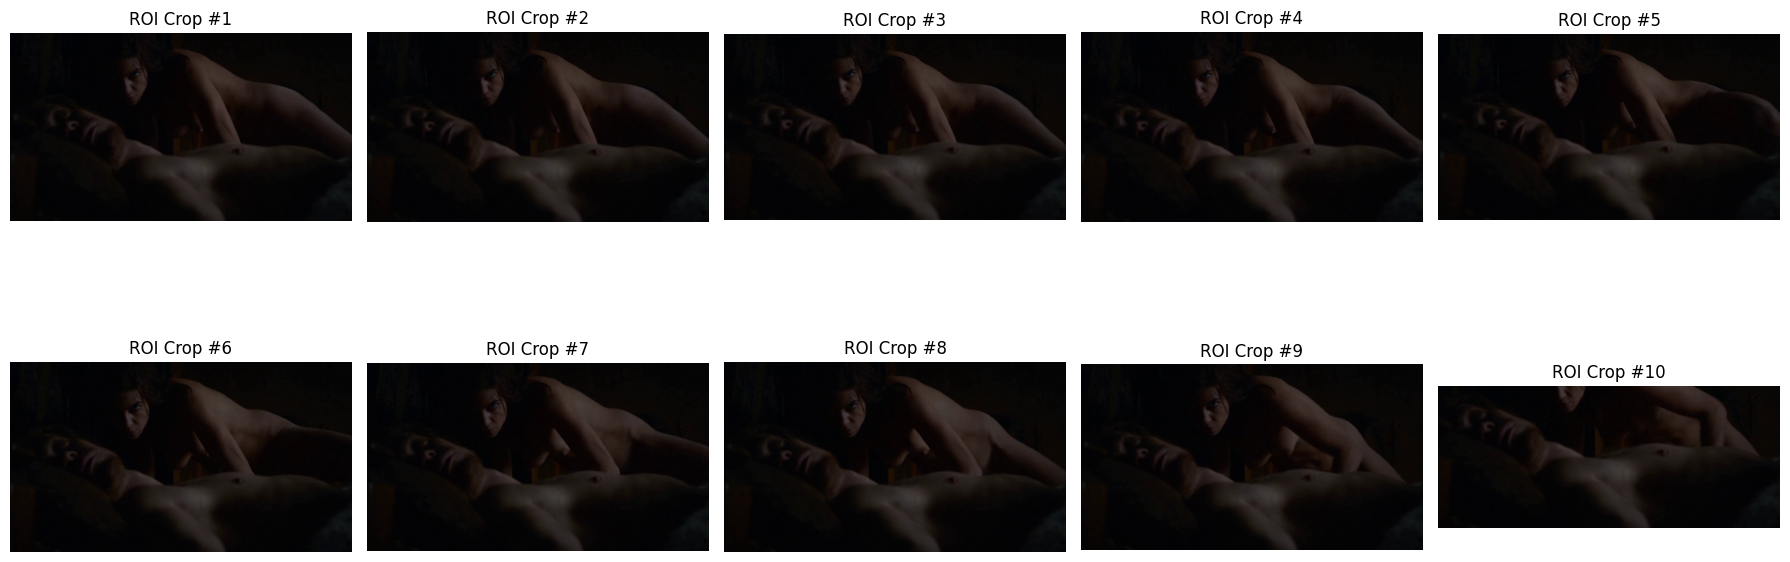

In [ ]:
# Verify ROI: print/show 10 random ROI crops
import random
from functools import partial
import matplotlib.pyplot as plt

from temporal_dataset2_loader import load_dataset2_from_directory_fallback, load_frames_fallback

DATASET2_PATH = str(
    globals().get(
        "DATASET2_PATH",
        globals().get(
            "DATASET2_DIR",
            "/media/hazem/6A47B344CD80864E/GP Implementation/Dataset/Dataset 2/censora_movies_tvshows_dataset",
        ),
    )
)

dataset = load_dataset2_from_directory_fallback(DATASET2_PATH, seq_len=8)
dataset = [x for x in dataset if isinstance(x, dict) and int(x.get("label", -1)) in (0, 1, 2)]
if len(dataset) == 0:
    raise RuntimeError("Dataset2 is empty after filtering labels {0,1,2}.")

random_record = random.choice(dataset)
roi_debug_loader = partial(
    load_frames_fallback,
    seq_len=10,
    random_sampling=True,
    use_roi=bool(TEMPORAL_USE_ROI),
    roi_conf=float(TEMPORAL_ROI_CONF),
    roi_inference_size=int(TEMPORAL_ROI_INFERENCE_SIZE),
    roi_cache_size=int(TEMPORAL_ROI_CACHE_SIZE),
)

roi_debug_frames = roi_debug_loader(random_record["frames"])
if not roi_debug_frames:
    raise RuntimeError("ROI debug failed: no frames returned.")

samples_to_show = min(10, len(roi_debug_frames))
print(f"Displaying {samples_to_show} random ROI crops from: {random_record['frames']['video_path']}")

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
for idx in range(10):
    ax = axes[idx]
    if idx < samples_to_show:
        crop = roi_debug_frames[idx]
        ax.imshow(crop)
        ax.set_title(f"ROI Crop #{idx + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Domain adaptation

### Cross-dataset evaluation before finetuning

Run these domain adaptation cells in order:
1. Setup target dataset config
2. Load saved best model (separate cell)
3. Test on target dataset at threshold = 0.15
4. Analyze failure cases (missed detections and false positives)

In [ ]:
# Domain Adaptation - Cell 1: Setup target dataset and evaluation config
import os
import torch

TARGET_DATASET_PATH = "/media/hazem/6A47B344CD80864E/Dataset/Imageandvideodataset/image dataset/train"
DOMAIN_THRESHOLD = 0.15
DOMAIN_EXPECTED_CLASSES = {"nude", "safe"}

print("[Domain Adaptation] Setup starting...")
print(f"Target dataset path: {TARGET_DATASET_PATH}")
print(f"Evaluation threshold: {DOMAIN_THRESHOLD:.2f}")

if not os.path.isdir(TARGET_DATASET_PATH):
    raise FileNotFoundError(f"Target dataset folder not found: {TARGET_DATASET_PATH}")

subdirs = {
    name
    for name in os.listdir(TARGET_DATASET_PATH)
    if os.path.isdir(os.path.join(TARGET_DATASET_PATH, name))
}

missing = DOMAIN_EXPECTED_CLASSES - subdirs
if missing:
    raise ValueError(
        "Target dataset must contain class folders 'nude' and 'safe'. "
        f"Missing: {sorted(missing)} | Found folders: {sorted(subdirs)}"
    )

if "BATCH_SIZE" not in globals():
    BATCH_SIZE = 56
if "NUM_WORKERS" not in globals():
    NUM_WORKERS = 20
if "PIN_MEMORY" not in globals():
    PIN_MEMORY = torch.cuda.is_available()
if "PREFETCH_FACTOR" not in globals():
    PREFETCH_FACTOR = 4 if NUM_WORKERS > 0 else None
if "DATALOADER_TIMEOUT" not in globals():
    DATALOADER_TIMEOUT = 0
if "USE_CHANNELS_LAST" not in globals():
    USE_CHANNELS_LAST = True
if "DEVICE" not in globals():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(
    f"Loader config -> batch={BATCH_SIZE}, workers={NUM_WORKERS}, "
    f"prefetch={PREFETCH_FACTOR}, pin_memory={PIN_MEMORY}, device={DEVICE}"
)
print("[Domain Adaptation] Setup done.")

[Domain Adaptation] Setup starting...
Target dataset path: /media/hazem/6A47B344CD80864E/Dataset/Imageandvideodataset/image dataset/train
Evaluation threshold: 0.15
Loader config -> batch=56, workers=20, prefetch=4, pin_memory=True, device=cuda
[Domain Adaptation] Setup done.


In [ ]:
# Domain Adaptation - Cell 2: Load saved best model (separate from testing)

import timm

print("[Domain Adaptation] Model loading starting...")

checkpoint_dir = os.path.join(os.getcwd(), "checkpoints")
domain_best_ckpt_path = os.path.join(checkpoint_dir, "porn_convnext_small_amp_best.pt")

if not os.path.exists(domain_best_ckpt_path):
    raise FileNotFoundError(
        "Best checkpoint not found. Expected: "
        f"{domain_best_ckpt_path}"
    )

domain_checkpoint = torch.load(domain_best_ckpt_path, map_location=DEVICE)

if isinstance(domain_checkpoint, dict) and domain_checkpoint.get("best_model_state_dict") is not None:
    domain_state_dict = domain_checkpoint["best_model_state_dict"]
    domain_state_name = "best_model_state_dict"
elif isinstance(domain_checkpoint, dict) and domain_checkpoint.get("model_state_dict") is not None:
    domain_state_dict = domain_checkpoint["model_state_dict"]
    domain_state_name = "model_state_dict"
else:
    raise KeyError("Checkpoint does not contain model weights.")

domain_model = timm.create_model("convnext_small", pretrained=False, num_classes=1).to(DEVICE)
domain_model.load_state_dict(domain_state_dict)
if USE_CHANNELS_LAST:
    domain_model = domain_model.to(memory_format=torch.channels_last)
domain_model.eval()

domain_checkpoint_class_to_idx = {}
if isinstance(domain_checkpoint, dict) and isinstance(domain_checkpoint.get("class_to_idx"), dict):
    domain_checkpoint_class_to_idx = domain_checkpoint["class_to_idx"]

print(f"Loaded checkpoint: {domain_best_ckpt_path}")
print(f"Weights key used: {domain_state_name}")
if isinstance(domain_checkpoint, dict) and domain_checkpoint.get("best_epoch") is not None:
    print(f"Checkpoint best_epoch: {domain_checkpoint['best_epoch']}")
print(f"Model ready on device: {DEVICE}")
print(f"Testing threshold configured (used in next cell): {DOMAIN_THRESHOLD:.2f}")
print("[Domain Adaptation] Model loading done.")

[Domain Adaptation] Model loading starting...


/tmp/ipykernel_6623/3510264354.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  domain_checkpoint = torch.load(domain_best_ckpt_path, map_location=DEVICE)


Loaded checkpoint: /media/hazem/Windows-SSD/Desktop/BUE/Year 3/GP/Implimentation/checkpoints/porn_convnext_small_amp_best.pt
Weights key used: best_model_state_dict
Checkpoint best_epoch: 3
Model ready on device: cuda
Testing threshold configured (used in next cell): 0.15
[Domain Adaptation] Model loading done.


In [ ]:
# Domain Adaptation - Cell 2.5: Reload local module after file edits
import importlib
import porn_data as _porn_data

importlib.reload(_porn_data)
print("Reloaded porn_data module from disk.")

Reloaded porn_data module from disk.


In [ ]:
# Domain Adaptation - Cell 3: Test on target dataset @ threshold 0.15 and report metrics
import os
import numpy as np
import torch
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix
from porn_data import SafeImageFolder, RemapLabelDataset, fast_transform_rgb224

print("[Domain Adaptation] Target dataset evaluation starting...")

required_symbols = ["domain_model", "TARGET_DATASET_PATH", "DOMAIN_THRESHOLD", "DEVICE"]
missing_symbols = [name for name in required_symbols if name not in globals()]
if missing_symbols:
    raise RuntimeError(
        "Missing required symbols. Run Domain Adaptation setup/model cells first: "
        + ", ".join(missing_symbols)
    )

# Build target dataset in ImageFolder mode.
domain_target_raw_dataset = SafeImageFolder(TARGET_DATASET_PATH, transform=fast_transform_rgb224)
if not hasattr(domain_target_raw_dataset, "class_to_idx") or not domain_target_raw_dataset.class_to_idx:
    raise ValueError("Target dataset class_to_idx is missing.")

target_map = domain_target_raw_dataset.class_to_idx
if "nude" not in target_map or "safe" not in target_map:
    raise ValueError(
        "Target dataset must include 'nude' and 'safe' classes. "
        f"Found mapping: {target_map}"
    )

# Resolve positive/negative class ids expected by the trained model.
if "idx_nude_train" in globals() and "idx_safe_train" in globals():
    domain_idx_nude = int(idx_nude_train)
    domain_idx_safe = int(idx_safe_train)
elif "domain_checkpoint_class_to_idx" in globals() and {
    "nude", "safe"
}.issubset(set(domain_checkpoint_class_to_idx.keys())):
    domain_idx_nude = int(domain_checkpoint_class_to_idx["nude"])
    domain_idx_safe = int(domain_checkpoint_class_to_idx["safe"])
else:
    domain_idx_nude = 2
    domain_idx_safe = 1

# Remap target labels into the model's expected label ids.
remap_dict = {
    int(target_map["nude"]): domain_idx_nude,
    int(target_map["safe"]): domain_idx_safe,
}

if remap_dict[int(target_map["nude"])] == int(target_map["nude"]) and remap_dict[int(target_map["safe"])] == int(target_map["safe"]):
    domain_target_eval_dataset = domain_target_raw_dataset
    print("Target label mapping already aligned with model labels.")
else:
    domain_target_eval_dataset = RemapLabelDataset(domain_target_raw_dataset, remap_dict=remap_dict)
    print(f"Applied target->model label remap: {remap_dict}")

# Per-sample inference (keeps image filename for failure analysis in next cell).
domain_eval_rows = []
skipped_samples = 0

with torch.no_grad():
    for i in range(len(domain_target_eval_dataset)):
        item = domain_target_eval_dataset[i]
        if item is None:
            skipped_samples += 1
            continue

        image, true_label = item
        x = image.unsqueeze(0).to(DEVICE)
        if USE_CHANNELS_LAST:
            x = x.to(memory_format=torch.channels_last)

        logits = domain_model(x)
        score = float(torch.sigmoid(logits).squeeze().item())
        pred_label = domain_idx_nude if score > float(DOMAIN_THRESHOLD) else domain_idx_safe

        sample_path = ""
        if hasattr(domain_target_raw_dataset, "samples") and i < len(domain_target_raw_dataset.samples):
            sample_path = domain_target_raw_dataset.samples[i][0]

        domain_eval_rows.append(
            {
                "index": int(i),
                "path": sample_path,
                "true_label": int(true_label),
                "pred_label": int(pred_label),
                "score": score,
            }
        )

if not domain_eval_rows:
    raise RuntimeError("No valid samples were evaluated on target dataset.")

y_true = [row["true_label"] for row in domain_eval_rows]
y_pred = [row["pred_label"] for row in domain_eval_rows]

accuracy = float(accuracy_score(y_true, y_pred))
recall = float(recall_score(y_true, y_pred, pos_label=domain_idx_nude, zero_division=0))
f1 = float(f1_score(y_true, y_pred, pos_label=domain_idx_nude, zero_division=0))
precision = float(precision_score(y_true, y_pred, pos_label=domain_idx_nude, zero_division=0))
f2_denom = (4.0 * precision) + recall
f2 = float((5.0 * precision * recall / f2_denom) if f2_denom > 0.0 else 0.0)

# Order labels as [negative=safe, positive=nude] so matrix format is [[TN, FP], [FN, TP]].
domain_confusion_matrix = confusion_matrix(y_true, y_pred, labels=[domain_idx_safe, domain_idx_nude])

domain_metrics = {
    "threshold": float(DOMAIN_THRESHOLD),
    "samples": int(len(domain_eval_rows)),
    "skipped_samples": int(skipped_samples),
    "accuracy": accuracy,
    "recall": recall,
    "f1": f1,
    "f2": f2,
    "confusion_matrix": domain_confusion_matrix,
}

print("\nTarget Dataset Evaluation Report")
print(f"Threshold: {domain_metrics['threshold']:.2f}")
print(f"Samples evaluated: {domain_metrics['samples']}")
print(f"Skipped samples: {domain_metrics['skipped_samples']}")
print(f"Accuracy: {domain_metrics['accuracy']:.4f}")
print(f"Recall:   {domain_metrics['recall']:.4f}")
print(f"F1:       {domain_metrics['f1']:.4f}")
print(f"F2:       {domain_metrics['f2']:.4f}")
print("Confusion Matrix [[TN, FP], [FN, TP]]:")
print(domain_metrics["confusion_matrix"])
print("[Domain Adaptation] Target evaluation done.")

[Domain Adaptation] Target dataset evaluation starting...
Target label mapping already aligned with model labels.

Target Dataset Evaluation Report
Threshold: 0.15
Samples evaluated: 22304
Skipped samples: 2
Accuracy: 0.7795
Recall:   0.9900
F1:       0.8181
F2:       0.9132
Confusion Matrix [[TN, FP], [FN, TP]]:
[[ 6324  4807]
 [  112 11061]]
[Domain Adaptation] Target evaluation done.


In [ ]:
# Domain Adaptation - Cell 4: Failure-case analysis (missed detections + false positives)

required_symbols = [
    "domain_eval_rows",
    "domain_metrics",
    "domain_idx_nude",
    "domain_idx_safe",
    "DOMAIN_THRESHOLD",
]
missing_symbols = [name for name in required_symbols if name not in globals()]
if missing_symbols:
    raise RuntimeError(
        "Missing evaluation artifacts. Run Domain Adaptation testing cell first: "
        + ", ".join(missing_symbols)
    )

false_negatives = [
    row
    for row in domain_eval_rows
    if row["true_label"] == domain_idx_nude and row["pred_label"] == domain_idx_safe
]
false_positives = [
    row
    for row in domain_eval_rows
    if row["true_label"] == domain_idx_safe and row["pred_label"] == domain_idx_nude
]

def _format_case_row(row):
    name = os.path.basename(row["path"]) if row["path"] else f"sample_{row['index']}"
    return (
        f"idx={row['index']:6d} | "
        f"score={row['score']:.4f} | "
        f"true={row['true_label']} | pred={row['pred_label']} | "
        f"file={name}"
    )

def _print_cases(title, rows, limit=125, sort_desc=True):
    print("\n" + title)
    print("-" * len(title))
    if not rows:
        print("None")
        return

    sorted_rows = sorted(rows, key=lambda r: r["score"], reverse=sort_desc)
    for row in sorted_rows[:limit]:
        print(_format_case_row(row))

    if len(sorted_rows) > limit:
        print(f"... ({len(sorted_rows) - limit} more not shown)")

n_samples = max(1, int(domain_metrics.get("samples", len(domain_eval_rows))))
fn_rate = len(false_negatives) / n_samples
fp_rate = len(false_positives) / n_samples

print("Failure Case Analysis")
print(f"Threshold: {float(DOMAIN_THRESHOLD):.2f}")
print(f"Total samples: {n_samples}")
print(f"Missed detections (FN): {len(false_negatives)} ({fn_rate:.2%})")
print(f"False positives (FP):   {len(false_positives)} ({fp_rate:.2%})")

# FN: nude predicted safe -> usually lower scores; sort ascending to surface strongest misses.
_print_cases(
    "Top Missed Detections (FN) - lowest scores",
    false_negatives,
    limit=125,
    sort_desc=False,
)

# FP: safe predicted nude -> usually higher scores; sort descending to surface strongest false alarms.
_print_cases(
    "Top False Positives (FP) - highest scores",
    false_positives,
    limit=25,
    sort_desc=True,
)

print("\nFailure analysis complete.")

Failure Case Analysis
Threshold: 0.15
Total samples: 22304
Missed detections (FN): 112 (0.50%)
False positives (FP):   4807 (21.55%)

Top Missed Detections (FN) - lowest scores
------------------------------------------
idx=  4401 | score=0.0013 | true=0 | pred=1 | file=bb_1732.png
idx=  4400 | score=0.0020 | true=0 | pred=1 | file=bb_1731.png
idx=  4442 | score=0.0025 | true=0 | pred=1 | file=bb_1773.png
idx=  6662 | score=0.0026 | true=0 | pred=1 | file=test3 (1381).jpg
idx=  4441 | score=0.0033 | true=0 | pred=1 | file=bb_1772.png
idx=  4381 | score=0.0035 | true=0 | pred=1 | file=bb_1712.png
idx=  9383 | score=0.0036 | true=0 | pred=1 | file=train3 (1682).jpg
idx=  4380 | score=0.0037 | true=0 | pred=1 | file=bb_1711.png
idx= 10704 | score=0.0042 | true=0 | pred=1 | file=train3 (670).jpg
idx= 10555 | score=0.0042 | true=0 | pred=1 | file=train3 (536).jpg
idx=  8487 | score=0.0049 | true=0 | pred=1 | file=test3 (876).jpg
idx=  4406 | score=0.0052 | true=0 | pred=1 | file=bb_1737.png

In [ ]:
# Domain Adaptation - Cell 5: Threshold sweep on target dataset
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix

required_symbols = ["domain_eval_rows", "domain_idx_nude", "domain_idx_safe", "DOMAIN_THRESHOLD"]
missing_symbols = [name for name in required_symbols if name not in globals()]
if missing_symbols:
    raise RuntimeError(
        "Missing required symbols. Run evaluation cell first: " + ", ".join(missing_symbols)
    )

# Build arrays from stored per-sample predictions.
scores = np.array([float(r["score"]) for r in domain_eval_rows], dtype=np.float32)
y_true = np.array([int(r["true_label"]) for r in domain_eval_rows], dtype=np.int64)

threshold_values = np.round(np.linspace(0.05, 0.95, 19), 2)
domain_threshold_sweep_results = []

for thr in threshold_values:
    y_pred = np.where(scores > float(thr), int(domain_idx_nude), int(domain_idx_safe))
    acc = float(accuracy_score(y_true, y_pred))
    rec = float(recall_score(y_true, y_pred, pos_label=int(domain_idx_nude), zero_division=0))
    f1 = float(f1_score(y_true, y_pred, pos_label=int(domain_idx_nude), zero_division=0))
    prec = float(precision_score(y_true, y_pred, pos_label=int(domain_idx_nude), zero_division=0))
    f2_denom = (4.0 * prec) + rec
    f2 = float((5.0 * prec * rec / f2_denom) if f2_denom > 0.0 else 0.0)
    cm = confusion_matrix(y_true, y_pred, labels=[int(domain_idx_safe), int(domain_idx_nude)])

    domain_threshold_sweep_results.append(
        {
            "threshold": float(thr),
            "accuracy": acc,
            "recall": rec,
            "precision": prec,
            "f1": f1,
            "f2": f2,
            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        }
    )

# Recommend threshold by highest F2, then higher recall, then lower FP count.
domain_best_threshold_by_f2 = sorted(
    domain_threshold_sweep_results,
    key=lambda r: (r["f2"], r["recall"], -r["fp"]),
    reverse=True,
)[0]

current_thr = float(DOMAIN_THRESHOLD)
current_row = min(
    domain_threshold_sweep_results,
    key=lambda r: abs(r["threshold"] - current_thr),
)

print("Threshold Sweep Report (Target Dataset)")
print(f"Samples: {len(domain_eval_rows)}")
print(f"Current threshold: {current_thr:.2f}")
print(
    f"Current -> F2={current_row['f2']:.4f}, Recall={current_row['recall']:.4f}, "
    f"FP={current_row['fp']}, FN={current_row['fn']}"
)
print(
    f"Best by F2 -> threshold={domain_best_threshold_by_f2['threshold']:.2f}, "
    f"F2={domain_best_threshold_by_f2['f2']:.4f}, Recall={domain_best_threshold_by_f2['recall']:.4f}, "
    f"FP={domain_best_threshold_by_f2['fp']}, FN={domain_best_threshold_by_f2['fn']}"
)

print("\nTop 10 thresholds by F2:")
for row in sorted(domain_threshold_sweep_results, key=lambda r: r["f2"], reverse=True)[:10]:
    print(
        f"thr={row['threshold']:.2f} | F2={row['f2']:.4f} | Recall={row['recall']:.4f} | "
        f"Precision={row['precision']:.4f} | FP={row['fp']} | FN={row['fn']}"
    )

Threshold Sweep Report (Target Dataset)
Samples: 22304
Current threshold: 0.15
Current -> F2=0.9132, Recall=0.9900, FP=4807, FN=112
Best by F2 -> threshold=0.55, F2=0.9309, Recall=0.9774, FP=3040, FN=253

Top 10 thresholds by F2:
thr=0.55 | F2=0.9309 | Recall=0.9774 | Precision=0.7822 | FP=3040 | FN=253
thr=0.50 | F2=0.9308 | Recall=0.9801 | Precision=0.7748 | FP=3183 | FN=222
thr=0.60 | F2=0.9305 | Recall=0.9741 | Precision=0.7892 | FP=2907 | FN=289
thr=0.70 | F2=0.9298 | Recall=0.9675 | Precision=0.8045 | FP=2627 | FN=363
thr=0.65 | F2=0.9298 | Recall=0.9704 | Precision=0.7966 | FP=2768 | FN=331
thr=0.45 | F2=0.9294 | Recall=0.9816 | Precision=0.7665 | FP=3340 | FN=206
thr=0.75 | F2=0.9293 | Recall=0.9634 | Precision=0.8142 | FP=2456 | FN=409
thr=0.40 | F2=0.9275 | Recall=0.9831 | Precision=0.7564 | FP=3537 | FN=189
thr=0.80 | F2=0.9269 | Recall=0.9573 | Precision=0.8225 | FP=2308 | FN=477
thr=0.35 | F2=0.9255 | Recall=0.9843 | Precision=0.7469 | FP=3727 | FN=175


In [ ]:
# Domain Adaptation - Cell 6: Save evaluation, threshold sweep, and failure cases to eval_logs
import csv
import json
from datetime import datetime

required_symbols = [
    "domain_metrics",
    "domain_eval_rows",
    "domain_idx_nude",
    "domain_idx_safe",
    "DOMAIN_THRESHOLD",
    "domain_threshold_sweep_results",
    "domain_best_threshold_by_f2",
]
missing_symbols = [name for name in required_symbols if name not in globals()]
if missing_symbols:
    raise RuntimeError(
        "Missing required symbols. Run evaluation + sweep cells first: " + ", ".join(missing_symbols)
    )

eval_logs_dir = os.path.join(os.getcwd(), "eval_logs")
os.makedirs(eval_logs_dir, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Current-threshold failure cases from stored predictions.
false_negatives = [
    r for r in domain_eval_rows
    if int(r["true_label"]) == int(domain_idx_nude) and int(r["pred_label"]) == int(domain_idx_safe)
 ]
false_positives = [
    r for r in domain_eval_rows
    if int(r["true_label"]) == int(domain_idx_safe) and int(r["pred_label"]) == int(domain_idx_nude)
 ]

threshold_sweep_path = os.path.join(eval_logs_dir, f"phase8_threshold_sweep_{timestamp}.json")
comparison_path = os.path.join(eval_logs_dir, f"phase8_comparison_{timestamp}.json")
failures_csv_path = os.path.join(eval_logs_dir, f"phase8_failure_cases_{timestamp}.csv")

current_threshold = float(DOMAIN_THRESHOLD)
current_row = min(
    domain_threshold_sweep_results,
    key=lambda r: abs(float(r["threshold"]) - current_threshold),
)

threshold_payload = {
    "timestamp": timestamp,
    "current_threshold": current_threshold,
    "recommended_threshold_by_f2": float(domain_best_threshold_by_f2["threshold"]),
    "sweep_results": domain_threshold_sweep_results,
}

comparison_payload = {
    "timestamp": timestamp,
    "current": {
        "threshold": current_threshold,
        "accuracy": float(domain_metrics["accuracy"]),
        "recall": float(domain_metrics["recall"]),
        "f1": float(domain_metrics["f1"]),
        "f2": float(domain_metrics["f2"]),
        "samples": int(domain_metrics["samples"]),
        "skipped_samples": int(domain_metrics["skipped_samples"]),
        "confusion_matrix": np.asarray(domain_metrics["confusion_matrix"]).tolist(),
        "fp": int(current_row["fp"]),
        "fn": int(current_row["fn"]),
    },
    "recommended_by_f2": {
        "threshold": float(domain_best_threshold_by_f2["threshold"]),
        "accuracy": float(domain_best_threshold_by_f2["accuracy"]),
        "recall": float(domain_best_threshold_by_f2["recall"]),
        "precision": float(domain_best_threshold_by_f2["precision"]),
        "f1": float(domain_best_threshold_by_f2["f1"]),
        "f2": float(domain_best_threshold_by_f2["f2"]),
        "fp": int(domain_best_threshold_by_f2["fp"]),
        "fn": int(domain_best_threshold_by_f2["fn"]),
        "tn": int(domain_best_threshold_by_f2["tn"]),
        "tp": int(domain_best_threshold_by_f2["tp"]),
    },
}

with open(threshold_sweep_path, "w", encoding="utf-8") as f:
    json.dump(threshold_payload, f, indent=2)

with open(comparison_path, "w", encoding="utf-8") as f:
    json.dump(comparison_payload, f, indent=2)

with open(failures_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["case_type", "index", "path", "score", "true_label", "pred_label"],
    )
    writer.writeheader()
    for row in false_negatives:
        writer.writerow({"case_type": "FN", **row})
    for row in false_positives:
        writer.writerow({"case_type": "FP", **row})

print("Saved logs:")
print(f"- {threshold_sweep_path}")
print(f"- {comparison_path}")
print(f"- {failures_csv_path}")
print(
    f"Exported failure rows: FN={len(false_negatives)}, FP={len(false_positives)}, "
    f"Total={len(false_negatives) + len(false_positives)}"
)

Saved logs:
- /media/hazem/Windows-SSD/Desktop/BUE/Year 3/GP/Implimentation/eval_logs/phase8_threshold_sweep_20260406_013926.json
- /media/hazem/Windows-SSD/Desktop/BUE/Year 3/GP/Implimentation/eval_logs/phase8_comparison_20260406_013926.json
- /media/hazem/Windows-SSD/Desktop/BUE/Year 3/GP/Implimentation/eval_logs/phase8_failure_cases_20260406_013926.csv
Exported failure rows: FN=112, FP=4807, Total=4919
